## The Dataset

In [4]:
from google.colab import drive
import os
import shutil

# Attempt to unmount cleanly if already mounted (and ignore if not mounted)
try:
    drive.flush_and_unmount()
except ValueError:
    pass

# Ensure the mountpoint is empty before mounting
mountpoint = '/content/drive'
if os.path.exists(mountpoint) and os.path.isdir(mountpoint):
    if os.listdir(mountpoint): # Check if directory is not empty
        print(f"Mountpoint '{mountpoint}' is not empty. Removing contents...")
        shutil.rmtree(mountpoint) # Remove directory and its contents
        os.makedirs(mountpoint) # Recreate empty directory
    else:
        print(f"Mountpoint '{mountpoint}' exists and is empty.")
else:
    print(f"Mountpoint '{mountpoint}' does not exist or is not a directory. Creating...")
    os.makedirs(mountpoint, exist_ok=True) # Create if it doesn't exist

drive.mount(mountpoint, force_remount=True)

LOCAL_DICHASUS_DIR = "/content/drive/MyDrive/dichasus"

print("Dataset folder:")
print(LOCAL_DICHASUS_DIR)

print("\nFolder exists?")
print(os.path.exists(LOCAL_DICHASUS_DIR))

if not os.path.exists(LOCAL_DICHASUS_DIR):
    raise FileNotFoundError(
        "Dataset folder was not found. Please make sure the dichasus folder exists in MyDrive."
    )

Drive not mounted, so nothing to flush and unmount.
Mountpoint '/content/drive' exists and is empty.
Mounted at /content/drive
Dataset folder:
/content/drive/MyDrive/dichasus

Folder exists?
True


In [5]:
import os

LOCAL_DICHASUS_DIR = "/content/drive/MyDrive/dichasus"

required_files = [
    "dichasus-0152.tfrecords",
    "dichasus-0153.tfrecords",
    "dichasus-0154.tfrecords",
    "dichasus-0155.tfrecords",
    "dichasus-0157.tfrecords",
]

print("Dataset check")
print("-" * 50)

for filename in required_files:
    path = os.path.join(LOCAL_DICHASUS_DIR, filename)

    if os.path.exists(path):
        size_gb = os.path.getsize(path) / (1024 ** 3)
        print(f"{filename}: OK | {size_gb:.2f} GB")
    else:
        raise FileNotFoundError(
            f"Missing dataset file: {filename}"
        )

Dataset check
--------------------------------------------------
dichasus-0152.tfrecords: OK | 3.30 GB
dichasus-0153.tfrecords: OK | 3.50 GB
dichasus-0154.tfrecords: OK | 3.73 GB
dichasus-0155.tfrecords: OK | 3.95 GB
dichasus-0157.tfrecords: OK | 3.55 GB


In [6]:
import os

required_files = [
    "dichasus-0152.tfrecords",
    "dichasus-0153.tfrecords",
    "dichasus-0154.tfrecords",
    "dichasus-0155.tfrecords",
    "dichasus-0157.tfrecords",
]

print("Dataset folder:")
print(LOCAL_DICHASUS_DIR)

print("\nFiles check:")
for filename in required_files:
    path = os.path.join(LOCAL_DICHASUS_DIR, filename)

    if os.path.exists(path):
        size_gb = os.path.getsize(path) / (1024 ** 3)
        print(f"{filename}: OK | {size_gb:.2f} GB")
    else:
        print(f"{filename}: MISSING")

Dataset folder:
/content/drive/MyDrive/dichasus

Files check:
dichasus-0152.tfrecords: OK | 3.30 GB
dichasus-0153.tfrecords: OK | 3.50 GB
dichasus-0154.tfrecords: OK | 3.73 GB
dichasus-0155.tfrecords: OK | 3.95 GB
dichasus-0157.tfrecords: OK | 3.55 GB


In [7]:
# ============================================================
# Load cached runs instead of reloading TFRecords
# ============================================================

import os
import numpy as np

CACHE_DIR = "/content/drive/MyDrive/dichasus_cache"

def load_runs_from_npz(input_path):
    loaded = np.load(input_path, allow_pickle=True)

    runs = []
    num_runs = int(loaded["num_runs"])

    for i in range(num_runs):
        runs.append({
            "file": str(loaded[f"file_{i}"]),
            "X_csi": loaded[f"X_csi_{i}"].astype(np.float32),
            "pos": loaded[f"pos_{i}"].astype(np.float32),
            "time": loaded[f"time_{i}"].astype(np.float32),
        })

    print("Loaded:", input_path)

    for r in runs:
        print(
            r["file"],
            "X_csi:", r["X_csi"].shape,
            "pos:", r["pos"].shape,
            "time:", r["time"].shape
        )

    return runs


train_runs = load_runs_from_npz(
    os.path.join(CACHE_DIR, "train_runs_mag_phase.npz")
)

val_runs = load_runs_from_npz(
    os.path.join(CACHE_DIR, "val_runs_mag_phase.npz")
)

test_runs = load_runs_from_npz(
    os.path.join(CACHE_DIR, "test_runs_mag_phase.npz")
)

Loaded: /content/drive/MyDrive/dichasus_cache/train_runs_mag_phase.npz
/content/drive/MyDrive/dichasus/dichasus-0152.tfrecords X_csi: (13496, 32, 32, 2) pos: (13496, 2) time: (13496,)
/content/drive/MyDrive/dichasus/dichasus-0153.tfrecords X_csi: (14297, 32, 32, 2) pos: (14297, 2) time: (14297,)
/content/drive/MyDrive/dichasus/dichasus-0155.tfrecords X_csi: (16137, 32, 32, 2) pos: (16137, 2) time: (16137,)
Loaded: /content/drive/MyDrive/dichasus_cache/val_runs_mag_phase.npz
/content/drive/MyDrive/dichasus/dichasus-0157.tfrecords X_csi: (14511, 32, 32, 2) pos: (14511, 2) time: (14511,)
Loaded: /content/drive/MyDrive/dichasus_cache/test_runs_mag_phase.npz
/content/drive/MyDrive/dichasus/dichasus-0154.tfrecords X_csi: (15233, 32, 32, 2) pos: (15233, 2) time: (15233,)


In [8]:
# ============================================================
# Prepare data for Integrated Gradients
# ============================================================

import numpy as np

X_train_ig = np.concatenate(
    [run["X_csi"] for run in train_runs],
    axis=0
)

y_train_ig = np.concatenate(
    [run["pos"] for run in train_runs],
    axis=0
)

X_val_ig = np.concatenate(
    [run["X_csi"] for run in val_runs],
    axis=0
)

y_val_ig = np.concatenate(
    [run["pos"] for run in val_runs],
    axis=0
)

print("X_train_ig:", X_train_ig.shape)
print("y_train_ig:", y_train_ig.shape)

print("X_val_ig:", X_val_ig.shape)
print("y_val_ig:", y_val_ig.shape)

X_train_ig: (43930, 32, 32, 2)
y_train_ig: (43930, 2)
X_val_ig: (14511, 32, 32, 2)
y_val_ig: (14511, 2)


In [ ]:
# # ------------------------------------------------------------
# # Compute mean baseline from training CSI only
# # ------------------------------------------------------------

# import numpy as np

# def compute_mean_baseline_from_runs(runs):
#     all_csi = np.concatenate(
#         [r["X_csi"] for r in runs],
#         axis=0
#     )

#     baseline = np.mean(
#         all_csi,
#         axis=0,
#         keepdims=True
#     ).astype(np.float32)

#     return baseline


# mean_baseline = compute_mean_baseline_from_runs(train_runs)

# print("Mean baseline shape:", mean_baseline.shape)

In [ ]:
# # ============================================================
# # IG function definitions only
# # ============================================================

# import numpy as np
# import tensorflow as tf

# def antenna_importance_from_attribution(attr):
#     attr = np.asarray(attr)

#     attr_magnitude = np.sqrt(
#         attr[..., 0] ** 2 +
#         attr[..., 1] ** 2
#     )

#     antenna_importance = np.mean(
#         attr_magnitude,
#         axis=2
#     )

#     return antenna_importance.astype(np.float32)


# def integrated_gradients_importance(
#     model,
#     X,
#     baseline,
#     steps=50,
#     batch_size=64,
#     normalize_importance=False
# ):
#     X = X.astype(np.float32)
#     baseline = baseline.astype(np.float32)

#     all_importances = []
#     n = X.shape[0]
#     alphas = tf.linspace(0.0, 1.0, steps)

#     for start in range(0, n, batch_size):
#         end = min(start + batch_size, n)

#         X_batch = X[start:end]
#         B = X_batch.shape[0]

#         X_batch_tf = tf.convert_to_tensor(X_batch, dtype=tf.float32)

#         baseline_tf = tf.convert_to_tensor(
#             np.repeat(baseline, B, axis=0),
#             dtype=tf.float32
#         )

#         total_grad_x = tf.zeros_like(X_batch_tf)
#         total_grad_y = tf.zeros_like(X_batch_tf)

#         for i, alpha in enumerate(alphas):
#             interpolated = baseline_tf + alpha * (X_batch_tf - baseline_tf)

#             with tf.GradientTape(persistent=True) as tape:
#                 tape.watch(interpolated)
#                 pred = model(interpolated, training=False)
#                 output_x = pred[:, 0]
#                 output_y = pred[:, 1]

#             grad_x = tape.gradient(output_x, interpolated)
#             grad_y = tape.gradient(output_y, interpolated)

#             weight = 0.5 if (i == 0 or i == steps - 1) else 1.0

#             total_grad_x += weight * grad_x
#             total_grad_y += weight * grad_y

#             del tape

#         avg_grad_x = total_grad_x / tf.cast(steps - 1, tf.float32)
#         avg_grad_y = total_grad_y / tf.cast(steps - 1, tf.float32)

#         attr_x = (X_batch_tf - baseline_tf) * avg_grad_x
#         attr_y = (X_batch_tf - baseline_tf) * avg_grad_y

#         attr_combined = tf.sqrt(
#             tf.square(attr_x) +
#             tf.square(attr_y)
#         )

#         batch_importance = antenna_importance_from_attribution(
#             attr_combined.numpy()
#         )

#         if normalize_importance:
#             batch_importance = batch_importance / (
#                 np.sum(batch_importance, axis=1, keepdims=True) + 1e-8
#             )

#         all_importances.append(batch_importance)

#         print(f"Computed importance: {end}/{n} samples")

#     return np.vstack(all_importances).astype(np.float32)


# def add_importance_to_runs(
#     runs,
#     model,
#     baseline,
#     steps=50,
#     batch_size=64,
#     normalize_importance=False
# ):
#     for r in runs:
#         print("\nComputing antenna importance for:", r["file"])

#         r["importance"] = integrated_gradients_importance(
#             model=model,
#             X=r["X_csi"],
#             baseline=baseline,
#             steps=steps,
#             batch_size=batch_size,
#             normalize_importance=normalize_importance
#         )

#         print("Importance shape:", r["importance"].shape)

#     return runs

# print("IG functions are ready.")

In [ ]:
# # ------------------------------------------------------------
# # Select model for IG
# # ------------------------------------------------------------

# if "nn" in globals() and hasattr(nn, "predict"):
#     localization_model = nn
#     print("Using nn as localization_model")
# else:
#     raise RuntimeError(
#         "nn was not found. First build/train or load nn."
#     )

In [ ]:
# # ------------------------------------------------------------
# # 6. Compute or load IG importance for train and validation only
# # ------------------------------------------------------------

# import os
# import numpy as np

# IG_CACHE_DIR = "/content/drive/MyDrive/dichasus_cache/ig_importance"
# os.makedirs(IG_CACHE_DIR, exist_ok=True)

# NORMALIZE_IG_IMPORTANCE = False
# IG_STEPS = 50
# IG_BATCH_SIZE = 64

# TRAIN_IG_CACHE = os.path.join(
#     IG_CACHE_DIR,
#     f"train_importance_steps{IG_STEPS}_norm{NORMALIZE_IG_IMPORTANCE}.npz"
# )

# VAL_IG_CACHE = os.path.join(
#     IG_CACHE_DIR,
#     f"val_importance_steps{IG_STEPS}_norm{NORMALIZE_IG_IMPORTANCE}.npz"
# )


# def save_importance_runs(runs, output_path):
#     data = {}

#     for i, r in enumerate(runs):
#         data[f"file_{i}"] = r["file"]
#         data[f"importance_{i}"] = r["importance"]

#     data["num_runs"] = len(runs)

#     np.savez_compressed(output_path, **data)
#     print("Saved IG importance:", output_path)


# def load_importance_runs(runs, input_path):
#     loaded = np.load(input_path, allow_pickle=True)

#     num_runs = int(loaded["num_runs"])

#     if num_runs != len(runs):
#         raise ValueError(
#             f"Cached importance has {num_runs} runs, but current runs has {len(runs)}."
#         )

#     for i, r in enumerate(runs):
#         cached_file = str(loaded[f"file_{i}"])

#         if os.path.basename(cached_file) != os.path.basename(r["file"]):
#             raise ValueError(
#                 f"File mismatch at run {i}: cache has {cached_file}, current has {r['file']}"
#             )

#         r["importance"] = loaded[f"importance_{i}"].astype(np.float32)

#         print(
#             "Loaded importance:",
#             os.path.basename(r["file"]),
#             r["importance"].shape
#         )

#     return runs


# if os.path.exists(TRAIN_IG_CACHE):
#     print("Loading cached train IG importance...")
#     train_runs = load_importance_runs(train_runs, TRAIN_IG_CACHE)
# else:
#     print("Computing train IG importance...")
#     train_runs = add_importance_to_runs(
#         train_runs,
#         model=localization_model,
#         baseline=mean_baseline,
#         steps=IG_STEPS,
#         batch_size=IG_BATCH_SIZE,
#         normalize_importance=NORMALIZE_IG_IMPORTANCE
#     )

#     save_importance_runs(train_runs, TRAIN_IG_CACHE)


# if os.path.exists(VAL_IG_CACHE):
#     print("Loading cached validation IG importance...")
#     val_runs = load_importance_runs(val_runs, VAL_IG_CACHE)
# else:
#     print("Computing validation IG importance...")
#     val_runs = add_importance_to_runs(
#         val_runs,
#         model=localization_model,
#         baseline=mean_baseline,
#         steps=IG_STEPS,
#         batch_size=IG_BATCH_SIZE,
#         normalize_importance=NORMALIZE_IG_IMPORTANCE
#     )

#     save_importance_runs(val_runs, VAL_IG_CACHE)

In [ ]:
# train_importance_all = np.concatenate(
#     [r["importance"] for r in train_runs],
#     axis=0
# )

# val_importance_all = np.concatenate(
#     [r["importance"] for r in val_runs],
#     axis=0
# )

# global_importance = np.concatenate(
#     [
#         train_importance_all,
#         val_importance_all
#     ],
#     axis=0
# ).mean(axis=0)

# antenna_ranking_global = np.argsort(global_importance)[::-1]

# antenna_ranking_names = [
#     f"A{i+1}" for i in antenna_ranking_global
# ]

# print(antenna_ranking_names)

## Evaluation

In [ ]:
# true_positions_val = [] # Model Evaluation - Prediction robot position
# predictions_val = []

# val_set_batched = validation_set_features.batch(4096)

# for channel_coeffs, positions in val_set_batched:
# 	true_positions_val.append(positions)
# 	predictions_val.append(nn.predict(channel_coeffs))

# true_positions_val = np.vstack(true_positions_val)
# predictions_val = np.vstack(predictions_val)

# error_vectors_val = predictions_val - true_positions_val
# absolute_errors_val = np.sqrt(error_vectors_val[:,0]**2 + error_vectors_val[:,1]**2)

In [ ]:
# true_positions = [] # Model Evaluation - Prediction robot position
# predictions = []

# dataset_batched = training_set_features.batch(4096)
# test_set_batched = test_set_features.batch(4096)

# for channel_coeffs, positions in test_set_batched:
# 	true_positions.append(positions)
# 	predictions.append(nn.predict(channel_coeffs))

# true_positions = np.vstack(true_positions)
# predictions = np.vstack(predictions)

# error_vectors = predictions - true_positions
# absolute_errors = np.sqrt(error_vectors[:,0]**2 + error_vectors[:,1]**2)


In [ ]:
# plt.figure(figsize=(12,3))

# plt.title('Error distance distribution_val')
# plt.xlabel('error distance in m')
# plt.ylabel('occurrences')

# plt.hist(absolute_errors_val, bins=100, range=(0,1))

# plt.xlim(0,1)
# plt.ylim(0,1200)

# plt.show()

In [ ]:
# plt.figure(figsize=(12,3))

# plt.title('Error distance distribution')
# plt.xlabel('error distance in m')
# plt.ylabel('occurrences')

# plt.hist(absolute_errors, bins=100, range=(0,1))

# plt.xlim(0,1)
# plt.ylim(0,1200)

# plt.show()

In [ ]:
# plt.figure(figsize=(12, 12))

# plt.hexbin(true_positions_val[:,0], true_positions_val[:,1], C = absolute_errors_val, gridsize = 35, cmap = cm.jet, vmin = 0, vmax = 0.5)
# plt.axis("equal")
# cb = plt.colorbar()
# cb.set_label("Absolute Error [m]", fontsize = 14)
# plt.xlabel("x [m]", fontsize = 14)
# plt.ylabel("y [m]", fontsize = 14)
# plt.show()

In [ ]:
# plt.figure(figsize=(12, 12))

# plt.hexbin(true_positions[:,0], true_positions[:,1], C = absolute_errors, gridsize = 35, cmap = cm.jet, vmin = 0, vmax = 0.5)
# plt.axis("equal")
# cb = plt.colorbar()
# cb.set_label("Absolute Error [m]", fontsize = 14)
# plt.xlabel("x [m]", fontsize = 14)
# plt.ylabel("y [m]", fontsize = 14)
# plt.show()

In [ ]:
# mean_error_val = np.mean(absolute_errors_val)
# median_error_val = np.median(absolute_errors_val)
# rmse_error_val = np.sqrt(np.mean(absolute_errors_val**2))

# std_error_val = np.std(absolute_errors_val)
# min_error_val = np.min(absolute_errors_val)
# max_error_val = np.max(absolute_errors_val)

# accuracy_5cm_val = np.mean(absolute_errors_val <= 0.05) * 100
# accuracy_10cm_val = np.mean(absolute_errors_val <= 0.10) * 100
# accuracy_20cm_val = np.mean(absolute_errors_val <= 0.20) * 100
# accuracy_30cm_val = np.mean(absolute_errors_val <= 0.30) * 100
# accuracy_50cm_val = np.mean(absolute_errors_val <= 0.50) * 100

# print("Localization Evaluation Metrics")
# print("--------------------------------")
# print(f"Mean Error:   {mean_error_val:.4f} m")
# print(f"Median Error: {median_error_val:.4f} m")
# print(f"RMSE Error:   {rmse_error_val:.4f} m")
# print(f"Std Error:    {std_error_val:.4f} m")
# print(f"Min Error:    {min_error_val:.4f} m")
# print(f"Max Error:    {max_error_val:.4f} m")

# print()
# print("Positioning Accuracy within Distance Threshold")
# print("--------------------------------")
# print(f"Accuracy within 5 cm: {accuracy_5cm_val:.2f}%")
# print(f"Accuracy within 10 cm: {accuracy_10cm_val:.2f}%")
# print(f"Accuracy within 20 cm: {accuracy_20cm_val:.2f}%")
# print(f"Accuracy within 30 cm: {accuracy_30cm_val:.2f}%")
# print(f"Accuracy within 50 cm: {accuracy_50cm_val:.2f}%")

In [ ]:
# mean_error = np.mean(absolute_errors)
# median_error = np.median(absolute_errors)
# rmse_error = np.sqrt(np.mean(absolute_errors**2))

# std_error = np.std(absolute_errors)
# min_error = np.min(absolute_errors)
# max_error = np.max(absolute_errors)

# accuracy_5cm = np.mean(absolute_errors <= 0.05) * 100
# accuracy_10cm = np.mean(absolute_errors <= 0.10) * 100
# accuracy_20cm = np.mean(absolute_errors <= 0.20) * 100
# accuracy_30cm = np.mean(absolute_errors <= 0.30) * 100
# accuracy_50cm = np.mean(absolute_errors <= 0.50) * 100

# print("Localization Evaluation Metrics")
# print("--------------------------------")
# print(f"Mean Error:   {mean_error:.4f} m")
# print(f"Median Error: {median_error:.4f} m")
# print(f"RMSE Error:   {rmse_error:.4f} m")
# print(f"Std Error:    {std_error:.4f} m")
# print(f"Min Error:    {min_error:.4f} m")
# print(f"Max Error:    {max_error:.4f} m")

# print()
# print("Positioning Accuracy within Distance Threshold")
# print("--------------------------------")
# print(f"Accuracy within 5 cm: {accuracy_5cm:.2f}%")
# print(f"Accuracy within 10 cm: {accuracy_10cm:.2f}%")
# print(f"Accuracy within 20 cm: {accuracy_20cm:.2f}%")
# print(f"Accuracy within 30 cm: {accuracy_30cm:.2f}%")
# print(f"Accuracy within 50 cm: {accuracy_50cm:.2f}%")

In [ ]:
#!pip install alibi

In [ ]:
#!pip install alibi -q

In [ ]:
# !pip install -q --force-reinstall numpy==1.26.4
# !pip install -q --force-reinstall thinc
# !pip install -q --force-reinstall alibi

In [ ]:
#from alibi.explainers import IntegratedGradients

#print("Alibi IntegratedGradients imported successfully.")

In [ ]:
# zero_baseline = np.zeros((1, 32, 32, 2), dtype=np.float32)

# mean_baseline = np.mean(
#     X_train_ig,
#     axis=0,
#     keepdims=True
# ).astype(np.float32)

# print("Zero baseline:", zero_baseline.shape)
# print("Mean baseline:", mean_baseline.shape)

In [ ]:
# ig = IntegratedGradients(
#     nn,
#     method="gausslegendre",
#     n_steps=50,
#     internal_batch_size=64
# )

In [ ]:
#sample = X_test_ig[0:1]   # shape: (1, 32, 32, 2)

In [ ]:
# def antenna_importance_from_attr(attr):
#     attr = np.asarray(attr)

#     if attr.ndim == 4:
#         # shape: (batch, 32, 32, 2)
#         attr = attr[0]

#     if attr.shape != (32, 32, 2):
#         raise ValueError(f"Expected attribution shape (32, 32, 2), got {attr.shape}")

#     attr_magnitude = np.sqrt(
#         attr[:, :, 0] ** 2 +
#         attr[:, :, 1] ** 2
#     )

#     antenna_importance = np.mean(
#         attr_magnitude,
#         axis=1
#     )

#     return antenna_importance.astype(np.float32)

In [ ]:
# num_x_regions = 8
# num_y_regions = 8

# y_region_source = np.concatenate(
#     [y_train_ig, y_val_ig],
#     axis=0
# )

# x_min, x_max = y_region_source[:, 0].min(), y_region_source[:, 0].max()
# y_min, y_max = y_region_source[:, 1].min(), y_region_source[:, 1].max()

# x_edges = np.linspace(x_min, x_max, num_x_regions + 1)
# y_edges = np.linspace(y_min, y_max, num_y_regions + 1)

# print("x_edges:", x_edges)
# print("y_edges:", y_edges)

In [ ]:
# def plot_sample_based_antenna_patch(
#     x_query,
#     y_query,
#     z_query=0.0,
#     tolerance=1e-6,
#     cmap=cm.viridis
# ):

#     result = get_sample_based_antenna_importance(
#         x_query=x_query,
#         y_query=y_query,
#         tolerance=tolerance
#     )

#     relevance = result["importance_combined"]
#     antenna_ranking = result["antenna_ranking"]
#     sample_position = result["sample_position"]

#     patch_map = np.zeros_like(
#         antenna_channel_assignments,
#         dtype=float
#     )

#     for r in range(antenna_channel_assignments.shape[0]):
#         for c in range(antenna_channel_assignments.shape[1]):

#             ant_idx = antenna_channel_assignments[r, c]

#             patch_map[r, c] = relevance[ant_idx]

#     robot_position = np.array([
#         sample_position[0],
#         sample_position[1],
#         z_query
#     ])

#     distance_2d_to_array = np.linalg.norm(
#         robot_position[:2] - array_center[:2]
#     )

#     distance_3d_to_array = np.linalg.norm(
#         robot_position - array_center
#     )

#     norm = Normalize(
#         vmin=np.min(relevance),
#         vmax=np.max(relevance)
#     )

#     fig, axes = plt.subplots(
#         1,
#         3,
#         figsize=(17, 6),
#         gridspec_kw={"width_ratios": [1.4, 1.15, 0.05]}
#     )

#     ax_map = axes[0]
#     ax_patch = axes[1]
#     cax = axes[2]

#     # ==========================================================
#     # Robot trajectory
#     # ==========================================================

#     ax_map.scatter(
#         y_test_ig[:, 0],
#         y_test_ig[:, 1],
#         s=5,
#         alpha=0.35,
#         color="blue",
#         label="Test positions"
#     )

#     # ==========================================================
#     # 8x8 spatial grid (BOLDER)
#     # ==========================================================

#     for x in x_edges:
#         ax_map.axvline(
#             x,
#             linestyle="--",
#             linewidth=1.4,
#             color="black",
#             alpha=0.9,
#             zorder=3
#         )

#     for y in y_edges:
#         ax_map.axhline(
#             y,
#             linestyle="--",
#             linewidth=1.4,
#             color="black",
#             alpha=0.9,
#             zorder=3
#         )

#     # ==========================================================
#     # Array center
#     # ==========================================================

#     ax_map.scatter(
#         array_center[0],
#         array_center[1],
#         marker="*",
#         s=450,
#         color="cyan",
#         edgecolor="black",
#         linewidths=1.5,
#         zorder=10,
#         label="Array center"
#     )

#     # ==========================================================
#     # Array orientation arrow
#     # ==========================================================

#     ax_map.arrow(
#         array_center[0],
#         array_center[1],
#         array_direction[0] * 0.8,
#         array_direction[1] * 0.8,
#         width=0.025,
#         head_width=0.18,
#         head_length=0.18,
#         color="red",
#         length_includes_head=True,
#         zorder=11
#     )

#     # ==========================================================
#     # Query point
#     # ==========================================================

#     ax_map.scatter(
#         x_query,
#         y_query,
#         marker="x",
#         s=180,
#         color="red",
#         linewidths=3,
#         zorder=13,
#         label="Query position"
#     )

#     # ==========================================================
#     # Nearest sample if exact point does not exist
#     # ==========================================================

#     if not result["is_exact"]:

#         ax_map.scatter(
#             sample_position[0],
#             sample_position[1],
#             marker="o",
#             s=90,
#             color="blue",
#             edgecolor="white",
#             linewidths=1.2,
#             zorder=14,
#             label="Nearest sample used"
#         )

#     # ==========================================================
#     # Map formatting
#     # ==========================================================

#     ax_map.set_xlabel("x coordinate [m]")
#     ax_map.set_ylabel("y coordinate [m]")

#     ax_map.set_title(
#         "Sample-based Antenna Attribution"
#     )

#     ax_map.set_xlim(-6, 0.2)
#     ax_map.set_ylim(-3.5, 3.8)

#     ax_map.set_aspect(
#         "equal",
#         adjustable="box"
#     )

#     ax_map.legend()

#     # ==========================================================
#     # Antenna patch map
#     # ==========================================================

#     im = ax_patch.imshow(
#         patch_map,
#         cmap=cmap,
#         norm=norm,
#         origin="upper"
#     )

#     rows, cols = antenna_channel_assignments.shape

#     for r in range(rows):
#         for c in range(cols):

#             ant_idx = antenna_channel_assignments[r, c]
#             ant_number = ant_idx + 1

#             ax_patch.text(
#                 c,
#                 r,
#                 f"A{ant_number}",
#                 ha="center",
#                 va="center",
#                 fontsize=9,
#                 fontweight="bold",
#                 color="black"
#             )

#     ax_patch.set_xticks(
#         np.arange(-0.5, cols, 1),
#         minor=True
#     )

#     ax_patch.set_yticks(
#         np.arange(-0.5, rows, 1),
#         minor=True
#     )

#     ax_patch.grid(
#         which="minor",
#         color="black",
#         linestyle="-",
#         linewidth=1
#     )

#     ax_patch.set_xticks([])
#     ax_patch.set_yticks([])

#     ax_patch.set_title(
#         "Physical Antenna Patch Attribution Map"
#     )

#     # ==========================================================
#     # Colorbar
#     # ==========================================================

#     cb = plt.colorbar(
#         im,
#         cax=cax
#     )

#     cb.set_label("IG relevance")

#     plt.tight_layout()

#     # ==========================================================
#     # Save figures
#     # ==========================================================

#     filename_base = (
#         f"sample_based_antenna_patch_x_{x_query}_y_{y_query}"
#     )

#     plt.savefig(
#         filename_base + ".png",
#         dpi=300,
#         bbox_inches="tight"
#     )

#     plt.savefig(
#         filename_base + ".pdf",
#         bbox_inches="tight"
#     )

#     plt.show()

#     # ==========================================================
#     # Console output
#     # ==========================================================

#     print(f"Query position: ({x_query}, {y_query})")

#     print(
#         f"Used sample index: "
#         f"{result['sample_idx']}"
#     )

#     print(
#         f"Used sample position: "
#         f"{sample_position}"
#     )

#     print(
#         f"Exact match used: "
#         f"{result['is_exact']}"
#     )

#     print(
#         f"Distance query to used sample: "
#         f"{result['query_to_sample_distance']:.6f} m"
#     )

#     print(
#         f"Array center: "
#         f"{array_center.tolist()}"
#     )

#     print(
#         f"Antenna array pointing direction: "
#         f"{array_direction.tolist()}"
#     )

#     print(
#         "Array points toward negative x-axis."
#     )

#     print(
#         f"2D distance to array center: "
#         f"{distance_2d_to_array:.4f} m"
#     )

#     print(
#         f"3D distance to array center: "
#         f"{distance_3d_to_array:.4f} m"
#     )

#     print("Top-5 antennas:")

#     print([
#         f"A{a+1}"
#         for a in antenna_ranking[:5]
#     ])

#     print("All antennas by importance:")

#     print([
#         f"A{a+1}"
#         for a in antenna_ranking
#     ])

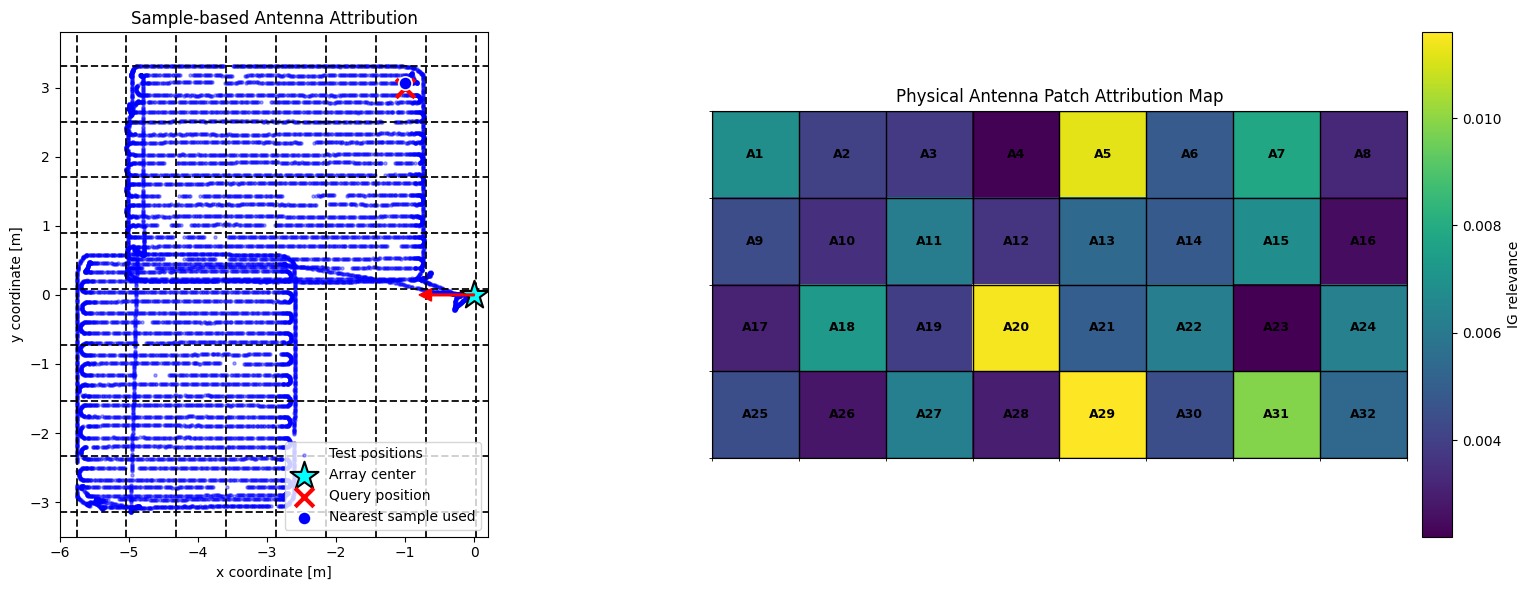

Query position: (-1.0, 3.0)
Used sample index: 1667
Used sample position: [-1.0042851  3.0693936]
Exact match used: False
Distance query to used sample: 0.069526 m
Array center: [0.0, 0.0, 0.0]
Antenna array pointing direction: [-1.0, 0.0, 0.0]
Array points toward negative x-axis.
2D distance to array center: 3.2295 m
3D distance to array center: 3.2295 m
Top-5 antennas:
['A29', 'A20', 'A5', 'A31', 'A7']
All antennas by importance:
['A29', 'A20', 'A5', 'A31', 'A7', 'A18', 'A1', 'A15', 'A24', 'A27', 'A22', 'A11', 'A13', 'A32', 'A21', 'A6', 'A14', 'A30', 'A25', 'A9', 'A2', 'A19', 'A3', 'A12', 'A10', 'A8', 'A17', 'A28', 'A26', 'A16', 'A4', 'A23']


In [ ]:
# import numpy as np
# from scipy.spatial.distance import cdist
# from matplotlib.colors import Normalize

# # Define antenna_channel_assignments
# antenna_channel_assignments = np.array([
#     [ 0,  1,  2,  3,  4,  5,  6,  7],
#     [ 8,  9, 10, 11, 12, 13, 14, 15],
#     [16, 17, 18, 19, 20, 21, 22, 23],
#     [24, 25, 26, 27, 28, 29, 30, 31]
# ])

# # Define array_center and array_direction based on context (e.g., from original notebook or typical setup)
# # Assuming a default center at origin and direction along negative x-axis
# array_center = np.array([0.0, 0.0, 0.0])  # Example values, adjust if precise values are known
# array_direction = np.array([-1.0, 0.0, 0.0]) # Example: array points towards negative x-axis

# # Define get_sample_based_antenna_importance based on usage and other helper functions
# def get_sample_based_antenna_importance(x_query, y_query, tolerance=1e-6):
#     # Find the closest sample in y_test_ig to (x_query, y_query)
#     query_point = np.array([[x_query, y_query]])
#     distances = cdist(query_point, y_test_ig)
#     min_distance_idx = np.argmin(distances)
#     min_distance = distances[0, min_distance_idx]
#     sample_position = y_test_ig[min_distance_idx:min_distance_idx+1] # Keep dimensions for ig.explain
#     sample_csi = X_test_ig[min_distance_idx:min_distance_idx+1] # Keep dimensions for ig.explain

#     is_exact = min_distance <= tolerance

#     # Calculate Integrated Gradients
#     # ig, mean_baseline, and antenna_importance_from_attr are assumed to be globally available
#     exp_x = ig.explain(sample_csi, baselines=mean_baseline, target=0)
#     exp_y = ig.explain(sample_csi, baselines=mean_baseline, target=1)

#     attr_x = exp_x.attributions[0]
#     attr_y = exp_y.attributions[0]

#     # Note: Using antenna_importance_from_attr as defined in J7LruPevzSe0.
#     imp_x = antenna_importance_from_attr(attr_x)
#     imp_y = antenna_importance_from_attr(attr_y)

#     importance_combined = (imp_x + imp_y) / 2
#     antenna_ranking = np.argsort(importance_combined)[::-1]

#     return {
#         "sample_idx": min_distance_idx,
#         "sample_position": sample_position.flatten(), # Flatten sample_position for consistency with original notebook's likely usage
#         "is_exact": is_exact,
#         "query_to_sample_distance": min_distance,
#         "importance_combined": importance_combined,
#         "antenna_ranking": antenna_ranking
#     }

# plot_sample_based_antenna_patch(
#     x_query=-1.0,
#     y_query=3.0
# )

In [34]:
# # ============================================================
# # Antenna Ablation Test
# # ONLY plot: Localization Error vs Important Antennas + Random Guess
# # Uses IG ranking computed from Train + Validation only
# # ============================================================

# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# RESULT_DIR = "antenna_ablation_results"
# os.makedirs(RESULT_DIR, exist_ok=True)

# # ------------------------------------------------------------
# # 1. Model for ablation
# # ------------------------------------------------------------

# if "nn" in globals() and hasattr(nn, "predict"):
#     ablation_model = nn
#     print("Using model: nn")
# else:
#     raise RuntimeError(
#         "Model 'nn' not found. Train or load nn before ablation."
#     )


# # ------------------------------------------------------------
# # 2. Test data
# # ------------------------------------------------------------

# if "test_runs" not in globals():
#     raise RuntimeError(
#         "test_runs not found. Load cached runs or TFRecords first."
#     )

# X_ablation = np.concatenate(
#     [run["X_csi"] for run in test_runs],
#     axis=0
# ).astype(np.float32)

# y_ablation = np.concatenate(
#     [run["pos"] for run in test_runs],
#     axis=0
# ).astype(np.float32)

# print("X_ablation:", X_ablation.shape)
# print("y_ablation:", y_ablation.shape)

# if X_ablation.shape[1] != 32:
#     raise ValueError(
#         f"Expected 32 antennas at axis=1, got {X_ablation.shape}"
#     )


# # ------------------------------------------------------------
# # 3. Antenna ranking from IG
# # ------------------------------------------------------------
# # Important:
# # antenna_ranking_global must be computed from Train + Validation IG only.
# # Do NOT use a hard-coded ranking and do NOT use Test IG for ranking.

# if "antenna_ranking_global" not in globals():
#     raise RuntimeError(
#         "antenna_ranking_global not found. Run the corrected IG + ranking cell first."
#     )

# antenna_ranking_global = np.asarray(
#     antenna_ranking_global,
#     dtype=int
# )

# if antenna_ranking_global.shape[0] != 32:
#     raise ValueError(
#         f"antenna_ranking_global must contain 32 antennas, got {antenna_ranking_global.shape}"
#     )

# print("Antenna ranking from Train + Validation IG:")
# print([f"A{i + 1}" for i in antenna_ranking_global])


# # ------------------------------------------------------------
# # 4. Metrics
# # ------------------------------------------------------------

# def compute_localization_metrics(y_true, y_pred):
#     errors = np.linalg.norm(
#         y_true - y_pred,
#         axis=1
#     )

#     metrics = {
#         "mean_error": float(np.mean(errors)),
#         "median_error": float(np.median(errors)),
#         "rmse_error": float(np.sqrt(np.mean(errors ** 2))),
#     }

#     return metrics, errors


# # ------------------------------------------------------------
# # 5. Mask antennas using TRAIN mean
# # ------------------------------------------------------------

# if "X_train_ig" in globals():
#     train_antenna_mean = np.mean(
#         X_train_ig,
#         axis=0,
#         keepdims=True
#     ).astype(np.float32)

# elif "train_runs" in globals():
#     X_train_for_mean = np.concatenate(
#         [run["X_csi"] for run in train_runs],
#         axis=0
#     ).astype(np.float32)

#     train_antenna_mean = np.mean(
#         X_train_for_mean,
#         axis=0,
#         keepdims=True
#     ).astype(np.float32)

# else:
#     raise RuntimeError(
#         "Training CSI not found. Need X_train_ig or train_runs for train-mean masking."
#     )


# def mask_antennas_with_train_mean(X, keep_indices):
#     X_masked = X.copy()

#     all_indices = np.arange(32)
#     keep_indices = np.asarray(
#         keep_indices,
#         dtype=int
#     )

#     remove_indices = np.array(
#         [i for i in all_indices if i not in set(keep_indices)],
#         dtype=int
#     )

#     X_masked[:, remove_indices, ...] = train_antenna_mean[:, remove_indices, ...]

#     return X_masked, remove_indices


# # ------------------------------------------------------------
# # 6. Run IG-ranked antenna ablation
# # ------------------------------------------------------------

# KEEP_PERCENTAGES = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]

# ablation_results = []

# for keep_percentage in KEEP_PERCENTAGES:
#     keep_count = int(round(32 * keep_percentage / 100))
#     keep_count = max(1, min(32, keep_count))

#     selected_indices = antenna_ranking_global[:keep_count]

#     X_masked, removed_indices = mask_antennas_with_train_mean(
#         X_ablation,
#         selected_indices
#     )

#     y_pred = ablation_model.predict(
#         X_masked,
#         batch_size=256,
#         verbose=0
#     )

#     metrics, errors = compute_localization_metrics(
#         y_ablation,
#         y_pred
#     )

#     row = {
#         "keep_percentage": keep_percentage,
#         "keep_count": keep_count,
#         "mean_error": metrics["mean_error"],
#         "median_error": metrics["median_error"],
#         "rmse_error": metrics["rmse_error"],
#     }

#     ablation_results.append(row)

#     print(
#         f"{keep_percentage}% | "
#         f"Mean: {metrics['mean_error']:.4f} m | "
#         f"Median: {metrics['median_error']:.4f} m | "
#         f"RMSE: {metrics['rmse_error']:.4f} m"
#     )

# ablation_df = pd.DataFrame(ablation_results)

# ablation_df.to_csv(
#     os.path.join(
#         RESULT_DIR,
#         "ablation_only_error_results.csv"
#     ),
#     index=False
# )


# # ------------------------------------------------------------
# # 7. Random Guess baseline
# # ------------------------------------------------------------
# # This is location random guessing, not random antenna selection.

# RANDOM_GUESS_REPEATS = 20
# RANDOM_GUESS_SEED = 42

# rng_random_guess = np.random.default_rng(RANDOM_GUESS_SEED)

# # Use TRAIN positions for random-guess bounds
# # Avoid using any statistics from the test set

# y_train_all = np.concatenate(
#     [run["pos"] for run in train_runs],
#     axis=0
# ).astype(np.float32)

# x_min, x_max = (
#     y_train_all[:, 0].min(),
#     y_train_all[:, 0].max()
# )

# y_min, y_max = (
#     y_train_all[:, 1].min(),
#     y_train_all[:, 1].max()
# )

# print("Random guess bounds from TRAIN set:")
# print(f"x range: [{x_min:.3f}, {x_max:.3f}]")
# print(f"y range: [{y_min:.3f}, {y_max:.3f}]")

# random_mean_errors = []
# random_median_errors = []
# random_rmse_errors = []

# for _ in range(RANDOM_GUESS_REPEATS):
#     y_random = np.zeros_like(y_ablation)

#     y_random[:, 0] = rng_random_guess.uniform(
#         x_min,
#         x_max,
#         size=len(y_ablation)
#     )

#     y_random[:, 1] = rng_random_guess.uniform(
#         y_min,
#         y_max,
#         size=len(y_ablation)
#     )

#     random_metrics, _ = compute_localization_metrics(
#         y_ablation,
#         y_random
#     )

#     random_mean_errors.append(random_metrics["mean_error"])
#     random_median_errors.append(random_metrics["median_error"])
#     random_rmse_errors.append(random_metrics["rmse_error"])

# random_guess_mean = float(np.mean(random_mean_errors))
# random_guess_median = float(np.mean(random_median_errors))
# random_guess_rmse = float(np.mean(random_rmse_errors))

# print("\nRandom Guess Baseline")
# print("---------------------")
# print(f"Mean:   {random_guess_mean:.4f} m")
# print(f"Median: {random_guess_median:.4f} m")
# print(f"RMSE:   {random_guess_rmse:.4f} m")


# # ------------------------------------------------------------
# # 8. Plot ONLY this figure
# # ------------------------------------------------------------

# plot_df = ablation_df.sort_values(
#     "keep_percentage",
#     ascending=False
# ).copy()

# plt.figure(figsize=(10, 6))

# plt.plot(
#     plot_df["keep_percentage"],
#     plot_df["mean_error"],
#     marker="o",
#     linewidth=2,
#     label="Mean error"
# )

# plt.plot(
#     plot_df["keep_percentage"],
#     plot_df["median_error"],
#     marker="o",
#     linewidth=2,
#     label="Median error"
# )

# plt.plot(
#     plot_df["keep_percentage"],
#     plot_df["rmse_error"],
#     marker="o",
#     linewidth=2,
#     label="RMSE"
# )

# plt.axhline(
#     random_guess_mean,
#     linestyle="--",
#     linewidth=2,
#     label="Random guess mean"
# )

# plt.axhline(
#     random_guess_median,
#     linestyle="--",
#     linewidth=2,
#     label="Random guess median"
# )

# plt.axhline(
#     random_guess_rmse,
#     linestyle="--",
#     linewidth=2,
#     label="Random guess RMSE"
# )

# plt.xlabel("Percentage of most important antennas kept [%]")
# plt.ylabel("Localization error [m]")
# plt.title("Localization Error vs Percentage of Important Antennas")

# plt.xlim(100, 10)
# plt.xticks(KEEP_PERCENTAGES)

# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()

# plt.savefig(
#     os.path.join(
#         RESULT_DIR,
#         "ablation_only_error_with_random_guess.png"
#     ),
#     dpi=250
# )

# plt.show()

In [35]:
# # ============================================================
# # Random Antenna Selection Ablation Only
# # Percentage of randomly selected antennas kept vs localization error
# # ============================================================

# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# RESULT_DIR = "antenna_ablation_results"
# os.makedirs(RESULT_DIR, exist_ok=True)

# RANDOM_SELECTION_SEED = 42
# rng = np.random.default_rng(RANDOM_SELECTION_SEED)

# KEEP_PERCENTAGES_RANDOM = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]
# RANDOM_SELECTION_REPEATS = 20


# # ------------------------------------------------------------
# # 1. Model for random ablation
# # ------------------------------------------------------------

# if "ablation_model" in globals() and hasattr(ablation_model, "predict"):
#     print("Using existing ablation_model")
# elif "nn" in globals() and hasattr(nn, "predict"):
#     ablation_model = nn
#     print("Using model: nn")
# else:
#     raise RuntimeError(
#         "No ablation_model found. Train or load nn first."
#     )


# # ------------------------------------------------------------
# # 2. Test data
# # ------------------------------------------------------------

# if "X_ablation" in globals() and "y_ablation" in globals():
#     X_random_ablation = X_ablation.astype(np.float32)
#     y_random_ablation = y_ablation.astype(np.float32)

# elif "test_runs" in globals():
#     X_random_ablation = np.concatenate(
#         [run["X_csi"] for run in test_runs],
#         axis=0
#     ).astype(np.float32)

#     y_random_ablation = np.concatenate(
#         [run["pos"] for run in test_runs],
#         axis=0
#     ).astype(np.float32)

# else:
#     raise RuntimeError(
#         "X_ablation/y_ablation not found and test_runs is not available."
#     )

# print("X_random_ablation:", X_random_ablation.shape)
# print("y_random_ablation:", y_random_ablation.shape)

# if X_random_ablation.shape[1] != 32:
#     raise ValueError(
#         f"Expected 32 antennas at axis=1, got shape {X_random_ablation.shape}"
#     )


# # ------------------------------------------------------------
# # 3. Metrics
# # ------------------------------------------------------------

# def compute_localization_metrics_random(y_true, y_pred):
#     errors = np.linalg.norm(
#         y_true - y_pred,
#         axis=1
#     )

#     metrics = {
#         "mean_error": float(np.mean(errors)),
#         "median_error": float(np.median(errors)),
#         "rmse_error": float(np.sqrt(np.mean(errors ** 2))),
#     }

#     return metrics, errors


# # ------------------------------------------------------------
# # 4. Train mean masking
# # ------------------------------------------------------------
# # Removed antennas are replaced by TRAIN mean, not test mean.

# if "X_train_ig" in globals():
#     train_antenna_mean_random = np.mean(
#         X_train_ig,
#         axis=0,
#         keepdims=True
#     ).astype(np.float32)

# elif "train_runs" in globals():
#     X_train_for_mean_random = np.concatenate(
#         [run["X_csi"] for run in train_runs],
#         axis=0
#     ).astype(np.float32)

#     train_antenna_mean_random = np.mean(
#         X_train_for_mean_random,
#         axis=0,
#         keepdims=True
#     ).astype(np.float32)

# else:
#     raise RuntimeError(
#         "Training CSI not found. Need X_train_ig or train_runs for train-mean masking."
#     )


# def mask_antennas_with_train_mean_random(X, keep_indices):
#     X_masked = X.copy()

#     all_indices = np.arange(32)
#     keep_indices = np.asarray(
#         keep_indices,
#         dtype=int
#     )

#     remove_indices = np.array(
#         [i for i in all_indices if i not in set(keep_indices)],
#         dtype=int
#     )

#     X_masked[:, remove_indices, ...] = train_antenna_mean_random[:, remove_indices, ...]

#     return X_masked, remove_indices


# # ------------------------------------------------------------
# # 5. Run random antenna ablation
# # ------------------------------------------------------------

# random_ablation_results = []

# for keep_percentage in KEEP_PERCENTAGES_RANDOM:

#     keep_count = int(round(32 * keep_percentage / 100))
#     keep_count = max(1, min(32, keep_count))

#     mean_errors = []
#     median_errors = []
#     rmse_errors = []

#     print("\n" + "=" * 80)
#     print(f"Random antenna ablation: keeping {keep_percentage}% antennas")
#     print(f"Keeping {keep_count}/32 random antennas")
#     print(f"Repeats: {RANDOM_SELECTION_REPEATS}")

#     for repeat in range(RANDOM_SELECTION_REPEATS):

#         random_indices = rng.choice(
#             32,
#             size=keep_count,
#             replace=False
#         )

#         X_masked, _ = mask_antennas_with_train_mean_random(
#             X_random_ablation,
#             random_indices
#         )

#         y_pred = ablation_model.predict(
#             X_masked,
#             batch_size=256,
#             verbose=0
#         )

#         metrics, _ = compute_localization_metrics_random(
#             y_random_ablation,
#             y_pred
#         )

#         mean_errors.append(metrics["mean_error"])
#         median_errors.append(metrics["median_error"])
#         rmse_errors.append(metrics["rmse_error"])

#     row = {
#         "keep_percentage": keep_percentage,
#         "keep_count": keep_count,

#         "mean_error": float(np.mean(mean_errors)),
#         "median_error": float(np.mean(median_errors)),
#         "rmse_error": float(np.mean(rmse_errors)),

#         "mean_error_std": float(np.std(mean_errors)),
#         "median_error_std": float(np.std(median_errors)),
#         "rmse_error_std": float(np.std(rmse_errors)),
#     }

#     random_ablation_results.append(row)

#     print(f"Mean error:   {row['mean_error']:.4f} ± {row['mean_error_std']:.4f} m")
#     print(f"Median error: {row['median_error']:.4f} ± {row['median_error_std']:.4f} m")
#     print(f"RMSE error:   {row['rmse_error']:.4f} ± {row['rmse_error_std']:.4f} m")


# random_ablation_df = pd.DataFrame(random_ablation_results)

# random_ablation_df.to_csv(
#     os.path.join(
#         RESULT_DIR,
#         "random_only_antenna_ablation_results.csv"
#     ),
#     index=False
# )

# display(random_ablation_df)


# # ------------------------------------------------------------
# # 6. Plot ONLY random antenna selection
# # ------------------------------------------------------------

# random_plot_df = random_ablation_df.sort_values(
#     "keep_percentage",
#     ascending=False
# ).copy()

# plt.figure(figsize=(10, 6))

# plt.plot(
#     random_plot_df["keep_percentage"],
#     random_plot_df["mean_error"],
#     marker="o",
#     linewidth=2,
#     label="Mean error"
# )

# plt.plot(
#     random_plot_df["keep_percentage"],
#     random_plot_df["median_error"],
#     marker="o",
#     linewidth=2,
#     label="Median error"
# )

# plt.plot(
#     random_plot_df["keep_percentage"],
#     random_plot_df["rmse_error"],
#     marker="o",
#     linewidth=2,
#     label="RMSE"
# )

# plt.fill_between(
#     random_plot_df["keep_percentage"],
#     random_plot_df["mean_error"] - random_plot_df["mean_error_std"],
#     random_plot_df["mean_error"] + random_plot_df["mean_error_std"],
#     alpha=0.15,
#     label="Mean error ±1 std"
# )

# plt.xlabel("Percentage of randomly selected antennas kept [%]")
# plt.ylabel("Localization error [m]")
# plt.title("Localization Error vs Percentage of Randomly Selected Antennas")

# plt.xlim(100, 10)
# plt.xticks(KEEP_PERCENTAGES_RANDOM)

# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()

# plt.savefig(
#     os.path.join(
#         RESULT_DIR,
#         "random_only_ablation_error_vs_percentage.png"
#     ),
#     dpi=250
# )

# plt.show()

***build_ig_source_model***

In [9]:
# ============================================================
# IG SOURCE MODEL
# Used ONLY for Integrated Gradients ranking
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


def build_ig_source_model(seed=42):

    tf.keras.backend.clear_session()

    np.random.seed(seed)
    tf.random.set_seed(seed)

    csi_input = tf.keras.Input(
        shape=(32, 32, 2),
        name="ig_csi_input"
    )

    x = tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    )(csi_input)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(0.10)(x)

    x = tf.keras.layers.Dense(
        48,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(0.05)(x)

    output = tf.keras.layers.Dense(
        2,
        activation="linear",
        name="position_output"
    )(x)

    model = tf.keras.Model(
        inputs=csi_input,
        outputs=output,
        name="ig_source_csi_only_model"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=2e-4
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [10]:
def concatenate_current_position_data(runs):

    X_csi = np.concatenate(
        [r["X_csi"] for r in runs],
        axis=0
    ).astype(np.float32)

    y_pos = np.concatenate(
        [r["pos"] for r in runs],
        axis=0
    ).astype(np.float32)

    return X_csi, y_pos

In [12]:
X_ig_train_csi, y_ig_train_pos = concatenate_current_position_data(train_runs)
X_ig_val_csi, y_ig_val_pos = concatenate_current_position_data(val_runs)

ig_pos_mean = y_ig_train_pos.mean(axis=0, keepdims=True)
ig_pos_std = y_ig_train_pos.std(axis=0, keepdims=True) + 1e-8

y_ig_train_pos_norm = (
    y_ig_train_pos - ig_pos_mean
) / ig_pos_std

y_ig_val_pos_norm = (
    y_ig_val_pos - ig_pos_mean
) / ig_pos_std

print("X_ig_train_csi:", X_ig_train_csi.shape)
print("y_ig_train_pos_norm:", y_ig_train_pos_norm.shape)

print("X_ig_val_csi:", X_ig_val_csi.shape)
print("y_ig_val_pos_norm:", y_ig_val_pos_norm.shape)

X_ig_train_csi: (43930, 32, 32, 2)
y_ig_train_pos_norm: (43930, 2)
X_ig_val_csi: (14511, 32, 32, 2)
y_ig_val_pos_norm: (14511, 2)


In [13]:
SEED = 42

BATCH_SIZE = 64

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("SEED:", SEED)
print("BATCH_SIZE:", BATCH_SIZE)

SEED: 42
BATCH_SIZE: 64


In [14]:
ig_train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_ig_train_csi,
        y_ig_train_pos_norm.astype(np.float32)
    )
)

ig_val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_ig_val_csi,
        y_ig_val_pos_norm.astype(np.float32)
    )
)

ig_train_dataset = (
    ig_train_dataset
    .shuffle(
        20000,
        seed=tf.constant(SEED, dtype=tf.int64),
        reshuffle_each_iteration=False
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ig_val_dataset = (
    ig_val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [15]:
# ============================================================
# Load IG Source Model if exists
# Otherwise train and save (FAST VERSION)
# ============================================================

import os
import tensorflow as tf

IG_MODEL_PATH = (
    "/content/drive/MyDrive/dichasus_cache/"
    "ig_source_csi_only_model.keras"
)

os.makedirs(
    os.path.dirname(IG_MODEL_PATH),
    exist_ok=True
)

if os.path.exists(IG_MODEL_PATH):

    print("Loading cached IG source model...")

    ig_source_model = tf.keras.models.load_model(
        IG_MODEL_PATH
    )

    print("IG source model loaded successfully.")
    print("Path:", IG_MODEL_PATH)

else:

    print("No cached model found.")
    print("Training IG source model...")

    ig_source_model = build_ig_source_model(
        seed=SEED
    )

    callbacks = [

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=IG_MODEL_PATH,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1
        )
    ]

    history = ig_source_model.fit(
        ig_train_dataset,
        validation_data=ig_val_dataset,
        epochs=25,
        callbacks=callbacks,
        verbose=1
    )

    print("Training finished.")
    print("Best model saved to:")
    print(IG_MODEL_PATH)

    print("Reloading best saved IG source model...")

    ig_source_model = tf.keras.models.load_model(
        IG_MODEL_PATH
    )

    print("Best IG source model loaded successfully.")

print("\nIG source model is ready.")

Loading cached IG source model...
IG source model loaded successfully.
Path: /content/drive/MyDrive/dichasus_cache/ig_source_csi_only_model.keras

IG source model is ready.


In [16]:
# ============================================================
# Use ig_source_model as IG attribution model
# ============================================================

if "ig_source_model" not in globals():
    raise RuntimeError(
        "ig_source_model not found. Train or load it first."
    )

localization_model = ig_source_model

print("Using ig_source_model for Integrated Gradients")
print(localization_model.name)

Using ig_source_model for Integrated Gradients
ig_source_csi_only_model


In [17]:
print("ig_source_model exists:", "ig_source_model" in globals())

print(
    "model name:",
    ig_source_model.name
)

ig_source_model exists: True
model name: ig_source_csi_only_model


In [18]:
# ============================================================
# IG Source Model -> Integrated Gradients -> Antenna Ranking
# Ranking computed from Train + Validation only
# ============================================================

import os
import numpy as np
import tensorflow as tf

# ------------------------------------------------------------
# 1. Use IG source model
# ------------------------------------------------------------

if "ig_source_model" not in globals():
    raise RuntimeError("ig_source_model not found. Train or load it first.")

localization_model = ig_source_model

print("Using model for IG:", localization_model.name)


# ------------------------------------------------------------
# 2. Mean baseline from TRAIN CSI only
# ------------------------------------------------------------

def compute_mean_baseline_from_runs(runs):
    all_csi = np.concatenate(
        [r["X_csi"] for r in runs],
        axis=0
    ).astype(np.float32)

    return np.mean(
        all_csi,
        axis=0,
        keepdims=True
    ).astype(np.float32)


mean_baseline_ig_source = compute_mean_baseline_from_runs(train_runs)

print("Mean baseline shape:", mean_baseline_ig_source.shape)


# ------------------------------------------------------------
# 3. IG helper functions
# ------------------------------------------------------------

def antenna_importance_from_attribution(attr):
    attr = np.asarray(attr)

    attr_magnitude = np.sqrt(
        attr[..., 0] ** 2 +
        attr[..., 1] ** 2
    )

    antenna_importance = np.mean(
        attr_magnitude,
        axis=2
    )

    return antenna_importance.astype(np.float32)


def integrated_gradients_importance(
    model,
    X,
    baseline,
    steps=50,
    batch_size=64,
    normalize_importance=False
):
    X = X.astype(np.float32)
    baseline = baseline.astype(np.float32)

    all_importances = []
    n = X.shape[0]

    alphas = tf.linspace(0.0, 1.0, steps)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        X_batch = X[start:end]
        B = X_batch.shape[0]

        X_batch_tf = tf.convert_to_tensor(X_batch, dtype=tf.float32)

        baseline_tf = tf.convert_to_tensor(
            np.repeat(baseline, B, axis=0),
            dtype=tf.float32
        )

        total_grad_x = tf.zeros_like(X_batch_tf)
        total_grad_y = tf.zeros_like(X_batch_tf)

        for i, alpha in enumerate(alphas):
            interpolated = baseline_tf + alpha * (X_batch_tf - baseline_tf)

            with tf.GradientTape(persistent=True) as tape:
                tape.watch(interpolated)

                pred = model(interpolated, training=False)

                output_x = pred[:, 0]
                output_y = pred[:, 1]

            grad_x = tape.gradient(output_x, interpolated)
            grad_y = tape.gradient(output_y, interpolated)

            if grad_x is None or grad_y is None:
                raise RuntimeError("Gradient is None.")

            weight = 0.5 if (i == 0 or i == steps - 1) else 1.0

            total_grad_x += weight * grad_x
            total_grad_y += weight * grad_y

            del tape

        avg_grad_x = total_grad_x / tf.cast(steps - 1, tf.float32)
        avg_grad_y = total_grad_y / tf.cast(steps - 1, tf.float32)

        attr_x = (X_batch_tf - baseline_tf) * avg_grad_x
        attr_y = (X_batch_tf - baseline_tf) * avg_grad_y

        attr_combined = tf.sqrt(
            tf.square(attr_x) +
            tf.square(attr_y)
        )

        batch_importance = antenna_importance_from_attribution(
            attr_combined.numpy()
        )

        if normalize_importance:
            batch_importance = batch_importance / (
                np.sum(batch_importance, axis=1, keepdims=True) + 1e-8
            )

        all_importances.append(batch_importance)

        print(f"Computed IG importance: {end}/{n}")

    return np.vstack(all_importances).astype(np.float32)


def add_importance_to_runs_ig_source(
    runs,
    model,
    baseline,
    steps=50,
    batch_size=64,
    normalize_importance=False
):
    for r in runs:
        print("\nComputing IG source importance for:", r["file"])

        r["importance_ig_source"] = integrated_gradients_importance(
            model=model,
            X=r["X_csi"],
            baseline=baseline,
            steps=steps,
            batch_size=batch_size,
            normalize_importance=normalize_importance
        )

        print("Importance shape:", r["importance_ig_source"].shape)

    return runs


# ------------------------------------------------------------
# 4. Cache IG source importance
# ------------------------------------------------------------

IG_SOURCE_CACHE_DIR = "/content/drive/MyDrive/dichasus_cache/ig_source_importance"
os.makedirs(IG_SOURCE_CACHE_DIR, exist_ok=True)

IG_SOURCE_STEPS = 50
IG_SOURCE_BATCH_SIZE = 64
NORMALIZE_IG_SOURCE_IMPORTANCE = False

TRAIN_IG_SOURCE_CACHE = os.path.join(
    IG_SOURCE_CACHE_DIR,
    f"train_ig_source_importance_steps{IG_SOURCE_STEPS}_norm{NORMALIZE_IG_SOURCE_IMPORTANCE}.npz"
)

VAL_IG_SOURCE_CACHE = os.path.join(
    IG_SOURCE_CACHE_DIR,
    f"val_ig_source_importance_steps{IG_SOURCE_STEPS}_norm{NORMALIZE_IG_SOURCE_IMPORTANCE}.npz"
)


def save_ig_source_importance_runs(runs, output_path):
    data = {}

    for i, r in enumerate(runs):
        data[f"file_{i}"] = r["file"]
        data[f"importance_{i}"] = r["importance_ig_source"]

    data["num_runs"] = len(runs)

    np.savez_compressed(output_path, **data)

    print("Saved:", output_path)


def load_ig_source_importance_runs(runs, input_path):
    loaded = np.load(input_path, allow_pickle=True)

    num_runs = int(loaded["num_runs"])

    if num_runs != len(runs):
        raise ValueError(
            f"Cache has {num_runs} runs but current runs has {len(runs)} runs."
        )

    for i, r in enumerate(runs):
        cached_file = str(loaded[f"file_{i}"])

        if os.path.basename(cached_file) != os.path.basename(r["file"]):
            raise ValueError(
                f"File mismatch: cache={cached_file}, current={r['file']}"
            )

        r["importance_ig_source"] = loaded[f"importance_{i}"].astype(np.float32)

        print(
            "Loaded:",
            os.path.basename(r["file"]),
            r["importance_ig_source"].shape
        )

    return runs


if os.path.exists(TRAIN_IG_SOURCE_CACHE):
    print("Loading cached train IG source importance...")
    train_runs = load_ig_source_importance_runs(
        train_runs,
        TRAIN_IG_SOURCE_CACHE
    )
else:
    print("Computing train IG source importance...")
    train_runs = add_importance_to_runs_ig_source(
        train_runs,
        model=localization_model,
        baseline=mean_baseline_ig_source,
        steps=IG_SOURCE_STEPS,
        batch_size=IG_SOURCE_BATCH_SIZE,
        normalize_importance=NORMALIZE_IG_SOURCE_IMPORTANCE
    )

    save_ig_source_importance_runs(
        train_runs,
        TRAIN_IG_SOURCE_CACHE
    )


if os.path.exists(VAL_IG_SOURCE_CACHE):
    print("Loading cached validation IG source importance...")
    val_runs = load_ig_source_importance_runs(
        val_runs,
        VAL_IG_SOURCE_CACHE
    )
else:
    print("Computing validation IG source importance...")
    val_runs = add_importance_to_runs_ig_source(
        val_runs,
        model=localization_model,
        baseline=mean_baseline_ig_source,
        steps=IG_SOURCE_STEPS,
        batch_size=IG_SOURCE_BATCH_SIZE,
        normalize_importance=NORMALIZE_IG_SOURCE_IMPORTANCE
    )

    save_ig_source_importance_runs(
        val_runs,
        VAL_IG_SOURCE_CACHE
    )


# ------------------------------------------------------------
# 5. Global ranking from Train + Validation only
# ------------------------------------------------------------

train_importance_ig_source_all = np.concatenate(
    [r["importance_ig_source"] for r in train_runs],
    axis=0
)

val_importance_ig_source_all = np.concatenate(
    [r["importance_ig_source"] for r in val_runs],
    axis=0
)

global_importance_ig_source = np.concatenate(
    [
        train_importance_ig_source_all,
        val_importance_ig_source_all
    ],
    axis=0
).mean(axis=0)

antenna_ranking_global_ig_source = np.argsort(
    global_importance_ig_source
)[::-1]

antenna_ranking_names_ig_source = [
    f"A{i + 1}" for i in antenna_ranking_global_ig_source
]

print("\nIG Source Global Antenna Ranking:")
print(antenna_ranking_names_ig_source)

print("\nIG Source Global Importance Values:")
for rank, ant_idx in enumerate(antenna_ranking_global_ig_source, start=1):
    print(
        f"{rank:02d}) A{ant_idx + 1:02d} | "
        f"importance = {global_importance_ig_source[ant_idx]:.8f}"
    )

Using model for IG: ig_source_csi_only_model
Mean baseline shape: (1, 32, 32, 2)
Loading cached train IG source importance...
Loaded: dichasus-0152.tfrecords (13496, 32)
Loaded: dichasus-0153.tfrecords (14297, 32)
Loaded: dichasus-0155.tfrecords (16137, 32)
Loading cached validation IG source importance...
Loaded: dichasus-0157.tfrecords (14511, 32)

IG Source Global Antenna Ranking:
['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31', 'A2', 'A7', 'A12', 'A4', 'A14', 'A6', 'A5', 'A11', 'A24', 'A18', 'A13', 'A25', 'A30', 'A3', 'A21', 'A8', 'A28', 'A15', 'A19', 'A10', 'A23', 'A20', 'A17', 'A1', 'A32']

IG Source Global Importance Values:
01) A27 | importance = 0.01292850
02) A22 | importance = 0.01240900
03) A16 | importance = 0.01221187
04) A09 | importance = 0.01208412
05) A29 | importance = 0.01187053
06) A26 | importance = 0.01179017
07) A31 | importance = 0.01178331
08) A02 | importance = 0.01175346
09) A07 | importance = 0.01173090
10) A12 | importance = 0.01154617
11) A04 | importance

In [19]:
print(train_runs[0]["importance_ig_source"].shape)
print(train_runs[0]["pos"].shape)

(13496, 32)
(13496, 2)


Required run objects found.
Processing source: train
Rows: 43930
Saved source CSV:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/location_wise_ig_antenna_ranking_train.csv
Processing source: val
Rows: 14511
Saved source CSV:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/location_wise_ig_antenna_ranking_val.csv
Processing source: test
Skipping test run 0: 'importance_ig_source' not found. Available keys: ['file', 'X_csi', 'pos', 'time']
No location-wise IG data found for source: test. This source will be skipped.
All available location-wise antenna rankings saved:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/location_wise_ig_antenna_ranking_all_available_sources.csv
Total rows: 58441


,source,run_index,run_name,sample_index,timestamp,actual_x,actual_y,importance_sum,importance_max,top1_antenna,...,rank29_score,rank30_antenna,rank30_antenna_index_zero_based,rank30_score,rank31_antenna,rank31_antenna_index_zero_based,rank31_score,rank32_antenna,rank32_antenna_index_zero_based,rank32_score
0,train,0,dichasus-0152.tfrecords,0,996.504028,0.010465,-0.000622,0.338506,0.019858,A16,...,0.006965,A8,7,0.005178,A29,28,0.004974,A21,20,0.004917
1,train,0,dichasus-0152.tfrecords,1,996.552002,0.010486,-0.000574,0.312737,0.021125,A16,...,0.005904,A32,31,0.005736,A21,20,0.004706,A8,7,0.003598
2,train,0,dichasus-0152.tfrecords,2,996.599976,0.010464,-0.000630,0.299222,0.018473,A16,...,0.006070,A18,17,0.005990,A20,19,0.005725,A21,20,0.005342
3,train,0,dichasus-0152.tfrecords,3,996.648010,0.010530,-0.000474,0.344615,0.021617,A16,...,0.007091,A21,20,0.006531,A30,29,0.005163,A15,14,0.005101
4,train,0,dichasus-0152.tfrecords,4,996.695984,0.010500,-0.000541,0.341844,0.020278,A16,...,0.006696,A32,31,0.006206,A2,1,0.006049,A8,7,0.004787



Compact ranking CSV saved:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/location_wise_ig_antenna_ranking_compact.csv


,source,run_index,run_name,sample_index,timestamp,actual_x,actual_y,rank1_antenna,rank1_score,rank2_antenna,...,rank28_antenna,rank28_score,rank29_antenna,rank29_score,rank30_antenna,rank30_score,rank31_antenna,rank31_score,rank32_antenna,rank32_score
0,train,0,dichasus-0152.tfrecords,0,996.504028,0.010465,-0.000622,A16,0.019858,A22,...,A25,0.007355,A32,0.006965,A8,0.005178,A29,0.004974,A21,0.004917
1,train,0,dichasus-0152.tfrecords,1,996.552002,0.010486,-0.000574,A16,0.021125,A1,...,A19,0.006526,A29,0.005904,A32,0.005736,A21,0.004706,A8,0.003598
2,train,0,dichasus-0152.tfrecords,2,996.599976,0.010464,-0.000630,A16,0.018473,A1,...,A30,0.006308,A32,0.006070,A18,0.005990,A20,0.005725,A21,0.005342
3,train,0,dichasus-0152.tfrecords,3,996.648010,0.010530,-0.000474,A16,0.021617,A12,...,A2,0.007300,A19,0.007091,A21,0.006531,A30,0.005163,A15,0.005101
4,train,0,dichasus-0152.tfrecords,4,996.695984,0.010500,-0.000541,A16,0.020278,A1,...,A20,0.006849,A21,0.006696,A32,0.006206,A2,0.006049,A8,0.004787



Antenna summary saved:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/antenna_summary_from_location_wise_ig_ranking.csv


,antenna,antenna_index_zero_based,mean_importance_over_locations,median_importance_over_locations,std_importance_over_locations,min_importance_over_locations,max_importance_over_locations,top1_count,top1_percent
0,A27,26,0.012929,0.012199,0.004438,0.003249,0.058312,3513,6.011191
1,A22,21,0.012409,0.011983,0.004753,0.001830,0.053048,3863,6.610085
2,A16,15,0.012212,0.011571,0.005105,0.001052,0.059019,5455,9.334200
3,A9,8,0.012084,0.011537,0.004087,0.001430,0.047719,2121,3.629301
4,A29,28,0.011871,0.011392,0.004544,0.001870,0.049113,4136,7.077223
5,A26,25,0.011790,0.011195,0.004160,0.002681,0.048033,1847,3.160452
6,A31,30,0.011783,0.011213,0.003973,0.003259,0.052542,1491,2.551291
7,A2,1,0.011753,0.011297,0.004588,0.001497,0.050334,3120,5.338718
8,A7,6,0.011731,0.011137,0.003870,0.002813,0.050509,1884,3.223764
9,A12,11,0.011546,0.011106,0.004115,0.002192,0.056506,1423,2.434934



Global ranking recomputed from location-wise IG saved:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/global_ranking_recomputed_from_location_wise_ig.csv


,global_rank,antenna,antenna_index_zero_based,global_importance_from_location_mean
0,1,A27,26,0.012929
1,2,A22,21,0.012409
2,3,A16,15,0.012212
3,4,A9,8,0.012084
4,5,A29,28,0.011871
5,6,A26,25,0.011790
6,7,A31,30,0.011783
7,8,A2,1,0.011753
8,9,A7,6,0.011731
9,10,A12,11,0.011546


Query point: x=2.0, y=3.0
Nearest actual location:
  source       : train
  run_index    : 1
  sample_index : 5544
  actual_x     : -0.7399918437004089
  actual_y     : 3.0112786293029785
  distance     : 2.7400150299072266
--------------------------------------------------------------------------------
Top 10 antennas at this actual location:
01) A12 | importance = 0.030338579788804054
02) A4 | importance = 0.028062954545021057
03) A13 | importance = 0.026333771646022797
04) A14 | importance = 0.025798432528972626
05) A20 | importance = 0.02468176931142807
06) A18 | importance = 0.022661559283733368
07) A25 | importance = 0.02207236923277378
08) A10 | importance = 0.021816441789269447
09) A24 | importance = 0.02110951393842697
10) A6 | importance = 0.02051103115081787


,rank,antenna,importance
0,1,A12,0.030339
1,2,A4,0.028063
2,3,A13,0.026334
3,4,A14,0.025798
4,5,A20,0.024682
5,6,A18,0.022662
6,7,A25,0.022072
7,8,A10,0.021816
8,9,A24,0.021110
9,10,A6,0.020511


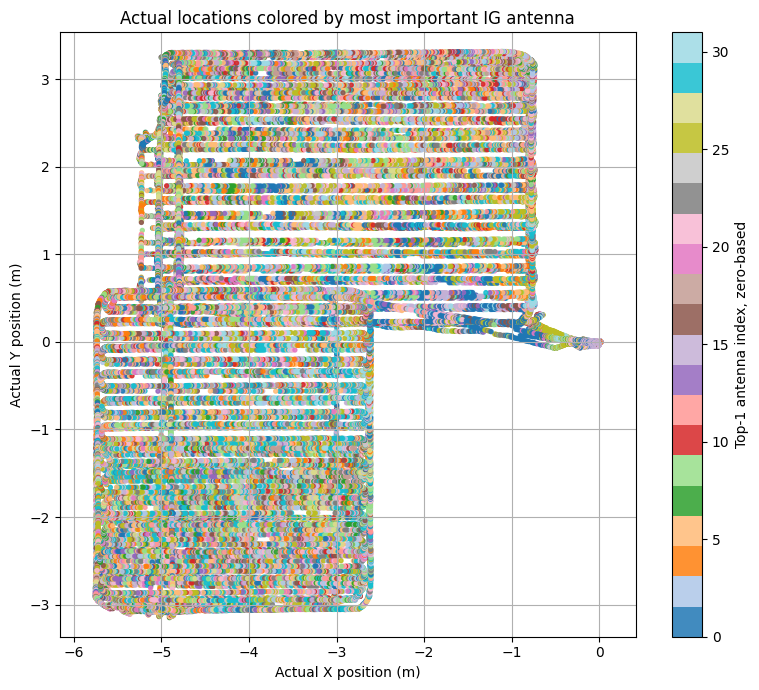


Top-1 location plot saved:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/actual_locations_colored_by_top1_ig_antenna.png
Location-wise IG antenna ranking completed.
Main full CSV:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/location_wise_ig_antenna_ranking_all_available_sources.csv

Compact ranking CSV:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/location_wise_ig_antenna_ranking_compact.csv

Antenna summary CSV:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/antenna_summary_from_location_wise_ig_ranking.csv

Global recomputed CSV:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/global_ranking_recomputed_from_location_wise_ig.csv

Importance matrix NPZ:
/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/location_wise_ig_antenna_ranking_matrix.npz

Top-1 

In [20]:
# ============================================================
# LOCATION-WISE ANTENNA RANKING USING EXISTING IG SOURCE
#
# Goal:
#   For every actual location in the dataset, list antennas ranked by IG importance.
#
# Already available inside runs:
#   run["pos"]                  -> actual locations, shape (N, 2)
#   run["importance_ig_source"] -> IG antenna importance per location, shape (N, 32)
#
# Outputs:
#   1) CSV with all actual locations and antenna ranking from rank1 to rank32
#   2) CSV per source: train / val / test when available
#   3) CSV summary per antenna
#   4) Function to query nearest actual location to any coordinate, e.g. (2, 3)
#   5) Plot: actual locations colored by most important antenna
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking"

os.makedirs(SAVE_DIR, exist_ok=True)

IMPORTANCE_KEY = "importance_ig_source"

RUN_SOURCES_TO_ANALYZE = [
    "train",
    "val",
    "test"
]

NUM_ANTENNAS = 32

TOP_K_TO_PRINT = 10

SHOW_PLOTS = True


# ============================================================
# REQUIRED OBJECTS CHECK
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(f"{obj} is not defined.")

print("Required run objects found.")


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_runs_by_source(source_name):
    if source_name == "train":
        return train_runs
    elif source_name == "val":
        return val_runs
    elif source_name == "test":
        return test_runs
    else:
        raise ValueError("source_name must be train, val, or test.")


def build_location_wise_ranking_table(
    runs,
    source_name,
    importance_key="importance_ig_source",
    num_antennas=32
):
    records = []

    for run_index, run in enumerate(runs):

        if "pos" not in run:
            print(
                f"Skipping {source_name} run {run_index}: "
                f"'pos' not found. Available keys: {list(run.keys())}"
            )
            continue

        if importance_key not in run:
            print(
                f"Skipping {source_name} run {run_index}: "
                f"'{importance_key}' not found. "
                f"Available keys: {list(run.keys())}"
            )
            continue

        pos = run["pos"].astype(np.float32)
        importance = run[importance_key].astype(np.float32)

        if pos.ndim != 2 or pos.shape[1] != 2:
            print(
                f"Skipping {source_name} run {run_index}: "
                f"pos should have shape (N, 2), got {pos.shape}"
            )
            continue

        if importance.ndim != 2:
            print(
                f"Skipping {source_name} run {run_index}: "
                f"importance should be 2D, got {importance.shape}"
            )
            continue

        if pos.shape[0] != importance.shape[0]:
            print(
                f"Skipping {source_name} run {run_index}: length mismatch. "
                f"pos rows = {pos.shape[0]}, importance rows = {importance.shape[0]}"
            )
            continue

        if importance.shape[1] != num_antennas:
            print(
                f"Skipping {source_name} run {run_index}: "
                f"expected {num_antennas} antennas, got {importance.shape[1]}"
            )
            continue

        if "time" in run:
            time_values = run["time"]
        elif "timestamp" in run:
            time_values = run["timestamp"]
        else:
            time_values = np.arange(pos.shape[0])

        run_name = os.path.basename(
            str(
                run.get(
                    "file",
                    f"{source_name}_run_{run_index}"
                )
            )
        )

        # ranking_indices[i, 0] = most important antenna for location i
        ranking_indices = np.argsort(
            importance,
            axis=1
        )[:, ::-1]

        for sample_index in range(pos.shape[0]):
            row = {
                "source": source_name,
                "run_index": run_index,
                "run_name": run_name,
                "sample_index": sample_index,
                "timestamp": time_values[sample_index],
                "actual_x": float(pos[sample_index, 0]),
                "actual_y": float(pos[sample_index, 1]),
                "importance_sum": float(np.sum(importance[sample_index])),
                "importance_max": float(np.max(importance[sample_index])),
                "top1_antenna": f"A{int(ranking_indices[sample_index, 0]) + 1}",
                "top1_antenna_index_zero_based": int(ranking_indices[sample_index, 0]),
            }

            # Raw importance values: A1...A32
            for ant_idx in range(num_antennas):
                row[f"A{ant_idx + 1}_importance"] = float(
                    importance[sample_index, ant_idx]
                )

            # Full antenna ranking: rank1...rank32
            for rank in range(num_antennas):
                ant_idx = int(
                    ranking_indices[sample_index, rank]
                )

                row[f"rank{rank + 1}_antenna"] = f"A{ant_idx + 1}"
                row[f"rank{rank + 1}_antenna_index_zero_based"] = ant_idx
                row[f"rank{rank + 1}_score"] = float(
                    importance[sample_index, ant_idx]
                )

            records.append(row)

    if len(records) == 0:
        return pd.DataFrame()

    return pd.DataFrame(records)


# ============================================================
# BUILD TABLES FOR ALL SOURCES
# ============================================================

all_source_tables = []

for source_name in RUN_SOURCES_TO_ANALYZE:
    print("=" * 100)
    print(f"Processing source: {source_name}")

    runs = get_runs_by_source(source_name)

    source_df = build_location_wise_ranking_table(
        runs=runs,
        source_name=source_name,
        importance_key=IMPORTANCE_KEY,
        num_antennas=NUM_ANTENNAS
    )

    if len(source_df) == 0:
        print(
            f"No location-wise IG data found for source: {source_name}. "
            f"This source will be skipped."
        )
        continue

    source_csv_path = os.path.join(
        SAVE_DIR,
        f"location_wise_ig_antenna_ranking_{source_name}.csv"
    )

    source_df.to_csv(
        source_csv_path,
        index=False
    )

    print("Rows:", len(source_df))
    print("Saved source CSV:")
    print(source_csv_path)

    all_source_tables.append(source_df)


if len(all_source_tables) == 0:
    raise RuntimeError(
        "No location-wise IG data found in any source. "
        "Check that at least one run contains 'importance_ig_source'."
    )


location_ranking_df = pd.concat(
    all_source_tables,
    axis=0
).reset_index(drop=True)

all_csv_path = os.path.join(
    SAVE_DIR,
    "location_wise_ig_antenna_ranking_all_available_sources.csv"
)

location_ranking_df.to_csv(
    all_csv_path,
    index=False
)

print("=" * 100)
print("All available location-wise antenna rankings saved:")
print(all_csv_path)
print("Total rows:", len(location_ranking_df))

display(location_ranking_df.head())


# ============================================================
# SAVE COMPACT VERSION
# ============================================================

compact_columns = [
    "source",
    "run_index",
    "run_name",
    "sample_index",
    "timestamp",
    "actual_x",
    "actual_y",
]

for rank in range(NUM_ANTENNAS):
    compact_columns.append(f"rank{rank + 1}_antenna")
    compact_columns.append(f"rank{rank + 1}_score")

compact_ranking_df = location_ranking_df[compact_columns].copy()

compact_csv_path = os.path.join(
    SAVE_DIR,
    "location_wise_ig_antenna_ranking_compact.csv"
)

compact_ranking_df.to_csv(
    compact_csv_path,
    index=False
)

print("\nCompact ranking CSV saved:")
print(compact_csv_path)

display(compact_ranking_df.head())


# ============================================================
# ANTENNA SUMMARY OVER LOCATIONS
# ============================================================

importance_columns = [
    f"A{i + 1}_importance"
    for i in range(NUM_ANTENNAS)
]

importance_matrix = location_ranking_df[
    importance_columns
].values.astype(np.float32)

summary_records = []

for ant_idx in range(NUM_ANTENNAS):
    ant_name = f"A{ant_idx + 1}"
    values = importance_matrix[:, ant_idx]

    top1_count = int(
        np.sum(
            location_ranking_df["top1_antenna"].values == ant_name
        )
    )

    top1_percent = 100.0 * top1_count / len(location_ranking_df)

    summary_records.append({
        "antenna": ant_name,
        "antenna_index_zero_based": ant_idx,
        "mean_importance_over_locations": float(np.mean(values)),
        "median_importance_over_locations": float(np.median(values)),
        "std_importance_over_locations": float(np.std(values)),
        "min_importance_over_locations": float(np.min(values)),
        "max_importance_over_locations": float(np.max(values)),
        "top1_count": top1_count,
        "top1_percent": top1_percent,
    })

antenna_summary_df = pd.DataFrame(summary_records)

antenna_summary_df = antenna_summary_df.sort_values(
    [
        "mean_importance_over_locations",
        "top1_count"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

summary_csv_path = os.path.join(
    SAVE_DIR,
    "antenna_summary_from_location_wise_ig_ranking.csv"
)

antenna_summary_df.to_csv(
    summary_csv_path,
    index=False
)

print("\nAntenna summary saved:")
print(summary_csv_path)

display(antenna_summary_df)


# ============================================================
# GLOBAL RANKING RECOMPUTED FROM ALL LOCATION-WISE VALUES
# ============================================================

global_importance_from_locations = np.mean(
    importance_matrix,
    axis=0
)

global_ranking_indices = np.argsort(
    global_importance_from_locations
)[::-1]

global_ranking_df = pd.DataFrame({
    "global_rank": np.arange(1, NUM_ANTENNAS + 1),
    "antenna": [f"A{i + 1}" for i in global_ranking_indices],
    "antenna_index_zero_based": global_ranking_indices,
    "global_importance_from_location_mean": global_importance_from_locations[
        global_ranking_indices
    ],
})

global_csv_path = os.path.join(
    SAVE_DIR,
    "global_ranking_recomputed_from_location_wise_ig.csv"
)

global_ranking_df.to_csv(
    global_csv_path,
    index=False
)

print("\nGlobal ranking recomputed from location-wise IG saved:")
print(global_csv_path)

display(global_ranking_df)


# ============================================================
# QUERY FUNCTION: NEAREST ACTUAL LOCATION TO (x, y)
# ============================================================

def query_nearest_location_antenna_ranking(
    df,
    x,
    y,
    top_k=10
):
    coordinates = df[
        [
            "actual_x",
            "actual_y"
        ]
    ].values.astype(np.float32)

    target = np.array(
        [
            x,
            y
        ],
        dtype=np.float32
    )

    distances = np.sqrt(
        np.sum(
            (coordinates - target[None, :]) ** 2,
            axis=1
        )
    )

    nearest_idx = int(
        np.argmin(distances)
    )

    row = df.iloc[nearest_idx]

    print("=" * 80)
    print(f"Query point: x={x}, y={y}")
    print(f"Nearest actual location:")
    print(f"  source       : {row['source']}")
    print(f"  run_index    : {row['run_index']}")
    print(f"  sample_index : {row['sample_index']}")
    print(f"  actual_x     : {row['actual_x']}")
    print(f"  actual_y     : {row['actual_y']}")
    print(f"  distance     : {distances[nearest_idx]}")
    print("-" * 80)
    print(f"Top {top_k} antennas at this actual location:")

    result_records = []

    for rank in range(top_k):
        antenna = row[f"rank{rank + 1}_antenna"]
        score = row[f"rank{rank + 1}_score"]

        print(
            f"{rank + 1:02d}) {antenna} | importance = {score}"
        )

        result_records.append({
            "rank": rank + 1,
            "antenna": antenna,
            "importance": score
        })

    return pd.DataFrame(result_records), row


# ============================================================
# EXAMPLE QUERY
# Change this coordinate to any actual/target location you want.
# Example: actual location around (2, 3)
# ============================================================

example_query_df, example_query_row = query_nearest_location_antenna_ranking(
    df=location_ranking_df,
    x=2.0,
    y=3.0,
    top_k=TOP_K_TO_PRINT
)

display(example_query_df)


# ============================================================
# PLOT: LOCATIONS COLORED BY TOP-1 ANTENNA
# ============================================================

plt.figure(figsize=(8, 7))

scatter = plt.scatter(
    location_ranking_df["actual_x"],
    location_ranking_df["actual_y"],
    c=location_ranking_df["top1_antenna_index_zero_based"],
    s=8,
    cmap="tab20",
    alpha=0.85
)

plt.xlabel("Actual X position (m)")
plt.ylabel("Actual Y position (m)")
plt.title("Actual locations colored by most important IG antenna")
plt.axis("equal")
plt.grid(True)

cbar = plt.colorbar(scatter)
cbar.set_label("Top-1 antenna index, zero-based")

plt.tight_layout()

top1_plot_path = os.path.join(
    SAVE_DIR,
    "actual_locations_colored_by_top1_ig_antenna.png"
)

plt.savefig(
    top1_plot_path,
    dpi=200
)

if SHOW_PLOTS:
    plt.show()

plt.close()

print("\nTop-1 location plot saved:")
print(top1_plot_path)


# ============================================================
# SAVE IMPORTANCE MATRIX NPZ
# ============================================================

npz_path = os.path.join(
    SAVE_DIR,
    "location_wise_ig_antenna_ranking_matrix.npz"
)

np.savez_compressed(
    npz_path,
    importance_matrix=importance_matrix,
    antenna_names=np.array([f"A{i + 1}" for i in range(NUM_ANTENNAS)]),
    actual_x=location_ranking_df["actual_x"].values,
    actual_y=location_ranking_df["actual_y"].values,
    source=location_ranking_df["source"].values,
    run_index=location_ranking_df["run_index"].values,
    sample_index=location_ranking_df["sample_index"].values
)

print("=" * 100)
print("Location-wise IG antenna ranking completed.")
print("=" * 100)
print("Main full CSV:")
print(all_csv_path)
print("\nCompact ranking CSV:")
print(compact_csv_path)
print("\nAntenna summary CSV:")
print(summary_csv_path)
print("\nGlobal recomputed CSV:")
print(global_csv_path)
print("\nImportance matrix NPZ:")
print(npz_path)
print("\nTop-1 plot:")
print(top1_plot_path)

In [21]:
df = pd.read_csv(
    "/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/location_wise_ig_antenna_ranking_all_available_sources.csv"
)

display(df.head())
print(df.shape)

,source,run_index,run_name,sample_index,timestamp,actual_x,actual_y,importance_sum,importance_max,top1_antenna,...,rank29_score,rank30_antenna,rank30_antenna_index_zero_based,rank30_score,rank31_antenna,rank31_antenna_index_zero_based,rank31_score,rank32_antenna,rank32_antenna_index_zero_based,rank32_score
0,train,0,dichasus-0152.tfrecords,0,996.504,0.010465,-0.000622,0.338506,0.019858,A16,...,0.006965,A8,7,0.005178,A29,28,0.004974,A21,20,0.004917
1,train,0,dichasus-0152.tfrecords,1,996.552,0.010486,-0.000574,0.312737,0.021125,A16,...,0.005904,A32,31,0.005736,A21,20,0.004706,A8,7,0.003598
2,train,0,dichasus-0152.tfrecords,2,996.600,0.010464,-0.000630,0.299222,0.018473,A16,...,0.006070,A18,17,0.005990,A20,19,0.005725,A21,20,0.005342
3,train,0,dichasus-0152.tfrecords,3,996.648,0.010530,-0.000474,0.344615,0.021617,A16,...,0.007091,A21,20,0.006531,A30,29,0.005163,A15,14,0.005101
4,train,0,dichasus-0152.tfrecords,4,996.696,0.010500,-0.000541,0.341844,0.020278,A16,...,0.006696,A32,31,0.006206,A2,1,0.006049,A8,7,0.004787


(58441, 139)


In [22]:
display(
    df[
        [
            "source",
            "run_index",
            "sample_index",
            "actual_x",
            "actual_y",
            "rank1_antenna",
            "rank1_score",
            "rank2_antenna",
            "rank2_score",
            "rank3_antenna",
            "rank3_score",
            "rank4_antenna",
            "rank4_score",
            "rank5_antenna",
            "rank5_score",
        ]
    ].head(20)
)

,source,run_index,sample_index,actual_x,actual_y,rank1_antenna,rank1_score,rank2_antenna,rank2_score,rank3_antenna,rank3_score,rank4_antenna,rank4_score,rank5_antenna,rank5_score
0,train,0,0,0.010465,-0.000622,A16,0.019858,A22,0.016466,A1,0.015647,A13,0.014487,A27,0.014484
1,train,0,1,0.010486,-0.000574,A16,0.021125,A1,0.018071,A12,0.014414,A13,0.013257,A22,0.013168
2,train,0,2,0.010464,-0.000630,A16,0.018473,A1,0.015465,A12,0.014020,A23,0.012877,A10,0.012819
3,train,0,3,0.010530,-0.000474,A16,0.021617,A12,0.016535,A22,0.014967,A31,0.014738,A23,0.014633
4,train,0,4,0.010500,-0.000541,A16,0.020278,A1,0.016483,A23,0.014811,A13,0.014577,A27,0.014299
5,train,0,5,0.010431,-0.000704,A16,0.022698,A1,0.017894,A12,0.017406,A31,0.015942,A23,0.015529
6,train,0,6,0.010500,-0.000540,A16,0.028457,A29,0.017423,A22,0.017181,A12,0.016330,A8,0.016320
7,train,0,7,0.010500,-0.000540,A16,0.022714,A1,0.016730,A23,0.015131,A12,0.014721,A22,0.013446
8,train,0,8,0.010472,-0.000609,A16,0.020728,A1,0.015802,A12,0.014122,A10,0.013616,A13,0.013463
9,train,0,9,0.010460,-0.000640,A16,0.021185,A12,0.016643,A13,0.015854,A22,0.015148,A27,0.014384


In [23]:
query_df, query_row = query_nearest_location_antenna_ranking(
    df=location_ranking_df,
    x=3.0,
    y=3.0,
    top_k=32
)

display(query_df)

Query point: x=3.0, y=3.0
Nearest actual location:
  source       : train
  run_index    : 1
  sample_index : 5550
  actual_x     : -0.7385940551757812
  actual_y     : 3.093080997467041
  distance     : 3.7397525310516357
--------------------------------------------------------------------------------
Top 32 antennas at this actual location:
01) A2 | importance = 0.025667686015367508
02) A4 | importance = 0.022688230499625206
03) A13 | importance = 0.021996375173330307
04) A14 | importance = 0.02124817483127117
05) A26 | importance = 0.021021541208028793
06) A18 | importance = 0.020083192735910416
07) A9 | importance = 0.019775308668613434
08) A11 | importance = 0.019417259842157364
09) A25 | importance = 0.019153142347931862
10) A3 | importance = 0.018822776153683662
11) A12 | importance = 0.018786393105983734
12) A21 | importance = 0.018672408536076546
13) A20 | importance = 0.018561895936727524
14) A7 | importance = 0.01823049783706665
15) A10 | importance = 0.01773090846836567
16)

,rank,antenna,importance
0,1,A2,0.025668
1,2,A4,0.022688
2,3,A13,0.021996
3,4,A14,0.021248
4,5,A26,0.021022
5,6,A18,0.020083
6,7,A9,0.019775
7,8,A11,0.019417
8,9,A25,0.019153
9,10,A3,0.018823


# **GLOBAL IG MODEL**

Second Model

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Residual Attention models will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models

Residual Attention results will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results

All required objects exist.

Using antenna ranking from IG Source Model.
Antenna ranking indices:
[26 21 15  8 28 25 30  1  6 11  3 13  5  4 10 23 17 12 24 29  2 20  7 27
 14 18  9 22 19 16  0 31]

Antenna ranking names:
['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31', 'A2', 'A7', 'A12', 'A4', 'A14', 'A6', 'A5', 'A11', 'A24', 'A18', 'A13', 'A25', 'A30', 'A3', 'A21', 'A8', 'A28', 'A15', 'A19', 'A10', 'A23', 'A20', 'A17', 'A1', 'A32']

Top 10 antennas:
Rank 1: index=26, name=A27, importance=0.01292850
Rank 2

,architecture,requested_percentage,actual_percentage,kept_antennas,removed_antennas,selected_antennas_indices,selected_antennas_names,best_model_path,final_model_path,normalization_path,...,val_p90_error_m,val_p95_error_m,val_acc_5cm_percent,val_acc_10cm_percent,val_acc_20cm_percent,val_acc_30cm_percent,val_acc_50cm_percent,epochs_trained,best_val_loss,final_val_loss
0,ResidualAttentionCNN,100,100.000,32,0,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.023604,0.030677,99.055824,99.745003,99.979325,100.0,100.0,61,0.000022,0.000022
1,ResidualAttentionCNN,90,90.625,29,3,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.024538,0.031738,99.076499,99.745003,99.979325,100.0,100.0,62,0.000023,0.000023
2,ResidualAttentionCNN,80,81.250,26,6,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.023448,0.030405,99.214335,99.745003,99.972433,100.0,100.0,50,0.000022,0.000022
3,ResidualAttentionCNN,70,71.875,23,9,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.023144,0.031176,99.145417,99.745003,99.972433,100.0,100.0,39,0.000022,0.000023
4,ResidualAttentionCNN,60,62.500,20,12,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.023605,0.031024,99.186768,99.738112,99.979325,100.0,100.0,51,0.000022,0.000023
5,ResidualAttentionCNN,50,50.000,16,16,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.023569,0.030967,99.193660,99.758787,99.965541,100.0,100.0,37,0.000022,0.000023
6,ResidualAttentionCNN,40,40.625,13,19,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.024040,0.031475,99.097174,99.751895,99.979325,100.0,100.0,51,0.000023,0.000023
7,ResidualAttentionCNN,30,31.250,10,22,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.024179,0.031520,98.966230,99.738112,99.972433,100.0,100.0,57,0.000023,0.000023
8,ResidualAttentionCNN,20,21.875,7,25,"[26, 21, 15, 8, 28, 25, 30]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31']",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.024824,0.032237,98.917988,99.745003,99.972433,100.0,100.0,35,0.000025,0.000025
9,ResidualAttentionCNN,10,12.500,4,28,"[26, 21, 15, 8]","['A27', 'A22', 'A16', 'A9']",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.025323,0.034430,98.986906,

Final validation summary saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/residual_attention_validation_search_summary_final.csv

Best Residual Attention CNN by Validation Mean Error
architecture                                              ResidualAttentionCNN
requested_percentage                                                        80
actual_percentage                                                        81.25
kept_antennas                                                               26
removed_antennas                                                             6
selected_antennas_indices    [26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...
selected_antennas_names      ['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...
best_model_path              /content/drive/MyDrive/DICHASUS_tracking_exper...
final_model_path             /content/drive/MyDrive/DICHASUS_tracking_exper...
normalization_path   

,selection_name,requested_percentage,actual_percentage,kept_antennas,removed_antennas,val_mean_error_m,val_median_error_m,val_rmse_error_m,val_p90_error_m,best_val_loss,best_model_path,normalization_path
0,best_by_validation_mean,80,81.250,26,6,0.009854,0.006236,0.015880,0.023448,0.000022,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
1,best_by_validation_p90,70,71.875,23,9,0.010187,0.006605,0.016134,0.023144,0.000022,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
2,best_low_antenna_tradeoff_validation,30,31.250,10,22,0.010535,0.006929,0.016457,0.024179,0.000023,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...


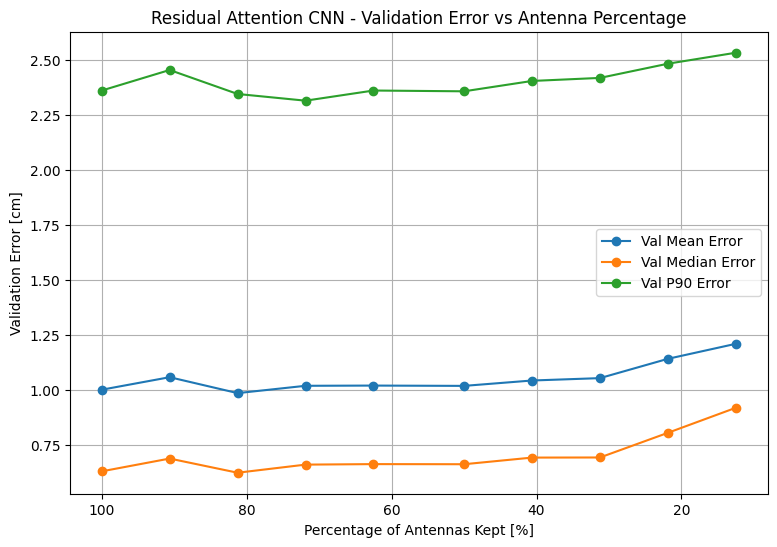

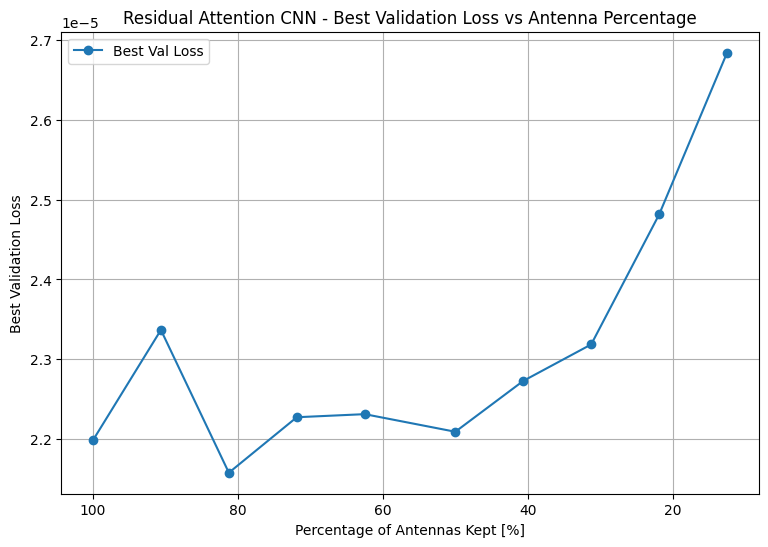


Final selected Residual Attention CNN based on validation mean error
Selected requested percentage: 80%
Selected actual percentage:    81.25%
Selected kept antennas:        26/32
Selected model path:           /content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models/best_residual_attention_model_top_80_percent.keras
Selected normalization path:   /content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/normalization_residual_attention_top_80_percent.npz

Final Test Evaluation of Selected Residual Attention CNN

FINAL TEST REPORT ONLY - Residual Attention CNN - Selected 80% requested antennas
----------------------------------------------------------------------
Mean Error:              0.0091 m
Median Error:            0.0056 m
RMSE Error:              0.0162 m
75th Percentile Error:   0.0108 m
90th Percentile Error:   0.0212 m
95th Percentile Error:   0

,architecture,selection_metric,test_usage,selected_requested_percentage,selected_actual_percentage,selected_kept_antennas,selected_model_path,selected_normalization_path,selected_val_mean_error_m,selected_val_median_error_m,...,final_test_median_error_m,final_test_rmse_error_m,final_test_p75_error_m,final_test_p90_error_m,final_test_p95_error_m,final_test_acc_5cm_percent,final_test_acc_10cm_percent,final_test_acc_20cm_percent,final_test_acc_30cm_percent,final_test_acc_50cm_percent
0,ResidualAttentionCNN,validation_mean_error,report_only_not_used_for_decision,80,81.25,26,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,0.009854,0.006236,...,0.005587,0.016196,0.010842,0.0212,0.030094,99.350053,99.704569,99.967174,99.98687,100.0



Final selected model saved for future use
Final selected model copy:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models/FINAL_SELECTED_residual_attention_model.keras

Final selected normalization copy:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/FINAL_SELECTED_residual_attention_normalization.npz

Final selected info:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/FINAL_SELECTED_residual_attention_info.csv


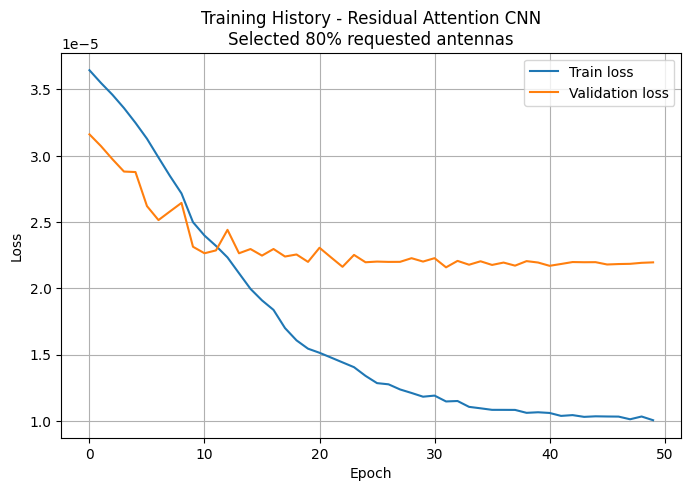

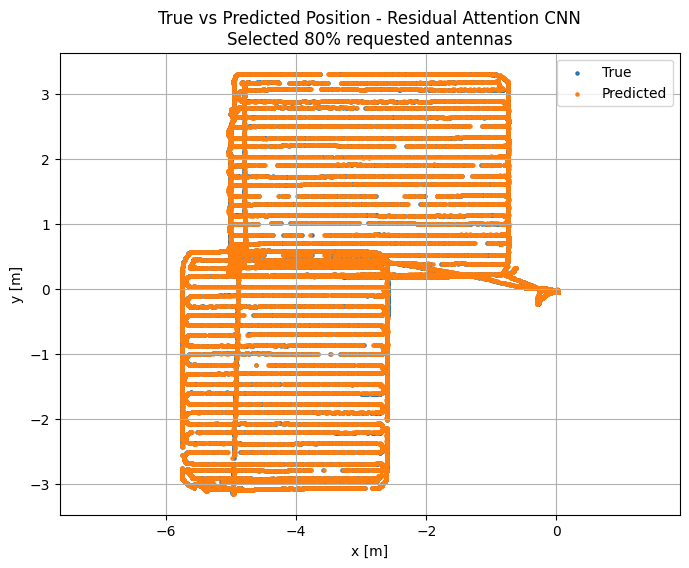

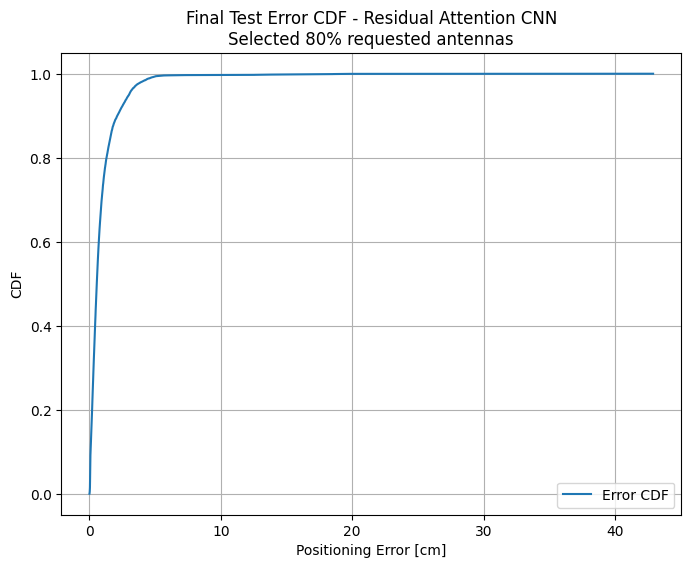

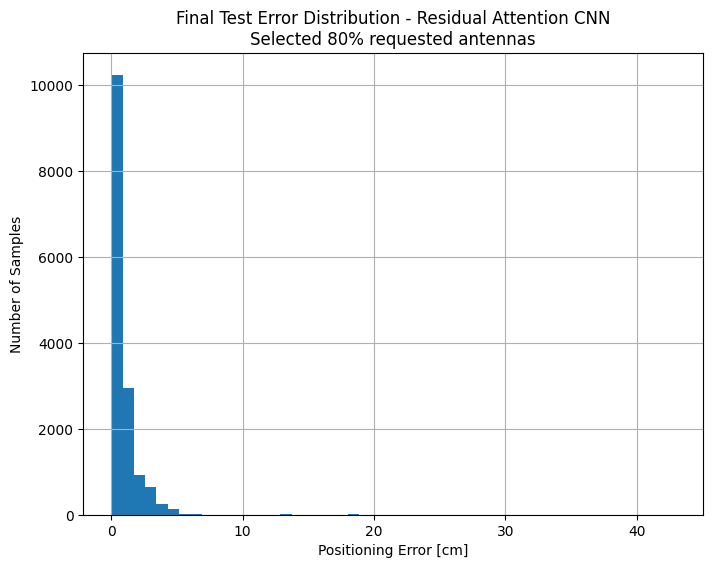


Done.
Residual Attention models saved in:  /content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models
Residual Attention results saved in: /content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results

Final selected model based on validation:
Architecture:           ResidualAttentionCNN
Requested percentage:   80%
Actual percentage:      81.25%
Kept antennas:          26/32

Validation performance of selected model:
Val mean error:         0.99 cm
Val median error:       0.62 cm
Val RMSE error:         1.59 cm
Val P90 error:          2.34 cm
Best val loss:          0.000022

Final test performance report only:
Test mean error:        0.91 cm
Test median error:      0.56 cm
Test RMSE error:        1.62 cm
Test P90 error:         2.12 cm
Test P95 error:         3.01 cm
Test accuracy <= 10 cm: 99.70%

Files for future loading:
Model:         /content/drive/MyDriv

In [25]:
# ============================================================
# RESIDUAL ATTENTION CNN:
# CSI-Aided Next-Step Tracking with IG Source Antenna Ablation
#
# Architecture:
#   Residual CNN + Antenna Attention + Delta Prediction
#
# Input 1: position(t)      -> shape (2,)
# Input 2: CSI(t+1)         -> shape (32, 32, 2)
# Input 3: antenna mask     -> shape (32,)
# Output : position(t+1)    -> shape (2,)
#
# Antenna percentages:
#   100%, 90%, 80%, ..., 20%, 10%
#
# IMPORTANT:
#   Model/percentage selection is based ONLY on validation results.
#   Test set is used only for final report after validation selection.
#
# SAVE:
#   All models, normalization files, histories, checkpoints, and final selected model
#   are saved to Google Drive so you do not need to retrain later.
# ============================================================

import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model


# ============================================================
# Optional: Mount Google Drive
# ============================================================
# In Colab, this keeps saved models/results after runtime reset.

USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("Google Drive mounted.")
    except Exception as e:
        print("Could not mount Google Drive. Falling back to local storage.")
        print(e)


# ============================================================
# Global settings
# ============================================================

SEED = 42
BATCH_SIZE = 64
EPOCHS = 150
HORIZON = 1

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# Output folders for Residual Attention model
# ============================================================

if USE_GOOGLE_DRIVE:
    BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source"
else:
    BASE_SAVE_DIR = "DICHASUS_tracking_experiments/residual_attention_ig_source"


NEW_MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_residual_attention_models"
)

NEW_RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_residual_attention_results"
)

os.makedirs(NEW_MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(NEW_RESULT_SAVE_DIR, exist_ok=True)

print("Residual Attention models will be saved in:")
print(NEW_MODEL_SAVE_DIR)

print("\nResidual Attention results will be saved in:")
print(NEW_RESULT_SAVE_DIR)


# ============================================================
# Safety checks
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
    "global_importance_ig_source",
    "antenna_ranking_global_ig_source",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            f"Run the preprocessing and IG Source Model ranking cells first."
        )

print("\nAll required objects exist.")


# ============================================================
# Use IG Source antenna ranking
# ============================================================

antenna_ranking = np.asarray(
    antenna_ranking_global_ig_source,
    dtype=np.int32
)

global_importance_vector = np.asarray(
    global_importance_ig_source,
    dtype=np.float32
)

if antenna_ranking.shape[0] != 32:
    raise ValueError(
        f"Expected antenna_ranking shape (32,), got {antenna_ranking.shape}"
    )

if global_importance_vector.shape[0] != 32:
    raise ValueError(
        f"Expected global_importance_vector shape (32,), got {global_importance_vector.shape}"
    )

print("\nUsing antenna ranking from IG Source Model.")
print("Antenna ranking indices:")
print(antenna_ranking)

print("\nAntenna ranking names:")
print([f"A{i + 1}" for i in antenna_ranking])

print("\nTop 10 antennas:")
for rank, ant_idx in enumerate(antenna_ranking[:10], start=1):
    print(
        f"Rank {rank}: index={ant_idx}, "
        f"name=A{ant_idx + 1}, "
        f"importance={global_importance_vector[ant_idx]:.8f}"
    )


# ============================================================
# Antenna mask builder
# ============================================================

def create_topk_antenna_mask_by_percentage(
    antenna_ranking,
    percentage=100,
    num_antennas=32
):
    k = int(np.ceil(num_antennas * percentage / 100.0))
    k = max(1, min(k, num_antennas))

    mask = np.zeros(num_antennas, dtype=np.float32)

    selected_antennas = antenna_ranking[:k]
    selected_antenna_names = [f"A{i + 1}" for i in selected_antennas]

    mask[selected_antennas] = 1.0

    actual_percentage = 100.0 * k / num_antennas

    return mask, selected_antennas, selected_antenna_names, k, actual_percentage


# ============================================================
# Build sequential tracking arrays
# ============================================================

def build_tracking_arrays_from_runs(
    runs,
    antenna_mask,
    horizon=1
):
    X_pos_t_list = []
    X_csi_tplus1_list = []
    X_mask_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        if "X_csi" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'X_csi'.")

        if "pos" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'pos'.")

        X_csi = run["X_csi"].astype(np.float32)
        pos = run["pos"].astype(np.float32)

        if len(X_csi) != len(pos):
            raise ValueError(
                f"Run {run_idx}: X_csi and pos have different lengths. "
                f"X_csi length = {len(X_csi)}, pos length = {len(pos)}"
            )

        if len(X_csi) <= horizon:
            print(f"Skipping run {run_idx}: too short.")
            continue

        # position(t)
        pos_t = pos[:-horizon]

        # CSI(t+1)
        csi_tplus1 = X_csi[horizon:]

        # position(t+1)
        pos_tplus1 = pos[horizon:]

        mask_repeated = np.repeat(
            antenna_mask[None, :],
            repeats=pos_t.shape[0],
            axis=0
        ).astype(np.float32)

        X_pos_t_list.append(pos_t)
        X_csi_tplus1_list.append(csi_tplus1)
        X_mask_list.append(mask_repeated)
        y_pos_tplus1_list.append(pos_tplus1)

    if len(X_pos_t_list) == 0:
        raise RuntimeError("No valid runs found for tracking array construction.")

    X_pos_t_all = np.concatenate(X_pos_t_list, axis=0).astype(np.float32)
    X_csi_tplus1_all = np.concatenate(X_csi_tplus1_list, axis=0).astype(np.float32)
    X_mask_all = np.concatenate(X_mask_list, axis=0).astype(np.float32)
    y_pos_tplus1_all = np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32)

    return X_pos_t_all, X_csi_tplus1_all, X_mask_all, y_pos_tplus1_all


# ============================================================
# Normalization
# ============================================================

def compute_csi_normalization_stats(X_train_csi):
    csi_mean = X_train_csi.mean(
        axis=(0, 1, 2),
        keepdims=True
    ).astype(np.float32)

    csi_std = X_train_csi.std(
        axis=(0, 1, 2),
        keepdims=True
    ).astype(np.float32) + 1e-8

    return csi_mean, csi_std


def normalize_csi(X_csi, csi_mean, csi_std):
    return ((X_csi - csi_mean) / csi_std).astype(np.float32)


def compute_position_normalization_stats(y_train):
    pos_mean = y_train.mean(
        axis=0,
        keepdims=True
    ).astype(np.float32)

    pos_std = y_train.std(
        axis=0,
        keepdims=True
    ).astype(np.float32) + 1e-8

    return pos_mean, pos_std


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


# ============================================================
# Dataset builder
# ============================================================

def make_tracking_dataset(
    X_pos_t_norm,
    X_csi_tplus1_norm,
    X_mask,
    y_pos_tplus1_norm,
    batch_size=64,
    shuffle=False,
    seed=42
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32),
        "csi_tplus1_input": X_csi_tplus1_norm.astype(np.float32),
        "antenna_mask_input": X_mask.astype(np.float32),
    }

    targets = y_pos_tplus1_norm.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


# ============================================================
# Evaluation function
# ============================================================

def evaluate_tracking_predictions(
    model,
    dataset,
    y_true_meter,
    pos_mean,
    pos_std,
    dataset_name="Dataset"
):
    y_pred_norm = model.predict(dataset, verbose=0)

    y_pred_meter = denormalize_position(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    error_vectors = y_pred_meter - y_true_meter

    errors = np.sqrt(
        error_vectors[:, 0] ** 2 +
        error_vectors[:, 1] ** 2
    )

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "acc_5cm_percent": float(np.mean(errors <= 0.05) * 100),
        "acc_10cm_percent": float(np.mean(errors <= 0.10) * 100),
        "acc_20cm_percent": float(np.mean(errors <= 0.20) * 100),
        "acc_30cm_percent": float(np.mean(errors <= 0.30) * 100),
        "acc_50cm_percent": float(np.mean(errors <= 0.50) * 100),
        "errors": errors,
        "predictions_meter": y_pred_meter,
    }

    print()
    print(dataset_name)
    print("-" * 70)
    print(f"Mean Error:              {results['mean_error_m']:.4f} m")
    print(f"Median Error:            {results['median_error_m']:.4f} m")
    print(f"RMSE Error:              {results['rmse_error_m']:.4f} m")
    print(f"75th Percentile Error:   {results['p75_error_m']:.4f} m")
    print(f"90th Percentile Error:   {results['p90_error_m']:.4f} m")
    print(f"95th Percentile Error:   {results['p95_error_m']:.4f} m")
    print()
    print(f"Accuracy <= 5 cm:        {results['acc_5cm_percent']:.2f}%")
    print(f"Accuracy <= 10 cm:       {results['acc_10cm_percent']:.2f}%")
    print(f"Accuracy <= 20 cm:       {results['acc_20cm_percent']:.2f}%")
    print(f"Accuracy <= 30 cm:       {results['acc_30cm_percent']:.2f}%")
    print(f"Accuracy <= 50 cm:       {results['acc_50cm_percent']:.2f}%")
    print()

    return results


# ============================================================
# Custom serializable layer for antenna energy
# Avoids Lambda loading problems when saving/loading .keras models
# ============================================================

@tf.keras.utils.register_keras_serializable()
class AntennaEnergyLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # inputs shape: (batch, 32, 32, 2)
        # output shape: (batch, 32)
        return tf.reduce_mean(tf.abs(inputs), axis=[2, 3])

    def get_config(self):
        config = super().get_config()
        return config


# ============================================================
# Residual SE block
# ============================================================

def residual_se_block(
    x,
    filters,
    stride=1,
    se_ratio=8,
    dropout_rate=0.0,
    name="res_block"
):
    shortcut = x

    x = layers.Conv2D(
        filters,
        kernel_size=(3, 3),
        strides=stride,
        padding="same",
        use_bias=False,
        name=f"{name}_conv_1"
    )(x)

    x = layers.BatchNormalization(
        name=f"{name}_bn_1"
    )(x)

    x = layers.Activation(
        "relu",
        name=f"{name}_relu_1"
    )(x)

    x = layers.Conv2D(
        filters,
        kernel_size=(3, 3),
        strides=1,
        padding="same",
        use_bias=False,
        name=f"{name}_conv_2"
    )(x)

    x = layers.BatchNormalization(
        name=f"{name}_bn_2"
    )(x)

    # ------------------------------
    # Squeeze-and-Excitation
    # ------------------------------

    se = layers.GlobalAveragePooling2D(
        name=f"{name}_se_gap"
    )(x)

    se_units = max(filters // se_ratio, 8)

    se = layers.Dense(
        se_units,
        activation="relu",
        name=f"{name}_se_dense_1"
    )(se)

    se = layers.Dense(
        filters,
        activation="sigmoid",
        name=f"{name}_se_dense_2"
    )(se)

    se = layers.Reshape(
        (1, 1, filters),
        name=f"{name}_se_reshape"
    )(se)

    x = layers.Multiply(
        name=f"{name}_se_multiply"
    )([x, se])

    if dropout_rate > 0:
        x = layers.Dropout(
            dropout_rate,
            name=f"{name}_dropout"
        )(x)

    # ------------------------------
    # Shortcut projection if needed
    # ------------------------------

    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv2D(
            filters,
            kernel_size=(1, 1),
            strides=stride,
            padding="same",
            use_bias=False,
            name=f"{name}_shortcut_conv"
        )(shortcut)

        shortcut = layers.BatchNormalization(
            name=f"{name}_shortcut_bn"
        )(shortcut)

    x = layers.Add(
        name=f"{name}_add"
    )([x, shortcut])

    x = layers.Activation(
        "relu",
        name=f"{name}_out_relu"
    )(x)

    return x


# ============================================================
# Residual Attention CNN Architecture
# Residual CNN + Antenna Attention + Delta Prediction
# ============================================================

def build_residual_attention_tracking_model(seed=42):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # ------------------------------
    # Inputs
    # ------------------------------

    position_t_input = tf.keras.Input(
        shape=(2,),
        name="position_t_input"
    )

    csi_tplus1_input = tf.keras.Input(
        shape=(32, 32, 2),
        name="csi_tplus1_input"
    )

    antenna_mask_input = tf.keras.Input(
        shape=(32,),
        name="antenna_mask_input"
    )

    # ------------------------------
    # Apply binary antenna mask
    # ------------------------------

    antenna_mask_reshaped = layers.Reshape(
        (32, 1, 1),
        name="antenna_mask_reshape"
    )(antenna_mask_input)

    masked_csi = layers.Multiply(
        name="initial_masked_csi"
    )([csi_tplus1_input, antenna_mask_reshaped])

    # ------------------------------
    # Antenna attention
    # ------------------------------

    antenna_energy = AntennaEnergyLayer(
        name="antenna_energy"
    )(masked_csi)

    antenna_attention = layers.Dense(
        64,
        activation="relu",
        name="antenna_attention_dense_1"
    )(antenna_energy)

    antenna_attention = layers.Dense(
        32,
        activation="sigmoid",
        name="antenna_attention_dense_2"
    )(antenna_attention)

    antenna_attention = layers.Multiply(
        name="antenna_attention_apply_mask"
    )([antenna_attention, antenna_mask_input])

    antenna_attention_reshaped = layers.Reshape(
        (32, 1, 1),
        name="antenna_attention_reshape"
    )(antenna_attention)

    attended_csi = layers.Multiply(
        name="attention_weighted_csi"
    )([masked_csi, antenna_attention_reshaped])

    # ------------------------------
    # CSI Residual CNN branch
    # ------------------------------

    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="stem_conv"
    )(attended_csi)

    x = layers.BatchNormalization(
        name="stem_bn"
    )(x)

    x = layers.Activation(
        "relu",
        name="stem_relu"
    )(x)

    x = residual_se_block(
        x,
        filters=32,
        stride=1,
        dropout_rate=0.05,
        name="res32_block1"
    )

    x = residual_se_block(
        x,
        filters=32,
        stride=1,
        dropout_rate=0.05,
        name="res32_block2"
    )

    x = residual_se_block(
        x,
        filters=64,
        stride=2,
        dropout_rate=0.08,
        name="res64_block1"
    )

    x = residual_se_block(
        x,
        filters=64,
        stride=1,
        dropout_rate=0.08,
        name="res64_block2"
    )

    x = residual_se_block(
        x,
        filters=128,
        stride=2,
        dropout_rate=0.10,
        name="res128_block1"
    )

    x = residual_se_block(
        x,
        filters=128,
        stride=1,
        dropout_rate=0.10,
        name="res128_block2"
    )

    avg_pool = layers.GlobalAveragePooling2D(
        name="csi_global_avg_pool"
    )(x)

    max_pool = layers.GlobalMaxPooling2D(
        name="csi_global_max_pool"
    )(x)

    csi_features = layers.Concatenate(
        name="csi_avg_max_features"
    )([avg_pool, max_pool])

    csi_features = layers.Dense(
        256,
        activation="relu",
        name="csi_dense_1"
    )(csi_features)

    csi_features = layers.BatchNormalization(
        name="csi_dense_bn_1"
    )(csi_features)

    csi_features = layers.Dropout(
        0.15,
        name="csi_dense_dropout_1"
    )(csi_features)

    csi_features = layers.Dense(
        128,
        activation="relu",
        name="csi_dense_2"
    )(csi_features)

    # ------------------------------
    # Position(t) branch
    # ------------------------------

    p = layers.Dense(
        64,
        activation="relu",
        name="position_dense_1"
    )(position_t_input)

    p = layers.Dense(
        64,
        activation="relu",
        name="position_dense_2"
    )(p)

    p = layers.Dense(
        32,
        activation="relu",
        name="position_dense_3"
    )(p)

    # ------------------------------
    # Fusion branch
    # ------------------------------

    combined = layers.Concatenate(
        name="fusion_csi_position"
    )([csi_features, p])

    z = layers.Dense(
        256,
        activation="relu",
        name="fusion_dense_1"
    )(combined)

    z = layers.BatchNormalization(
        name="fusion_bn_1"
    )(z)

    z = layers.Dropout(
        0.20,
        name="fusion_dropout_1"
    )(z)

    z = layers.Dense(
        128,
        activation="relu",
        name="fusion_dense_2"
    )(z)

    z = layers.Dropout(
        0.10,
        name="fusion_dropout_2"
    )(z)

    z = layers.Dense(
        64,
        activation="relu",
        name="fusion_dense_3"
    )(z)

    # ------------------------------
    # Delta prediction
    # ------------------------------

    delta_position_norm = layers.Dense(
        2,
        activation="linear",
        kernel_initializer=tf.keras.initializers.RandomNormal(
            mean=0.0,
            stddev=1e-3,
            seed=seed
        ),
        bias_initializer="zeros",
        name="delta_position_norm"
    )(z)

    output_position_norm = layers.Add(
        name="position_tplus1_output"
    )([position_t_input, delta_position_norm])

    model = Model(
        inputs={
            "position_t_input": position_t_input,
            "csi_tplus1_input": csi_tplus1_input,
            "antenna_mask_input": antenna_mask_input,
        },
        outputs=output_position_norm,
        name=f"residual_attention_tracking_model_seed_{seed}"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )

    return model


# ============================================================
# Plot helpers
# ============================================================

def plot_validation_error_vs_percentage(results_df):
    plot_df = results_df.sort_values(
        "actual_percentage",
        ascending=False
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_mean_error_m"] * 100,
        marker="o",
        label="Val Mean Error"
    )

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_median_error_m"] * 100,
        marker="o",
        label="Val Median Error"
    )

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_p90_error_m"] * 100,
        marker="o",
        label="Val P90 Error"
    )

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Validation Error [cm]")
    plt.title("Residual Attention CNN - Validation Error vs Antenna Percentage")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_validation_loss_vs_percentage(results_df):
    plot_df = results_df.sort_values(
        "actual_percentage",
        ascending=False
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["best_val_loss"],
        marker="o",
        label="Best Val Loss"
    )

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Best Validation Loss")
    plt.title("Residual Attention CNN - Best Validation Loss vs Antenna Percentage")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_training_history_from_csv(history_path, title="Training History"):
    history_df = pd.read_csv(history_path)

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["loss"],
        label="Train loss"
    )

    plt.plot(
        history_df["val_loss"],
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_true_vs_pred(y_true, y_pred, title="True vs Predicted Position"):
    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_true[:, 0],
        y_true[:, 1],
        s=5,
        label="True"
    )

    plt.scatter(
        y_pred[:, 0],
        y_pred[:, 1],
        s=5,
        label="Predicted"
    )

    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_error_cdf(errors, title="CDF of Positioning Error"):
    sorted_errors = np.sort(errors)
    cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

    plt.figure(figsize=(8, 6))

    plt.plot(
        sorted_errors * 100,
        cdf,
        label="Error CDF"
    )

    plt.xlabel("Positioning Error [cm]")
    plt.ylabel("CDF")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_error_histogram(errors, title="Error Distribution"):
    plt.figure(figsize=(8, 6))

    plt.hist(
        errors * 100,
        bins=50
    )

    plt.xlabel("Positioning Error [cm]")
    plt.ylabel("Number of Samples")
    plt.title(title)
    plt.grid(True)
    plt.show()


# ============================================================
# Antenna percentages like before
# ============================================================

ablation_percentages = [
    100, 90, 80, 70, 60, 50, 40, 30, 20, 10
]


# ============================================================
# Resume support
# ============================================================

new_checkpoint_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "residual_attention_validation_search_checkpoint.csv"
)

FORCE_RETRAIN = False

if os.path.exists(new_checkpoint_path) and not FORCE_RETRAIN:
    previous_df = pd.read_csv(new_checkpoint_path)

    done_percentages = set(
        previous_df["requested_percentage"].astype(int).tolist()
    )

    new_ablation_summary = previous_df.to_dict("records")

    print("\nExisting checkpoint found.")
    print("Already completed percentages:")
    print(sorted(done_percentages, reverse=True))

else:
    done_percentages = set()
    new_ablation_summary = []

    if FORCE_RETRAIN:
        print("\nFORCE_RETRAIN=True. Starting from scratch.")
    else:
        print("\nNo previous checkpoint found. Starting from scratch.")

remaining_percentages = [
    p for p in ablation_percentages
    if int(p) not in done_percentages
]

print("\nRemaining percentages to train:")
print(remaining_percentages)


# ============================================================
# Main validation-based search loop
# Train separate Residual Attention model for each percentage
# ============================================================

PRINT_MODEL_SUMMARY_ONCE = True

for percentage in remaining_percentages:
    print()
    print("=" * 90)
    print(f"Residual Attention CNN - Requested top {percentage}% antennas")
    print("=" * 90)

    # --------------------------------------------------------
    # Create antenna mask
    # --------------------------------------------------------

    antenna_mask, selected_antennas, selected_antenna_names, num_selected_antennas, actual_percentage = (
        create_topk_antenna_mask_by_percentage(
            antenna_ranking=antenna_ranking,
            percentage=percentage,
            num_antennas=32
        )
    )

    num_removed_antennas = 32 - num_selected_antennas

    print(f"Requested percentage: {percentage}%")
    print(f"Actual percentage:    {actual_percentage:.2f}%")

    print(f"Selected antennas indices ({num_selected_antennas}/32):")
    print(selected_antennas)

    print(f"Selected antennas names ({num_selected_antennas}/32):")
    print(selected_antenna_names)

    print(f"Removed antennas: {num_removed_antennas}")

    # --------------------------------------------------------
    # Build train and validation arrays
    # --------------------------------------------------------

    X_train_pos_t, X_train_csi_tplus1, X_train_mask, y_train_pos_tplus1 = (
        build_tracking_arrays_from_runs(
            train_runs,
            antenna_mask=antenna_mask,
            horizon=HORIZON
        )
    )

    X_val_pos_t, X_val_csi_tplus1, X_val_mask, y_val_pos_tplus1 = (
        build_tracking_arrays_from_runs(
            val_runs,
            antenna_mask=antenna_mask,
            horizon=HORIZON
        )
    )

    print("\nTrain shapes:")
    print("X_train_pos_t:", X_train_pos_t.shape)
    print("X_train_csi_tplus1:", X_train_csi_tplus1.shape)
    print("X_train_mask:", X_train_mask.shape)
    print("y_train_pos_tplus1:", y_train_pos_tplus1.shape)

    print("\nValidation shapes:")
    print("X_val_pos_t:", X_val_pos_t.shape)
    print("X_val_csi_tplus1:", X_val_csi_tplus1.shape)
    print("X_val_mask:", X_val_mask.shape)
    print("y_val_pos_tplus1:", y_val_pos_tplus1.shape)

    # --------------------------------------------------------
    # Normalize using train only
    # --------------------------------------------------------

    csi_mean, csi_std = compute_csi_normalization_stats(
        X_train_csi_tplus1
    )

    pos_mean, pos_std = compute_position_normalization_stats(
        y_train_pos_tplus1
    )

    X_train_csi_tplus1_norm = normalize_csi(
        X_train_csi_tplus1,
        csi_mean,
        csi_std
    )

    X_val_csi_tplus1_norm = normalize_csi(
        X_val_csi_tplus1,
        csi_mean,
        csi_std
    )

    X_train_pos_t_norm = normalize_position(
        X_train_pos_t,
        pos_mean,
        pos_std
    )

    X_val_pos_t_norm = normalize_position(
        X_val_pos_t,
        pos_mean,
        pos_std
    )

    y_train_pos_tplus1_norm = normalize_position(
        y_train_pos_tplus1,
        pos_mean,
        pos_std
    )

    y_val_pos_tplus1_norm = normalize_position(
        y_val_pos_tplus1,
        pos_mean,
        pos_std
    )

    print("\npos_mean:", pos_mean)
    print("pos_std:", pos_std)

    # --------------------------------------------------------
    # Create TensorFlow datasets
    # --------------------------------------------------------

    train_dataset = make_tracking_dataset(
        X_pos_t_norm=X_train_pos_t_norm,
        X_csi_tplus1_norm=X_train_csi_tplus1_norm,
        X_mask=X_train_mask,
        y_pos_tplus1_norm=y_train_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    val_dataset = make_tracking_dataset(
        X_pos_t_norm=X_val_pos_t_norm,
        X_csi_tplus1_norm=X_val_csi_tplus1_norm,
        X_mask=X_val_mask,
        y_pos_tplus1_norm=y_val_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )

    # --------------------------------------------------------
    # Build Residual Attention model
    # --------------------------------------------------------

    model = build_residual_attention_tracking_model(seed=SEED)

    if PRINT_MODEL_SUMMARY_ONCE:
        model.summary()
        PRINT_MODEL_SUMMARY_ONCE = False

    # --------------------------------------------------------
    # Save paths
    # --------------------------------------------------------

    percentage_name = str(percentage).replace(".", "_")

    best_model_path = os.path.join(
        NEW_MODEL_SAVE_DIR,
        f"best_residual_attention_model_top_{percentage_name}_percent.keras"
    )

    final_model_path = os.path.join(
        NEW_MODEL_SAVE_DIR,
        f"final_residual_attention_model_top_{percentage_name}_percent.keras"
    )

    history_path = os.path.join(
        NEW_RESULT_SAVE_DIR,
        f"history_residual_attention_top_{percentage_name}_percent.csv"
    )

    norm_path = os.path.join(
        NEW_RESULT_SAVE_DIR,
        f"normalization_residual_attention_top_{percentage_name}_percent.npz"
    )

    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=18,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    # Save final restored model
    model.save(final_model_path)

    print(f"Best model saved to:  {best_model_path}")
    print(f"Final model saved to: {final_model_path}")

    # --------------------------------------------------------
    # Save normalization and mask info
    # --------------------------------------------------------

    np.savez(
        norm_path,
        csi_mean=csi_mean,
        csi_std=csi_std,
        pos_mean=pos_mean,
        pos_std=pos_std,
        antenna_mask=antenna_mask,
        selected_antennas=selected_antennas,
        selected_antenna_names=np.array(selected_antenna_names),
        requested_percentage=percentage,
        actual_percentage=actual_percentage,
        num_selected_antennas=num_selected_antennas,
        num_removed_antennas=num_removed_antennas
    )

    print(f"Normalization/mask info saved to: {norm_path}")

    # --------------------------------------------------------
    # Save training history
    # --------------------------------------------------------

    history_df = pd.DataFrame(history.history)

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"Training history saved to: {history_path}")

    # --------------------------------------------------------
    # Validation evaluation only
    # --------------------------------------------------------

    val_results = evaluate_tracking_predictions(
        model=model,
        dataset=val_dataset,
        y_true_meter=y_val_pos_tplus1,
        pos_mean=pos_mean,
        pos_std=pos_std,
        dataset_name=f"Validation - Residual Attention CNN - Top {percentage}% requested antennas"
    )

    # --------------------------------------------------------
    # Save summary row
    # --------------------------------------------------------

    new_ablation_summary.append({
        "architecture": "ResidualAttentionCNN",
        "requested_percentage": percentage,
        "actual_percentage": actual_percentage,
        "kept_antennas": num_selected_antennas,
        "removed_antennas": num_removed_antennas,
        "selected_antennas_indices": selected_antennas.tolist(),
        "selected_antennas_names": selected_antenna_names,

        "best_model_path": best_model_path,
        "final_model_path": final_model_path,
        "normalization_path": norm_path,
        "history_path": history_path,

        # Validation metrics - used for decisions
        "val_mean_error_m": val_results["mean_error_m"],
        "val_median_error_m": val_results["median_error_m"],
        "val_rmse_error_m": val_results["rmse_error_m"],
        "val_std_error_m": val_results["std_error_m"],
        "val_min_error_m": val_results["min_error_m"],
        "val_max_error_m": val_results["max_error_m"],
        "val_p75_error_m": val_results["p75_error_m"],
        "val_p90_error_m": val_results["p90_error_m"],
        "val_p95_error_m": val_results["p95_error_m"],

        "val_acc_5cm_percent": val_results["acc_5cm_percent"],
        "val_acc_10cm_percent": val_results["acc_10cm_percent"],
        "val_acc_20cm_percent": val_results["acc_20cm_percent"],
        "val_acc_30cm_percent": val_results["acc_30cm_percent"],
        "val_acc_50cm_percent": val_results["acc_50cm_percent"],

        "epochs_trained": len(history.history["loss"]),
        "best_val_loss": min(history.history["val_loss"]),
        "final_val_loss": history.history["val_loss"][-1],
    })

    # --------------------------------------------------------
    # Save checkpoint after every percentage
    # --------------------------------------------------------

    checkpoint_df = pd.DataFrame(new_ablation_summary)

    checkpoint_df.to_csv(
        new_checkpoint_path,
        index=False
    )

    print(f"Checkpoint saved to: {new_checkpoint_path}")

    # --------------------------------------------------------
    # Memory cleanup
    # --------------------------------------------------------

    del model
    del train_dataset
    del val_dataset

    del X_train_pos_t
    del X_train_csi_tplus1
    del X_train_mask
    del y_train_pos_tplus1

    del X_val_pos_t
    del X_val_csi_tplus1
    del X_val_mask
    del y_val_pos_tplus1

    gc.collect()
    tf.keras.backend.clear_session()

    print(f"Finished percentage {percentage}%")


# ============================================================
# Final validation summary for Residual Attention model
# ============================================================

new_results_df = pd.DataFrame(new_ablation_summary)

new_results_df = new_results_df.sort_values(
    "requested_percentage",
    ascending=False
).reset_index(drop=True)

print()
print("=" * 90)
print("Residual Attention CNN - Validation Search Summary")
print("=" * 90)

display(new_results_df)

final_new_summary_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "residual_attention_validation_search_summary_final.csv"
)

new_results_df.to_csv(
    final_new_summary_path,
    index=False
)

print(f"Final validation summary saved to: {final_new_summary_path}")


# ============================================================
# Select best model based only on validation
# ============================================================

best_new_by_val_mean = new_results_df.sort_values(
    "val_mean_error_m",
    ascending=True
).iloc[0]

best_new_by_val_p90 = new_results_df.sort_values(
    "val_p90_error_m",
    ascending=True
).iloc[0]

best_new_by_val_loss = new_results_df.sort_values(
    "best_val_loss",
    ascending=True
).iloc[0]

print()
print("=" * 90)
print("Best Residual Attention CNN by Validation Mean Error")
print("=" * 90)
print(best_new_by_val_mean)

print()
print("=" * 90)
print("Best Residual Attention CNN by Validation P90 Error")
print("=" * 90)
print(best_new_by_val_p90)

print()
print("=" * 90)
print("Best Residual Attention CNN by Best Validation Loss")
print("=" * 90)
print(best_new_by_val_loss)


# ============================================================
# Low-antenna trade-off selection based on validation only
# ============================================================
# This is useful because the project goal is:
#   strong accuracy with fewer important antennas.
#
# Rule:
#   Choose the smallest antenna count whose validation mean and P90
#   remain close to the best absolute validation model.
# ============================================================

acceptable_mean_increase_percent = 10.0
acceptable_p90_increase_percent = 15.0

best_val_mean = float(best_new_by_val_mean["val_mean_error_m"])
best_val_p90_for_best_mean_model = float(best_new_by_val_mean["val_p90_error_m"])

max_allowed_val_mean = best_val_mean * (
    1.0 + acceptable_mean_increase_percent / 100.0
)

max_allowed_val_p90 = best_val_p90_for_best_mean_model * (
    1.0 + acceptable_p90_increase_percent / 100.0
)

acceptable_tradeoff_models = new_results_df[
    (new_results_df["val_mean_error_m"] <= max_allowed_val_mean) &
    (new_results_df["val_p90_error_m"] <= max_allowed_val_p90)
].copy()

if len(acceptable_tradeoff_models) > 0:
    best_low_antenna_tradeoff = acceptable_tradeoff_models.sort_values(
        "kept_antennas",
        ascending=True
    ).iloc[0]
else:
    best_low_antenna_tradeoff = best_new_by_val_mean

print()
print("=" * 90)
print("Best Low-Antenna Trade-off Based on Validation Only")
print("=" * 90)
print(best_low_antenna_tradeoff)

print()
print("Trade-off rule:")
print(f"Allowed validation mean increase: {acceptable_mean_increase_percent:.1f}%")
print(f"Allowed validation P90 increase:  {acceptable_p90_increase_percent:.1f}%")
print()
print(f"Best validation mean:        {best_val_mean * 100:.2f} cm")
print(f"Max allowed validation mean: {max_allowed_val_mean * 100:.2f} cm")
print(f"Reference validation P90:    {best_val_p90_for_best_mean_model * 100:.2f} cm")
print(f"Max allowed validation P90:  {max_allowed_val_p90 * 100:.2f} cm")


# ============================================================
# Save validation-based selection summaries
# ============================================================

selection_summary_df = pd.DataFrame([
    {
        "selection_name": "best_by_validation_mean",
        "requested_percentage": best_new_by_val_mean["requested_percentage"],
        "actual_percentage": best_new_by_val_mean["actual_percentage"],
        "kept_antennas": best_new_by_val_mean["kept_antennas"],
        "removed_antennas": best_new_by_val_mean["removed_antennas"],
        "val_mean_error_m": best_new_by_val_mean["val_mean_error_m"],
        "val_median_error_m": best_new_by_val_mean["val_median_error_m"],
        "val_rmse_error_m": best_new_by_val_mean["val_rmse_error_m"],
        "val_p90_error_m": best_new_by_val_mean["val_p90_error_m"],
        "best_val_loss": best_new_by_val_mean["best_val_loss"],
        "best_model_path": best_new_by_val_mean["best_model_path"],
        "normalization_path": best_new_by_val_mean["normalization_path"],
    },
    {
        "selection_name": "best_by_validation_p90",
        "requested_percentage": best_new_by_val_p90["requested_percentage"],
        "actual_percentage": best_new_by_val_p90["actual_percentage"],
        "kept_antennas": best_new_by_val_p90["kept_antennas"],
        "removed_antennas": best_new_by_val_p90["removed_antennas"],
        "val_mean_error_m": best_new_by_val_p90["val_mean_error_m"],
        "val_median_error_m": best_new_by_val_p90["val_median_error_m"],
        "val_rmse_error_m": best_new_by_val_p90["val_rmse_error_m"],
        "val_p90_error_m": best_new_by_val_p90["val_p90_error_m"],
        "best_val_loss": best_new_by_val_p90["best_val_loss"],
        "best_model_path": best_new_by_val_p90["best_model_path"],
        "normalization_path": best_new_by_val_p90["normalization_path"],
    },
    {
        "selection_name": "best_low_antenna_tradeoff_validation",
        "requested_percentage": best_low_antenna_tradeoff["requested_percentage"],
        "actual_percentage": best_low_antenna_tradeoff["actual_percentage"],
        "kept_antennas": best_low_antenna_tradeoff["kept_antennas"],
        "removed_antennas": best_low_antenna_tradeoff["removed_antennas"],
        "val_mean_error_m": best_low_antenna_tradeoff["val_mean_error_m"],
        "val_median_error_m": best_low_antenna_tradeoff["val_median_error_m"],
        "val_rmse_error_m": best_low_antenna_tradeoff["val_rmse_error_m"],
        "val_p90_error_m": best_low_antenna_tradeoff["val_p90_error_m"],
        "best_val_loss": best_low_antenna_tradeoff["best_val_loss"],
        "best_model_path": best_low_antenna_tradeoff["best_model_path"],
        "normalization_path": best_low_antenna_tradeoff["normalization_path"],
    },
])

selection_summary_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "residual_attention_validation_based_selection_summary.csv"
)

selection_summary_df.to_csv(
    selection_summary_path,
    index=False
)

print(f"Validation-based selection summary saved to: {selection_summary_path}")

display(selection_summary_df)


# ============================================================
# Plot validation results
# ============================================================

plot_validation_error_vs_percentage(new_results_df)

plot_validation_loss_vs_percentage(new_results_df)


# ============================================================
# Final model selection for final test report
# ============================================================
# Default:
#   selected_row = best_new_by_val_mean
#
# If your priority is fewer antennas, you can change it to:
#   selected_row = best_low_antenna_tradeoff
#
# If your priority is robustness:
#   selected_row = best_new_by_val_p90
# ============================================================

selected_row = best_new_by_val_mean

selected_percentage = int(selected_row["requested_percentage"])
selected_actual_percentage = float(selected_row["actual_percentage"])
selected_kept_antennas = int(selected_row["kept_antennas"])

selected_best_model_path = selected_row["best_model_path"]
selected_norm_path = selected_row["normalization_path"]
selected_history_path = selected_row["history_path"]

print()
print("=" * 90)
print("Final selected Residual Attention CNN based on validation mean error")
print("=" * 90)

print(f"Selected requested percentage: {selected_percentage}%")
print(f"Selected actual percentage:    {selected_actual_percentage:.2f}%")
print(f"Selected kept antennas:        {selected_kept_antennas}/32")
print(f"Selected model path:           {selected_best_model_path}")
print(f"Selected normalization path:   {selected_norm_path}")


# ============================================================
# Final test evaluation
# Test is used only now for the selected model.
# It is report-only and must not influence model decisions.
# ============================================================

print()
print("=" * 90)
print("Final Test Evaluation of Selected Residual Attention CNN")
print("=" * 90)

selected_model = tf.keras.models.load_model(
    selected_best_model_path,
    custom_objects={
        "AntennaEnergyLayer": AntennaEnergyLayer
    }
)

selected_norm = np.load(
    selected_norm_path,
    allow_pickle=True
)

selected_csi_mean = selected_norm["csi_mean"]
selected_csi_std = selected_norm["csi_std"]
selected_pos_mean = selected_norm["pos_mean"]
selected_pos_std = selected_norm["pos_std"]
selected_antenna_mask = selected_norm["antenna_mask"]

X_test_pos_t, X_test_csi_tplus1, X_test_mask, y_test_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        test_runs,
        antenna_mask=selected_antenna_mask,
        horizon=HORIZON
    )
)

X_test_csi_tplus1_norm = normalize_csi(
    X_test_csi_tplus1,
    selected_csi_mean,
    selected_csi_std
)

X_test_pos_t_norm = normalize_position(
    X_test_pos_t,
    selected_pos_mean,
    selected_pos_std
)

y_test_pos_tplus1_norm = normalize_position(
    y_test_pos_tplus1,
    selected_pos_mean,
    selected_pos_std
)

test_dataset = make_tracking_dataset(
    X_pos_t_norm=X_test_pos_t_norm,
    X_csi_tplus1_norm=X_test_csi_tplus1_norm,
    X_mask=X_test_mask,
    y_pos_tplus1_norm=y_test_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

final_test_results = evaluate_tracking_predictions(
    model=selected_model,
    dataset=test_dataset,
    y_true_meter=y_test_pos_tplus1,
    pos_mean=selected_pos_mean,
    pos_std=selected_pos_std,
    dataset_name=(
        f"FINAL TEST REPORT ONLY - Residual Attention CNN - "
        f"Selected {selected_percentage}% requested antennas"
    )
)


# ============================================================
# Save final selected test report
# ============================================================

final_selected_result = {
    "architecture": "ResidualAttentionCNN",
    "selection_metric": "validation_mean_error",
    "test_usage": "report_only_not_used_for_decision",

    "selected_requested_percentage": selected_percentage,
    "selected_actual_percentage": selected_actual_percentage,
    "selected_kept_antennas": selected_kept_antennas,
    "selected_model_path": selected_best_model_path,
    "selected_normalization_path": selected_norm_path,

    "selected_val_mean_error_m": float(selected_row["val_mean_error_m"]),
    "selected_val_median_error_m": float(selected_row["val_median_error_m"]),
    "selected_val_rmse_error_m": float(selected_row["val_rmse_error_m"]),
    "selected_val_p90_error_m": float(selected_row["val_p90_error_m"]),
    "selected_best_val_loss": float(selected_row["best_val_loss"]),

    "final_test_mean_error_m": final_test_results["mean_error_m"],
    "final_test_median_error_m": final_test_results["median_error_m"],
    "final_test_rmse_error_m": final_test_results["rmse_error_m"],
    "final_test_p75_error_m": final_test_results["p75_error_m"],
    "final_test_p90_error_m": final_test_results["p90_error_m"],
    "final_test_p95_error_m": final_test_results["p95_error_m"],

    "final_test_acc_5cm_percent": final_test_results["acc_5cm_percent"],
    "final_test_acc_10cm_percent": final_test_results["acc_10cm_percent"],
    "final_test_acc_20cm_percent": final_test_results["acc_20cm_percent"],
    "final_test_acc_30cm_percent": final_test_results["acc_30cm_percent"],
    "final_test_acc_50cm_percent": final_test_results["acc_50cm_percent"],
}

final_selected_result_df = pd.DataFrame([final_selected_result])

final_selected_result_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "residual_attention_final_selected_test_result.csv"
)

final_selected_result_df.to_csv(
    final_selected_result_path,
    index=False
)

print(f"Final selected test result saved to: {final_selected_result_path}")

display(final_selected_result_df)


# ============================================================
# Save explicit final selected model copy
# ============================================================
# This creates fixed filenames for later loading.
# So you do not need to search which percentage was selected.
# ============================================================

final_selected_model_copy_path = os.path.join(
    NEW_MODEL_SAVE_DIR,
    "FINAL_SELECTED_residual_attention_model.keras"
)

final_selected_norm_copy_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "FINAL_SELECTED_residual_attention_normalization.npz"
)

final_selected_info_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "FINAL_SELECTED_residual_attention_info.csv"
)

shutil.copy2(
    selected_best_model_path,
    final_selected_model_copy_path
)

shutil.copy2(
    selected_norm_path,
    final_selected_norm_copy_path
)

final_selected_info_df = pd.DataFrame([{
    "architecture": "ResidualAttentionCNN",
    "selection_metric": "validation_mean_error",
    "test_usage": "report_only_not_used_for_decision",

    "selected_requested_percentage": selected_percentage,
    "selected_actual_percentage": selected_actual_percentage,
    "selected_kept_antennas": selected_kept_antennas,

    "final_selected_model_copy_path": final_selected_model_copy_path,
    "final_selected_normalization_copy_path": final_selected_norm_copy_path,

    "original_selected_best_model_path": selected_best_model_path,
    "original_selected_normalization_path": selected_norm_path,
}])

final_selected_info_df.to_csv(
    final_selected_info_path,
    index=False
)

print()
print("=" * 90)
print("Final selected model saved for future use")
print("=" * 90)

print("Final selected model copy:")
print(final_selected_model_copy_path)

print("\nFinal selected normalization copy:")
print(final_selected_norm_copy_path)

print("\nFinal selected info:")
print(final_selected_info_path)


# ============================================================
# Plots for final selected model
# ============================================================

plot_training_history_from_csv(
    selected_history_path,
    title=(
        f"Training History - Residual Attention CNN\n"
        f"Selected {selected_percentage}% requested antennas"
    )
)

plot_true_vs_pred(
    y_true=y_test_pos_tplus1,
    y_pred=final_test_results["predictions_meter"],
    title=(
        f"True vs Predicted Position - Residual Attention CNN\n"
        f"Selected {selected_percentage}% requested antennas"
    )
)

plot_error_cdf(
    final_test_results["errors"],
    title=(
        f"Final Test Error CDF - Residual Attention CNN\n"
        f"Selected {selected_percentage}% requested antennas"
    )
)

plot_error_histogram(
    final_test_results["errors"],
    title=(
        f"Final Test Error Distribution - Residual Attention CNN\n"
        f"Selected {selected_percentage}% requested antennas"
    )
)


# ============================================================
# Final print summary
# ============================================================

print()
print("=" * 90)
print("Done.")
print("=" * 90)

print(f"Residual Attention models saved in:  {NEW_MODEL_SAVE_DIR}")
print(f"Residual Attention results saved in: {NEW_RESULT_SAVE_DIR}")

print()
print("Final selected model based on validation:")
print(f"Architecture:           ResidualAttentionCNN")
print(f"Requested percentage:   {selected_percentage}%")
print(f"Actual percentage:      {selected_actual_percentage:.2f}%")
print(f"Kept antennas:          {selected_kept_antennas}/32")

print()
print("Validation performance of selected model:")
print(f"Val mean error:         {float(selected_row['val_mean_error_m']) * 100:.2f} cm")
print(f"Val median error:       {float(selected_row['val_median_error_m']) * 100:.2f} cm")
print(f"Val RMSE error:         {float(selected_row['val_rmse_error_m']) * 100:.2f} cm")
print(f"Val P90 error:          {float(selected_row['val_p90_error_m']) * 100:.2f} cm")
print(f"Best val loss:          {float(selected_row['best_val_loss']):.6f}")

print()
print("Final test performance report only:")
print(f"Test mean error:        {final_test_results['mean_error_m'] * 100:.2f} cm")
print(f"Test median error:      {final_test_results['median_error_m'] * 100:.2f} cm")
print(f"Test RMSE error:        {final_test_results['rmse_error_m'] * 100:.2f} cm")
print(f"Test P90 error:         {final_test_results['p90_error_m'] * 100:.2f} cm")
print(f"Test P95 error:         {final_test_results['p95_error_m'] * 100:.2f} cm")
print(f"Test accuracy <= 10 cm: {final_test_results['acc_10cm_percent']:.2f}%")

print()
print("Files for future loading:")
print(f"Model:         {final_selected_model_copy_path}")
print(f"Normalization: {final_selected_norm_copy_path}")
print(f"Info:          {final_selected_info_path}")

print()
print("Important:")
print("Validation metrics were used for selection.")
print("Test metrics are report-only and were not used for model decisions.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Validation and test runs found.
Model path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models/FINAL_SELECTED_residual_attention_model.keras

Normalization path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/FINAL_SELECTED_residual_attention_normalization.npz

Model and normalization files exist.

Model loaded successfully.

Selected model info:
Requested percentage: 80%
Actual percentage:    81.25%
Selected antennas:    26/32
Removed antennas:     6/32

Selected antenna indices:
[26 21 15  8 28 25 30  1  6 11  3 13  5  4 10 23 17 12 24 29  2 20  7 27
 14 18]

Selected antenna names:
['A27' 'A22' 'A16' 'A9' 'A29' 'A26' 'A31' 'A2' 'A7' 'A12' 'A4' 'A14' 'A6'
 'A5' 'A11' 'A24' 'A18' 'A13' 'A25' 'A30' 'A3' 'A21' 'A8

,architecture,model_path,normalization_path,requested_percentage,actual_percentage,kept_antennas,removed_antennas,selected_antennas_indices,selected_antennas_names,val_mean_error_m,...,test_max_error_m_report_only,test_p75_error_m_report_only,test_p90_error_m_report_only,test_p95_error_m_report_only,test_acc_5cm_percent_report_only,test_acc_10cm_percent_report_only,test_acc_20cm_percent_report_only,test_acc_30cm_percent_report_only,test_acc_50cm_percent_report_only,test_usage
0,ResidualAttentionCNN,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,80,81.25,26,6,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","[A27, A22, A16, A9, A29, A26, A31, A2, A7, A12...",0.009854,...,0.428993,0.010842,0.0212,0.030094,99.350053,99.704569,99.967174,99.98687,100.0,report_only_not_used_for_decision



Validation predictions saved to:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/LOADED_MODEL_validation_predictions.npz

Test predictions saved to:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/LOADED_MODEL_test_predictions_report_only.npz


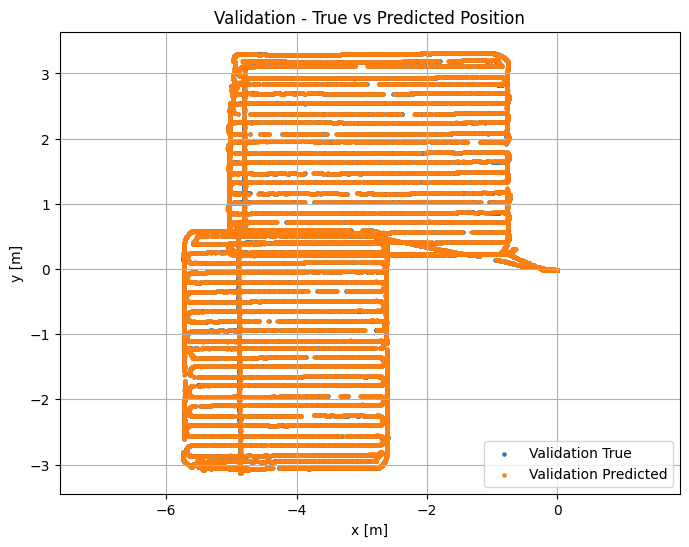

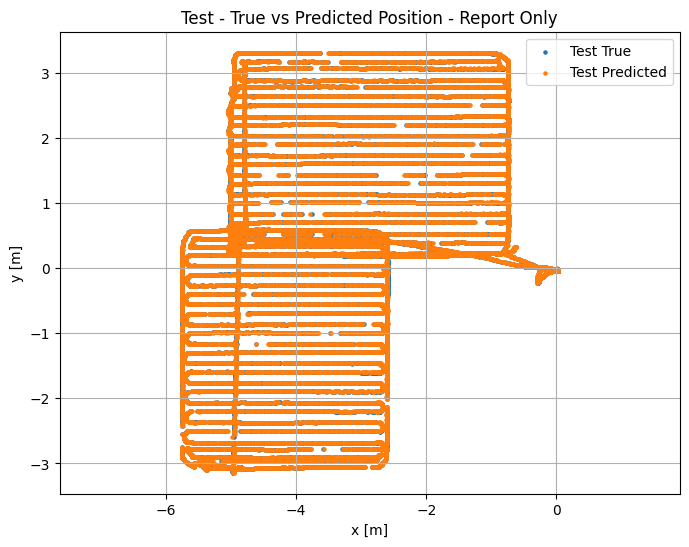

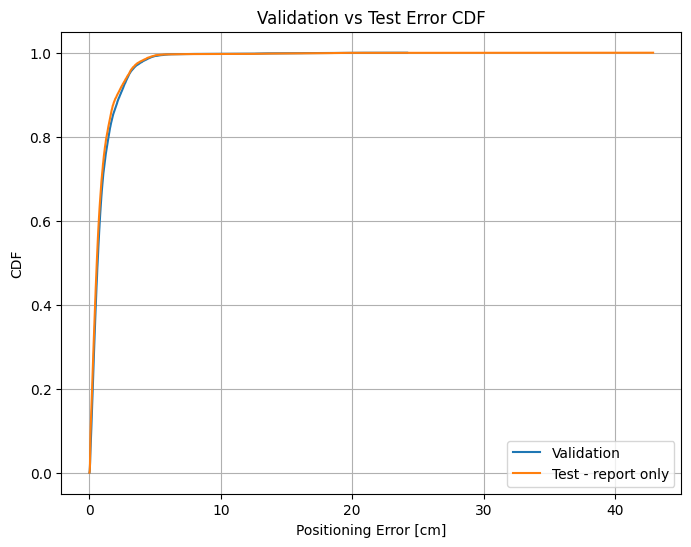

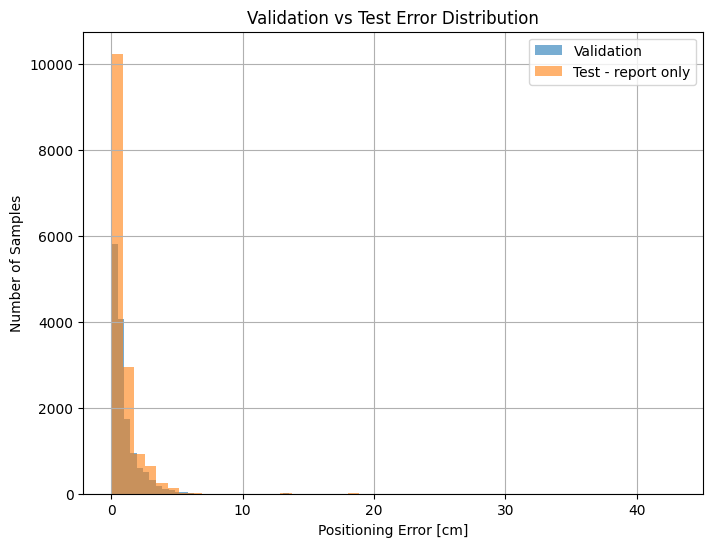


Done. Validation + test report completed.
Validation can be used for analysis.
Test is report-only and must not be used for model decisions.


In [26]:
# ============================================================
# LOAD SAVED RESIDUAL ATTENTION MODEL
# VALIDATION + TEST EVALUATION
#
# This code:
#   1) Mounts Google Drive
#   2) Loads FINAL_SELECTED Residual Attention model
#   3) Loads normalization + selected antenna mask
#   4) Builds validation arrays
#   5) Builds test arrays
#   6) Evaluates validation
#   7) Evaluates test as report-only
#   8) Saves validation + test report
#
# IMPORTANT:
#   Validation can be used for analysis.
#   Test is report-only and must not be used for decisions.
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers


# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")


# ============================================================
# Safety check
# ============================================================

required_objects = [
    "val_runs",
    "test_runs",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            f"Run the preprocessing cells first so that val_runs and test_runs exist."
        )

print("Validation and test runs found.")


# ============================================================
# Custom layer required for loading Residual Attention model
# ============================================================

@tf.keras.utils.register_keras_serializable()
class AntennaEnergyLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # inputs shape: (batch, 32, 32, 2)
        # output shape: (batch, 32)
        return tf.reduce_mean(tf.abs(inputs), axis=[2, 3])

    def get_config(self):
        return super().get_config()


# ============================================================
# Paths
# ============================================================

BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source"

MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_residual_attention_models"
)

RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_residual_attention_results"
)

model_path = os.path.join(
    MODEL_SAVE_DIR,
    "FINAL_SELECTED_residual_attention_model.keras"
)

norm_path = os.path.join(
    RESULT_SAVE_DIR,
    "FINAL_SELECTED_residual_attention_normalization.npz"
)

combined_report_path = os.path.join(
    RESULT_SAVE_DIR,
    "LOADED_MODEL_validation_and_test_report.csv"
)

validation_predictions_path = os.path.join(
    RESULT_SAVE_DIR,
    "LOADED_MODEL_validation_predictions.npz"
)

test_predictions_path = os.path.join(
    RESULT_SAVE_DIR,
    "LOADED_MODEL_test_predictions_report_only.npz"
)

print("Model path:")
print(model_path)

print("\nNormalization path:")
print(norm_path)


# ============================================================
# Check files exist
# ============================================================

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Model file not found:\n{model_path}\n"
        f"Make sure you already trained and saved the model."
    )

if not os.path.exists(norm_path):
    raise FileNotFoundError(
        f"Normalization file not found:\n{norm_path}\n"
        f"Make sure you already saved FINAL_SELECTED normalization."
    )

print("\nModel and normalization files exist.")


# ============================================================
# Helper functions
# ============================================================

def build_tracking_arrays_from_runs(
    runs,
    antenna_mask,
    horizon=1
):
    X_pos_t_list = []
    X_csi_tplus1_list = []
    X_mask_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        if "X_csi" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'X_csi'.")

        if "pos" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'pos'.")

        X_csi = run["X_csi"].astype(np.float32)
        pos = run["pos"].astype(np.float32)

        if len(X_csi) != len(pos):
            raise ValueError(
                f"Run {run_idx}: X_csi and pos have different lengths. "
                f"X_csi length = {len(X_csi)}, pos length = {len(pos)}"
            )

        if len(X_csi) <= horizon:
            print(f"Skipping run {run_idx}: too short.")
            continue

        pos_t = pos[:-horizon]
        csi_tplus1 = X_csi[horizon:]
        pos_tplus1 = pos[horizon:]

        mask_repeated = np.repeat(
            antenna_mask[None, :],
            repeats=pos_t.shape[0],
            axis=0
        ).astype(np.float32)

        X_pos_t_list.append(pos_t)
        X_csi_tplus1_list.append(csi_tplus1)
        X_mask_list.append(mask_repeated)
        y_pos_tplus1_list.append(pos_tplus1)

    if len(X_pos_t_list) == 0:
        raise RuntimeError("No valid runs found for tracking array construction.")

    X_pos_t_all = np.concatenate(X_pos_t_list, axis=0).astype(np.float32)
    X_csi_tplus1_all = np.concatenate(X_csi_tplus1_list, axis=0).astype(np.float32)
    X_mask_all = np.concatenate(X_mask_list, axis=0).astype(np.float32)
    y_pos_tplus1_all = np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32)

    return X_pos_t_all, X_csi_tplus1_all, X_mask_all, y_pos_tplus1_all


def normalize_csi(X_csi, csi_mean, csi_std):
    return ((X_csi - csi_mean) / csi_std).astype(np.float32)


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


def make_tracking_dataset(
    X_pos_t_norm,
    X_csi_tplus1_norm,
    X_mask,
    y_pos_tplus1_norm,
    batch_size=64,
    shuffle=False,
    seed=42
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32),
        "csi_tplus1_input": X_csi_tplus1_norm.astype(np.float32),
        "antenna_mask_input": X_mask.astype(np.float32),
    }

    targets = y_pos_tplus1_norm.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


def compute_position_errors(
    y_true_meter,
    y_pred_meter
):
    error_vectors = y_pred_meter - y_true_meter

    errors = np.sqrt(
        error_vectors[:, 0] ** 2 +
        error_vectors[:, 1] ** 2
    )

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "acc_5cm_percent": float(np.mean(errors <= 0.05) * 100),
        "acc_10cm_percent": float(np.mean(errors <= 0.10) * 100),
        "acc_20cm_percent": float(np.mean(errors <= 0.20) * 100),
        "acc_30cm_percent": float(np.mean(errors <= 0.30) * 100),
        "acc_50cm_percent": float(np.mean(errors <= 0.50) * 100),
        "errors": errors,
    }

    return results


def evaluate_split(
    model,
    runs,
    split_name,
    antenna_mask,
    csi_mean,
    csi_std,
    pos_mean,
    pos_std,
    batch_size=64,
    horizon=1,
    seed=42
):
    X_pos_t, X_csi_tplus1, X_mask, y_pos_tplus1 = (
        build_tracking_arrays_from_runs(
            runs,
            antenna_mask=antenna_mask,
            horizon=horizon
        )
    )

    print()
    print("=" * 90)
    print(f"{split_name.upper()} SHAPES")
    print("=" * 90)
    print("X_pos_t:", X_pos_t.shape)
    print("X_csi_tplus1:", X_csi_tplus1.shape)
    print("X_mask:", X_mask.shape)
    print("y_pos_tplus1:", y_pos_tplus1.shape)

    X_csi_tplus1_norm = normalize_csi(
        X_csi_tplus1,
        csi_mean,
        csi_std
    )

    X_pos_t_norm = normalize_position(
        X_pos_t,
        pos_mean,
        pos_std
    )

    y_pos_tplus1_norm = normalize_position(
        y_pos_tplus1,
        pos_mean,
        pos_std
    )

    dataset = make_tracking_dataset(
        X_pos_t_norm=X_pos_t_norm,
        X_csi_tplus1_norm=X_csi_tplus1_norm,
        X_mask=X_mask,
        y_pos_tplus1_norm=y_pos_tplus1_norm,
        batch_size=batch_size,
        shuffle=False,
        seed=seed
    )

    y_pred_norm = model.predict(
        dataset,
        verbose=0
    )

    y_pred_meter = denormalize_position(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    results = compute_position_errors(
        y_true_meter=y_pos_tplus1,
        y_pred_meter=y_pred_meter
    )

    return {
        "split_name": split_name,
        "X_pos_t": X_pos_t,
        "X_csi_tplus1": X_csi_tplus1,
        "X_mask": X_mask,
        "y_true_meter": y_pos_tplus1,
        "y_pred_norm": y_pred_norm,
        "y_pred_meter": y_pred_meter,
        "results": results,
    }


def print_results(results, title):
    print()
    print("=" * 90)
    print(title)
    print("=" * 90)

    print(f"Mean Error:        {results['mean_error_m'] * 100:.2f} cm")
    print(f"Median Error:      {results['median_error_m'] * 100:.2f} cm")
    print(f"RMSE Error:        {results['rmse_error_m'] * 100:.2f} cm")
    print(f"Std Error:         {results['std_error_m'] * 100:.2f} cm")
    print(f"P75 Error:         {results['p75_error_m'] * 100:.2f} cm")
    print(f"P90 Error:         {results['p90_error_m'] * 100:.2f} cm")
    print(f"P95 Error:         {results['p95_error_m'] * 100:.2f} cm")
    print()
    print(f"Accuracy <= 5 cm:  {results['acc_5cm_percent']:.2f}%")
    print(f"Accuracy <= 10 cm: {results['acc_10cm_percent']:.2f}%")
    print(f"Accuracy <= 20 cm: {results['acc_20cm_percent']:.2f}%")
    print(f"Accuracy <= 30 cm: {results['acc_30cm_percent']:.2f}%")
    print(f"Accuracy <= 50 cm: {results['acc_50cm_percent']:.2f}%")


# ============================================================
# Load model and normalization
# ============================================================

model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        "AntennaEnergyLayer": AntennaEnergyLayer
    }
)

norm_data = np.load(
    norm_path,
    allow_pickle=True
)

csi_mean = norm_data["csi_mean"]
csi_std = norm_data["csi_std"]

pos_mean = norm_data["pos_mean"]
pos_std = norm_data["pos_std"]

antenna_mask = norm_data["antenna_mask"]
selected_antennas = norm_data["selected_antennas"]
selected_antenna_names = norm_data["selected_antenna_names"]

requested_percentage = norm_data["requested_percentage"].item()
actual_percentage = norm_data["actual_percentage"].item()
num_selected_antennas = norm_data["num_selected_antennas"].item()
num_removed_antennas = norm_data["num_removed_antennas"].item()

print("\nModel loaded successfully.")

print("\nSelected model info:")
print(f"Requested percentage: {requested_percentage}%")
print(f"Actual percentage:    {actual_percentage:.2f}%")
print(f"Selected antennas:    {num_selected_antennas}/32")
print(f"Removed antennas:     {num_removed_antennas}/32")

print("\nSelected antenna indices:")
print(selected_antennas)

print("\nSelected antenna names:")
print(selected_antenna_names)


# ============================================================
# Evaluate validation and test
# ============================================================

HORIZON = 1
BATCH_SIZE = 64
SEED = 42

validation_output = evaluate_split(
    model=model,
    runs=val_runs,
    split_name="validation",
    antenna_mask=antenna_mask,
    csi_mean=csi_mean,
    csi_std=csi_std,
    pos_mean=pos_mean,
    pos_std=pos_std,
    batch_size=BATCH_SIZE,
    horizon=HORIZON,
    seed=SEED
)

test_output = evaluate_split(
    model=model,
    runs=test_runs,
    split_name="test_report_only",
    antenna_mask=antenna_mask,
    csi_mean=csi_mean,
    csi_std=csi_std,
    pos_mean=pos_mean,
    pos_std=pos_std,
    batch_size=BATCH_SIZE,
    horizon=HORIZON,
    seed=SEED
)


# ============================================================
# Print results
# ============================================================

val_results = validation_output["results"]
test_results = test_output["results"]

print_results(
    val_results,
    "VALIDATION RESULTS - Loaded Residual Attention Model"
)

print_results(
    test_results,
    "TEST RESULTS REPORT ONLY - Loaded Residual Attention Model"
)


# ============================================================
# Save combined validation + test report
# ============================================================

combined_report = {
    "architecture": "ResidualAttentionCNN",
    "model_path": model_path,
    "normalization_path": norm_path,

    "requested_percentage": requested_percentage,
    "actual_percentage": actual_percentage,
    "kept_antennas": num_selected_antennas,
    "removed_antennas": num_removed_antennas,
    "selected_antennas_indices": selected_antennas.tolist(),
    "selected_antennas_names": selected_antenna_names.tolist(),

    # Validation metrics
    "val_mean_error_m": val_results["mean_error_m"],
    "val_median_error_m": val_results["median_error_m"],
    "val_rmse_error_m": val_results["rmse_error_m"],
    "val_std_error_m": val_results["std_error_m"],
    "val_min_error_m": val_results["min_error_m"],
    "val_max_error_m": val_results["max_error_m"],
    "val_p75_error_m": val_results["p75_error_m"],
    "val_p90_error_m": val_results["p90_error_m"],
    "val_p95_error_m": val_results["p95_error_m"],
    "val_acc_5cm_percent": val_results["acc_5cm_percent"],
    "val_acc_10cm_percent": val_results["acc_10cm_percent"],
    "val_acc_20cm_percent": val_results["acc_20cm_percent"],
    "val_acc_30cm_percent": val_results["acc_30cm_percent"],
    "val_acc_50cm_percent": val_results["acc_50cm_percent"],

    # Test metrics - report only
    "test_mean_error_m_report_only": test_results["mean_error_m"],
    "test_median_error_m_report_only": test_results["median_error_m"],
    "test_rmse_error_m_report_only": test_results["rmse_error_m"],
    "test_std_error_m_report_only": test_results["std_error_m"],
    "test_min_error_m_report_only": test_results["min_error_m"],
    "test_max_error_m_report_only": test_results["max_error_m"],
    "test_p75_error_m_report_only": test_results["p75_error_m"],
    "test_p90_error_m_report_only": test_results["p90_error_m"],
    "test_p95_error_m_report_only": test_results["p95_error_m"],
    "test_acc_5cm_percent_report_only": test_results["acc_5cm_percent"],
    "test_acc_10cm_percent_report_only": test_results["acc_10cm_percent"],
    "test_acc_20cm_percent_report_only": test_results["acc_20cm_percent"],
    "test_acc_30cm_percent_report_only": test_results["acc_30cm_percent"],
    "test_acc_50cm_percent_report_only": test_results["acc_50cm_percent"],

    "test_usage": "report_only_not_used_for_decision",
}

combined_report_df = pd.DataFrame([combined_report])

combined_report_df.to_csv(
    combined_report_path,
    index=False
)

print()
print("Combined validation + test report saved to:")
print(combined_report_path)

display(combined_report_df)


# ============================================================
# Save validation predictions
# ============================================================

np.savez(
    validation_predictions_path,
    y_true_val_meter=validation_output["y_true_meter"],
    y_pred_val_meter=validation_output["y_pred_meter"],
    y_pred_val_norm=validation_output["y_pred_norm"],
    errors_val_meter=val_results["errors"],
    antenna_mask=antenna_mask,
    selected_antennas=selected_antennas,
    selected_antenna_names=selected_antenna_names,
    requested_percentage=requested_percentage,
    actual_percentage=actual_percentage,
    num_selected_antennas=num_selected_antennas,
    num_removed_antennas=num_removed_antennas,
)

print("\nValidation predictions saved to:")
print(validation_predictions_path)


# ============================================================
# Save test predictions - report only
# ============================================================

np.savez(
    test_predictions_path,
    y_true_test_meter=test_output["y_true_meter"],
    y_pred_test_meter=test_output["y_pred_meter"],
    y_pred_test_norm=test_output["y_pred_norm"],
    errors_test_meter=test_results["errors"],
    antenna_mask=antenna_mask,
    selected_antennas=selected_antennas,
    selected_antenna_names=selected_antenna_names,
    requested_percentage=requested_percentage,
    actual_percentage=actual_percentage,
    num_selected_antennas=num_selected_antennas,
    num_removed_antennas=num_removed_antennas,
)

print("\nTest predictions saved to:")
print(test_predictions_path)


# ============================================================
# Plot validation true vs predicted
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    validation_output["y_true_meter"][:, 0],
    validation_output["y_true_meter"][:, 1],
    s=5,
    label="Validation True"
)

plt.scatter(
    validation_output["y_pred_meter"][:, 0],
    validation_output["y_pred_meter"][:, 1],
    s=5,
    label="Validation Predicted"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Validation - True vs Predicted Position")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Plot test true vs predicted - report only
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    test_output["y_true_meter"][:, 0],
    test_output["y_true_meter"][:, 1],
    s=5,
    label="Test True"
)

plt.scatter(
    test_output["y_pred_meter"][:, 0],
    test_output["y_pred_meter"][:, 1],
    s=5,
    label="Test Predicted"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Test - True vs Predicted Position - Report Only")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Plot validation and test CDF
# ============================================================

val_sorted_errors = np.sort(val_results["errors"])
val_cdf = np.arange(1, len(val_sorted_errors) + 1) / len(val_sorted_errors)

test_sorted_errors = np.sort(test_results["errors"])
test_cdf = np.arange(1, len(test_sorted_errors) + 1) / len(test_sorted_errors)

plt.figure(figsize=(8, 6))

plt.plot(
    val_sorted_errors * 100,
    val_cdf,
    label="Validation"
)

plt.plot(
    test_sorted_errors * 100,
    test_cdf,
    label="Test - report only"
)

plt.xlabel("Positioning Error [cm]")
plt.ylabel("CDF")
plt.title("Validation vs Test Error CDF")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Plot validation and test error histogram
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    val_results["errors"] * 100,
    bins=50,
    alpha=0.6,
    label="Validation"
)

plt.hist(
    test_results["errors"] * 100,
    bins=50,
    alpha=0.6,
    label="Test - report only"
)

plt.xlabel("Positioning Error [cm]")
plt.ylabel("Number of Samples")
plt.title("Validation vs Test Error Distribution")
plt.grid(True)
plt.legend()
plt.show()


print()
print("=" * 90)
print("Done. Validation + test report completed.")
print("=" * 90)
print("Validation can be used for analysis.")
print("Test is report-only and must not be used for model decisions.")

**Final Model**

In [27]:
# ============================================================
# FAST DISTILLED RESIDUAL ATTENTION CNN
# LOCAL SEARCH OVER ANTENNA PERCENTAGES + 30% + 100% TEACHER ROW
# ============================================================
#
# Goal:
#   Keep the model fixed:
#       Residual Attention CNN + Distillation
#
#   Search antenna percentages:
#       10%, 20%, 40%, 50%, 60%, 70%, 80%, 90%
#
#   Add previous 30% result if available.
#   Add 100% Teacher reference row.
#
#   Final table:
#       10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%, 90%, 100%
#
# Selection:
#   Validation only.
#
# Test:
#   Report only, not used for decisions.
#
# Resume:
#   Completed percentages are skipped.
#   If interrupted during a percentage, the best checkpoint is loaded and continued.
#
# Required existing objects:
#   train_runs
#   val_runs
#   test_runs
#   antenna_ranking_global_ig_source
#   global_importance_ig_source
# ============================================================

import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers


# ============================================================
# Mount Google Drive
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted.")
except Exception as e:
    print("Could not mount Google Drive.")
    print(e)


# ============================================================
# Global settings
# ============================================================

SEED = 42
HORIZON = 1

BATCH_SIZE = 128

PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 15

DISTILLATION_ALPHA = 0.2

# Full local-search set, excluding 30 because we already trained it separately,
# and excluding 100 because it is the teacher reference, not retrained.
STUDENT_PERCENTAGES = [
    10,
    20,
    40,
    50,
    60,
    70,
    80,
    90
]

RUN_PHASE2_FINE_TUNE = True

FORCE_RETRAIN_LOCAL_SEARCH = False

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# Output paths
# ============================================================

BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2"

MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_fast_distilled_residual_local_search_models"
)

RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_fast_distilled_residual_local_search_results"
)

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULT_SAVE_DIR, exist_ok=True)

print("Models will be saved in:")
print(MODEL_SAVE_DIR)

print("\nResults will be saved in:")
print(RESULT_SAVE_DIR)


# ============================================================
# Existing pretrained Residual Attention model paths
# ============================================================

RESIDUAL_BASE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source"

RESIDUAL_MODEL_DIR = os.path.join(
    RESIDUAL_BASE_DIR,
    "saved_tracking_residual_attention_models"
)

RESIDUAL_RESULT_DIR = os.path.join(
    RESIDUAL_BASE_DIR,
    "saved_tracking_residual_attention_results"
)

TEACHER_MODEL_PATH = os.path.join(
    RESIDUAL_MODEL_DIR,
    "best_residual_attention_model_top_100_percent.keras"
)

TEACHER_NORM_PATH = os.path.join(
    RESIDUAL_RESULT_DIR,
    "normalization_residual_attention_top_100_percent.npz"
)

if not os.path.exists(TEACHER_MODEL_PATH):
    raise FileNotFoundError(
        f"Residual 100% teacher model not found:\n{TEACHER_MODEL_PATH}\n"
        "Run the Residual Attention model first or check the file path."
    )

if not os.path.exists(TEACHER_NORM_PATH):
    raise FileNotFoundError(
        f"Residual 100% normalization file not found:\n{TEACHER_NORM_PATH}\n"
        "Run the Residual Attention model first or check the file path."
    )

print("\nResidual 100% teacher model path:")
print(TEACHER_MODEL_PATH)

print("\nResidual 100% teacher normalization path:")
print(TEACHER_NORM_PATH)


# ============================================================
# Previous separate 30% result path
# ============================================================

PREVIOUS_30_SUMMARY_PATH = "/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_30_alpha_0_2_phase2/saved_fast_distilled_residual_results/fast_distilled_residual_30_alpha_0_2_phase2_summary.csv"

print("\nPrevious 30% summary path:")
print(PREVIOUS_30_SUMMARY_PATH)


# ============================================================
# Safety checks
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
    "antenna_ranking_global_ig_source",
    "global_importance_ig_source",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            f"Run preprocessing and IG Source ranking cells first."
        )

print("\nAll required objects exist.")


# ============================================================
# Custom layer required for loading Residual Attention model
# ============================================================

@tf.keras.utils.register_keras_serializable()
class AntennaEnergyLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return tf.reduce_mean(
            tf.abs(inputs),
            axis=[2, 3]
        )

    def get_config(self):
        return super().get_config()


# ============================================================
# Serializable distillation loss
# ============================================================

@tf.keras.utils.register_keras_serializable()
class DistillationLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.2, name="distillation_loss"):
        super().__init__(name=name)
        self.alpha = alpha

    def huber_per_sample(self, y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)

        quadratic = tf.minimum(abs_error, 1.0)
        linear = abs_error - quadratic

        loss = 0.5 * tf.square(quadratic) + linear

        return tf.reduce_mean(
            loss,
            axis=-1
        )

    def call(self, y_true_combined, y_pred):
        # y_true_combined[:, 0:2] = ground truth normalized position
        # y_true_combined[:, 2:4] = teacher normalized prediction

        y_ground_truth = y_true_combined[:, 0:2]
        y_teacher = y_true_combined[:, 2:4]

        gt_loss = self.huber_per_sample(
            y_ground_truth,
            y_pred
        )

        teacher_loss = self.huber_per_sample(
            y_teacher,
            y_pred
        )

        total_loss = gt_loss + self.alpha * teacher_loss

        return total_loss

    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha": self.alpha
        })
        return config


# ============================================================
# Helper functions
# ============================================================

def create_topk_antenna_mask_by_percentage(
    antenna_ranking,
    percentage=100,
    num_antennas=32
):
    k = int(np.ceil(num_antennas * percentage / 100.0))
    k = max(1, min(k, num_antennas))

    mask = np.zeros(
        num_antennas,
        dtype=np.float32
    )

    selected_antennas = antenna_ranking[:k]
    selected_antenna_names = [f"A{i + 1}" for i in selected_antennas]

    mask[selected_antennas] = 1.0

    actual_percentage = 100.0 * k / num_antennas

    return mask, selected_antennas, selected_antenna_names, k, actual_percentage


def build_tracking_arrays_from_runs(
    runs,
    antenna_mask,
    horizon=1
):
    X_pos_t_list = []
    X_csi_tplus1_list = []
    X_mask_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        if "X_csi" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'X_csi'.")

        if "pos" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'pos'.")

        X_csi = run["X_csi"].astype(np.float32)
        pos = run["pos"].astype(np.float32)

        if len(X_csi) != len(pos):
            raise ValueError(
                f"Run {run_idx}: X_csi and pos have different lengths. "
                f"X_csi length = {len(X_csi)}, pos length = {len(pos)}"
            )

        if len(X_csi) <= horizon:
            print(f"Skipping run {run_idx}: too short.")
            continue

        pos_t = pos[:-horizon]
        csi_tplus1 = X_csi[horizon:]
        pos_tplus1 = pos[horizon:]

        mask_repeated = np.repeat(
            antenna_mask[None, :],
            repeats=pos_t.shape[0],
            axis=0
        ).astype(np.float32)

        X_pos_t_list.append(pos_t)
        X_csi_tplus1_list.append(csi_tplus1)
        X_mask_list.append(mask_repeated)
        y_pos_tplus1_list.append(pos_tplus1)

    if len(X_pos_t_list) == 0:
        raise RuntimeError("No valid runs found for tracking array construction.")

    X_pos_t_all = np.concatenate(X_pos_t_list, axis=0).astype(np.float32)
    X_csi_tplus1_all = np.concatenate(X_csi_tplus1_list, axis=0).astype(np.float32)
    X_mask_all = np.concatenate(X_mask_list, axis=0).astype(np.float32)
    y_pos_tplus1_all = np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32)

    return X_pos_t_all, X_csi_tplus1_all, X_mask_all, y_pos_tplus1_all


def normalize_csi(X_csi, csi_mean, csi_std):
    return ((X_csi - csi_mean) / csi_std).astype(np.float32)


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


def make_tracking_dataset(
    X_pos_t_norm,
    X_csi_tplus1_norm,
    X_mask,
    y_target,
    batch_size=128,
    shuffle=False,
    seed=42
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32),
        "csi_tplus1_input": X_csi_tplus1_norm.astype(np.float32),
        "antenna_mask_input": X_mask.astype(np.float32),
    }

    targets = y_target.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (inputs, targets)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


def evaluate_tracking_predictions(
    model,
    dataset,
    y_true_meter,
    pos_mean,
    pos_std,
    dataset_name="Dataset"
):
    y_pred_norm = model.predict(
        dataset,
        verbose=0
    )

    y_pred_meter = denormalize_position(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    error_vectors = y_pred_meter - y_true_meter

    errors = np.sqrt(
        error_vectors[:, 0] ** 2 +
        error_vectors[:, 1] ** 2
    )

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "acc_5cm_percent": float(np.mean(errors <= 0.05) * 100),
        "acc_10cm_percent": float(np.mean(errors <= 0.10) * 100),
        "acc_20cm_percent": float(np.mean(errors <= 0.20) * 100),
        "acc_30cm_percent": float(np.mean(errors <= 0.30) * 100),
        "acc_50cm_percent": float(np.mean(errors <= 0.50) * 100),
        "errors": errors,
        "predictions_meter": y_pred_meter,
        "predictions_norm": y_pred_norm,
    }

    print()
    print(dataset_name)
    print("-" * 70)
    print(f"Mean Error:              {results['mean_error_m']:.4f} m")
    print(f"Median Error:            {results['median_error_m']:.4f} m")
    print(f"RMSE Error:              {results['rmse_error_m']:.4f} m")
    print(f"75th Percentile Error:   {results['p75_error_m']:.4f} m")
    print(f"90th Percentile Error:   {results['p90_error_m']:.4f} m")
    print(f"95th Percentile Error:   {results['p95_error_m']:.4f} m")
    print()
    print(f"Accuracy <= 5 cm:        {results['acc_5cm_percent']:.2f}%")
    print(f"Accuracy <= 10 cm:       {results['acc_10cm_percent']:.2f}%")
    print(f"Accuracy <= 20 cm:       {results['acc_20cm_percent']:.2f}%")
    print(f"Accuracy <= 30 cm:       {results['acc_30cm_percent']:.2f}%")
    print(f"Accuracy <= 50 cm:       {results['acc_50cm_percent']:.2f}%")
    print()

    return results


def set_phase1_trainable_layers(model):
    """
    Phase 1:
    Quick adaptation of attention, dense, fusion and delta layers.
    """

    trainable_keywords = [
        "antenna_attention",
        "csi_dense",
        "position_dense",
        "fusion",
        "delta_position",
        "position_tplus1_output",
    ]

    for layer in model.layers:
        layer.trainable = any(
            key in layer.name
            for key in trainable_keywords
        )

    trainable_count = np.sum([
        int(layer.trainable)
        for layer in model.layers
    ])

    print(f"Phase 1 trainable layers: {trainable_count}/{len(model.layers)}")


def set_phase2_trainable_layers(model):
    """
    Phase 2:
    Fine-tune later residual blocks and dense/fusion/delta layers.
    BatchNorm layers remain frozen.
    """

    trainable_keywords = [
        "res64",
        "res128",
        "antenna_attention",
        "csi_dense",
        "position_dense",
        "fusion",
        "delta_position",
        "position_tplus1_output",
    ]

    for layer in model.layers:
        layer_name = layer.name.lower()

        if "bn" in layer_name or "batch" in layer_name:
            layer.trainable = False
        else:
            layer.trainable = any(
                key in layer.name
                for key in trainable_keywords
            )

    trainable_count = np.sum([
        int(layer.trainable)
        for layer in model.layers
    ])

    print(f"Phase 2 trainable layers: {trainable_count}/{len(model.layers)}")


# ============================================================
# Load normalization from pretrained 100% residual teacher
# ============================================================

teacher_norm_data = np.load(
    TEACHER_NORM_PATH,
    allow_pickle=True
)

csi_mean = teacher_norm_data["csi_mean"]
csi_std = teacher_norm_data["csi_std"]
pos_mean = teacher_norm_data["pos_mean"]
pos_std = teacher_norm_data["pos_std"]

print("\nLoaded teacher normalization.")


# ============================================================
# Build full mask and common arrays
# ============================================================

antenna_ranking = np.asarray(
    antenna_ranking_global_ig_source,
    dtype=np.int32
)

full_mask, full_selected_antennas, full_selected_antenna_names, full_k, full_actual_percentage = (
    create_topk_antenna_mask_by_percentage(
        antenna_ranking=antenna_ranking,
        percentage=100,
        num_antennas=32
    )
)

X_train_pos_t, X_train_csi_tplus1, X_train_full_mask, y_train_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        train_runs,
        antenna_mask=full_mask,
        horizon=HORIZON
    )
)

X_val_pos_t, X_val_csi_tplus1, X_val_full_mask, y_val_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        val_runs,
        antenna_mask=full_mask,
        horizon=HORIZON
    )
)

X_test_pos_t, X_test_csi_tplus1, X_test_full_mask, y_test_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        test_runs,
        antenna_mask=full_mask,
        horizon=HORIZON
    )
)

print()
print("Train samples:", X_train_pos_t.shape[0])
print("Val samples:", X_val_pos_t.shape[0])
print("Test samples:", X_test_pos_t.shape[0])


# ============================================================
# Normalize arrays
# ============================================================

X_train_csi_tplus1_norm = normalize_csi(
    X_train_csi_tplus1,
    csi_mean,
    csi_std
)

X_val_csi_tplus1_norm = normalize_csi(
    X_val_csi_tplus1,
    csi_mean,
    csi_std
)

X_test_csi_tplus1_norm = normalize_csi(
    X_test_csi_tplus1,
    csi_mean,
    csi_std
)

X_train_pos_t_norm = normalize_position(
    X_train_pos_t,
    pos_mean,
    pos_std
)

X_val_pos_t_norm = normalize_position(
    X_val_pos_t,
    pos_mean,
    pos_std
)

X_test_pos_t_norm = normalize_position(
    X_test_pos_t,
    pos_mean,
    pos_std
)

y_train_pos_tplus1_norm = normalize_position(
    y_train_pos_tplus1,
    pos_mean,
    pos_std
)

y_val_pos_tplus1_norm = normalize_position(
    y_val_pos_tplus1,
    pos_mean,
    pos_std
)

y_test_pos_tplus1_norm = normalize_position(
    y_test_pos_tplus1,
    pos_mean,
    pos_std
)


# ============================================================
# Load 100% residual teacher model
# ============================================================

print()
print("=" * 90)
print("Loading pretrained 100% Residual Attention teacher model")
print("=" * 90)

teacher_model = tf.keras.models.load_model(
    TEACHER_MODEL_PATH,
    custom_objects={
        "AntennaEnergyLayer": AntennaEnergyLayer
    },
    compile=False
)

print("Residual teacher loaded successfully.")


# ============================================================
# Teacher datasets and reference performance
# ============================================================

teacher_train_dataset = make_tracking_dataset(
    X_pos_t_norm=X_train_pos_t_norm,
    X_csi_tplus1_norm=X_train_csi_tplus1_norm,
    X_mask=X_train_full_mask,
    y_target=y_train_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

teacher_val_dataset = make_tracking_dataset(
    X_pos_t_norm=X_val_pos_t_norm,
    X_csi_tplus1_norm=X_val_csi_tplus1_norm,
    X_mask=X_val_full_mask,
    y_target=y_val_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

teacher_test_dataset = make_tracking_dataset(
    X_pos_t_norm=X_test_pos_t_norm,
    X_csi_tplus1_norm=X_test_csi_tplus1_norm,
    X_mask=X_test_full_mask,
    y_target=y_test_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

teacher_val_results = evaluate_tracking_predictions(
    model=teacher_model,
    dataset=teacher_val_dataset,
    y_true_meter=y_val_pos_tplus1,
    pos_mean=pos_mean,
    pos_std=pos_std,
    dataset_name="Residual Teacher Validation - 100% antennas"
)

teacher_test_results = evaluate_tracking_predictions(
    model=teacher_model,
    dataset=teacher_test_dataset,
    y_true_meter=y_test_pos_tplus1,
    pos_mean=pos_mean,
    pos_std=pos_std,
    dataset_name="Residual Teacher Test Report Only - 100% antennas"
)

teacher_val_mean_error_m = teacher_val_results["mean_error_m"]
teacher_val_p90_error_m = teacher_val_results["p90_error_m"]

print()
print("=" * 90)
print("Residual Teacher reference")
print("=" * 90)
print(f"Teacher Val Mean: {teacher_val_mean_error_m * 100:.3f} cm")
print(f"Teacher Val P90:  {teacher_val_p90_error_m * 100:.3f} cm")


# ============================================================
# Generate or load teacher predictions
# ============================================================

teacher_prediction_path = os.path.join(
    RESULT_SAVE_DIR,
    "teacher_predictions_for_residual_local_search_alpha_0_2.npz"
)

if os.path.exists(teacher_prediction_path) and not FORCE_RETRAIN_LOCAL_SEARCH:
    print()
    print("Loading existing teacher predictions.")

    teacher_pred_data = np.load(
        teacher_prediction_path,
        allow_pickle=True
    )

    y_teacher_train_norm = teacher_pred_data["y_teacher_train_norm"]
    y_teacher_val_norm = teacher_pred_data["y_teacher_val_norm"]
    y_teacher_test_norm = teacher_pred_data["y_teacher_test_norm"]

else:
    print()
    print("Generating teacher predictions...")

    y_teacher_train_norm = teacher_model.predict(
        teacher_train_dataset,
        verbose=1
    ).astype(np.float32)

    y_teacher_val_norm = teacher_model.predict(
        teacher_val_dataset,
        verbose=1
    ).astype(np.float32)

    y_teacher_test_norm = teacher_model.predict(
        teacher_test_dataset,
        verbose=1
    ).astype(np.float32)

    np.savez(
        teacher_prediction_path,
        y_teacher_train_norm=y_teacher_train_norm,
        y_teacher_val_norm=y_teacher_val_norm,
        y_teacher_test_norm=y_teacher_test_norm
    )

    print(f"Teacher predictions saved to: {teacher_prediction_path}")


# ============================================================
# Combined targets for distillation
# ============================================================

y_train_combined = np.concatenate(
    [
        y_train_pos_tplus1_norm,
        y_teacher_train_norm
    ],
    axis=1
).astype(np.float32)

y_val_combined = np.concatenate(
    [
        y_val_pos_tplus1_norm,
        y_teacher_val_norm
    ],
    axis=1
).astype(np.float32)

y_test_combined = np.concatenate(
    [
        y_test_pos_tplus1_norm,
        y_teacher_test_norm
    ],
    axis=1
).astype(np.float32)


# ============================================================
# Resume checkpoint
# ============================================================

checkpoint_summary_path = os.path.join(
    RESULT_SAVE_DIR,
    "fast_distilled_residual_local_search_checkpoint_summary.csv"
)

if os.path.exists(checkpoint_summary_path) and not FORCE_RETRAIN_LOCAL_SEARCH:
    checkpoint_df = pd.read_csv(
        checkpoint_summary_path
    )

    completed_percentages = set(
        checkpoint_df["requested_percentage"].astype(int).tolist()
    )

    local_search_records = checkpoint_df.to_dict("records")

    print()
    print("Existing local search checkpoint found.")
    print("Completed percentages:")
    print(sorted(completed_percentages))

else:
    completed_percentages = set()
    local_search_records = []

    print()
    print("No valid checkpoint found. Starting local search.")


# ============================================================
# Main local search loop
# ============================================================

for percentage in STUDENT_PERCENTAGES:

    if int(percentage) in completed_percentages:
        print()
        print("=" * 90)
        print(f"Skipping {percentage}% because it is already completed.")
        print("=" * 90)
        continue

    print()
    print("=" * 100)
    print(f"Training Residual Distilled Student - {percentage}% antennas")
    print("=" * 100)

    student_mask, selected_antennas, selected_antenna_names, num_selected_antennas, actual_percentage = (
        create_topk_antenna_mask_by_percentage(
            antenna_ranking=antenna_ranking,
            percentage=percentage,
            num_antennas=32
        )
    )

    num_removed_antennas = 32 - num_selected_antennas

    print(f"Requested percentage: {percentage}%")
    print(f"Actual percentage:    {actual_percentage:.2f}%")
    print(f"Kept antennas:        {num_selected_antennas}/32")
    print(f"Removed antennas:     {num_removed_antennas}/32")
    print("Selected antennas:")
    print(selected_antenna_names)

    X_train_student_mask = np.repeat(
        student_mask[None, :],
        repeats=X_train_pos_t.shape[0],
        axis=0
    ).astype(np.float32)

    X_val_student_mask = np.repeat(
        student_mask[None, :],
        repeats=X_val_pos_t.shape[0],
        axis=0
    ).astype(np.float32)

    X_test_student_mask = np.repeat(
        student_mask[None, :],
        repeats=X_test_pos_t.shape[0],
        axis=0
    ).astype(np.float32)

    student_train_dataset = make_tracking_dataset(
        X_pos_t_norm=X_train_pos_t_norm,
        X_csi_tplus1_norm=X_train_csi_tplus1_norm,
        X_mask=X_train_student_mask,
        y_target=y_train_combined,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    student_val_dataset = make_tracking_dataset(
        X_pos_t_norm=X_val_pos_t_norm,
        X_csi_tplus1_norm=X_val_csi_tplus1_norm,
        X_mask=X_val_student_mask,
        y_target=y_val_combined,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )

    student_val_eval_dataset = make_tracking_dataset(
        X_pos_t_norm=X_val_pos_t_norm,
        X_csi_tplus1_norm=X_val_csi_tplus1_norm,
        X_mask=X_val_student_mask,
        y_target=y_val_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )

    student_test_eval_dataset = make_tracking_dataset(
        X_pos_t_norm=X_test_pos_t_norm,
        X_csi_tplus1_norm=X_test_csi_tplus1_norm,
        X_mask=X_test_student_mask,
        y_target=y_test_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )

    percentage_name = str(percentage).replace(".", "_")
    alpha_name = str(DISTILLATION_ALPHA).replace(".", "_")

    best_student_model_path = os.path.join(
        MODEL_SAVE_DIR,
        f"best_fast_distilled_residual_top_{percentage_name}_percent_alpha_{alpha_name}_local.keras"
    )

    final_student_model_path = os.path.join(
        MODEL_SAVE_DIR,
        f"final_fast_distilled_residual_top_{percentage_name}_percent_alpha_{alpha_name}_local.keras"
    )

    student_norm_path = os.path.join(
        RESULT_SAVE_DIR,
        f"normalization_fast_distilled_residual_top_{percentage_name}_percent_alpha_{alpha_name}_local.npz"
    )

    student_history_path = os.path.join(
        RESULT_SAVE_DIR,
        f"history_fast_distilled_residual_top_{percentage_name}_percent_alpha_{alpha_name}_local.csv"
    )

    student_predictions_path = os.path.join(
        RESULT_SAVE_DIR,
        f"predictions_errors_fast_distilled_residual_top_{percentage_name}_percent_alpha_{alpha_name}_local.npz"
    )

    previous_residual_same_percentage_model_path = os.path.join(
        RESIDUAL_MODEL_DIR,
        f"best_residual_attention_model_top_{percentage_name}_percent.keras"
    )

    # ========================================================
    # Build/load/warm-start student
    # ========================================================

    if os.path.exists(best_student_model_path) and not FORCE_RETRAIN_LOCAL_SEARCH:
        print()
        print(f"Existing local checkpoint found for {percentage}%. Continuing from best checkpoint.")

        student_model = tf.keras.models.load_model(
            best_student_model_path,
            custom_objects={
                "AntennaEnergyLayer": AntennaEnergyLayer,
                "DistillationLoss": DistillationLoss
            },
            compile=False
        )

    elif os.path.exists(previous_residual_same_percentage_model_path) and not FORCE_RETRAIN_LOCAL_SEARCH:
        print()
        print(f"Warm-starting from previous Residual {percentage}% model:")
        print(previous_residual_same_percentage_model_path)

        student_model = tf.keras.models.load_model(
            previous_residual_same_percentage_model_path,
            custom_objects={
                "AntennaEnergyLayer": AntennaEnergyLayer
            },
            compile=False
        )

    else:
        print()
        print("No same-percentage warm-start model found.")
        print("Cloning teacher and copying teacher weights.")

        student_model = tf.keras.models.clone_model(
            teacher_model
        )

        student_model.set_weights(
            teacher_model.get_weights()
        )

    # ========================================================
    # Phase 1
    # ========================================================

    print()
    print(f"Phase 1 training for {percentage}%")

    set_phase1_trainable_layers(
        student_model
    )

    student_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=DistillationLoss(alpha=DISTILLATION_ALPHA)
    )

    callbacks_phase1 = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=best_student_model_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history_phase1 = student_model.fit(
        student_train_dataset,
        validation_data=student_val_dataset,
        epochs=PHASE1_EPOCHS,
        callbacks=callbacks_phase1,
        verbose=1
    )

    history_all = pd.DataFrame(
        history_phase1.history
    )

    history_all["phase"] = "phase1_attention_fusion_delta"

    # ========================================================
    # Phase 2
    # ========================================================

    if RUN_PHASE2_FINE_TUNE:
        print()
        print(f"Phase 2 training for {percentage}%")

        set_phase2_trainable_layers(
            student_model
        )

        student_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
            loss=DistillationLoss(alpha=DISTILLATION_ALPHA)
        )

        callbacks_phase2 = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=4,
                restore_best_weights=True,
                verbose=1
            ),

            tf.keras.callbacks.ModelCheckpoint(
                filepath=best_student_model_path,
                monitor="val_loss",
                save_best_only=True,
                save_weights_only=False,
                verbose=1
            ),

            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=3,
                min_lr=1e-6,
                verbose=1
            )
        ]

        history_phase2 = student_model.fit(
            student_train_dataset,
            validation_data=student_val_dataset,
            epochs=PHASE2_EPOCHS,
            callbacks=callbacks_phase2,
            verbose=1
        )

        history_phase2_df = pd.DataFrame(
            history_phase2.history
        )

        history_phase2_df["phase"] = "phase2_res64_res128_finetune"

        history_all = pd.concat(
            [
                history_all,
                history_phase2_df
            ],
            axis=0,
            ignore_index=True
        )

    # ========================================================
    # Save model/history/norm
    # ========================================================

    student_model.save(
        final_student_model_path
    )

    history_all.to_csv(
        student_history_path,
        index=False
    )

    np.savez(
        student_norm_path,
        csi_mean=csi_mean,
        csi_std=csi_std,
        pos_mean=pos_mean,
        pos_std=pos_std,
        antenna_mask=student_mask,
        selected_antennas=selected_antennas,
        selected_antenna_names=np.array(selected_antenna_names),
        requested_percentage=percentage,
        actual_percentage=actual_percentage,
        num_selected_antennas=num_selected_antennas,
        num_removed_antennas=num_removed_antennas,
        alpha=DISTILLATION_ALPHA,
        teacher_model_path=TEACHER_MODEL_PATH,
        teacher_norm_path=TEACHER_NORM_PATH,
        previous_residual_same_percentage_model_path=previous_residual_same_percentage_model_path,
        teacher_val_mean_error_m=teacher_val_mean_error_m,
        teacher_val_p90_error_m=teacher_val_p90_error_m,
        phase1_epochs=PHASE1_EPOCHS,
        phase2_epochs=PHASE2_EPOCHS,
        phase2_enabled=RUN_PHASE2_FINE_TUNE
    )

    print(f"Best model saved to:  {best_student_model_path}")
    print(f"Final model saved to: {final_student_model_path}")
    print(f"Norm saved to:        {student_norm_path}")

    # ========================================================
    # Evaluation
    # ========================================================

    val_results = evaluate_tracking_predictions(
        model=student_model,
        dataset=student_val_eval_dataset,
        y_true_meter=y_val_pos_tplus1,
        pos_mean=pos_mean,
        pos_std=pos_std,
        dataset_name=f"Validation - Residual Distilled Local Search - {percentage}%"
    )

    test_results = evaluate_tracking_predictions(
        model=student_model,
        dataset=student_test_eval_dataset,
        y_true_meter=y_test_pos_tplus1,
        pos_mean=pos_mean,
        pos_std=pos_std,
        dataset_name=f"Test Report Only - Residual Distilled Local Search - {percentage}%"
    )

    val_mean_change_vs_teacher_percent = (
        (val_results["mean_error_m"] / teacher_val_mean_error_m) - 1.0
    ) * 100.0

    val_p90_change_vs_teacher_percent = (
        (val_results["p90_error_m"] / teacher_val_p90_error_m) - 1.0
    ) * 100.0

    np.savez(
        student_predictions_path,

        y_val_true_meter=y_val_pos_tplus1,
        y_val_pred_meter=val_results["predictions_meter"],
        val_errors_meter=val_results["errors"],

        y_test_true_meter=y_test_pos_tplus1,
        y_test_pred_meter=test_results["predictions_meter"],
        test_errors_meter=test_results["errors"],

        y_teacher_val_norm=y_teacher_val_norm,
        y_teacher_test_norm=y_teacher_test_norm,

        antenna_mask=student_mask,
        selected_antennas=selected_antennas,
        selected_antenna_names=np.array(selected_antenna_names),

        requested_percentage=percentage,
        actual_percentage=actual_percentage,
        num_selected_antennas=num_selected_antennas,
        num_removed_antennas=num_removed_antennas,
        alpha=DISTILLATION_ALPHA
    )

    record = {
        "model_role": "student",
        "architecture": "FastDistilledResidualAttentionCNN_local_search_alpha_0_2",
        "requested_percentage": percentage,
        "actual_percentage": actual_percentage,
        "kept_antennas": num_selected_antennas,
        "removed_antennas": num_removed_antennas,
        "selected_antennas": selected_antennas.tolist(),
        "selected_antenna_names": selected_antenna_names,
        "alpha": DISTILLATION_ALPHA,

        "teacher_model_path": TEACHER_MODEL_PATH,
        "teacher_val_mean_error_m": teacher_val_mean_error_m,
        "teacher_val_p90_error_m": teacher_val_p90_error_m,

        "previous_residual_same_percentage_model_path": previous_residual_same_percentage_model_path,

        "best_model_path": best_student_model_path,
        "final_model_path": final_student_model_path,
        "normalization_path": student_norm_path,
        "history_path": student_history_path,
        "predictions_path": student_predictions_path,

        # Validation metrics - used for decision
        "val_mean_error_m": val_results["mean_error_m"],
        "val_median_error_m": val_results["median_error_m"],
        "val_rmse_error_m": val_results["rmse_error_m"],
        "val_std_error_m": val_results["std_error_m"],
        "val_p75_error_m": val_results["p75_error_m"],
        "val_p90_error_m": val_results["p90_error_m"],
        "val_p95_error_m": val_results["p95_error_m"],

        "val_mean_change_vs_teacher_percent": val_mean_change_vs_teacher_percent,
        "val_p90_change_vs_teacher_percent": val_p90_change_vs_teacher_percent,
        "val_beats_or_matches_teacher_mean": bool(
            val_results["mean_error_m"] <= teacher_val_mean_error_m
        ),
        "val_beats_or_matches_teacher_p90": bool(
            val_results["p90_error_m"] <= teacher_val_p90_error_m
        ),

        # Test metrics - report only
        "test_mean_error_m_report_only": test_results["mean_error_m"],
        "test_median_error_m_report_only": test_results["median_error_m"],
        "test_rmse_error_m_report_only": test_results["rmse_error_m"],
        "test_std_error_m_report_only": test_results["std_error_m"],
        "test_p75_error_m_report_only": test_results["p75_error_m"],
        "test_p90_error_m_report_only": test_results["p90_error_m"],
        "test_p95_error_m_report_only": test_results["p95_error_m"],

        "phase1_epochs_max": PHASE1_EPOCHS,
        "phase2_enabled": RUN_PHASE2_FINE_TUNE,
        "phase2_epochs_max": PHASE2_EPOCHS,

        "test_usage": "report_only_not_used_for_decision",
    }

    local_search_records.append(record)

    checkpoint_df = pd.DataFrame(
        local_search_records
    )

    checkpoint_df.to_csv(
        checkpoint_summary_path,
        index=False
    )

    print()
    print(f"Checkpoint updated: {checkpoint_summary_path}")

    del student_model
    del student_train_dataset
    del student_val_dataset
    del student_val_eval_dataset
    del student_test_eval_dataset

    gc.collect()
    tf.keras.backend.clear_session()


# ============================================================
# Build final summary from local search checkpoint
# ============================================================

final_summary_df = pd.DataFrame(
    local_search_records
)

# ============================================================
# Add previous 30% result if available
# ============================================================

if os.path.exists(PREVIOUS_30_SUMMARY_PATH):
    print()
    print("Adding previous 30% result to final comparison table.")

    previous_30_df = pd.read_csv(
        PREVIOUS_30_SUMMARY_PATH
    )

    previous_30_df["source_note"] = "previous_separate_30_percent_run"

    # Avoid duplicate 30% row if it somehow already exists
    if not (
        "requested_percentage" in final_summary_df.columns
        and 30 in final_summary_df["requested_percentage"].astype(int).tolist()
    ):
        final_summary_df = pd.concat(
            [
                final_summary_df,
                previous_30_df
            ],
            axis=0,
            ignore_index=True,
            sort=False
        )
else:
    print()
    print("Previous 30% summary file not found. Skipping 30% row.")
    print(PREVIOUS_30_SUMMARY_PATH)


# ============================================================
# Add 100% Teacher row to final comparison table
# ============================================================

print()
print("Adding 100% teacher reference row to final comparison table.")

teacher_row = {
    "model_role": "teacher_reference",
    "architecture": "ResidualAttentionCNN_100_percent_teacher",
    "requested_percentage": 100,
    "actual_percentage": 100.0,
    "kept_antennas": 32,
    "removed_antennas": 0,
    "selected_antennas": list(range(32)),
    "selected_antenna_names": [f"A{i + 1}" for i in range(32)],
    "alpha": 0.0,

    "teacher_model_path": TEACHER_MODEL_PATH,
    "teacher_val_mean_error_m": teacher_val_mean_error_m,
    "teacher_val_p90_error_m": teacher_val_p90_error_m,

    "previous_residual_same_percentage_model_path": TEACHER_MODEL_PATH,

    "best_model_path": TEACHER_MODEL_PATH,
    "final_model_path": TEACHER_MODEL_PATH,
    "normalization_path": TEACHER_NORM_PATH,
    "history_path": "",
    "predictions_path": "",

    # Validation metrics
    "val_mean_error_m": teacher_val_results["mean_error_m"],
    "val_median_error_m": teacher_val_results["median_error_m"],
    "val_rmse_error_m": teacher_val_results["rmse_error_m"],
    "val_std_error_m": teacher_val_results["std_error_m"],
    "val_p75_error_m": teacher_val_results["p75_error_m"],
    "val_p90_error_m": teacher_val_results["p90_error_m"],
    "val_p95_error_m": teacher_val_results["p95_error_m"],

    "val_mean_change_vs_teacher_percent": 0.0,
    "val_p90_change_vs_teacher_percent": 0.0,
    "val_beats_or_matches_teacher_mean": True,
    "val_beats_or_matches_teacher_p90": True,

    # Test metrics - report only
    "test_mean_error_m_report_only": teacher_test_results["mean_error_m"],
    "test_median_error_m_report_only": teacher_test_results["median_error_m"],
    "test_rmse_error_m_report_only": teacher_test_results["rmse_error_m"],
    "test_std_error_m_report_only": teacher_test_results["std_error_m"],
    "test_p75_error_m_report_only": teacher_test_results["p75_error_m"],
    "test_p90_error_m_report_only": teacher_test_results["p90_error_m"],
    "test_p95_error_m_report_only": teacher_test_results["p95_error_m"],

    "phase1_epochs_max": 0,
    "phase2_enabled": False,
    "phase2_epochs_max": 0,

    "test_usage": "report_only_not_used_for_decision",
    "source_note": "teacher_reference_100_percent",
}

# Avoid duplicate 100% teacher row
if not (
    "requested_percentage" in final_summary_df.columns
    and 100 in final_summary_df["requested_percentage"].astype(int).tolist()
):
    final_summary_df = pd.concat(
        [
            final_summary_df,
            pd.DataFrame([teacher_row])
        ],
        axis=0,
        ignore_index=True,
        sort=False
    )


# ============================================================
# Sort and save final comparison table
# ============================================================

final_summary_df["requested_percentage"] = final_summary_df["requested_percentage"].astype(int)
final_summary_df["actual_percentage"] = final_summary_df["actual_percentage"].astype(float)
final_summary_df["kept_antennas"] = final_summary_df["kept_antennas"].astype(int)
final_summary_df["removed_antennas"] = final_summary_df["removed_antennas"].astype(int)

final_summary_df = final_summary_df.sort_values(
    [
        "requested_percentage"
    ],
    ascending=[
        True
    ]
).reset_index(drop=True)

final_summary_path = os.path.join(
    RESULT_SAVE_DIR,
    "fast_distilled_residual_local_search_alpha_0_2_summary_final_with_30_and_100.csv"
)

final_summary_df.to_csv(
    final_summary_path,
    index=False
)

print()
print("=" * 100)
print("Final Comparison Table: 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%, 90%, 100%")
print("=" * 100)

display(final_summary_df)

print(f"Final summary saved to: {final_summary_path}")


# ============================================================
# Validation-only selection
# ============================================================

# Exclude 100% teacher row from candidate selection
candidate_df = final_summary_df[
    final_summary_df["requested_percentage"] < 100
].copy()

beats_teacher_df = candidate_df[
    candidate_df["val_mean_error_m"] <= teacher_val_mean_error_m
].copy()

if len(beats_teacher_df) > 0:
    selected_row = beats_teacher_df.sort_values(
        [
            "kept_antennas",
            "val_mean_error_m",
            "val_p90_error_m"
        ],
        ascending=[
            True,
            True,
            True
        ]
    ).iloc[0]

    selection_reason = "lowest_antenna_count_that_beats_or_matches_teacher_val_mean"

else:
    within_1_percent_df = candidate_df[
        candidate_df["val_mean_error_m"] <= teacher_val_mean_error_m * 1.01
    ].copy()

    if len(within_1_percent_df) > 0:
        selected_row = within_1_percent_df.sort_values(
            [
                "kept_antennas",
                "val_mean_error_m",
                "val_p90_error_m"
            ],
            ascending=[
                True,
                True,
                True
            ]
        ).iloc[0]

        selection_reason = "lowest_antenna_count_within_1_percent_of_teacher_val_mean"

    else:
        within_2_percent_df = candidate_df[
            candidate_df["val_mean_error_m"] <= teacher_val_mean_error_m * 1.02
        ].copy()

        if len(within_2_percent_df) > 0:
            selected_row = within_2_percent_df.sort_values(
                [
                    "kept_antennas",
                    "val_mean_error_m",
                    "val_p90_error_m"
                ],
                ascending=[
                    True,
                    True,
                    True
                ]
            ).iloc[0]

            selection_reason = "lowest_antenna_count_within_2_percent_of_teacher_val_mean"

        else:
            selected_row = candidate_df.sort_values(
                [
                    "val_mean_error_m",
                    "kept_antennas",
                    "val_p90_error_m"
                ],
                ascending=[
                    True,
                    True,
                    True
                ]
            ).iloc[0]

            selection_reason = "best_validation_mean_among_local_search_candidates"


selected_model_copy_path = os.path.join(
    MODEL_SAVE_DIR,
    "FINAL_SELECTED_fast_distilled_residual_local_search_model.keras"
)

selected_norm_copy_path = os.path.join(
    RESULT_SAVE_DIR,
    "FINAL_SELECTED_fast_distilled_residual_local_search_normalization.npz"
)

# Only copy if files exist and selected row is not incomplete
if os.path.exists(str(selected_row["best_model_path"])):
    shutil.copy2(
        selected_row["best_model_path"],
        selected_model_copy_path
    )

if os.path.exists(str(selected_row["normalization_path"])):
    shutil.copy2(
        selected_row["normalization_path"],
        selected_norm_copy_path
    )

selection_summary_df = pd.DataFrame([{
    "selection_reason": selection_reason,
    "architecture": selected_row["architecture"],

    "requested_percentage": selected_row["requested_percentage"],
    "actual_percentage": selected_row["actual_percentage"],
    "kept_antennas": selected_row["kept_antennas"],
    "removed_antennas": selected_row["removed_antennas"],
    "alpha": selected_row["alpha"],

    "teacher_val_mean_error_m": teacher_val_mean_error_m,
    "teacher_val_p90_error_m": teacher_val_p90_error_m,

    "val_mean_error_m": selected_row["val_mean_error_m"],
    "val_p90_error_m": selected_row["val_p90_error_m"],
    "val_mean_change_vs_teacher_percent": selected_row["val_mean_change_vs_teacher_percent"],
    "val_p90_change_vs_teacher_percent": selected_row["val_p90_change_vs_teacher_percent"],
    "val_beats_or_matches_teacher_mean": selected_row["val_beats_or_matches_teacher_mean"],
    "val_beats_or_matches_teacher_p90": selected_row["val_beats_or_matches_teacher_p90"],

    "test_mean_error_m_report_only": selected_row["test_mean_error_m_report_only"],
    "test_p90_error_m_report_only": selected_row["test_p90_error_m_report_only"],

    "original_best_model_path": selected_row["best_model_path"],
    "original_normalization_path": selected_row["normalization_path"],
    "selected_model_copy_path": selected_model_copy_path,
    "selected_normalization_copy_path": selected_norm_copy_path,

    "test_usage": "report_only_not_used_for_decision",
}])

selection_summary_path = os.path.join(
    RESULT_SAVE_DIR,
    "fast_distilled_residual_local_search_alpha_0_2_selection_summary_with_30_and_100.csv"
)

selection_summary_df.to_csv(
    selection_summary_path,
    index=False
)

print()
print("=" * 100)
print("Validation-only selected model")
print("=" * 100)

display(selection_summary_df)

print(f"Selection summary saved to: {selection_summary_path}")

print()
print("Easy-to-load selected model:")
print(selected_model_copy_path)
print(selected_norm_copy_path)

print()
print("Important:")
print("Validation metrics are used for selection.")
print("Test metrics are report-only and must not influence any decision.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Models will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_models

Results will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results

Residual 100% teacher model path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models/best_residual_attention_model_top_100_percent.keras

Residual 100% teacher normalization path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/normalization_residual_attention_top_100_percent.npz

Previous 30% summary path:
/content/drive/MyDrive/DICHASUS_tracki

,model_role,architecture,requested_percentage,actual_percentage,kept_antennas,removed_antennas,selected_antennas,selected_antenna_names,alpha,teacher_model_path,...,test_std_error_m_report_only,test_p75_error_m_report_only,test_p90_error_m_report_only,test_p95_error_m_report_only,phase1_epochs_max,phase2_enabled,phase2_epochs_max,test_usage,previous_residual_30_model_path,source_note
0,student,FastDistilledResidualAttentionCNN_local_search...,10,12.500,4,28,"[26, 21, 15, 8]","['A27', 'A22', 'A16', 'A9']",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013872,0.014354,0.023773,0.032819,5,True,15,report_only_not_used_for_decision,NaN,NaN
1,student,FastDistilledResidualAttentionCNN_local_search...,20,21.875,7,25,"[26, 21, 15, 8, 28, 25, 30]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31']",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013771,0.013127,0.023480,0.031435,5,True,15,report_only_not_used_for_decision,NaN,NaN
2,student,FastDistilledResidualAttentionCNN_alpha_0_2_ph...,30,31.250,10,22,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013489,0.011252,0.021826,0.029746,6,True,18,report_only_not_used_for_decision,/content/drive/MyDrive/DICHASUS_tracking_exper...,previous_separate_30_percent_run
3,student,FastDistilledResidualAttentionCNN_local_search...,40,40.625,13,19,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013782,0.011522,0.021884,0.030378,5,True,15,report_only_not_used_for_decision,NaN,NaN
4,student,FastDistilledResidualAttentionCNN_local_search...,50,50.000,16,16,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013343,0.010922,0.021027,0.029475,5,True,15,report_only_not_used_for_decision,NaN,NaN
5,student,FastDistilledResidualAttentionCNN_local_search...,60,62.500,20,12,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013390,0.010881,0.021483,0.029383,5,True,15,report_only_not_used_for_decision,NaN,NaN
6,student,FastDistilledResidualAttentionCNN_local_search...,70,71.875,23,9,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013430,0.011176,0.022071,0.030242,5,True,15,report_only_not_used_for_decision,NaN,NaN
7,student,FastDistilledResidualAttentionCNN_local_search...,80,81.250,26,6,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013355,0.010671,0.021039,0.029741,5,True,15,report_only_not_used_for_decision,NaN,NaN
8,student,FastDistilledResidualAttentionCNN_local_search...,90,90.625,29,3,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013481,0.011306,0.021864,0.030141,5,True,15,report_only_not_used_for_decision,NaN,NaN
9,teacher_reference,ResidualAttentionCNN_100_percent_teacher,100,100.000,32,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11,...",0.0,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013391,0.010429,0.020582,0.029349,0,False,0,report_only_not_used_for_decision,NaN,teacher_reference_100_percent


Final summary saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/fast_distilled_residual_local_search_alpha_0_2_summary_final_with_30_and_100.csv

Validation-only selected model


,selection_reason,architecture,requested_percentage,actual_percentage,kept_antennas,removed_antennas,alpha,teacher_val_mean_error_m,teacher_val_p90_error_m,val_mean_error_m,...,val_p90_change_vs_teacher_percent,val_beats_or_matches_teacher_mean,val_beats_or_matches_teacher_p90,test_mean_error_m_report_only,test_p90_error_m_report_only,original_best_model_path,original_normalization_path,selected_model_copy_path,selected_normalization_copy_path,test_usage
0,lowest_antenna_count_that_beats_or_matches_tea...,FastDistilledResidualAttentionCNN_local_search...,80,81.25,26,6,0.2,0.010008,0.023604,0.009826,...,-0.476379,True,True,0.00897,0.021039,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,report_only_not_used_for_decision


Selection summary saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/fast_distilled_residual_local_search_alpha_0_2_selection_summary_with_30_and_100.csv

Easy-to-load selected model:
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_models/FINAL_SELECTED_fast_distilled_residual_local_search_model.keras
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/FINAL_SELECTED_fast_distilled_residual_local_search_normalization.npz

Important:
Validation metrics are used for selection.
Test metrics are report-only and must not influence any decision.


In [28]:
import pandas as pd
import ast

summary_path = "/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/fast_distilled_residual_local_search_alpha_0_2_summary_final_with_30_and_100.csv"

save_path = "/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/compact_summary_table_cm.csv"

df = pd.read_csv(summary_path)

def format_antenna_names(x):
    if pd.isna(x):
        return ""
    if isinstance(x, list):
        return ", ".join(map(str, x))
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return ", ".join(map(str, parsed))
            return str(parsed)
        except Exception:
            return x
    return str(x)

compact_df = df[[
    "requested_percentage",
    "actual_percentage",
    "kept_antennas",
    "removed_antennas",
    "selected_antenna_names",
    "val_mean_error_m",
    "test_mean_error_m_report_only"
]].copy()

compact_df["selected_antenna_names"] = compact_df["selected_antenna_names"].apply(format_antenna_names)

compact_df["val_mean_cm"] = compact_df["val_mean_error_m"] * 100
compact_df["test_mean_cm"] = compact_df["test_mean_error_m_report_only"] * 100

compact_df = compact_df.drop(columns=[
    "val_mean_error_m",
    "test_mean_error_m_report_only"
])

compact_df = compact_df.rename(columns={
    "requested_percentage": "requested_%",
    "actual_percentage": "actual_%",
    "kept_antennas": "kept_ant",
    "removed_antennas": "removed_ant",
    "selected_antenna_names": "selected_antennas"
})

compact_df = compact_df.sort_values("requested_%").reset_index(drop=True)

compact_df["actual_%"] = compact_df["actual_%"].round(3)
compact_df["val_mean_cm"] = compact_df["val_mean_cm"].round(4)
compact_df["test_mean_cm"] = compact_df["test_mean_cm"].round(4)

display(compact_df)

compact_df.to_csv(save_path, index=False)

print("Saved to:")
print(save_path)

,requested_%,actual_%,kept_ant,removed_ant,selected_antennas,val_mean_cm,test_mean_cm
0,10,12.500,4,28,"A27, A22, A16, A9",1.2011,1.1146
1,20,21.875,7,25,"A27, A22, A16, A9, A29, A26, A31",1.1377,1.0439
2,30,31.250,10,22,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12",1.0483,0.9391
3,40,40.625,13,19,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",1.0440,0.9573
4,50,50.000,16,16,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",1.0375,0.9214
5,60,62.500,20,12,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",1.0105,0.9155
6,70,71.875,23,9,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",1.0114,0.9383
7,80,81.250,26,6,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",0.9826,0.8970
8,90,90.625,29,3,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",1.0502,0.9398
9,100,100.000,32,0,"A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11, ...",1.0008,0.8929


Saved to:
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/compact_summary_table_cm.csv


***Plots***

Required run objects found.
Selected 80% model path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_models/FINAL_SELECTED_fast_distilled_residual_local_search_model.keras

Selected 80% normalization path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/FINAL_SELECTED_fast_distilled_residual_local_search_normalization.npz

80% tracking model loaded.
80% active antennas: 26
80% removed antennas: 6
80% actual antenna percentage: 81.25

100% tracking model loaded.
100% active antennas: 32
100% removed antennas: 0
100% actual antenna percentage: 100.0

Simple NN CSI-only localization model loaded.
NN model path: /content/localization_model.keras

Run source: test
Number of runs: 1
Skipping run_index=1 because it does not exist.
Skipping run_index=2 because it does not exist.

Generated scenarios

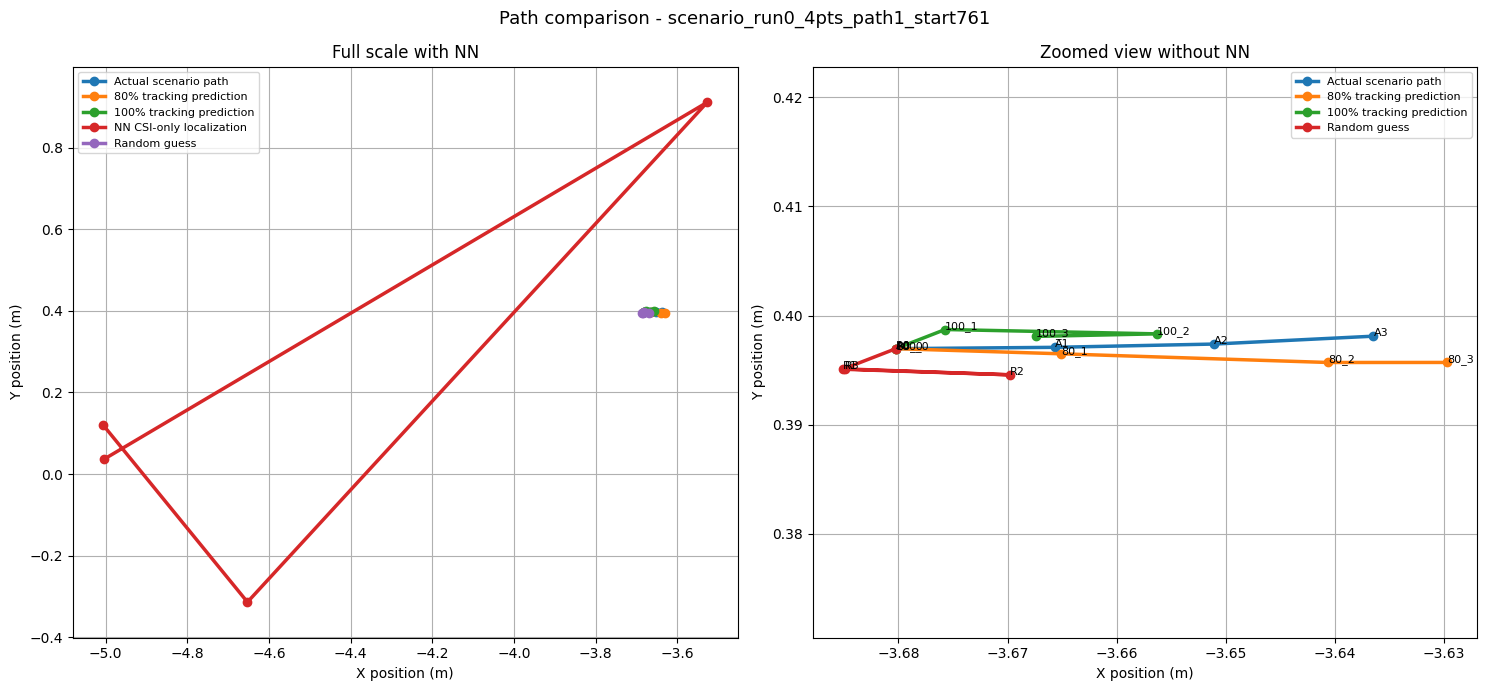

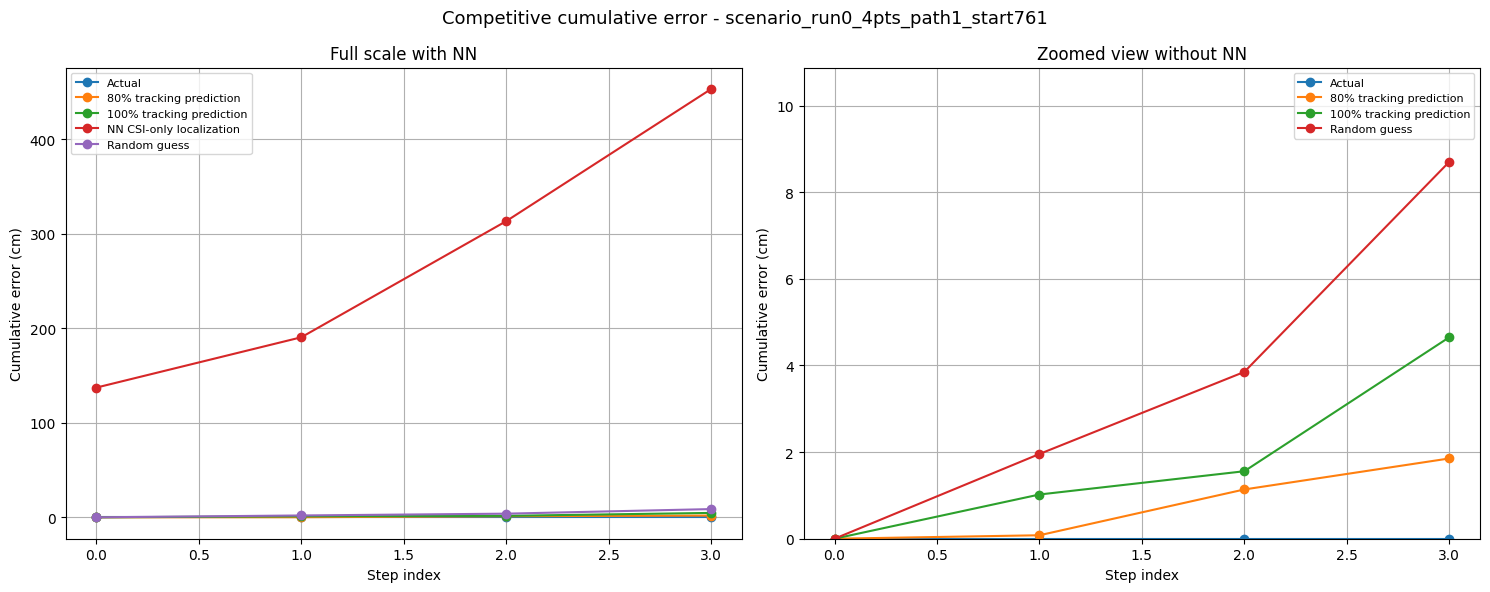

80% cumulative error cm: 1.8532125
100% cumulative error cm: 4.651174
NN cumulative error cm: 453.1179
Random cumulative error cm: 8.701699
80% - 100% difference cm: -2.7979617
NN - 100% difference cm: 448.4667
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path1_start761_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path1_start761_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path1_start761_competitive_cumulative_error.png
Running scenario_run0_4pts_path2_start3045
run_index=0, start_idx=3045, num_points=4


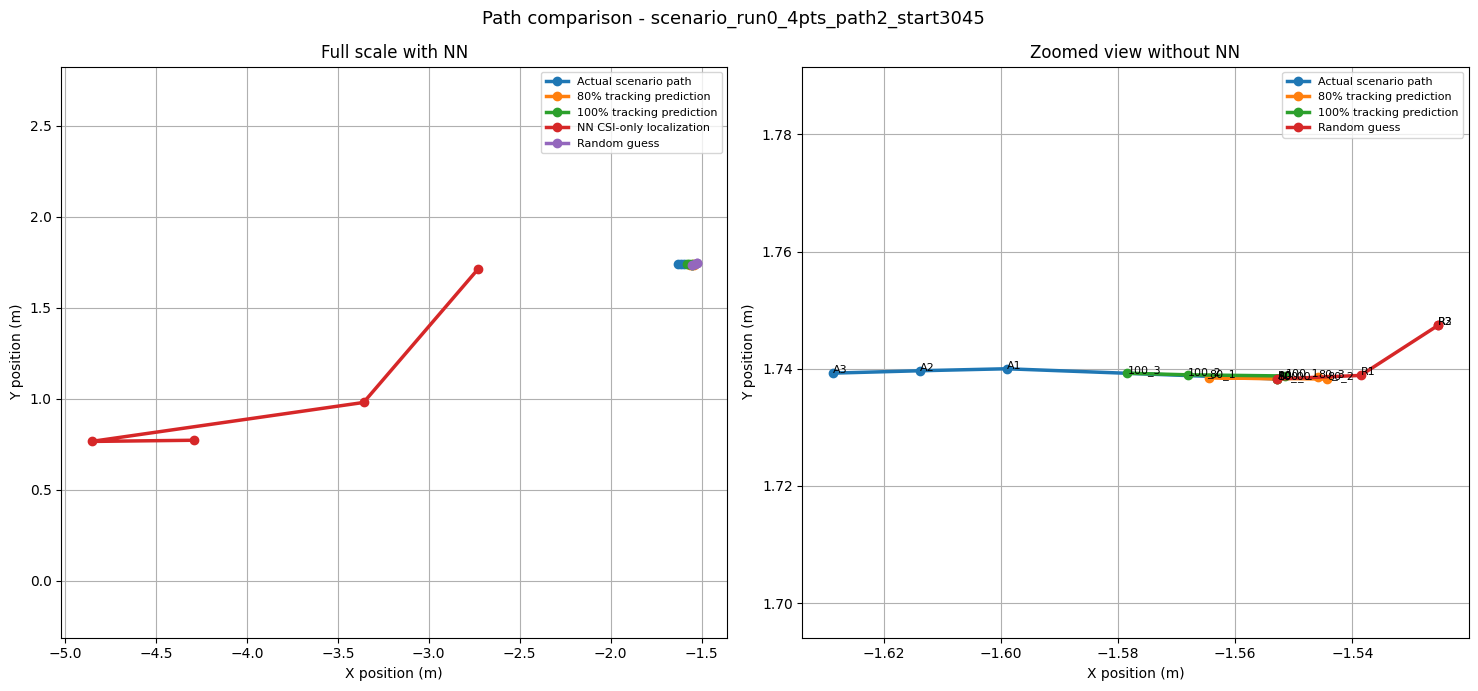

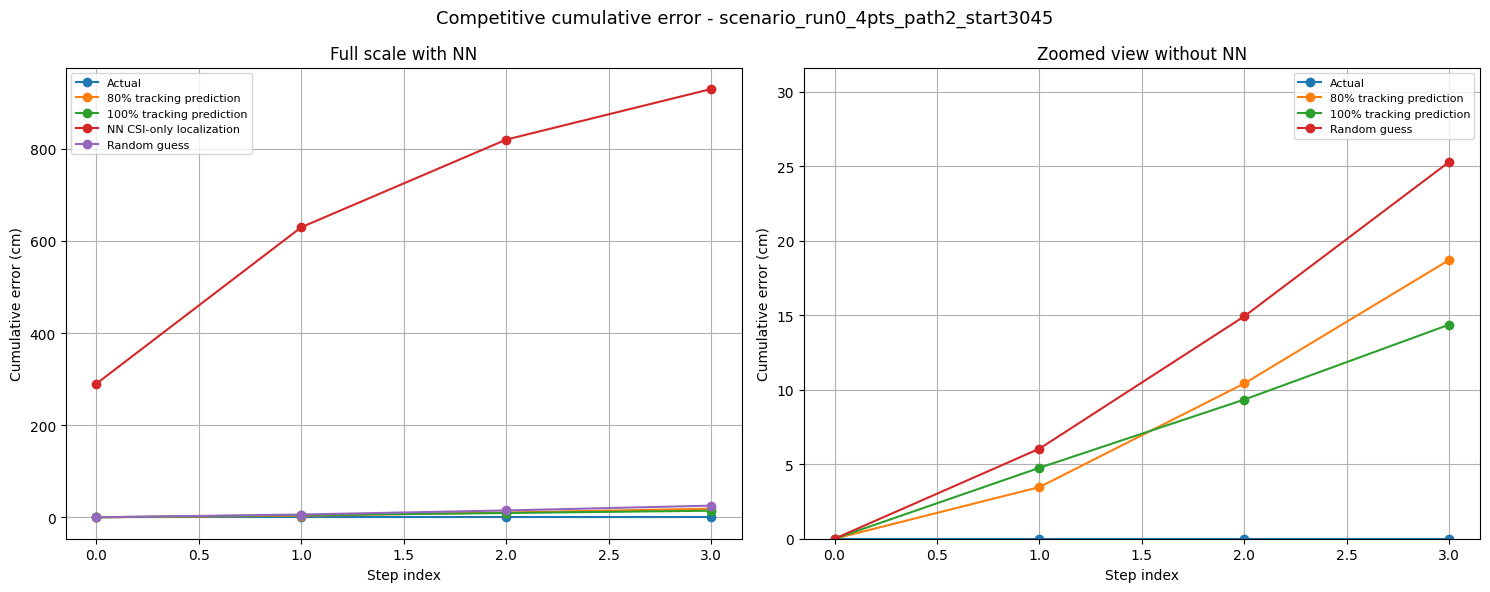

80% cumulative error cm: 18.71298
100% cumulative error cm: 14.371011
NN cumulative error cm: 929.945
Random cumulative error cm: 25.295883
80% - 100% difference cm: 4.3419695
NN - 100% difference cm: 915.574
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path2_start3045_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path2_start3045_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path2_start3045_competitive_cumulative_error.png
Running scenario_run0_4pts_path3_start5329
run_index=0, start_idx=5329, num_points=4


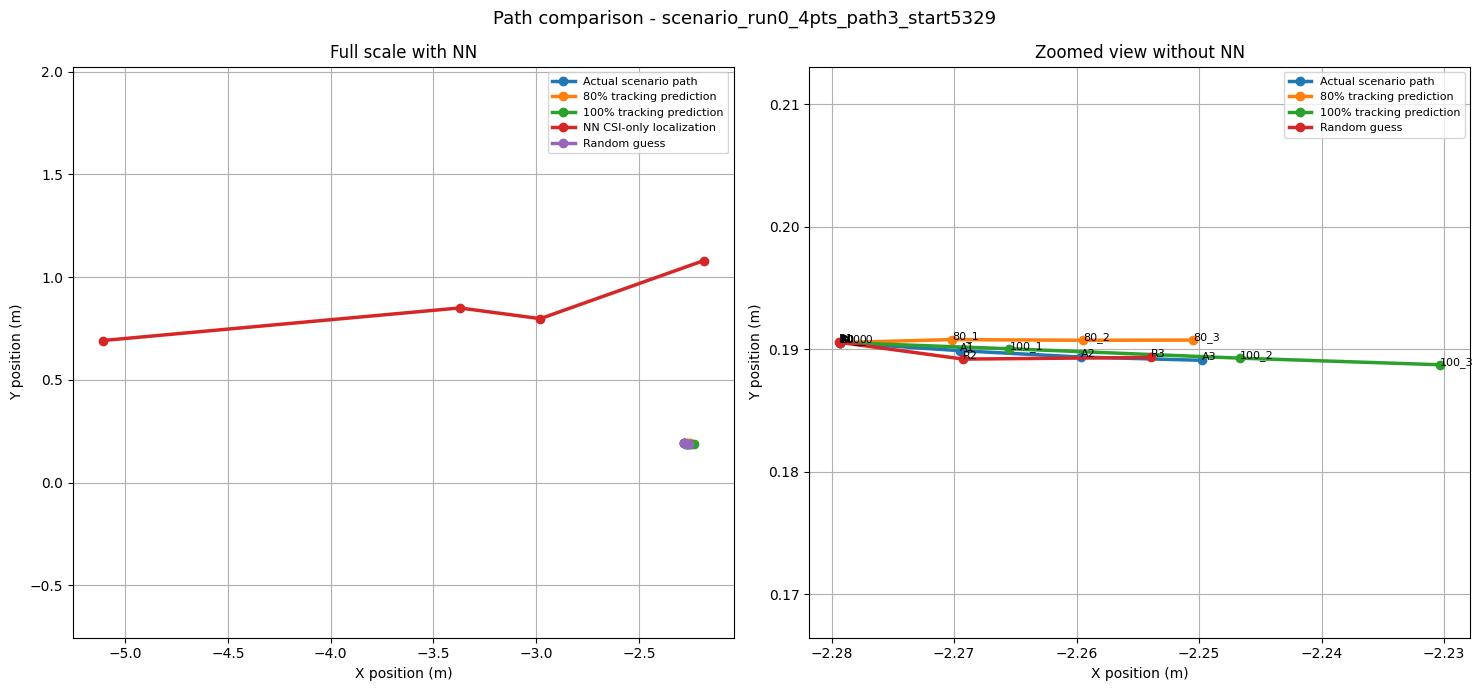

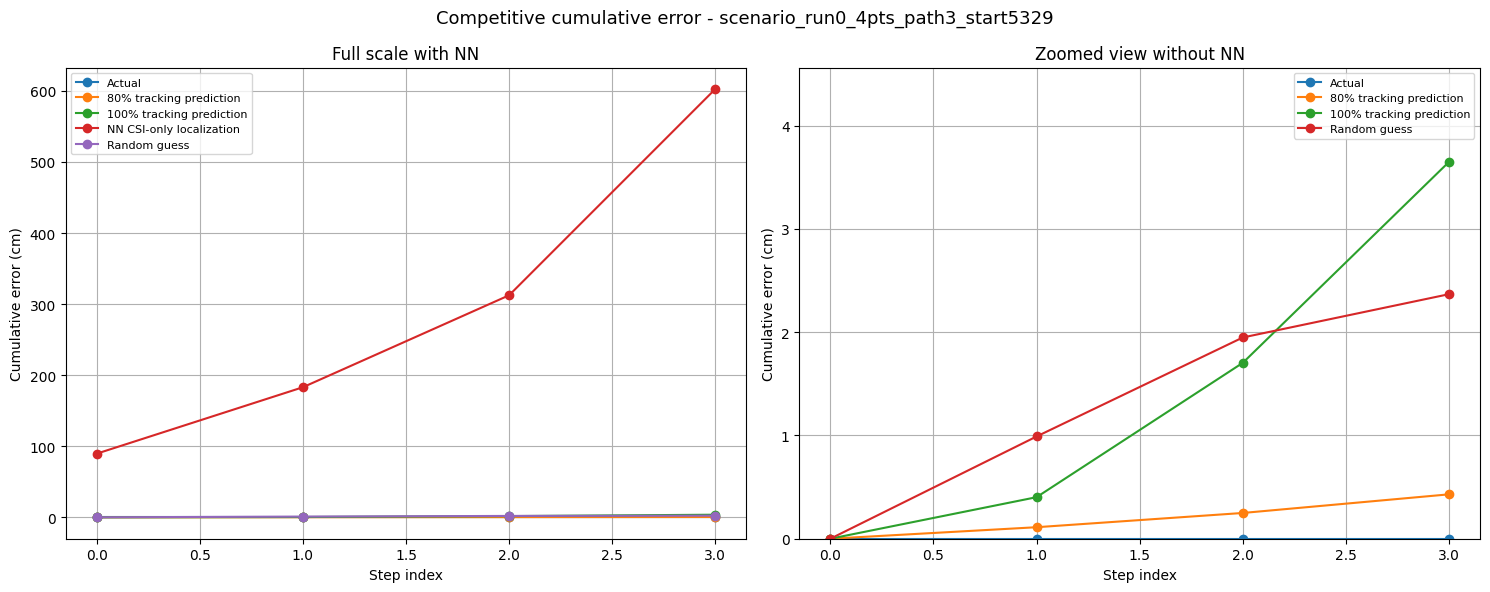

80% cumulative error cm: 0.42981
100% cumulative error cm: 3.64937
NN cumulative error cm: 602.64655
Random cumulative error cm: 2.3679404
80% - 100% difference cm: -3.21956
NN - 100% difference cm: 598.9972
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path3_start5329_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path3_start5329_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path3_start5329_competitive_cumulative_error.png
Running scenario_run0_4pts_path4_start7614
run_index=0, start_idx=7614, num_points=4


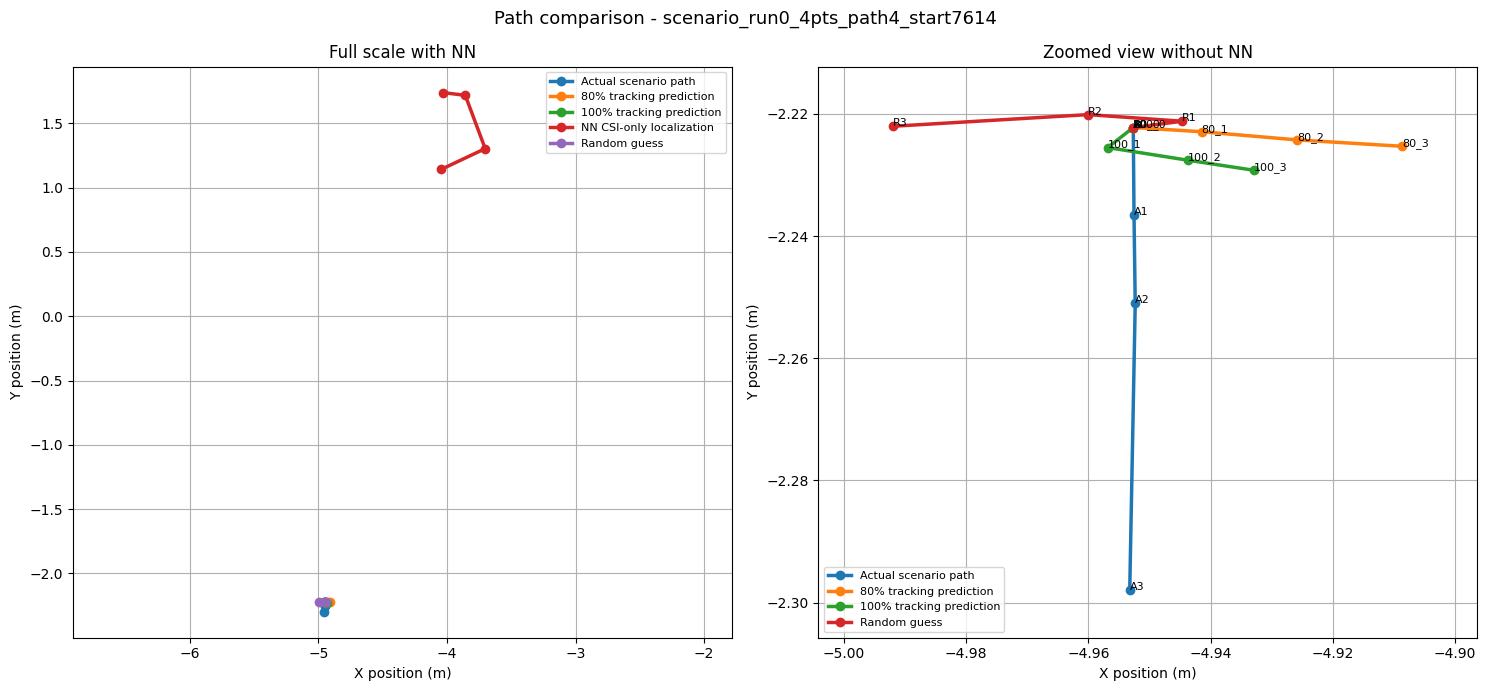

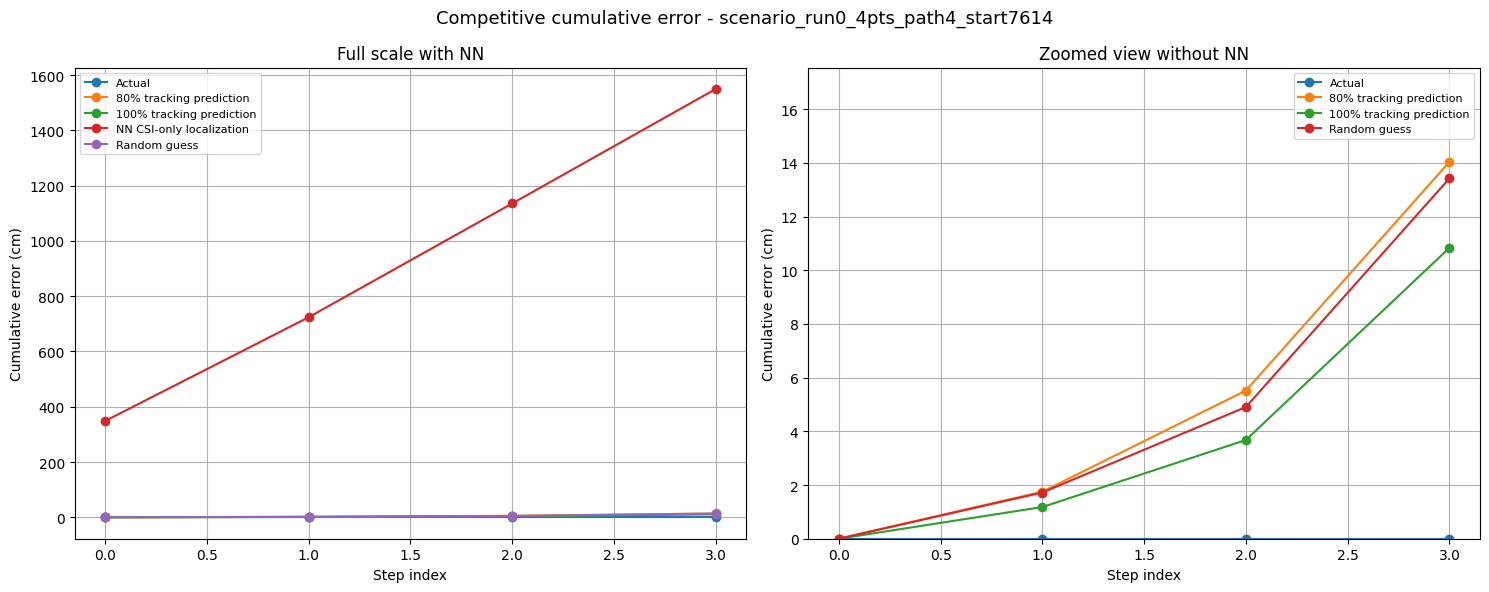

80% cumulative error cm: 14.038831
100% cumulative error cm: 10.836662
NN cumulative error cm: 1549.6196
Random cumulative error cm: 13.422672
80% - 100% difference cm: 3.2021685
NN - 100% difference cm: 1538.783
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path4_start7614_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path4_start7614_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path4_start7614_competitive_cumulative_error.png
Running scenario_run0_4pts_path5_start9898
run_index=0, start_idx=9898, num_points=4


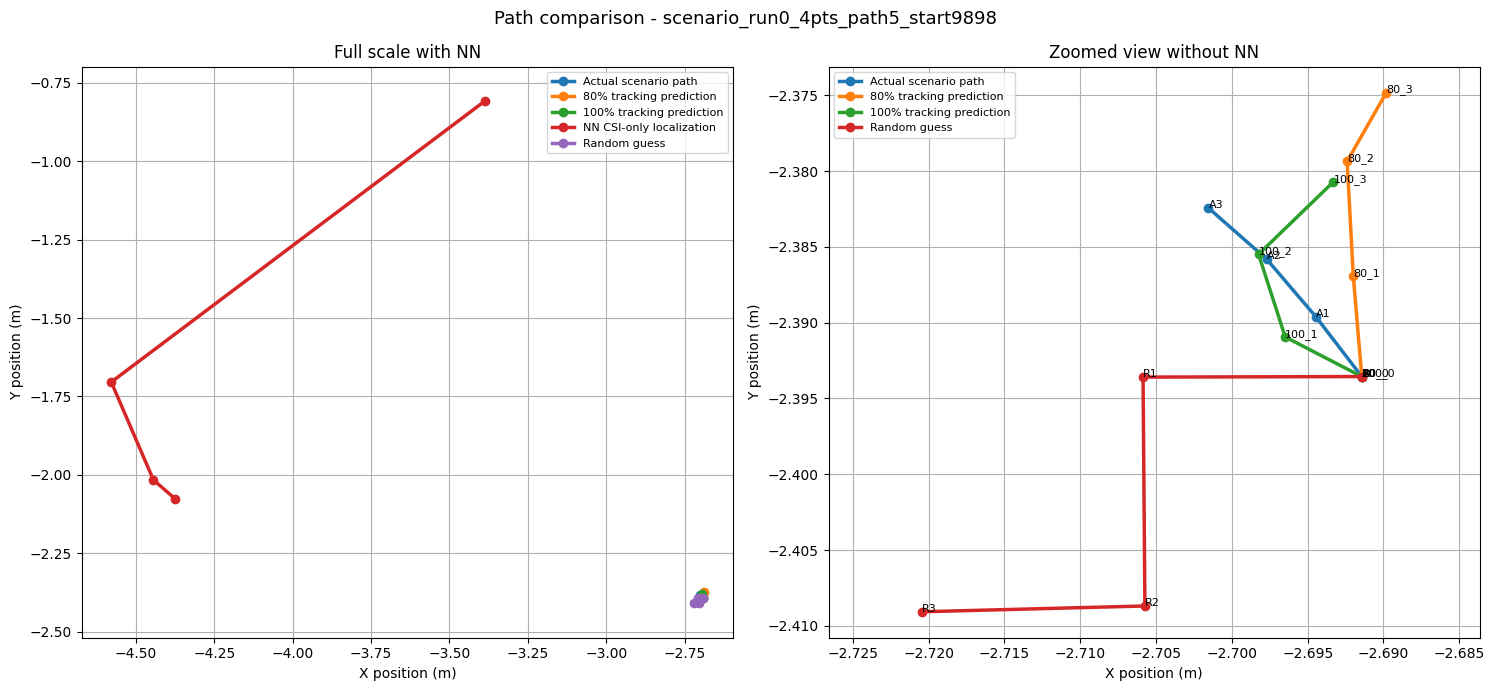

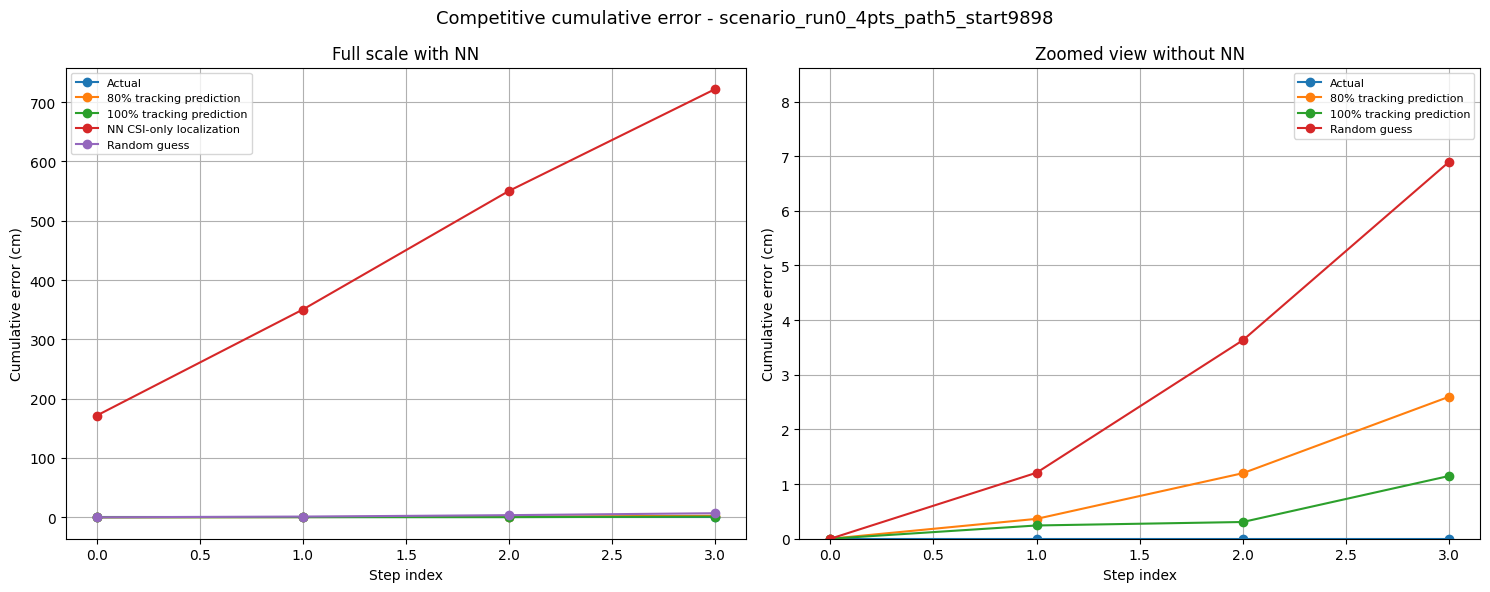

80% cumulative error cm: 2.5978088
100% cumulative error cm: 1.1481338
NN cumulative error cm: 722.045
Random cumulative error cm: 6.896612
80% - 100% difference cm: 1.4496751
NN - 100% difference cm: 720.89685
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path5_start9898_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path5_start9898_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_4pts_path5_start9898_competitive_cumulative_error.png
Running scenario_run0_6pts_path1_start761
run_index=0, start_idx=761, num_points=6


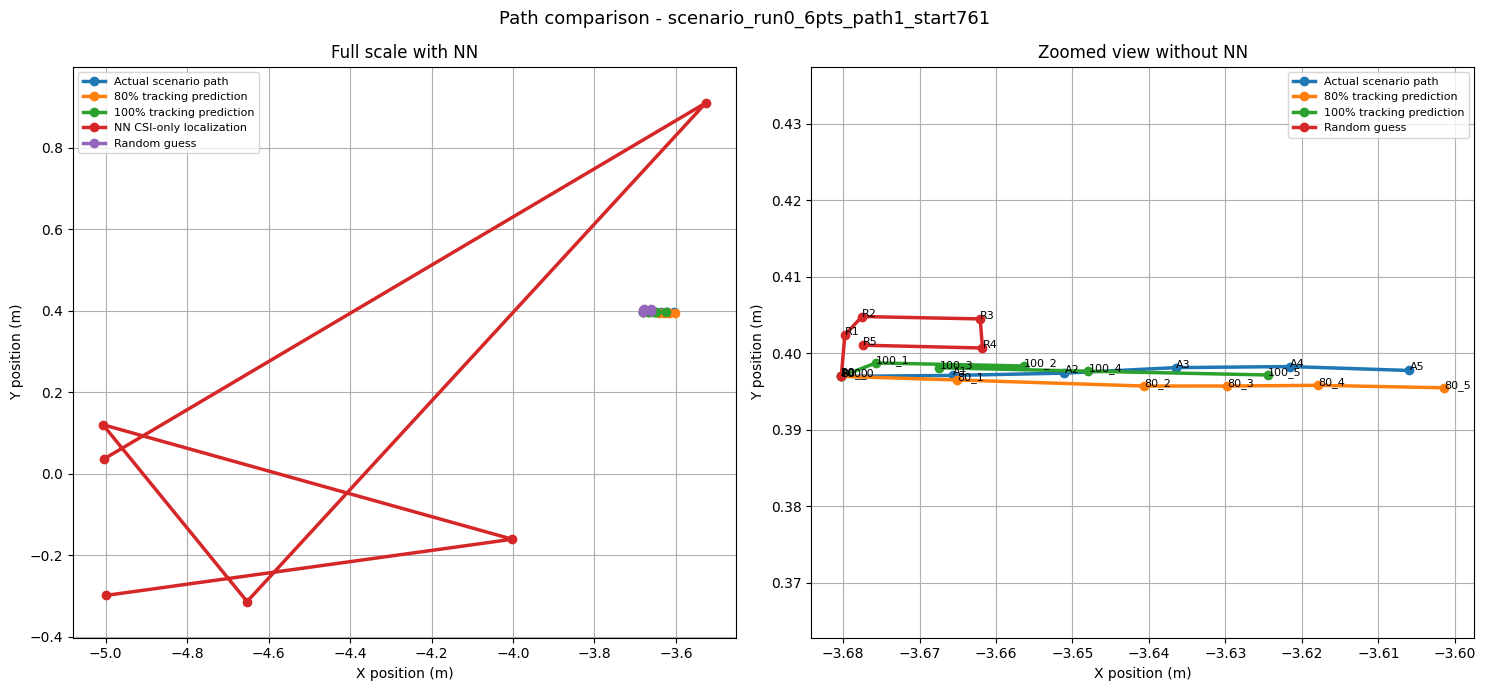

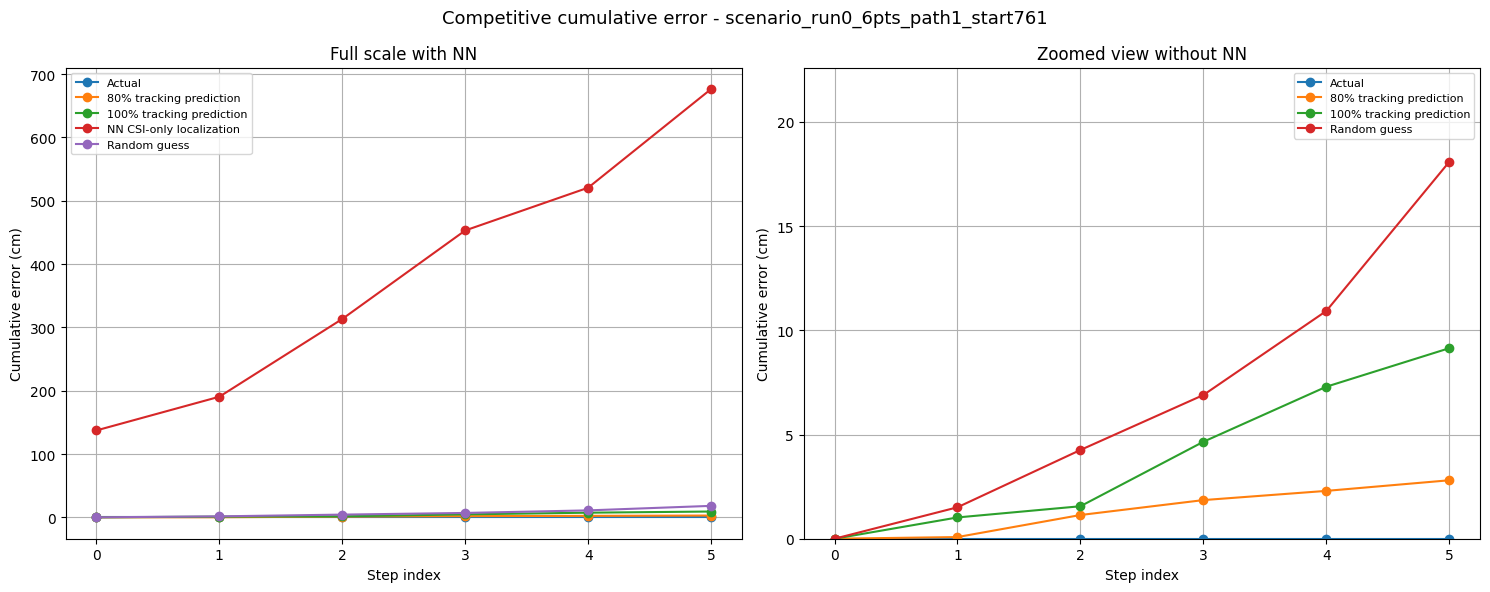

80% cumulative error cm: 2.8041117
100% cumulative error cm: 9.140636
NN cumulative error cm: 676.54517
Random cumulative error cm: 18.08253
80% - 100% difference cm: -6.336525
NN - 100% difference cm: 667.40454
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path1_start761_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path1_start761_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path1_start761_competitive_cumulative_error.png
Running scenario_run0_6pts_path2_start3045
run_index=0, start_idx=3045, num_points=6


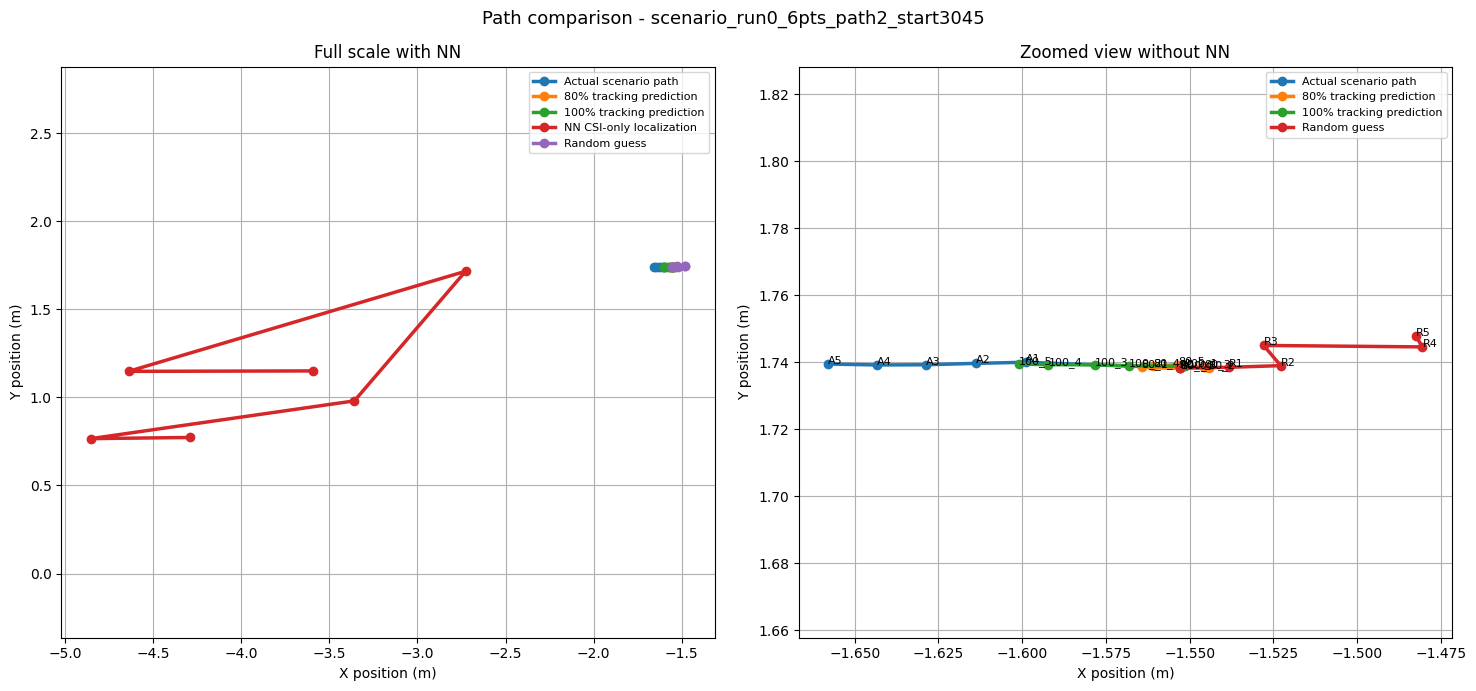

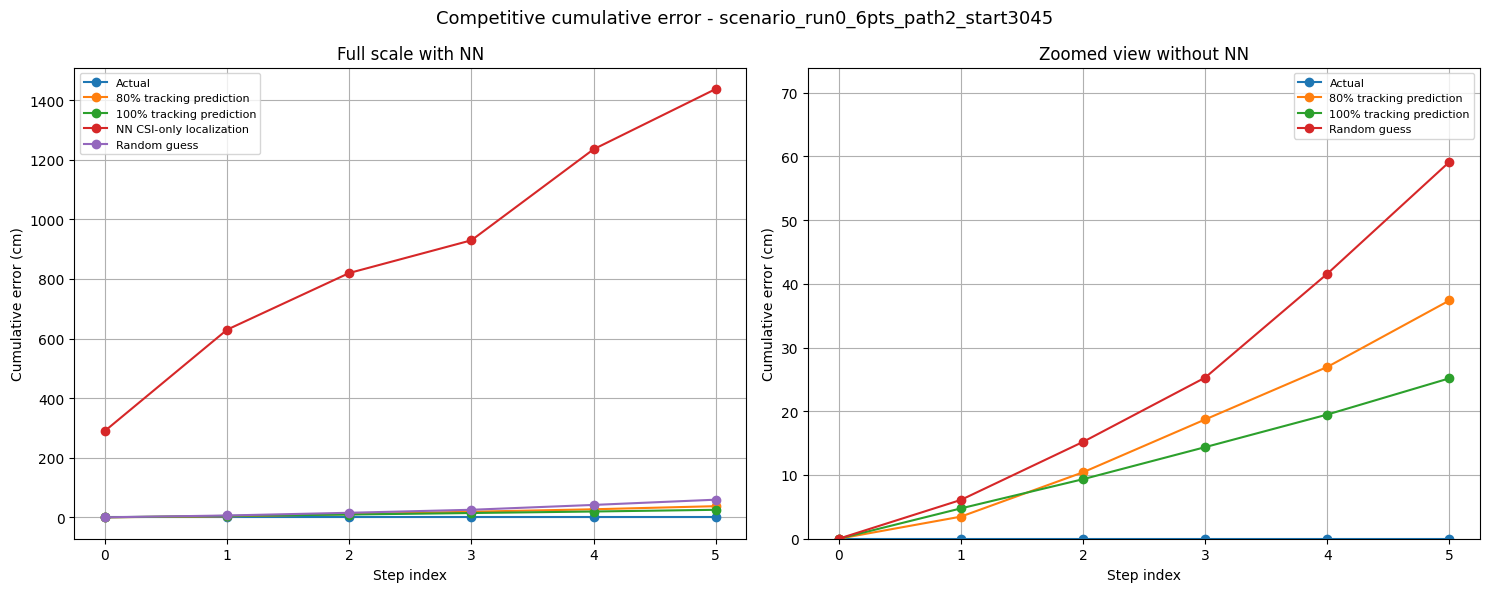

80% cumulative error cm: 37.393852
100% cumulative error cm: 25.173573
NN cumulative error cm: 1437.7572
Random cumulative error cm: 59.14631
80% - 100% difference cm: 12.22028
NN - 100% difference cm: 1412.5836
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path2_start3045_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path2_start3045_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path2_start3045_competitive_cumulative_error.png
Running scenario_run0_6pts_path3_start5329
run_index=0, start_idx=5329, num_points=6


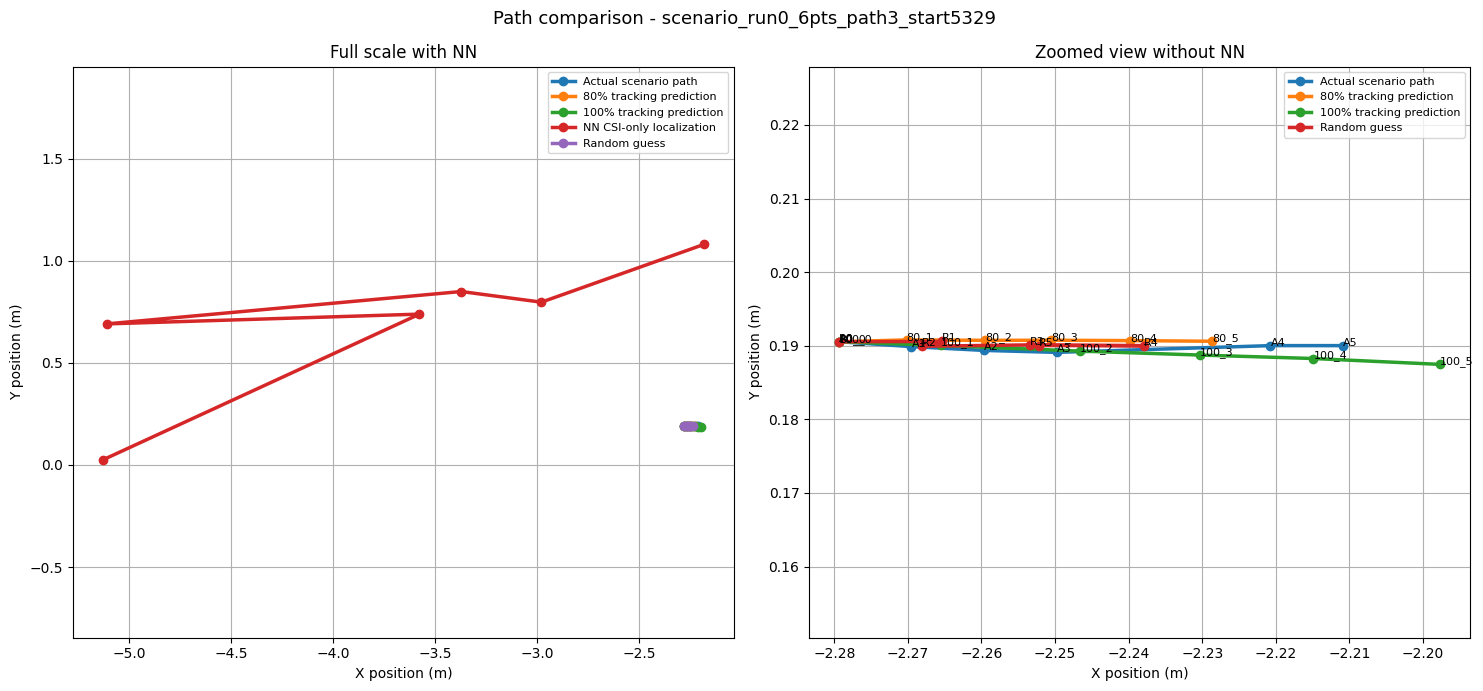

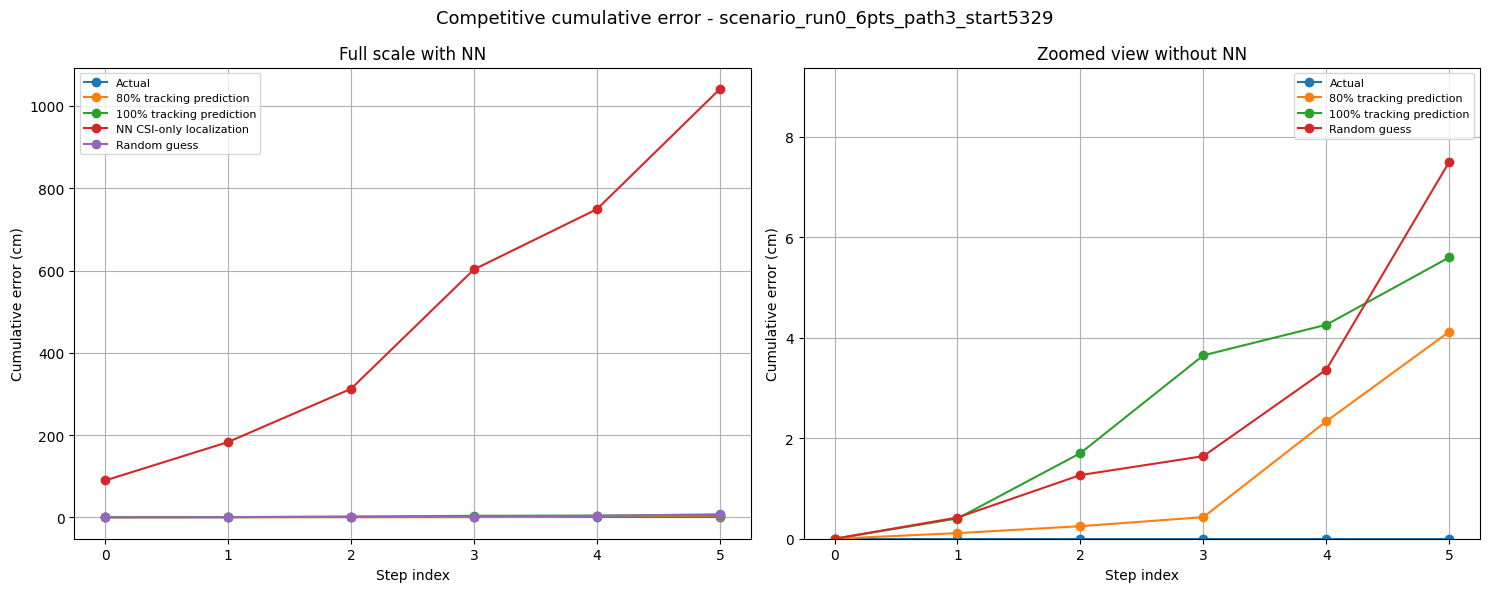

80% cumulative error cm: 4.1205826
100% cumulative error cm: 5.599326
NN cumulative error cm: 1041.2289
Random cumulative error cm: 7.5010033
80% - 100% difference cm: -1.4787436
NN - 100% difference cm: 1035.6295
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path3_start5329_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path3_start5329_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path3_start5329_competitive_cumulative_error.png
Running scenario_run0_6pts_path4_start7613
run_index=0, start_idx=7613, num_points=6


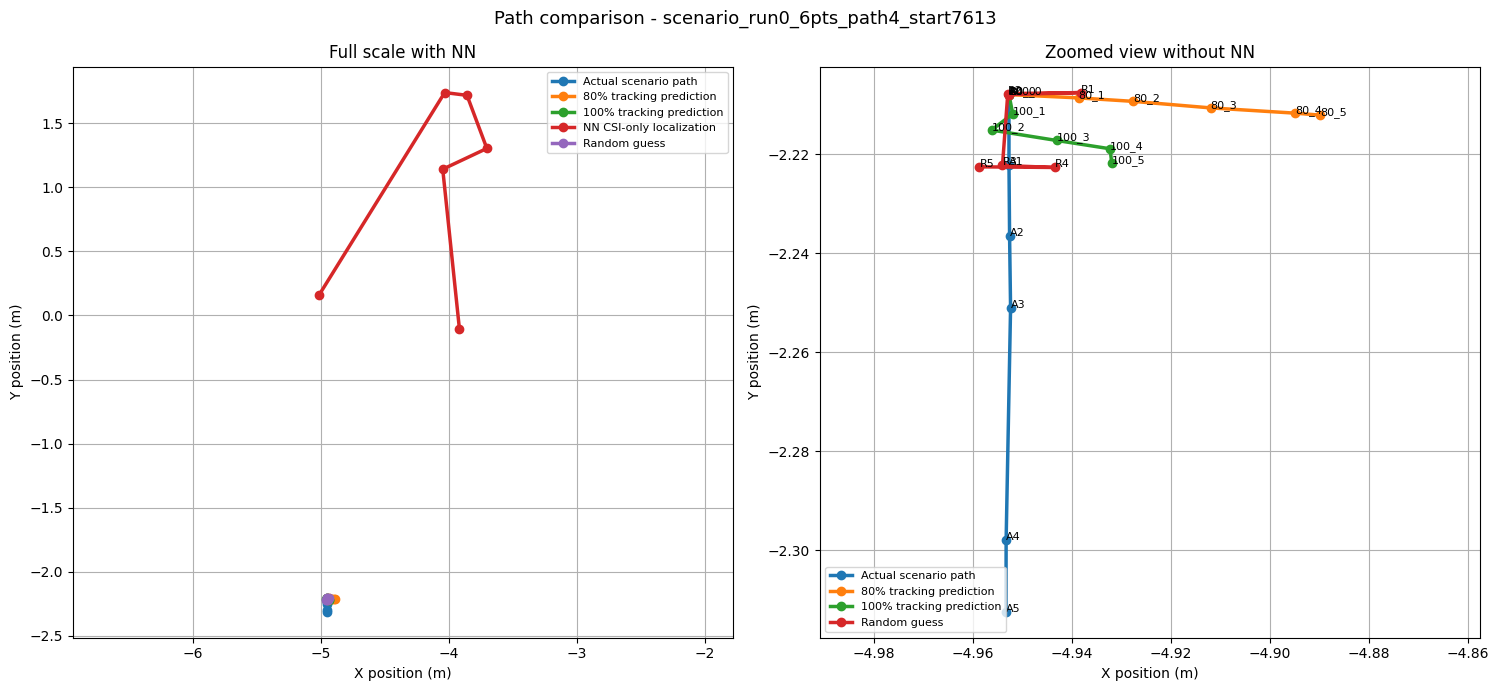

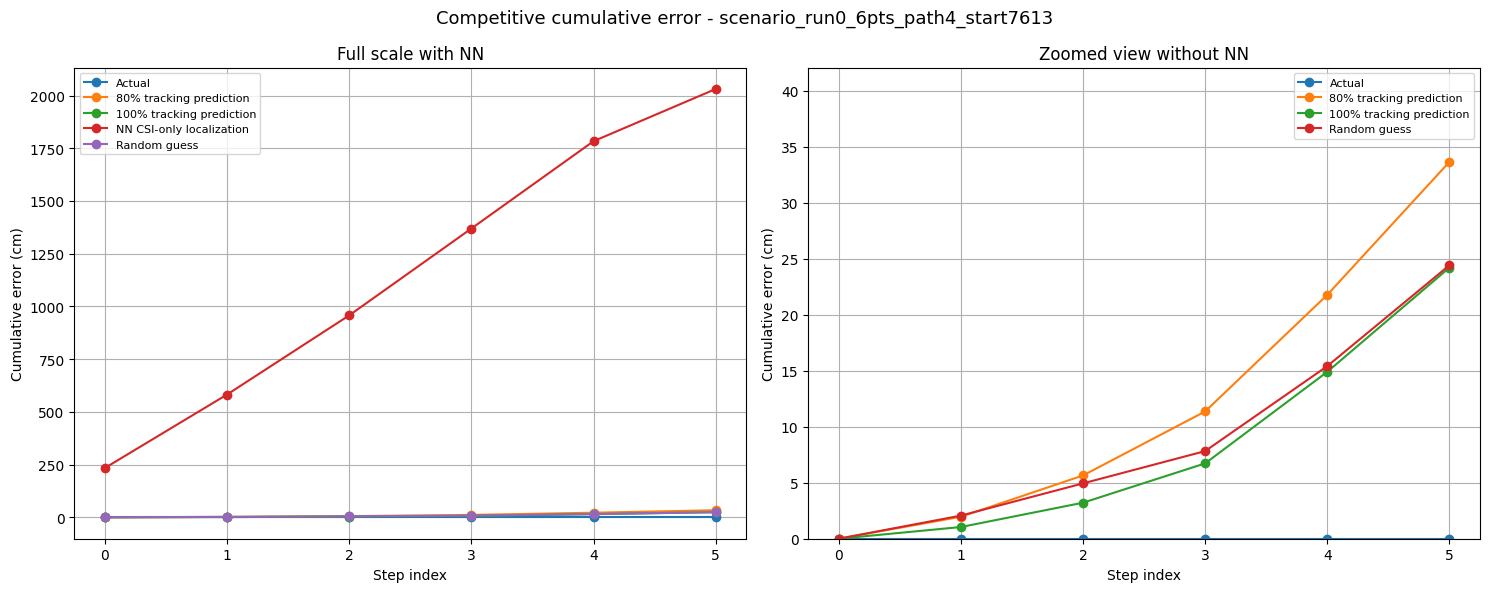

80% cumulative error cm: 33.63707
100% cumulative error cm: 24.199799
NN cumulative error cm: 2031.0453
Random cumulative error cm: 24.40869
80% - 100% difference cm: 9.437271
NN - 100% difference cm: 2006.8455
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path4_start7613_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path4_start7613_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path4_start7613_competitive_cumulative_error.png
Running scenario_run0_6pts_path5_start9896
run_index=0, start_idx=9896, num_points=6


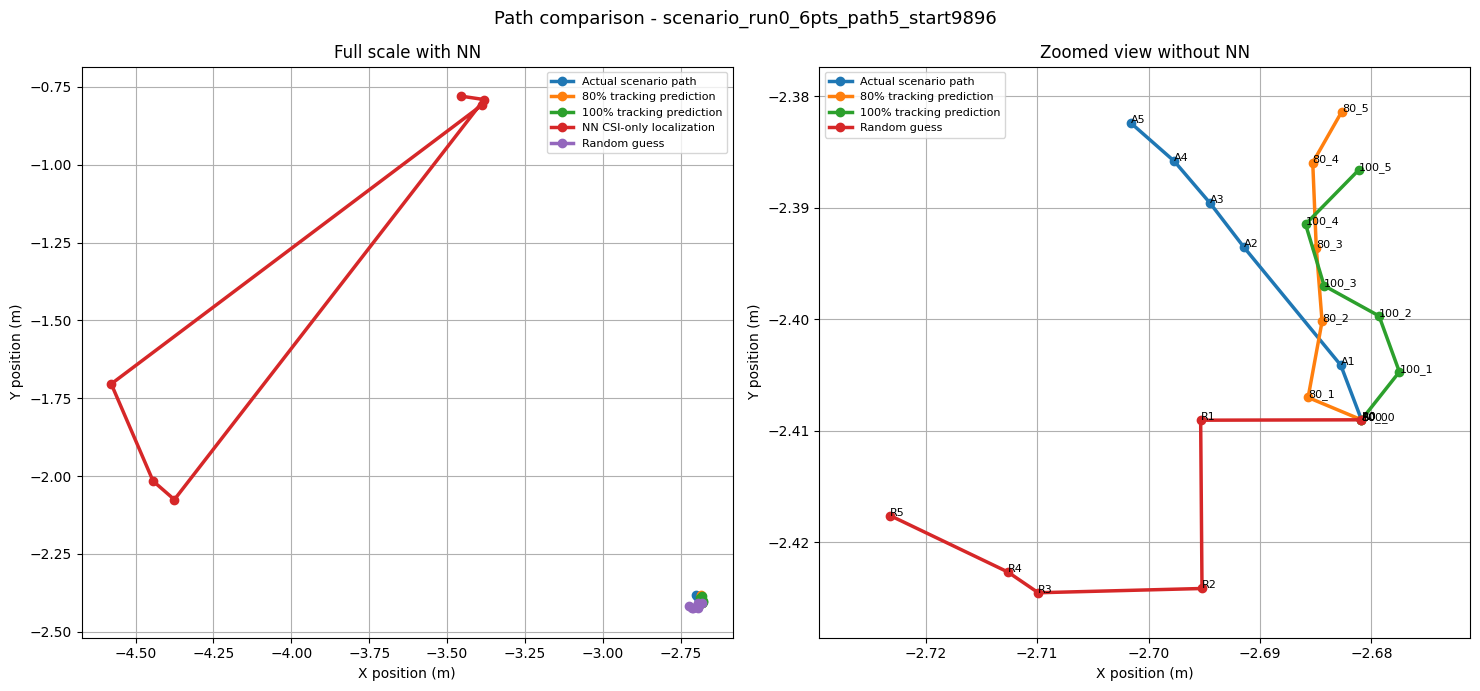

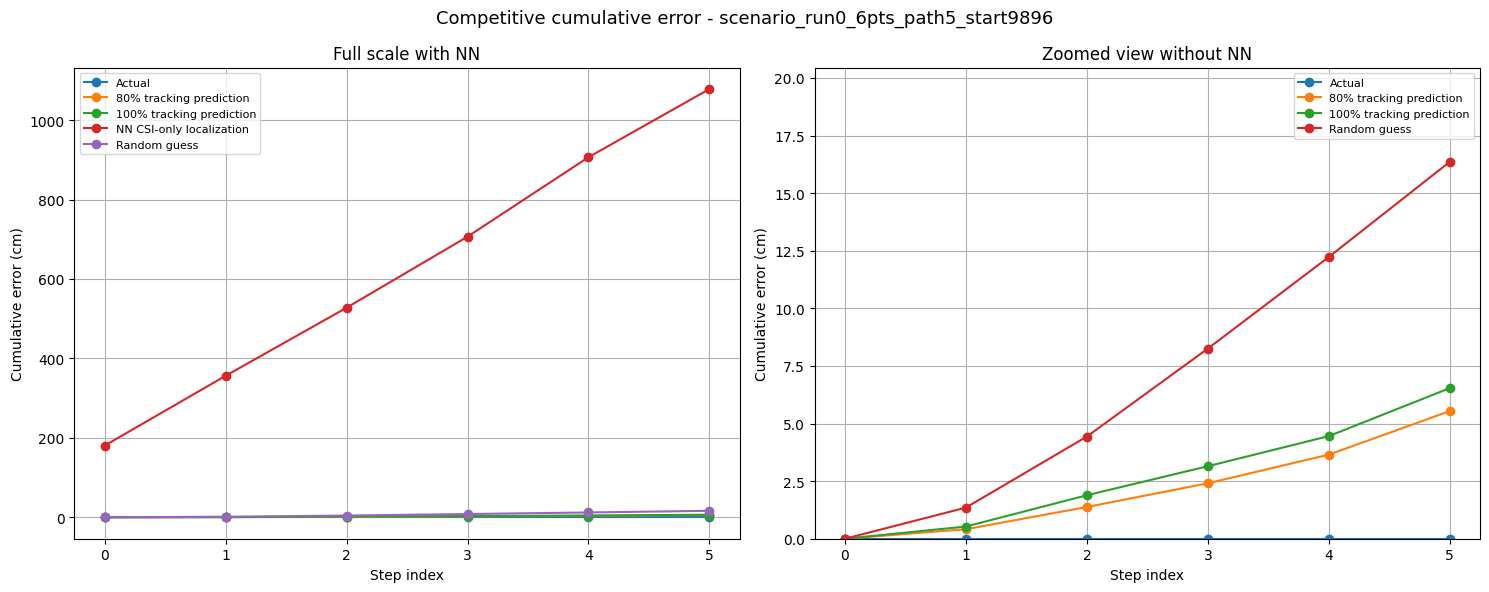

80% cumulative error cm: 5.5408707
100% cumulative error cm: 6.5355167
NN cumulative error cm: 1078.269
Random cumulative error cm: 16.358522
80% - 100% difference cm: -0.9946461
NN - 100% difference cm: 1071.7335
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path5_start9896_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path5_start9896_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_6pts_path5_start9896_competitive_cumulative_error.png
Running scenario_run0_8pts_path1_start761
run_index=0, start_idx=761, num_points=8


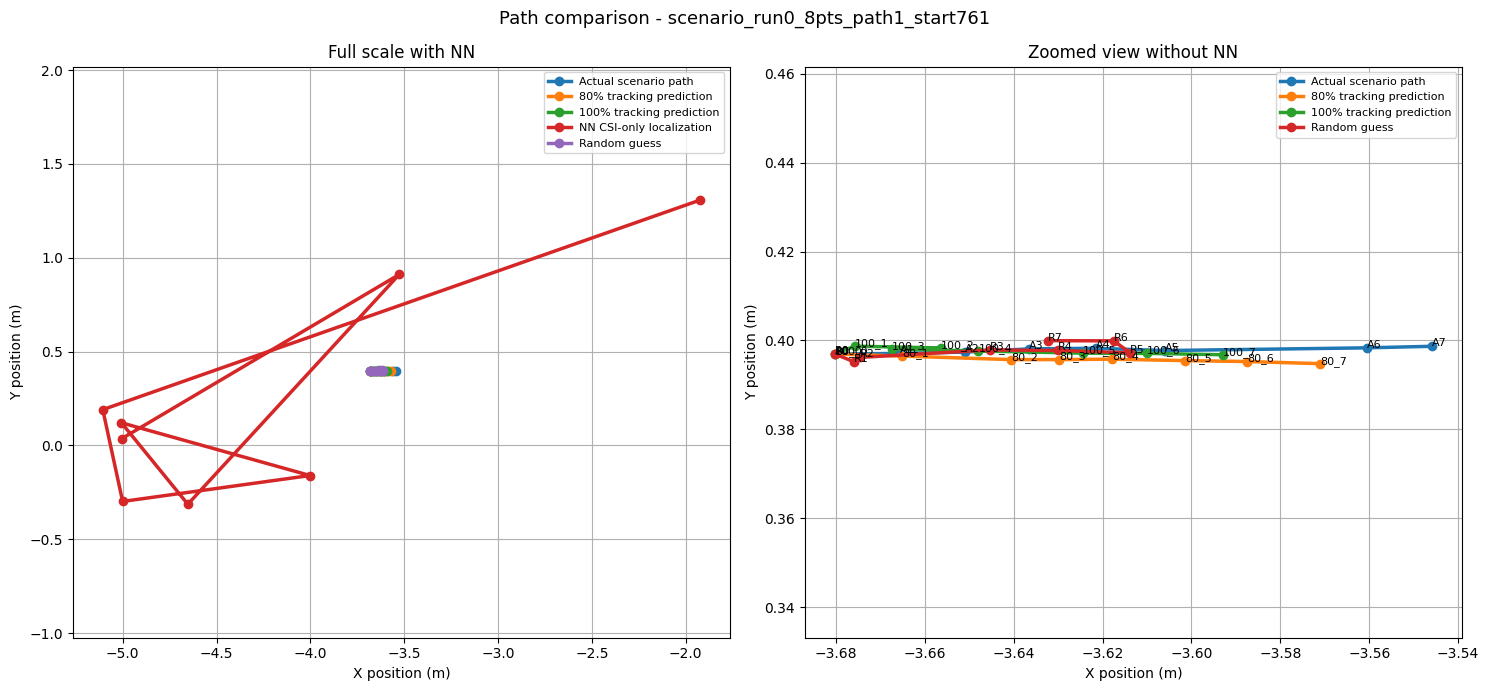

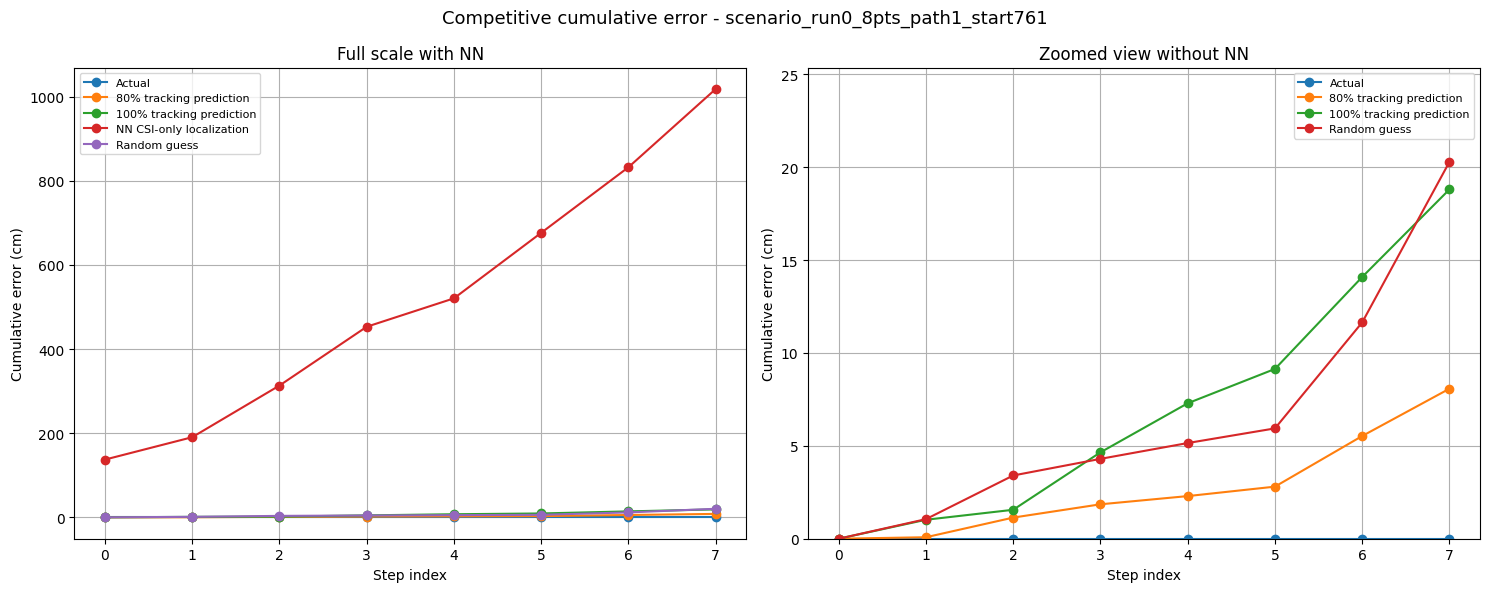

80% cumulative error cm: 8.077164
100% cumulative error cm: 18.808172
NN cumulative error cm: 1018.4755
Random cumulative error cm: 20.291815
80% - 100% difference cm: -10.731009
NN - 100% difference cm: 999.66736
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path1_start761_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path1_start761_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path1_start761_competitive_cumulative_error.png
Running scenario_run0_8pts_path2_start3044
run_index=0, start_idx=3044, num_points=8


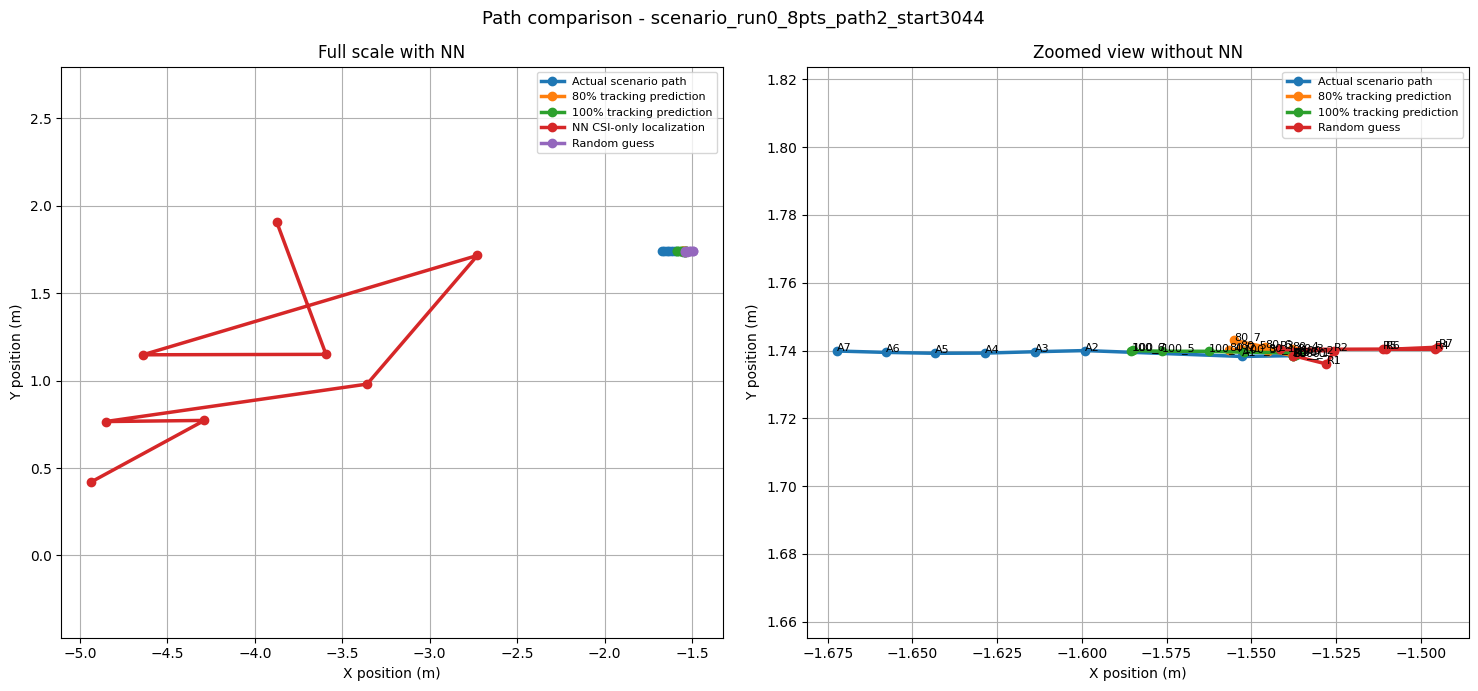

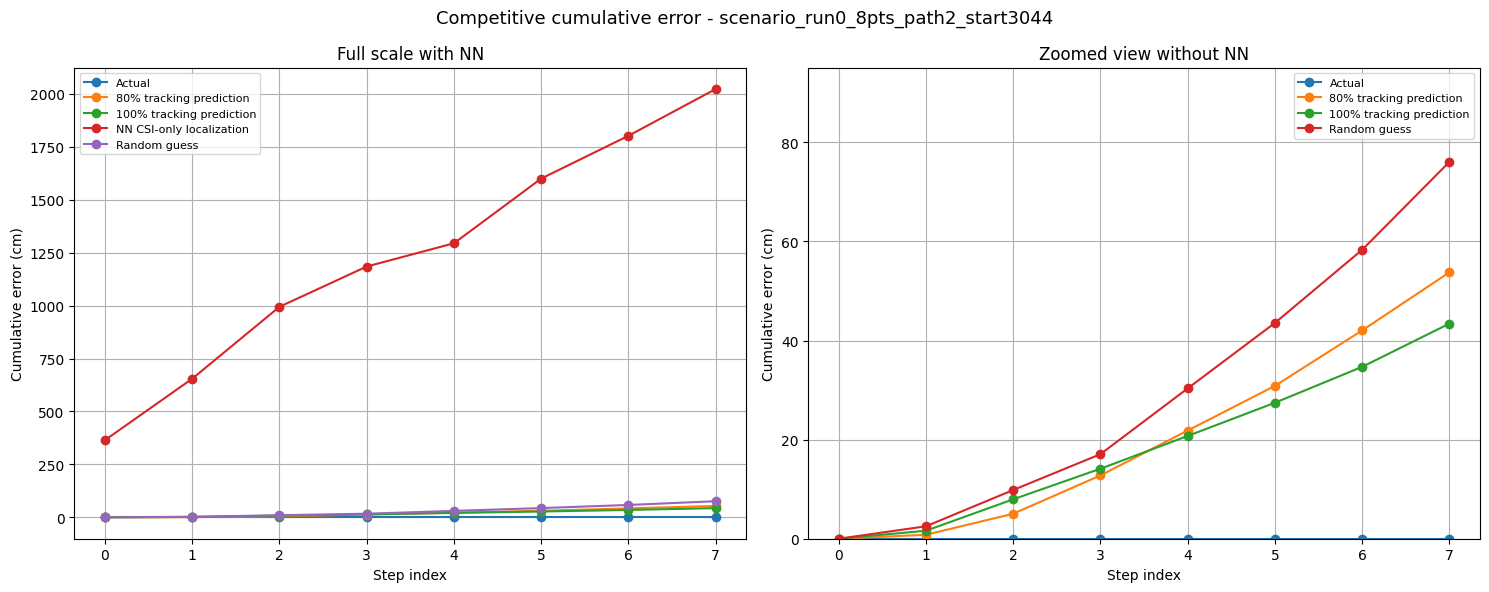

80% cumulative error cm: 53.7755
100% cumulative error cm: 43.424767
NN cumulative error cm: 2023.0015
Random cumulative error cm: 76.07153
80% - 100% difference cm: 10.350735
NN - 100% difference cm: 1979.5767
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path2_start3044_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path2_start3044_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path2_start3044_competitive_cumulative_error.png
Running scenario_run0_8pts_path3_start5328
run_index=0, start_idx=5328, num_points=8


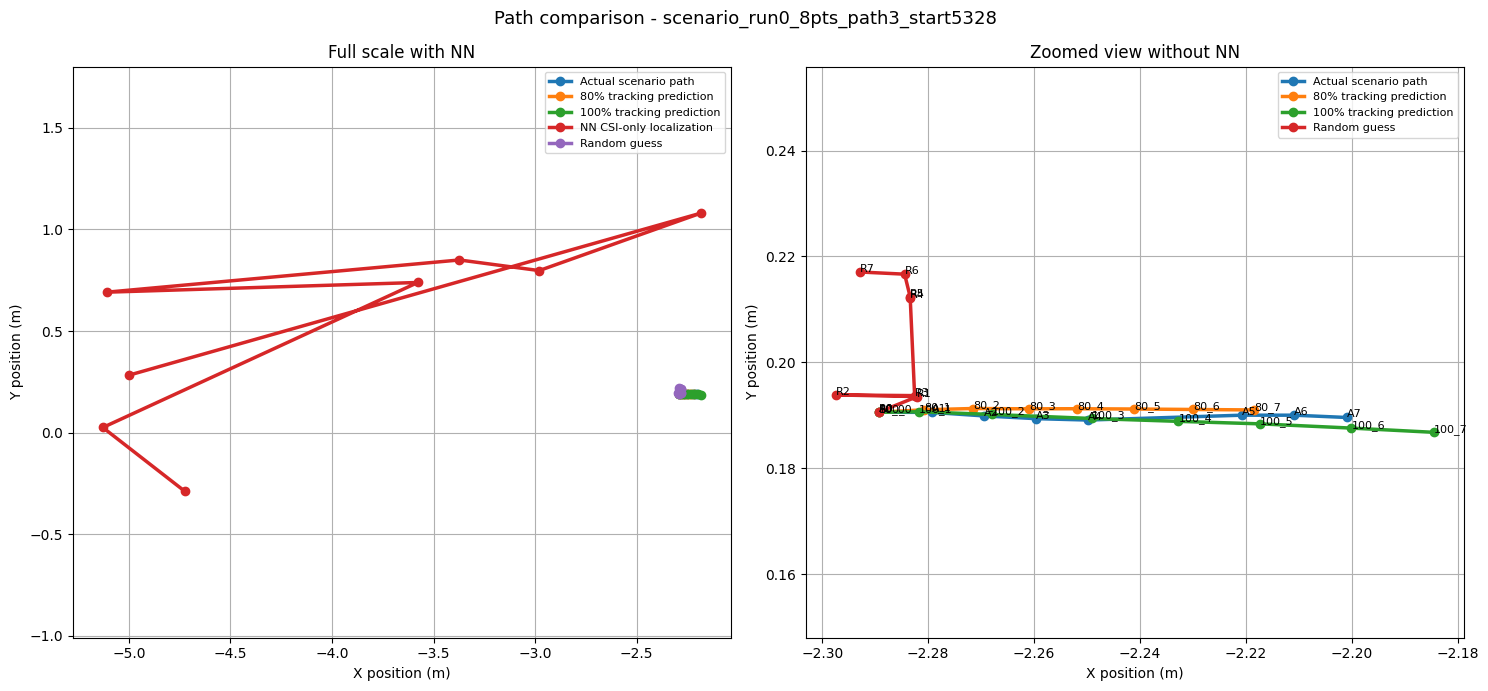

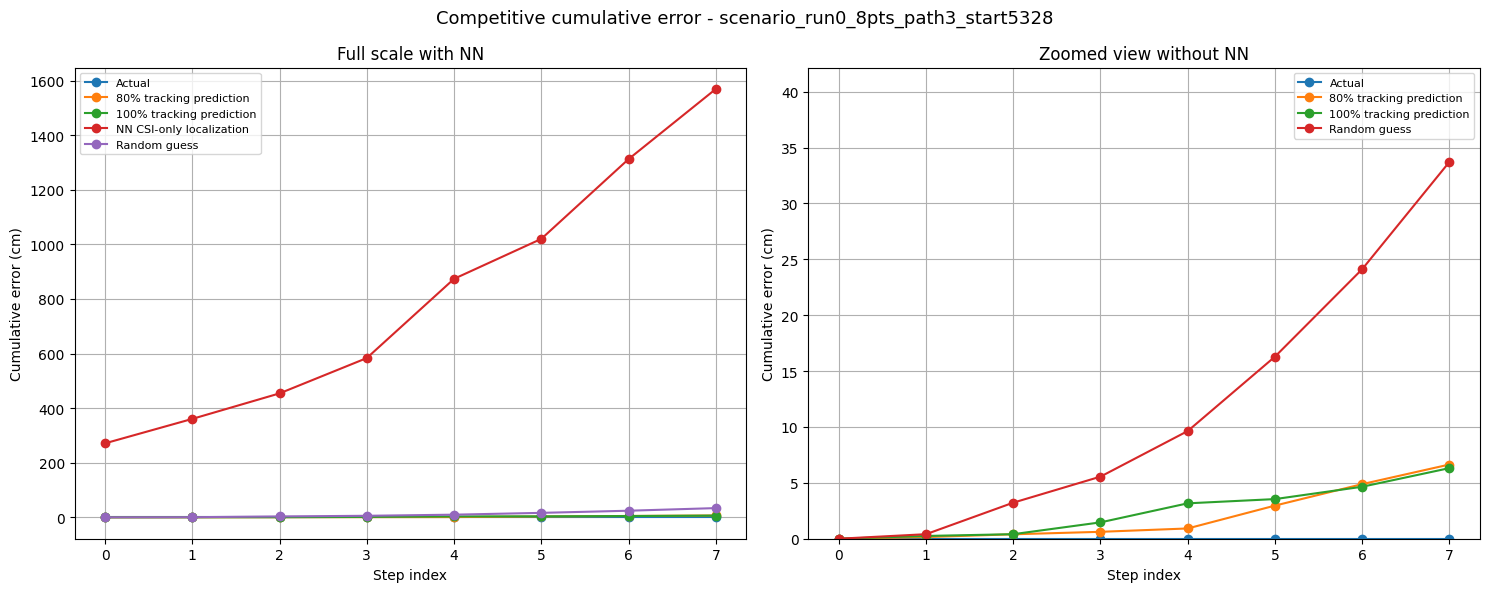

80% cumulative error cm: 6.641189
100% cumulative error cm: 6.31897
NN cumulative error cm: 1569.283
Random cumulative error cm: 33.724674
80% - 100% difference cm: 0.3222189
NN - 100% difference cm: 1562.964
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path3_start5328_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path3_start5328_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path3_start5328_competitive_cumulative_error.png
Running scenario_run0_8pts_path4_start7612
run_index=0, start_idx=7612, num_points=8


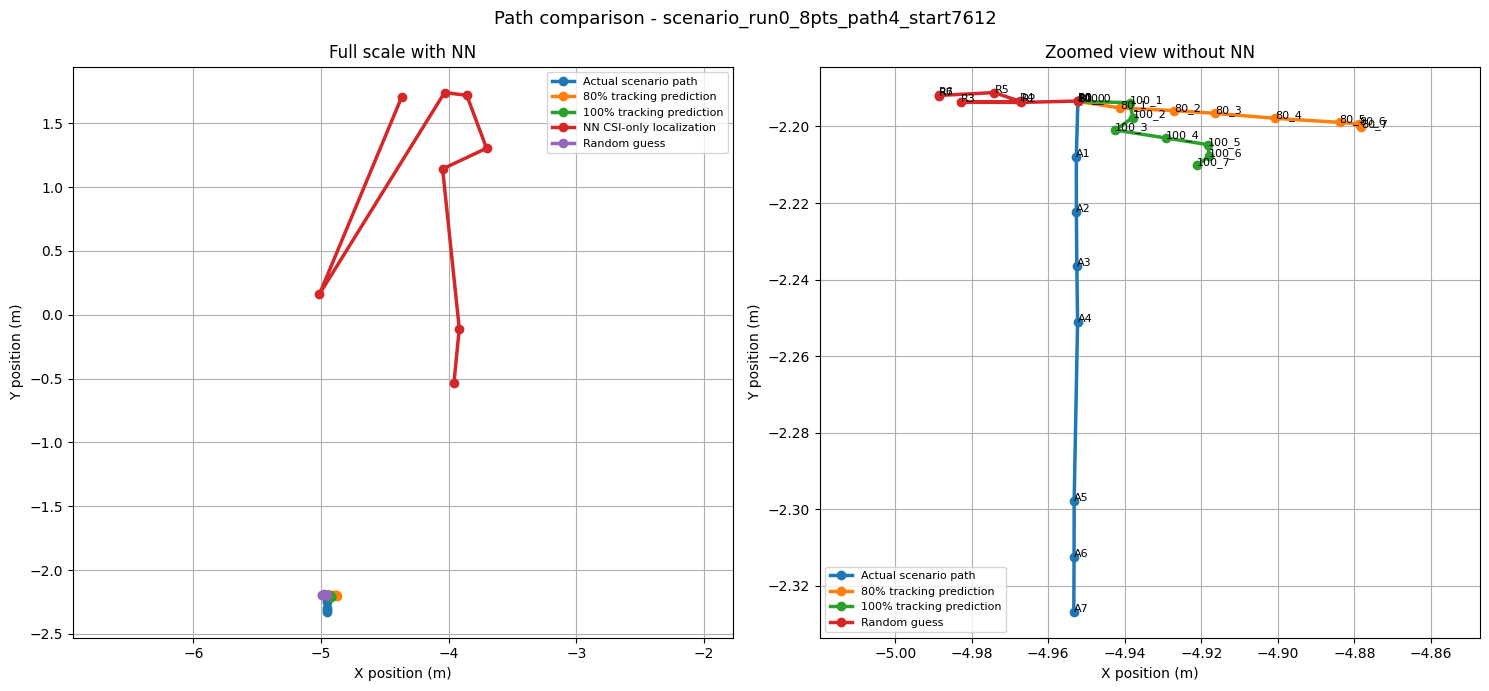

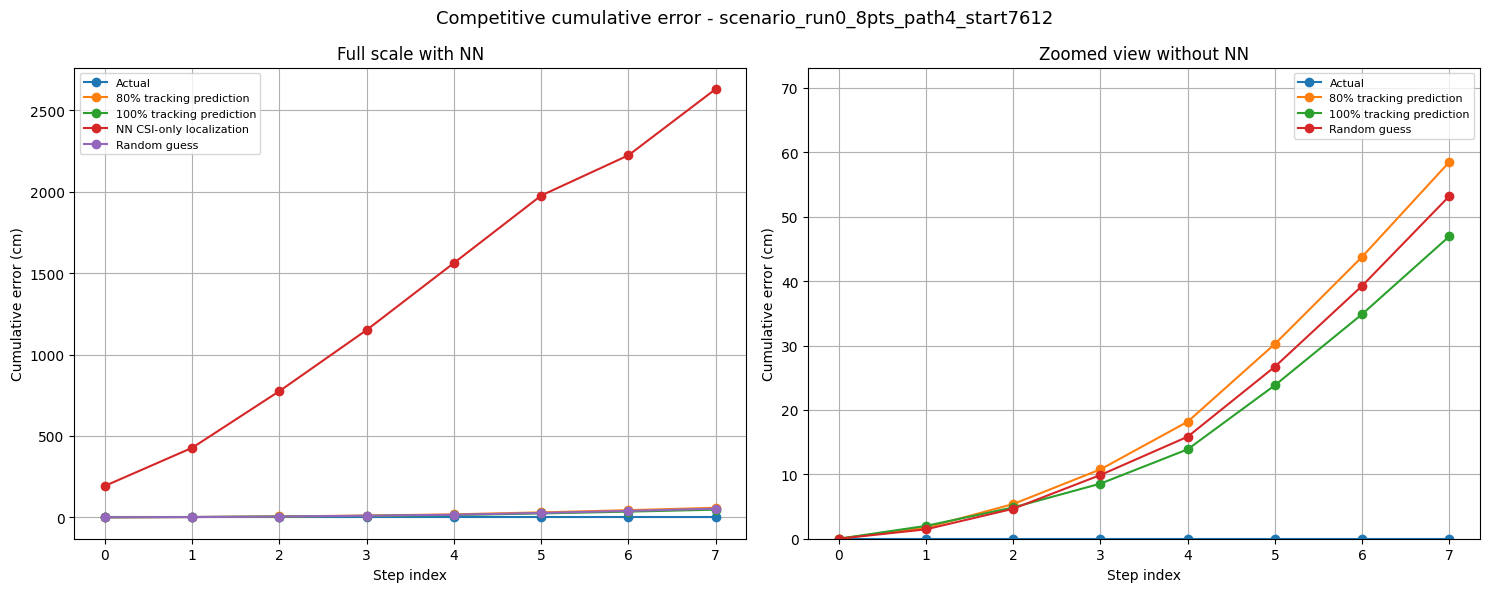

80% cumulative error cm: 58.518757
100% cumulative error cm: 46.97291
NN cumulative error cm: 2631.1682
Random cumulative error cm: 53.21705
80% - 100% difference cm: 11.545845
NN - 100% difference cm: 2584.1953
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path4_start7612_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path4_start7612_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path4_start7612_competitive_cumulative_error.png
Running scenario_run0_8pts_path5_start9895
run_index=0, start_idx=9895, num_points=8


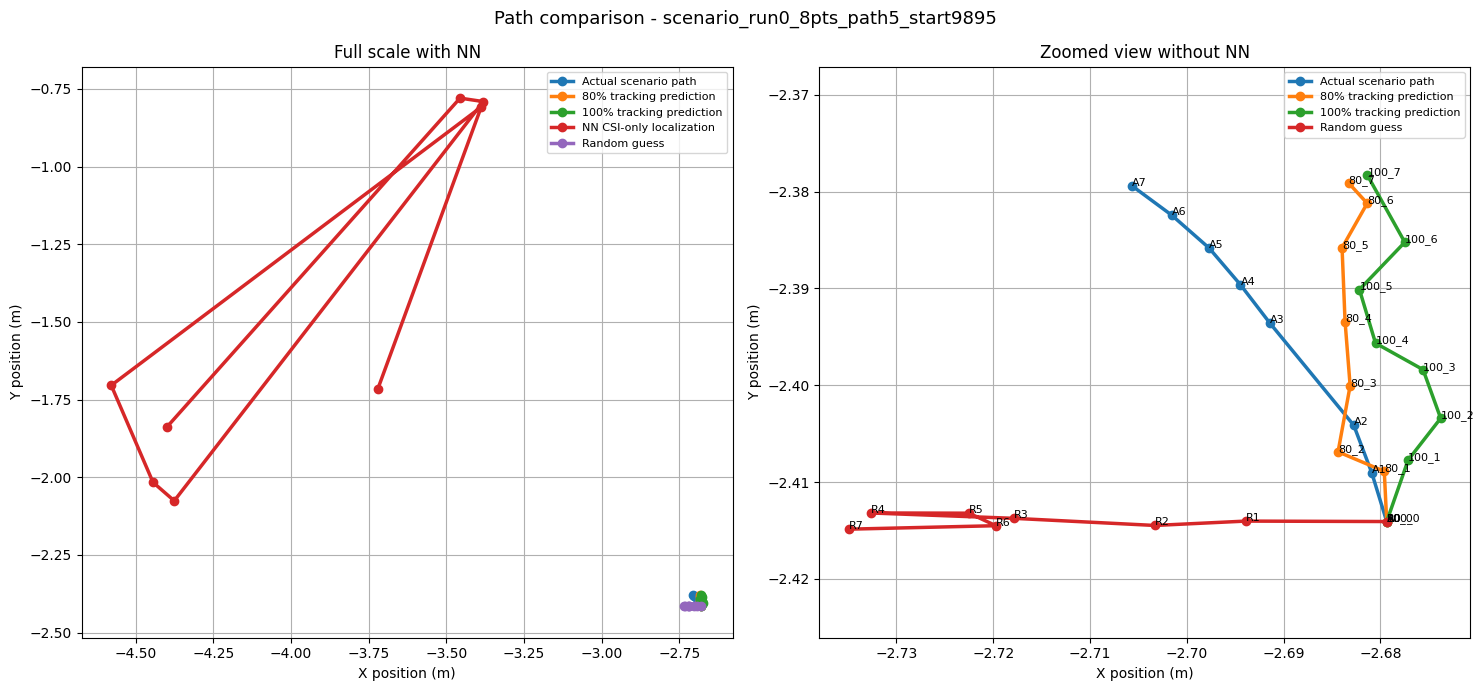

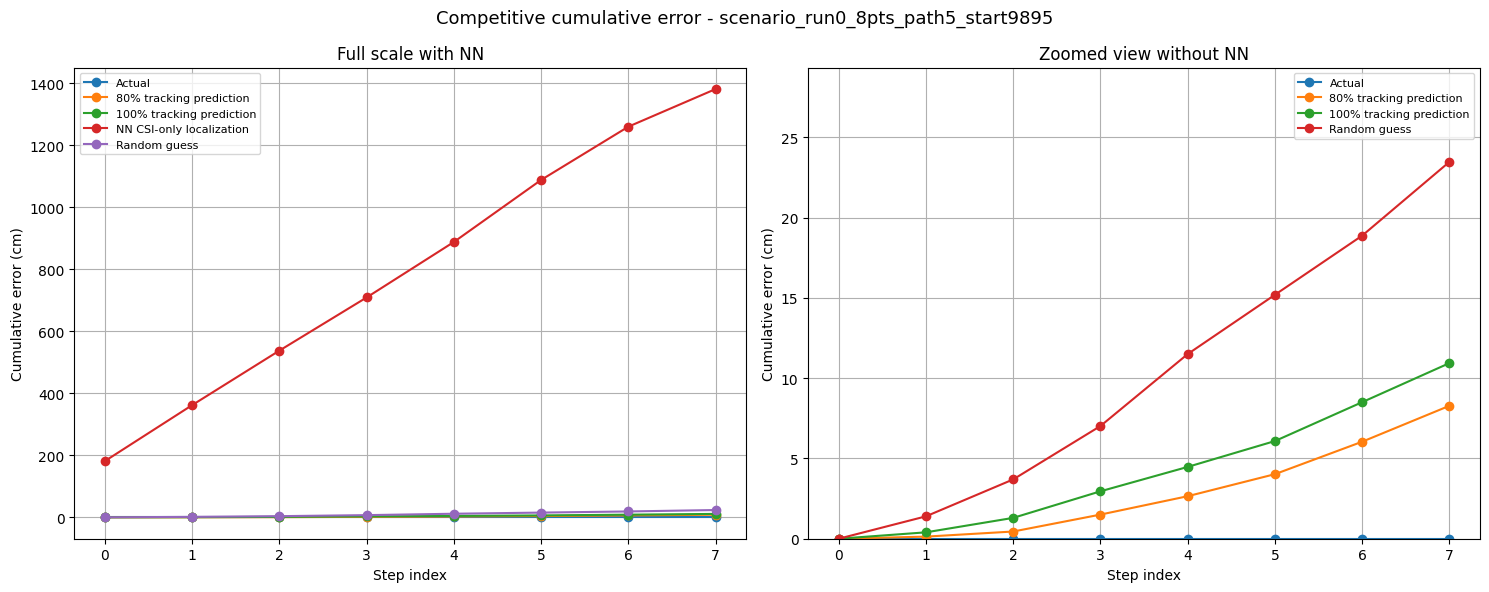

80% cumulative error cm: 8.283726
100% cumulative error cm: 10.943055
NN cumulative error cm: 1380.9307
Random cumulative error cm: 23.48345
80% - 100% difference cm: -2.6593294
NN - 100% difference cm: 1369.9875
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path5_start9895_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path5_start9895_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_8pts_path5_start9895_competitive_cumulative_error.png
Running scenario_run0_10pts_path1_start761
run_index=0, start_idx=761, num_points=10


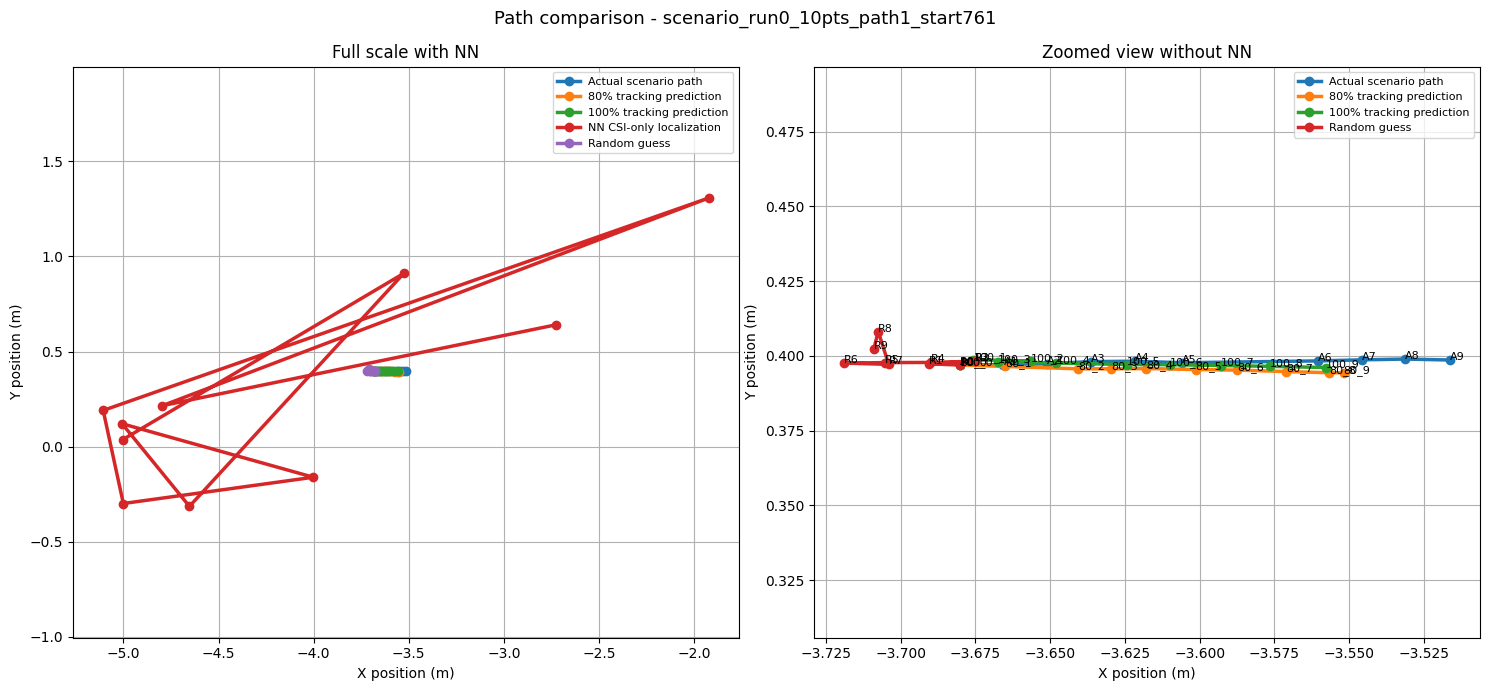

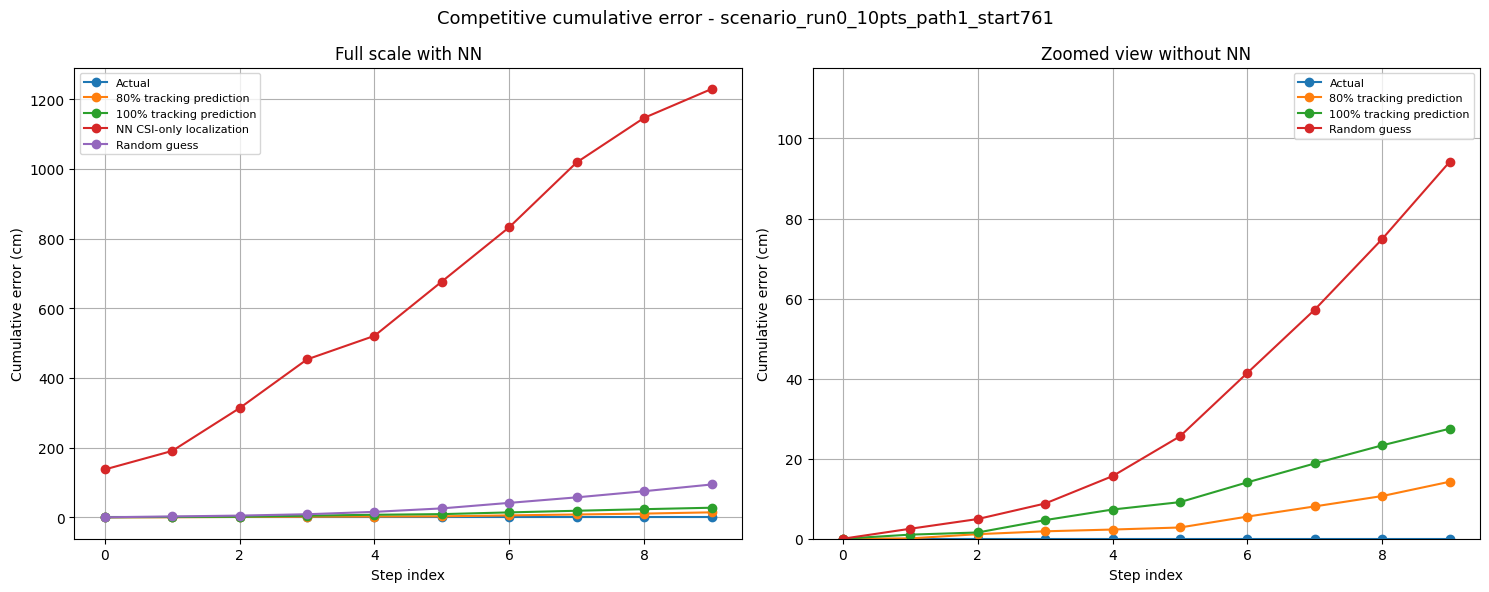

80% cumulative error cm: 14.238606
100% cumulative error cm: 27.488604
NN cumulative error cm: 1229.0435
Random cumulative error cm: 94.16873
80% - 100% difference cm: -13.249997
NN - 100% difference cm: 1201.5548
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path1_start761_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path1_start761_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path1_start761_competitive_cumulative_error.png
Running scenario_run0_10pts_path2_start3044
run_index=0, start_idx=3044, num_points=10


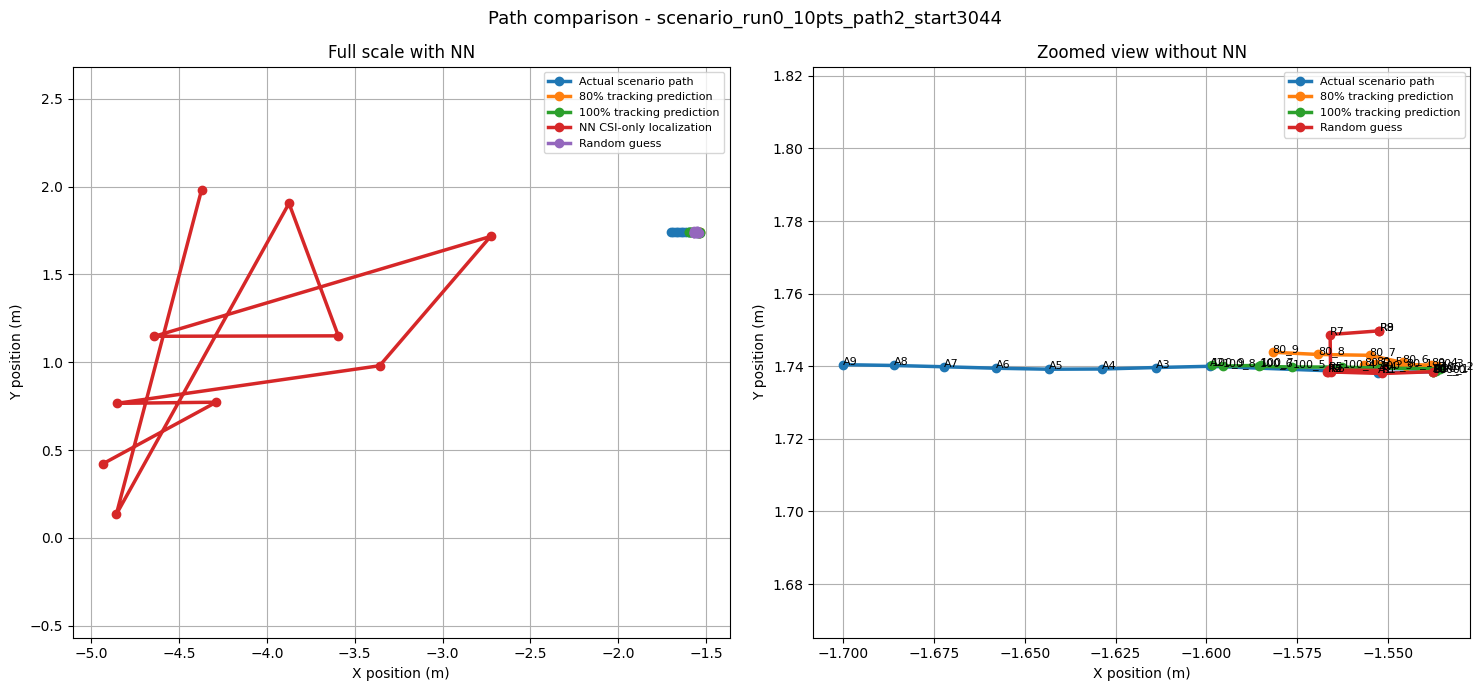

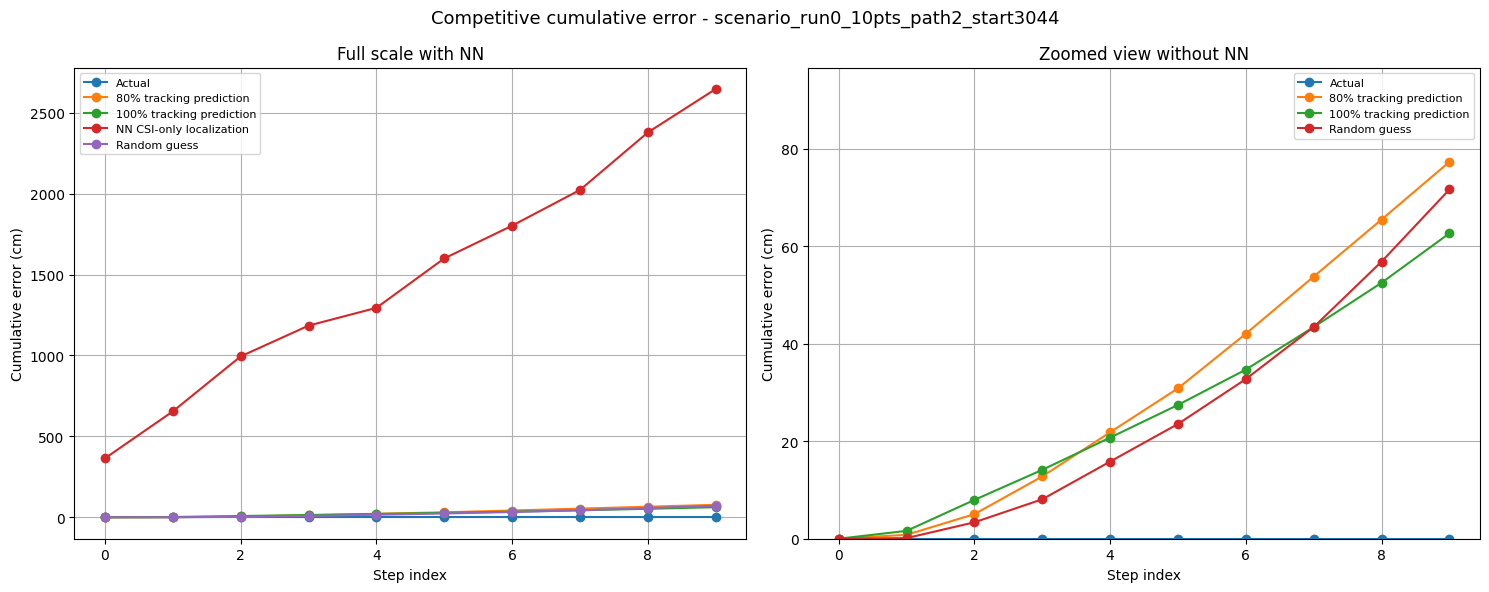

80% cumulative error cm: 77.302986
100% cumulative error cm: 62.64764
NN cumulative error cm: 2646.803
Random cumulative error cm: 71.63801
80% - 100% difference cm: 14.655346
NN - 100% difference cm: 2584.1553
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path2_start3044_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path2_start3044_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path2_start3044_competitive_cumulative_error.png
Running scenario_run0_10pts_path3_start5327
run_index=0, start_idx=5327, num_points=10


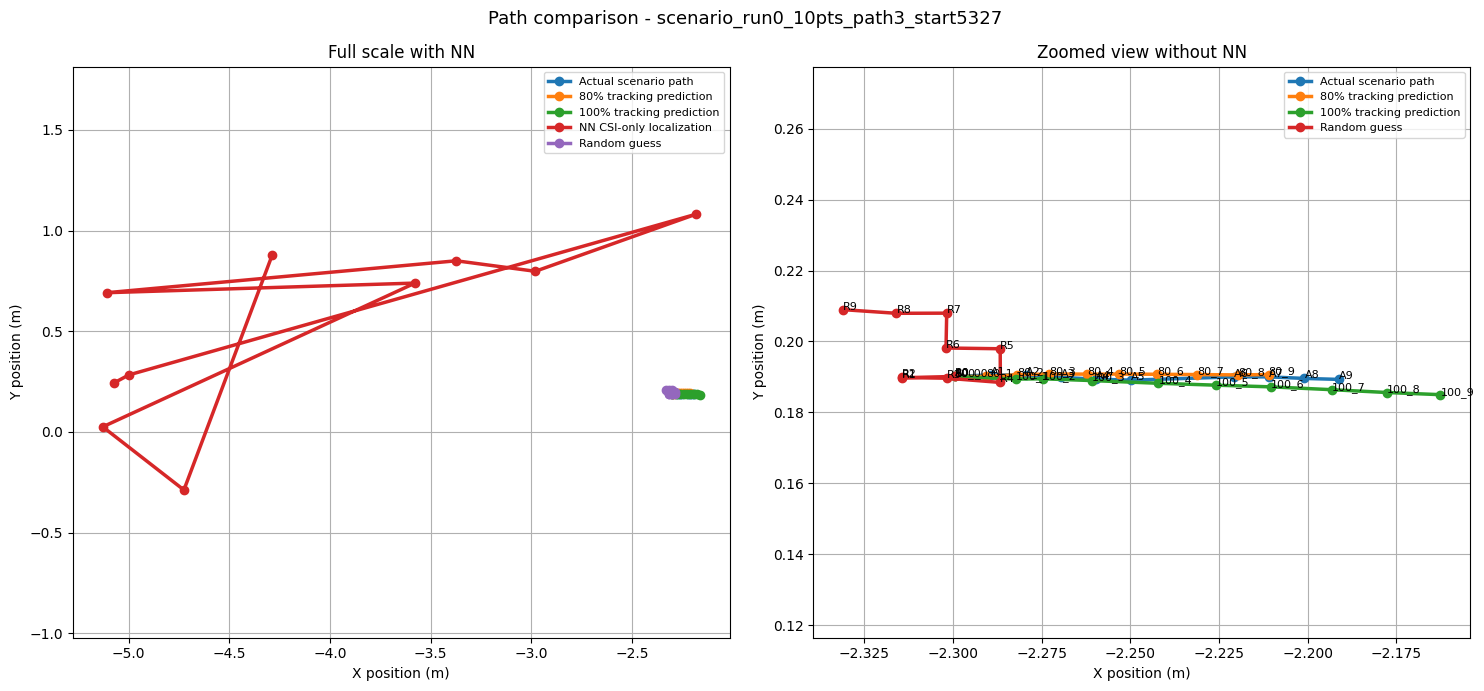

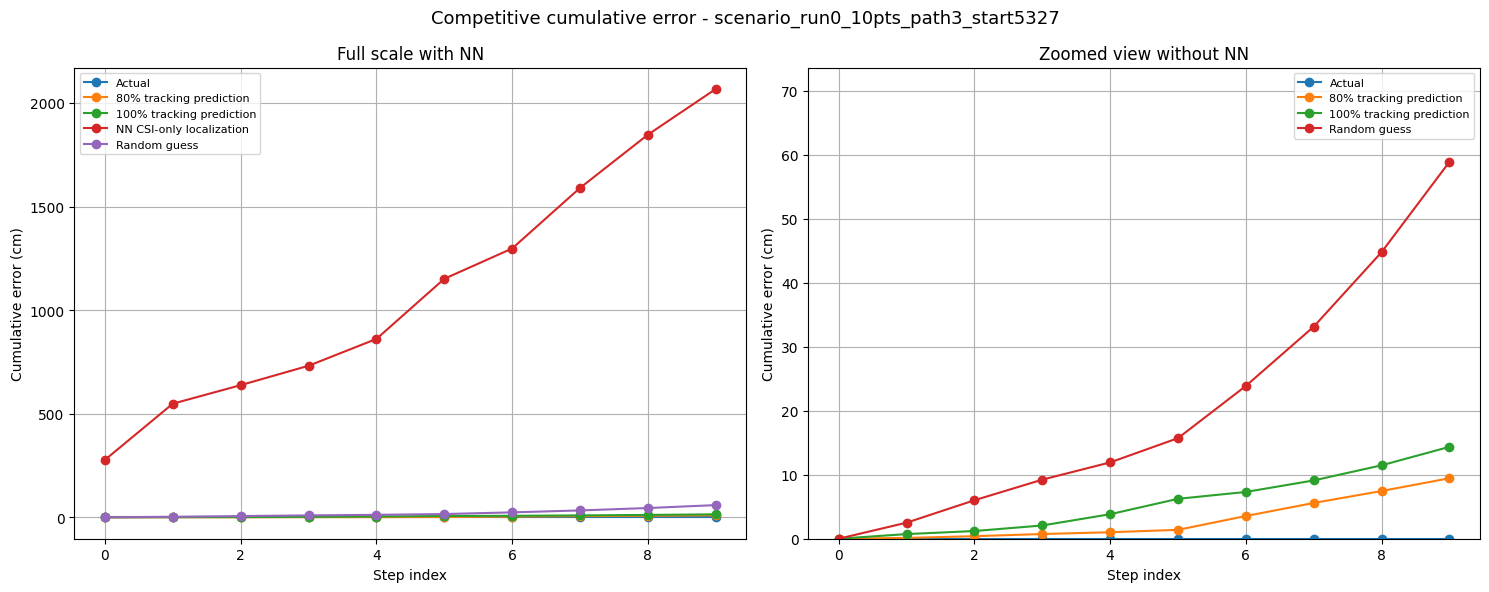

80% cumulative error cm: 9.453741
100% cumulative error cm: 14.361003
NN cumulative error cm: 2067.1958
Random cumulative error cm: 58.914547
80% - 100% difference cm: -4.907262
NN - 100% difference cm: 2052.8347
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path3_start5327_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path3_start5327_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path3_start5327_competitive_cumulative_error.png
Running scenario_run0_10pts_path4_start7611
run_index=0, start_idx=7611, num_points=10


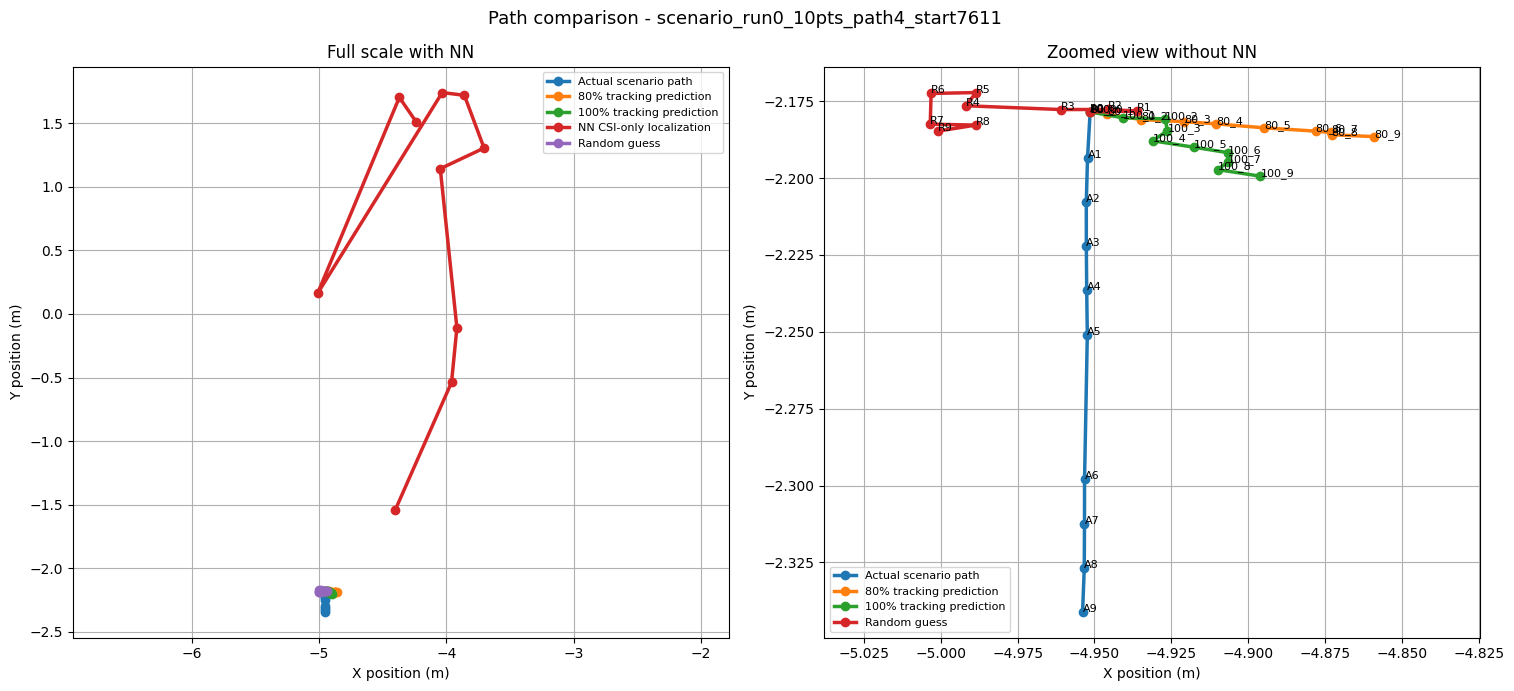

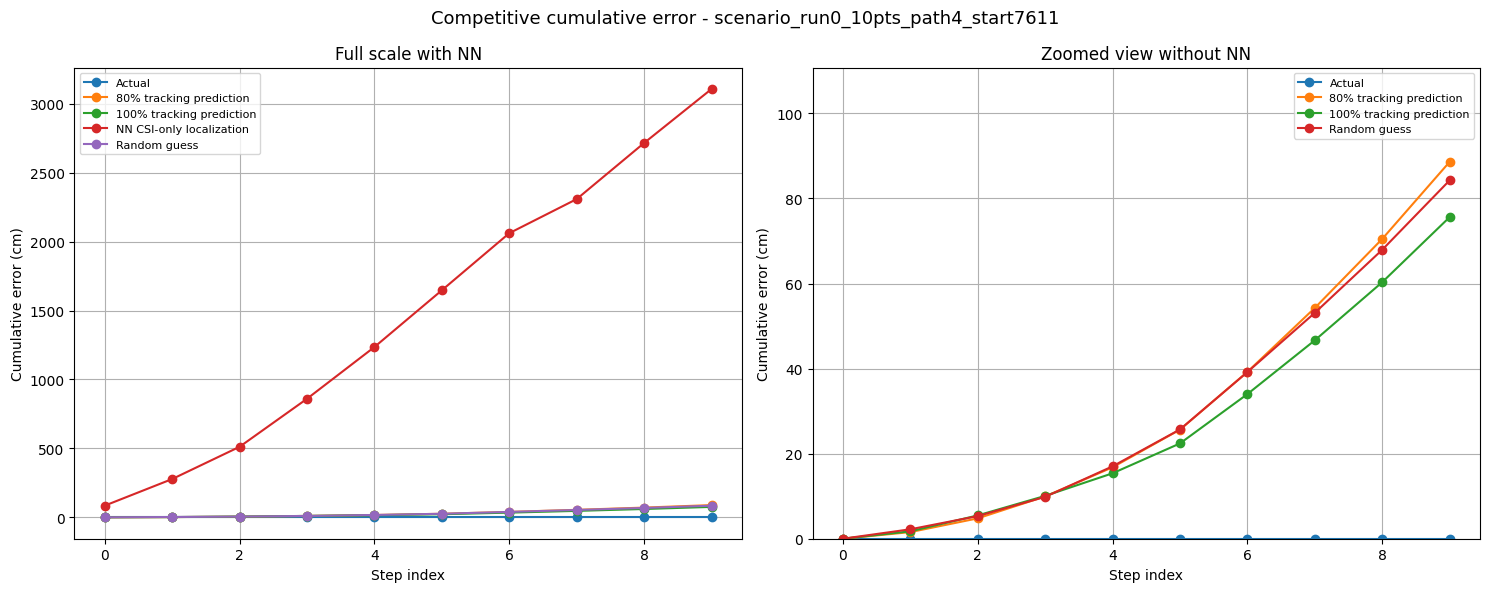

80% cumulative error cm: 88.61014
100% cumulative error cm: 75.61429
NN cumulative error cm: 3107.2676
Random cumulative error cm: 84.260826
80% - 100% difference cm: 12.99585
NN - 100% difference cm: 3031.6533
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path4_start7611_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path4_start7611_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path4_start7611_competitive_cumulative_error.png
Running scenario_run0_10pts_path5_start9894
run_index=0, start_idx=9894, num_points=10


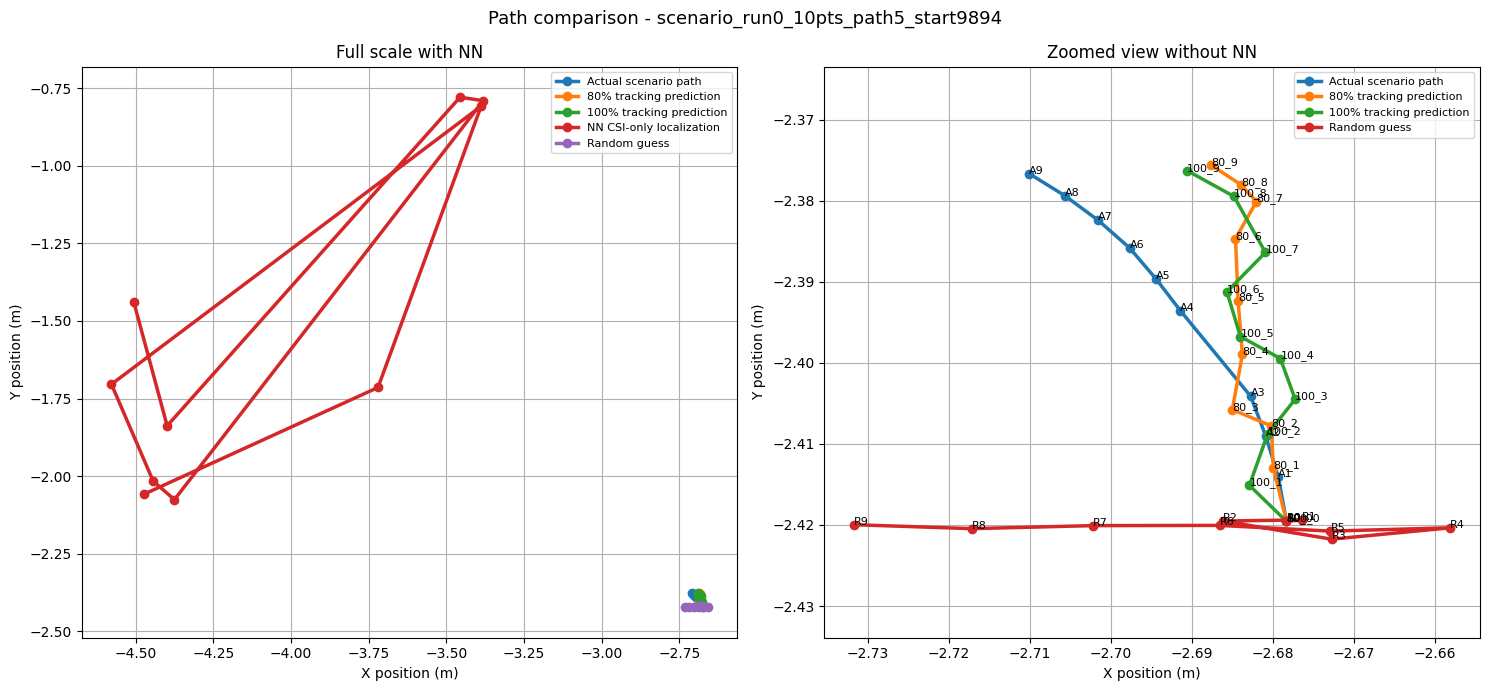

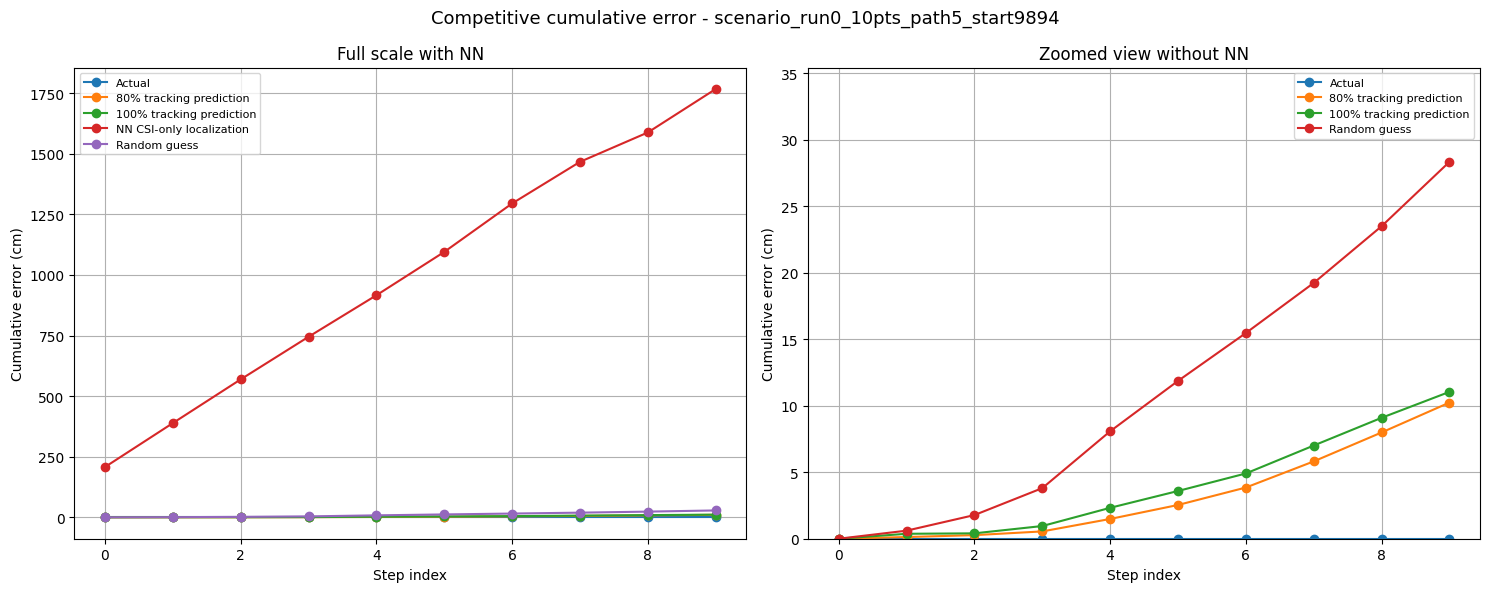

80% cumulative error cm: 10.233357
100% cumulative error cm: 11.037041
NN cumulative error cm: 1767.5598
Random cumulative error cm: 28.325457
80% - 100% difference cm: -0.8036833
NN - 100% difference cm: 1756.5228
Saved CSV: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path5_start9894_comparison_results.csv
Saved path plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path5_start9894_path_comparison.png
Saved cumulative error plot: /content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/scenario_run0_10pts_path5_start9894_competitive_cumulative_error.png
Multi-model scenario comparison completed.
Summary saved to:
/content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/multi_model_scenario_comparison_summary.csv


,scenario_name,run_source,run_index,start_idx,num_points,active_antennas_80,removed_antennas_80,actual_antenna_percentage_80,active_antennas_100,removed_antennas_100,...,pred80_better_than_random_cumulative,pred100_better_than_random_cumulative,nn_better_than_random_cumulative,pred80_vs_100_difference_cm,nn_vs_100_difference_cm,pred80_vs_nn_difference_cm,pred100_vs_nn_difference_cm,csv_path,path_plot_path,cumulative_error_plot_path
0,scenario_run0_4pts_path1_start761,test,0,761,4,26,6,81.25,32,0,...,True,True,False,-2.797962,448.466705,-451.264679,-448.466705,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
1,scenario_run0_6pts_path1_start761,test,0,761,6,26,6,81.25,32,0,...,True,True,False,-6.336525,667.404541,-673.741028,-667.404541,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
2,scenario_run0_8pts_path1_start761,test,0,761,8,26,6,81.25,32,0,...,True,True,False,-10.731009,999.667358,-1010.398376,-999.667358,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
3,scenario_run0_10pts_path1_start761,test,0,761,10,26,6,81.25,32,0,...,True,True,False,-13.249997,1201.554810,-1214.804810,-1201.554810,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
4,scenario_run0_8pts_path2_start3044,test,0,3044,8,26,6,81.25,32,0,...,True,True,False,10.350735,1979.576660,-1969.225952,-1979.576660,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
5,scenario_run0_10pts_path2_start3044,test,0,3044,10,26,6,81.25,32,0,...,False,True,False,14.655346,2584.155273,-2569.500000,-2584.155273,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
6,scenario_run0_4pts_path2_start3045,test,0,3045,4,26,6,81.25,32,0,...,True,True,False,4.341969,915.573975,-911.232056,-915.573975,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
7,scenario_run0_6pts_path2_start3045,test,0,3045,6,26,6,81.25,32,0,...,True,True,False,12.220280,1412.583618,-1400.363403,-1412.583618,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
8,scenario_run0_10pts_path3_start5327,test,0,5327,10,26,6,81.25,32,0,...,True,True,False,-4.907262,2052.834717,-2057.741943,-2052.834717,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
9,scenario_run0_8pts_path3_start5328,test,0,5328,8,26,6,81.25,32,0,...,True,True,False,0.322219,1562.963989,-1562.641724,-1562.963989,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...



Compact summary saved to:
/content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots/multi_model_scenario_comparison_compact_summary.csv


,scenario_name,run_index,start_idx,num_points,pred80_cumulative_error_cm,pred100_cumulative_error_cm,nn_cumulative_error_cm,random_cumulative_error_cm,pred80_vs_100_difference_cm,nn_vs_100_difference_cm,pred80_vs_nn_difference_cm,pred100_vs_nn_difference_cm,pred80_better_than_random_cumulative,pred100_better_than_random_cumulative,nn_better_than_random_cumulative
0,scenario_run0_4pts_path1_start761,0,761,4,1.853212,4.651174,453.117889,8.701699,-2.797962,448.466705,-451.264679,-448.466705,True,True,False
1,scenario_run0_6pts_path1_start761,0,761,6,2.804112,9.140636,676.545166,18.082529,-6.336525,667.404541,-673.741028,-667.404541,True,True,False
2,scenario_run0_8pts_path1_start761,0,761,8,8.077164,18.808172,1018.475525,20.291815,-10.731009,999.667358,-1010.398376,-999.667358,True,True,False
3,scenario_run0_10pts_path1_start761,0,761,10,14.238606,27.488604,1229.043457,94.168732,-13.249997,1201.554810,-1214.804810,-1201.554810,True,True,False
4,scenario_run0_8pts_path2_start3044,0,3044,8,53.775501,43.424767,2023.001465,76.071533,10.350735,1979.576660,-1969.225952,-1979.576660,True,True,False
5,scenario_run0_10pts_path2_start3044,0,3044,10,77.302986,62.647640,2646.802979,71.638008,14.655346,2584.155273,-2569.500000,-2584.155273,False,True,False
6,scenario_run0_4pts_path2_start3045,0,3045,4,18.712980,14.371011,929.945007,25.295883,4.341969,915.573975,-911.232056,-915.573975,True,True,False
7,scenario_run0_6pts_path2_start3045,0,3045,6,37.393852,25.173573,1437.757202,59.146309,12.220280,1412.583618,-1400.363403,-1412.583618,True,True,False
8,scenario_run0_10pts_path3_start5327,0,5327,10,9.453741,14.361003,2067.195801,58.914547,-4.907262,2052.834717,-2057.741943,-2052.834717,True,True,False
9,scenario_run0_8pts_path3_start5328,0,5328,8,6.641189,6.318970,1569.282959,33.724674,0.322219,1562.963989,-1562.641724,-1562.963989,True,True,False


In [36]:
# ============================================================
# MULTI-SCENARIO TRAJECTORY ANALYSIS
# 80% tracking model vs 100% tracking model vs simple NN localization
#
# Actual path vs 80% prediction vs 100% prediction vs NN prediction vs random guess
# Improved visualization:
#   - Full scale with NN
#   - Zoomed view without NN
# Stepwise error plot removed
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

RUN_SOURCE = "test"

RANDOM_SEED = 42

BASE_EXPERIMENT_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2"

MODEL_PATH = None
NORM_PATH = None

TRACKING_100_MODEL_PATH = "/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models/best_residual_attention_model_top_100_percent.keras"

TRACKING_100_NORM_PATH = "/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/normalization_residual_attention_top_100_percent.npz"

# IMPORTANT:
# Your NN model is visible in Colab Files panel under /content.
NN_MODEL_PATH = "/content/localization_model.keras"

SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/scenario_analysis_compare_80_100_nn_random_better_plots"

RUN_INDICES_TO_USE = [0, 1, 2]

SCENARIO_LENGTHS = [
    4,
    6,
    8,
    10
]

SCENARIOS_PER_LENGTH = 5

START_FRACTIONS = [
    0.05,
    0.20,
    0.35,
    0.50,
    0.65,
    0.80,
    0.95
]

USE_MANUAL_SCENARIOS = False

MANUAL_SCENARIOS = [
    {"name": "manual_short_path", "run_index": 0, "start_idx": 20, "num_points": 4},
    {"name": "manual_medium_path", "run_index": 0, "start_idx": 80, "num_points": 6},
    {"name": "manual_long_path", "run_index": 1, "start_idx": 50, "num_points": 8},
    {"name": "manual_very_long_path", "run_index": 2, "start_idx": 100, "num_points": 10},
]

SHOW_PLOTS = True

os.makedirs(SAVE_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


# ============================================================
# REQUIRED OBJECTS CHECK
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(f"{obj} is not defined.")

print("Required run objects found.")


# ============================================================
# CUSTOM OBJECTS
# ============================================================

@tf.keras.utils.register_keras_serializable()
class AntennaEnergyLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return tf.reduce_mean(
            tf.abs(inputs),
            axis=[2, 3]
        )

    def get_config(self):
        return super().get_config()


# ============================================================
# AUTO FIND FINAL 80% MODEL AND NORMALIZATION
# ============================================================

def auto_find_final_model_and_norm(base_dir):
    keras_files = glob.glob(
        os.path.join(base_dir, "**", "*.keras"),
        recursive=True
    )

    npz_files = glob.glob(
        os.path.join(base_dir, "**", "*.npz"),
        recursive=True
    )

    final_model_candidates = [
        p for p in keras_files
        if "FINAL_SELECTED" in os.path.basename(p)
    ]

    if len(final_model_candidates) == 0:
        final_model_candidates = [
            p for p in keras_files
            if "80" in os.path.basename(p) or "pct_80" in os.path.basename(p)
        ]

    final_norm_candidates = [
        p for p in npz_files
        if "FINAL_SELECTED" in os.path.basename(p)
    ]

    if len(final_norm_candidates) == 0:
        final_norm_candidates = [
            p for p in npz_files
            if "80" in os.path.basename(p) or "pct_80" in os.path.basename(p)
        ]

    final_model_candidates = sorted(
        final_model_candidates,
        key=lambda x: os.path.getmtime(x),
        reverse=True
    )

    final_norm_candidates = sorted(
        final_norm_candidates,
        key=lambda x: os.path.getmtime(x),
        reverse=True
    )

    if len(final_model_candidates) == 0:
        print("No model candidates found.")
        print("Available keras files:")
        for p in keras_files:
            print(p)
        raise FileNotFoundError("Could not automatically find final 80% model.")

    if len(final_norm_candidates) == 0:
        print("No normalization candidates found.")
        print("Available npz files:")
        for p in npz_files:
            print(p)
        raise FileNotFoundError("Could not automatically find final 80% normalization file.")

    return final_model_candidates[0], final_norm_candidates[0]


if MODEL_PATH is None or NORM_PATH is None:
    found_model_path, found_norm_path = auto_find_final_model_and_norm(
        BASE_EXPERIMENT_DIR
    )

    if MODEL_PATH is None:
        MODEL_PATH = found_model_path

    if NORM_PATH is None:
        NORM_PATH = found_norm_path


print("Selected 80% model path:")
print(MODEL_PATH)

print("\nSelected 80% normalization path:")
print(NORM_PATH)


# ============================================================
# LOAD 80% TRACKING MODEL AND NORMALIZATION
# ============================================================

model_80 = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "AntennaEnergyLayer": AntennaEnergyLayer
    },
    compile=False
)

norm_data_80 = np.load(
    NORM_PATH,
    allow_pickle=True
)

csi_mean_80 = norm_data_80["csi_mean"]
csi_std_80 = norm_data_80["csi_std"]
pos_mean_80 = norm_data_80["pos_mean"]
pos_std_80 = norm_data_80["pos_std"]

if "antenna_mask" in norm_data_80:
    antenna_mask_80 = norm_data_80["antenna_mask"].astype(np.float32)
else:
    antenna_mask_80 = np.ones(32, dtype=np.float32)
    print("Warning: antenna_mask not found in 80% normalization file. Using full mask.")

active_antennas_80 = int(np.sum(antenna_mask_80))
removed_antennas_80 = int(32 - active_antennas_80)
actual_percentage_80 = 100.0 * active_antennas_80 / 32.0

print("\n80% tracking model loaded.")
print("80% active antennas:", active_antennas_80)
print("80% removed antennas:", removed_antennas_80)
print("80% actual antenna percentage:", actual_percentage_80)


# ============================================================
# LOAD 100% TRACKING MODEL AND NORMALIZATION
# ============================================================

if not os.path.exists(TRACKING_100_MODEL_PATH):
    raise FileNotFoundError(
        f"100% tracking model not found:\n{TRACKING_100_MODEL_PATH}"
    )

if not os.path.exists(TRACKING_100_NORM_PATH):
    raise FileNotFoundError(
        f"100% tracking normalization not found:\n{TRACKING_100_NORM_PATH}"
    )

model_100 = tf.keras.models.load_model(
    TRACKING_100_MODEL_PATH,
    custom_objects={
        "AntennaEnergyLayer": AntennaEnergyLayer
    },
    compile=False
)

norm_data_100 = np.load(
    TRACKING_100_NORM_PATH,
    allow_pickle=True
)

csi_mean_100 = norm_data_100["csi_mean"]
csi_std_100 = norm_data_100["csi_std"]
pos_mean_100 = norm_data_100["pos_mean"]
pos_std_100 = norm_data_100["pos_std"]

if "antenna_mask" in norm_data_100:
    antenna_mask_100 = norm_data_100["antenna_mask"].astype(np.float32)
else:
    antenna_mask_100 = np.ones(32, dtype=np.float32)

active_antennas_100 = int(np.sum(antenna_mask_100))
removed_antennas_100 = int(32 - active_antennas_100)
actual_percentage_100 = 100.0 * active_antennas_100 / 32.0

print("\n100% tracking model loaded.")
print("100% active antennas:", active_antennas_100)
print("100% removed antennas:", removed_antennas_100)
print("100% actual antenna percentage:", actual_percentage_100)


# ============================================================
# LOAD SIMPLE NN CSI-ONLY LOCALIZATION MODEL
# ============================================================

if not os.path.exists(NN_MODEL_PATH):
    print("Current working directory:", os.getcwd())
    print("Files in /content:")
    print(os.listdir("/content"))

    raise FileNotFoundError(
        f"Simple NN localization model not found:\n{NN_MODEL_PATH}\n"
        "Check that localization_model.keras exists in /content."
    )

nn_model = tf.keras.models.load_model(
    NN_MODEL_PATH,
    compile=False
)

print("\nSimple NN CSI-only localization model loaded.")
print("NN model path:", NN_MODEL_PATH)


# ============================================================
# SELECT RUN SOURCE
# ============================================================

if RUN_SOURCE == "train":
    runs_to_analyze = train_runs
elif RUN_SOURCE == "val":
    runs_to_analyze = val_runs
elif RUN_SOURCE == "test":
    runs_to_analyze = test_runs
else:
    raise ValueError("RUN_SOURCE must be train, val, or test.")

print("\nRun source:", RUN_SOURCE)
print("Number of runs:", len(runs_to_analyze))


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_csi(x, mean, std):
    return ((x - mean) / std).astype(np.float32)


def normalize_pos(x, mean, std):
    return ((x - mean) / std).astype(np.float32)


def denormalize_pos(x, mean, std):
    return (x * std + mean).astype(np.float32)


def build_step_pool(runs):
    all_steps = []

    for run in runs:
        pos = run["pos"].astype(np.float32)

        if len(pos) >= 2:
            steps = pos[1:] - pos[:-1]
            all_steps.append(steps)

    if len(all_steps) == 0:
        raise RuntimeError("No valid step vectors found.")

    return np.concatenate(all_steps, axis=0).astype(np.float32)


def generate_auto_scenarios(
    runs,
    run_indices,
    scenario_lengths,
    start_fractions,
    scenarios_per_length
):
    scenarios = []

    for run_idx in run_indices:
        if run_idx >= len(runs):
            print(f"Skipping run_index={run_idx} because it does not exist.")
            continue

        run = runs[run_idx]
        run_length = len(run["pos"])

        selected_fractions = start_fractions[:scenarios_per_length]

        for num_points in scenario_lengths:
            max_start_idx = run_length - num_points - 1

            if max_start_idx <= 0:
                print(
                    f"Skipping run={run_idx}, num_points={num_points}, "
                    f"because run is too short."
                )
                continue

            for scenario_idx, fraction in enumerate(selected_fractions):
                start_idx = int(max_start_idx * fraction)

                scenario_name = (
                    f"scenario_run{run_idx}_"
                    f"{num_points}pts_"
                    f"path{scenario_idx + 1}_"
                    f"start{start_idx}"
                )

                scenarios.append({
                    "name": scenario_name,
                    "run_index": run_idx,
                    "start_idx": start_idx,
                    "num_points": num_points
                })

    return scenarios


def extract_scenario(run, start_idx, num_points):
    pos = run["pos"].astype(np.float32)
    csi = run["X_csi"].astype(np.float32)

    end_idx = start_idx + num_points

    if end_idx > len(pos):
        raise ValueError(
            f"Scenario exceeds run length. start_idx={start_idx}, "
            f"num_points={num_points}, run_length={len(pos)}"
        )

    actual_positions = pos[start_idx:end_idx]

    # For tracking models:
    # position(t) + CSI(t+1) -> position(t+1)
    csi_next = csi[start_idx + 1:end_idx]

    # For simple NN localization:
    # CSI(t) -> position(t)
    csi_current = csi[start_idx:end_idx]

    if "time" in run:
        timestamps = run["time"][start_idx:end_idx]
    elif "timestamp" in run:
        timestamps = run["timestamp"][start_idx:end_idx]
    else:
        timestamps = np.arange(num_points)

    return actual_positions, csi_next, csi_current, timestamps


def predict_scenario_closed_loop(
    model,
    actual_positions,
    csi_next,
    antenna_mask,
    csi_mean,
    csi_std,
    pos_mean,
    pos_std
):
    num_points = actual_positions.shape[0]

    pred_positions = [
        actual_positions[0].copy()
    ]

    for step_idx in range(num_points - 1):
        current_position = pred_positions[-1]
        current_csi_next = csi_next[step_idx]

        pos_input = normalize_pos(
            current_position[None, :],
            pos_mean,
            pos_std
        )

        csi_input = normalize_csi(
            current_csi_next[None, ...],
            csi_mean,
            csi_std
        )

        mask_input = antenna_mask[None, :].astype(np.float32)

        pred_next_norm = model.predict(
            {
                "position_t_input": pos_input,
                "csi_tplus1_input": csi_input,
                "antenna_mask_input": mask_input,
            },
            verbose=0
        )

        pred_next = denormalize_pos(
            pred_next_norm,
            pos_mean,
            pos_std
        )[0]

        pred_positions.append(
            pred_next.astype(np.float32)
        )

    return np.array(pred_positions, dtype=np.float32)


def predict_scenario_nn_localization(
    nn_model,
    csi_current
):
    nn_positions = nn_model.predict(
        csi_current.astype(np.float32),
        verbose=0
    )

    return nn_positions.astype(np.float32)


def generate_random_walk_baseline(
    start_position,
    num_points,
    step_pool,
    seed=42
):
    rng = np.random.default_rng(seed)

    random_positions = [
        start_position.copy()
    ]

    for _ in range(num_points - 1):
        random_step = step_pool[
            rng.integers(0, len(step_pool))
        ]

        next_pos = random_positions[-1] + random_step

        random_positions.append(
            next_pos.astype(np.float32)
        )

    return np.array(random_positions, dtype=np.float32)


def build_scenario_dataframe(
    actual_positions,
    pred80_positions,
    pred100_positions,
    nn_positions,
    random_positions,
    timestamps
):
    num_points = len(actual_positions)

    actual_error = np.zeros(num_points, dtype=np.float32)

    pred80_error = np.sqrt(
        np.sum(
            (pred80_positions - actual_positions) ** 2,
            axis=1
        )
    )

    pred100_error = np.sqrt(
        np.sum(
            (pred100_positions - actual_positions) ** 2,
            axis=1
        )
    )

    nn_error = np.sqrt(
        np.sum(
            (nn_positions - actual_positions) ** 2,
            axis=1
        )
    )

    random_error = np.sqrt(
        np.sum(
            (random_positions - actual_positions) ** 2,
            axis=1
        )
    )

    actual_cum_error = np.cumsum(actual_error)
    pred80_cum_error = np.cumsum(pred80_error)
    pred100_cum_error = np.cumsum(pred100_error)
    nn_cum_error = np.cumsum(nn_error)
    random_cum_error = np.cumsum(random_error)

    df = pd.DataFrame({
        "step_index": np.arange(num_points),
        "timestamp": timestamps,

        "actual_x": actual_positions[:, 0],
        "actual_y": actual_positions[:, 1],

        "pred80_x": pred80_positions[:, 0],
        "pred80_y": pred80_positions[:, 1],

        "pred100_x": pred100_positions[:, 0],
        "pred100_y": pred100_positions[:, 1],

        "nn_x": nn_positions[:, 0],
        "nn_y": nn_positions[:, 1],

        "random_x": random_positions[:, 0],
        "random_y": random_positions[:, 1],

        "actual_cumulative_error_cm": actual_cum_error * 100.0,
        "pred80_cumulative_error_cm": pred80_cum_error * 100.0,
        "pred100_cumulative_error_cm": pred100_cum_error * 100.0,
        "nn_cumulative_error_cm": nn_cum_error * 100.0,
        "random_cumulative_error_cm": random_cum_error * 100.0,
    })

    return df


# ============================================================
# PLOTTING FUNCTIONS
# ============================================================

def plot_path_comparison(
    df,
    scenario_name,
    save_path,
    show_plot=SHOW_PLOTS
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 7)
    )

    # Full scale with NN
    ax = axes[0]

    ax.plot(df["actual_x"], df["actual_y"], marker="o", linewidth=2.5, markersize=6, label="Actual scenario path")
    ax.plot(df["pred80_x"], df["pred80_y"], marker="o", linewidth=2.5, markersize=6, label="80% tracking prediction")
    ax.plot(df["pred100_x"], df["pred100_y"], marker="o", linewidth=2.5, markersize=6, label="100% tracking prediction")
    ax.plot(df["nn_x"], df["nn_y"], marker="o", linewidth=2.5, markersize=6, label="NN CSI-only localization")
    ax.plot(df["random_x"], df["random_y"], marker="o", linewidth=2.5, markersize=6, label="Random guess")

    ax.set_xlabel("X position (m)")
    ax.set_ylabel("Y position (m)")
    ax.set_title("Full scale with NN")
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.axis("equal")

    # Zoomed view without NN
    ax = axes[1]

    ax.plot(df["actual_x"], df["actual_y"], marker="o", linewidth=2.5, markersize=6, label="Actual scenario path")
    ax.plot(df["pred80_x"], df["pred80_y"], marker="o", linewidth=2.5, markersize=6, label="80% tracking prediction")
    ax.plot(df["pred100_x"], df["pred100_y"], marker="o", linewidth=2.5, markersize=6, label="100% tracking prediction")
    ax.plot(df["random_x"], df["random_y"], marker="o", linewidth=2.5, markersize=6, label="Random guess")

    for i in range(len(df)):
        ax.text(df["actual_x"].iloc[i], df["actual_y"].iloc[i], f"A{i}", fontsize=8)
        ax.text(df["pred80_x"].iloc[i], df["pred80_y"].iloc[i], f"80_{i}", fontsize=8)
        ax.text(df["pred100_x"].iloc[i], df["pred100_y"].iloc[i], f"100_{i}", fontsize=8)
        ax.text(df["random_x"].iloc[i], df["random_y"].iloc[i], f"R{i}", fontsize=8)

    ax.set_xlabel("X position (m)")
    ax.set_ylabel("Y position (m)")
    ax.set_title("Zoomed view without NN")
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.axis("equal")

    fig.suptitle(
        f"Path comparison - {scenario_name}",
        fontsize=13
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)

    if show_plot:
        plt.show()

    plt.close()


def plot_competitive_cumulative_error(
    df,
    scenario_name,
    save_path,
    show_plot=SHOW_PLOTS
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6)
    )

    # Full scale with NN
    ax = axes[0]

    ax.plot(df["step_index"], df["actual_cumulative_error_cm"], marker="o", label="Actual")
    ax.plot(df["step_index"], df["pred80_cumulative_error_cm"], marker="o", label="80% tracking prediction")
    ax.plot(df["step_index"], df["pred100_cumulative_error_cm"], marker="o", label="100% tracking prediction")
    ax.plot(df["step_index"], df["nn_cumulative_error_cm"], marker="o", label="NN CSI-only localization")
    ax.plot(df["step_index"], df["random_cumulative_error_cm"], marker="o", label="Random guess")

    ax.set_xlabel("Step index")
    ax.set_ylabel("Cumulative error (cm)")
    ax.set_title("Full scale with NN")
    ax.legend(fontsize=8)
    ax.grid(True)

    # Zoomed view without NN
    ax = axes[1]

    ax.plot(df["step_index"], df["actual_cumulative_error_cm"], marker="o", label="Actual")
    ax.plot(df["step_index"], df["pred80_cumulative_error_cm"], marker="o", label="80% tracking prediction")
    ax.plot(df["step_index"], df["pred100_cumulative_error_cm"], marker="o", label="100% tracking prediction")
    ax.plot(df["step_index"], df["random_cumulative_error_cm"], marker="o", label="Random guess")

    zoom_max = max(
        df["pred80_cumulative_error_cm"].max(),
        df["pred100_cumulative_error_cm"].max(),
        df["random_cumulative_error_cm"].max(),
        1.0
    )

    ax.set_ylim(0, zoom_max * 1.25)

    ax.set_xlabel("Step index")
    ax.set_ylabel("Cumulative error (cm)")
    ax.set_title("Zoomed view without NN")
    ax.legend(fontsize=8)
    ax.grid(True)

    fig.suptitle(
        f"Competitive cumulative error - {scenario_name}",
        fontsize=13
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)

    if show_plot:
        plt.show()

    plt.close()


# ============================================================
# BUILD SCENARIOS
# ============================================================

if USE_MANUAL_SCENARIOS:
    SCENARIOS = MANUAL_SCENARIOS
else:
    SCENARIOS = generate_auto_scenarios(
        runs=runs_to_analyze,
        run_indices=RUN_INDICES_TO_USE,
        scenario_lengths=SCENARIO_LENGTHS,
        start_fractions=START_FRACTIONS,
        scenarios_per_length=SCENARIOS_PER_LENGTH
    )

print("\nGenerated scenarios:")
for scenario in SCENARIOS:
    print(scenario)

print("\nNumber of scenarios:", len(SCENARIOS))


# ============================================================
# RANDOM BASELINE STEP POOL
# ============================================================

step_pool = build_step_pool(train_runs)

print("\nRandom step pool shape:", step_pool.shape)


# ============================================================
# RUN SCENARIO ANALYSIS
# ============================================================

scenario_summary_records = []

for scenario in SCENARIOS:
    scenario_name = scenario["name"]
    run_index = scenario["run_index"]
    start_idx = scenario["start_idx"]
    num_points = scenario["num_points"]

    print("=" * 100)
    print(f"Running {scenario_name}")
    print(f"run_index={run_index}, start_idx={start_idx}, num_points={num_points}")

    run = runs_to_analyze[run_index]

    actual_positions, csi_next, csi_current, timestamps = extract_scenario(
        run=run,
        start_idx=start_idx,
        num_points=num_points
    )

    pred80_positions = predict_scenario_closed_loop(
        model=model_80,
        actual_positions=actual_positions,
        csi_next=csi_next,
        antenna_mask=antenna_mask_80,
        csi_mean=csi_mean_80,
        csi_std=csi_std_80,
        pos_mean=pos_mean_80,
        pos_std=pos_std_80
    )

    pred100_positions = predict_scenario_closed_loop(
        model=model_100,
        actual_positions=actual_positions,
        csi_next=csi_next,
        antenna_mask=antenna_mask_100,
        csi_mean=csi_mean_100,
        csi_std=csi_std_100,
        pos_mean=pos_mean_100,
        pos_std=pos_std_100
    )

    nn_positions = predict_scenario_nn_localization(
        nn_model=nn_model,
        csi_current=csi_current
    )

    random_positions = generate_random_walk_baseline(
        start_position=actual_positions[0],
        num_points=num_points,
        step_pool=step_pool,
        seed=RANDOM_SEED + run_index + start_idx + num_points
    )

    scenario_df = build_scenario_dataframe(
        actual_positions=actual_positions,
        pred80_positions=pred80_positions,
        pred100_positions=pred100_positions,
        nn_positions=nn_positions,
        random_positions=random_positions,
        timestamps=timestamps
    )

    csv_path = os.path.join(
        SAVE_DIR,
        f"{scenario_name}_comparison_results.csv"
    )

    path_plot_path = os.path.join(
        SAVE_DIR,
        f"{scenario_name}_path_comparison.png"
    )

    cumulative_error_plot_path = os.path.join(
        SAVE_DIR,
        f"{scenario_name}_competitive_cumulative_error.png"
    )

    scenario_df.to_csv(
        csv_path,
        index=False
    )

    plot_path_comparison(
        df=scenario_df,
        scenario_name=scenario_name,
        save_path=path_plot_path,
        show_plot=SHOW_PLOTS
    )

    plot_competitive_cumulative_error(
        df=scenario_df,
        scenario_name=scenario_name,
        save_path=cumulative_error_plot_path,
        show_plot=SHOW_PLOTS
    )

    pred80_cumulative_error_cm = scenario_df["pred80_cumulative_error_cm"].iloc[-1]
    pred100_cumulative_error_cm = scenario_df["pred100_cumulative_error_cm"].iloc[-1]
    nn_cumulative_error_cm = scenario_df["nn_cumulative_error_cm"].iloc[-1]
    random_cumulative_error_cm = scenario_df["random_cumulative_error_cm"].iloc[-1]

    pred80_better_than_random_cumulative = pred80_cumulative_error_cm < random_cumulative_error_cm
    pred100_better_than_random_cumulative = pred100_cumulative_error_cm < random_cumulative_error_cm
    nn_better_than_random_cumulative = nn_cumulative_error_cm < random_cumulative_error_cm

    pred80_vs_100_difference_cm = pred80_cumulative_error_cm - pred100_cumulative_error_cm
    nn_vs_100_difference_cm = nn_cumulative_error_cm - pred100_cumulative_error_cm

    pred80_vs_nn_difference_cm = pred80_cumulative_error_cm - nn_cumulative_error_cm
    pred100_vs_nn_difference_cm = pred100_cumulative_error_cm - nn_cumulative_error_cm

    scenario_summary_records.append({
        "scenario_name": scenario_name,
        "run_source": RUN_SOURCE,
        "run_index": run_index,
        "start_idx": start_idx,
        "num_points": num_points,

        "active_antennas_80": active_antennas_80,
        "removed_antennas_80": removed_antennas_80,
        "actual_antenna_percentage_80": actual_percentage_80,

        "active_antennas_100": active_antennas_100,
        "removed_antennas_100": removed_antennas_100,
        "actual_antenna_percentage_100": actual_percentage_100,

        "pred80_cumulative_error_cm": pred80_cumulative_error_cm,
        "pred100_cumulative_error_cm": pred100_cumulative_error_cm,
        "nn_cumulative_error_cm": nn_cumulative_error_cm,
        "random_cumulative_error_cm": random_cumulative_error_cm,

        "pred80_better_than_random_cumulative": pred80_better_than_random_cumulative,
        "pred100_better_than_random_cumulative": pred100_better_than_random_cumulative,
        "nn_better_than_random_cumulative": nn_better_than_random_cumulative,

        "pred80_vs_100_difference_cm": pred80_vs_100_difference_cm,
        "nn_vs_100_difference_cm": nn_vs_100_difference_cm,
        "pred80_vs_nn_difference_cm": pred80_vs_nn_difference_cm,
        "pred100_vs_nn_difference_cm": pred100_vs_nn_difference_cm,

        "csv_path": csv_path,
        "path_plot_path": path_plot_path,
        "cumulative_error_plot_path": cumulative_error_plot_path,
    })

    print("80% cumulative error cm:", pred80_cumulative_error_cm)
    print("100% cumulative error cm:", pred100_cumulative_error_cm)
    print("NN cumulative error cm:", nn_cumulative_error_cm)
    print("Random cumulative error cm:", random_cumulative_error_cm)
    print("80% - 100% difference cm:", pred80_vs_100_difference_cm)
    print("NN - 100% difference cm:", nn_vs_100_difference_cm)
    print("Saved CSV:", csv_path)
    print("Saved path plot:", path_plot_path)
    print("Saved cumulative error plot:", cumulative_error_plot_path)


# ============================================================
# FINAL SUMMARY
# ============================================================

summary_df = pd.DataFrame(
    scenario_summary_records
)

summary_df = summary_df.sort_values(
    [
        "run_index",
        "start_idx",
        "num_points"
    ]
).reset_index(drop=True)

summary_csv_path = os.path.join(
    SAVE_DIR,
    "multi_model_scenario_comparison_summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False
)

print("=" * 100)
print("Multi-model scenario comparison completed.")
print("Summary saved to:")
print(summary_csv_path)

display(summary_df)


# ============================================================
# COMPACT SUMMARY
# ============================================================

compact_columns = [
    "scenario_name",
    "run_index",
    "start_idx",
    "num_points",

    "pred80_cumulative_error_cm",
    "pred100_cumulative_error_cm",
    "nn_cumulative_error_cm",
    "random_cumulative_error_cm",

    "pred80_vs_100_difference_cm",
    "nn_vs_100_difference_cm",
    "pred80_vs_nn_difference_cm",
    "pred100_vs_nn_difference_cm",

    "pred80_better_than_random_cumulative",
    "pred100_better_than_random_cumulative",
    "nn_better_than_random_cumulative",
]

compact_summary_df = summary_df[compact_columns].copy()

compact_summary_csv_path = os.path.join(
    SAVE_DIR,
    "multi_model_scenario_comparison_compact_summary.csv"
)

compact_summary_df.to_csv(
    compact_summary_csv_path,
    index=False
)

print("\nCompact summary saved to:")
print(compact_summary_csv_path)

display(compact_summary_df)

# **LOCAL IG MODEL**

In [ ]:
# ============================================================
# LOCAL IG-BASED ADAPTIVE ANTENNA TRACKING MODEL
# Corrected version with:
#   - 5% antenna condition
#   - 0% condition = no antennas / no CSI information
#
# Input:
#   position(t)                  shape = (2,)
#   CSI(t+1)                     shape = (32, 32, 2)
#   local important antenna mask shape = (32,)
#
# Output:
#   position(t+1)                shape = (2,)
#
# Important corrections:
#   1) Local importance is taken at time t:
#          local importance(t) = importance_ig_source[:-1]
#
#   2) CSI is NOT masked in the generator.
#      CSI is masked only inside the model.
#
#   3) 5% is supported:
#          active antennas = 2
#
#   4) 0% is supported:
#          active antennas = 0
#          antenna mask = all zeros
#          no CSI information is used
#
# No global antenna ranking is used.
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/local_ig_adaptive_tracking_model_importance_t_with_5_and_0_percent"

os.makedirs(SAVE_DIR, exist_ok=True)

IMPORTANCE_KEY = "importance_ig_source"

NUM_ANTENNAS = 32

RANDOM_SEED = 42

BATCH_SIZE = 64
EPOCHS = 40
PATIENCE = 8

# During training, we include 5% too.
# 0% is not included in training because it is mainly a diagnostic no-CSI condition.
TRAIN_LOCAL_PERCENTAGES = [
    100,
    90,
    80,
    70,
    60,
    50,
    40,
    30,
    20,
    10,
    5
]

# During evaluation, we include both 5% and 0%.
# 0% means no active antennas and no CSI information.
EVAL_LOCAL_PERCENTAGES = [
    100,
    90,
    80,
    70,
    60,
    50,
    40,
    30,
    20,
    10,
    5,
    0
]

VALIDATION_MONITOR_PERCENTAGE = 80

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


# ============================================================
# REQUIRED OBJECTS CHECK
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(f"{obj} is not defined.")

print("Required run objects found.")


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_csi(x, mean, std):
    return ((x - mean) / std).astype(np.float32)


def normalize_pos(x, mean, std):
    return ((x - mean) / std).astype(np.float32)


def denormalize_pos(x, mean, std):
    return (x * std + mean).astype(np.float32)


def local_percentage_to_k(percentage, num_antennas=32):
    """
    Converts local antenna percentage to number of active antennas.

    Important:
        0% is allowed and gives k = 0.
        5% gives ceil(32 * 0.05) = 2 antennas.
    """

    if percentage <= 0:
        return 0

    k = int(np.ceil(num_antennas * percentage / 100.0))
    k = max(1, min(num_antennas, k))

    return k


def make_local_topk_masks(
    importance_batch,
    percentage,
    num_antennas=32
):
    """
    importance_batch:
        shape = (B, 32)

    percentage:
        100 -> keep all 32 antennas
        5   -> keep top 2 antennas
        0   -> keep no antennas, mask all zeros

    output:
        binary mask shape = (B, 32)
    """

    importance_batch = np.asarray(
        importance_batch,
        dtype=np.float32
    )

    batch_size = importance_batch.shape[0]

    k = local_percentage_to_k(
        percentage,
        num_antennas=num_antennas
    )

    masks = np.zeros(
        (batch_size, num_antennas),
        dtype=np.float32
    )

    if k == 0:
        return masks

    ranking = np.argsort(
        importance_batch,
        axis=1
    )[:, ::-1]

    for i in range(batch_size):
        selected_indices = ranking[i, :k]
        masks[i, selected_indices] = 1.0

    return masks


# ============================================================
# BUILD TRACKING DATASET USING LOCAL IG IMPORTANCE AT TIME t
# ============================================================

def build_tracking_arrays_from_runs(
    runs,
    source_name,
    importance_key="importance_ig_source"
):
    """
    Corrected alignment:

        input position(t)       = pos[:-1]
        input CSI(t+1)          = X_csi[1:]
        local importance(t)     = importance_ig_source[:-1]
        target position(t+1)    = pos[1:]

    Important:
        local importance is at time t, not t+1.
    """

    pos_t_list = []
    csi_tplus1_list = []
    local_importance_t_list = []
    pos_tplus1_list = []

    metadata_records = []

    skipped_runs = 0

    for run_index, run in enumerate(runs):

        if "pos" not in run or "X_csi" not in run:
            print(
                f"Skipping {source_name} run {run_index}: "
                f"missing pos or X_csi. Keys: {list(run.keys())}"
            )
            skipped_runs += 1
            continue

        if importance_key not in run:
            print(
                f"Skipping {source_name} run {run_index}: "
                f"'{importance_key}' not found. Keys: {list(run.keys())}"
            )
            skipped_runs += 1
            continue

        pos = run["pos"].astype(np.float32)
        csi = run["X_csi"].astype(np.float32)
        importance = run[importance_key].astype(np.float32)

        if len(pos) != len(csi) or len(pos) != len(importance):
            print(
                f"Skipping {source_name} run {run_index}: length mismatch. "
                f"pos={len(pos)}, csi={len(csi)}, importance={len(importance)}"
            )
            skipped_runs += 1
            continue

        if len(pos) < 2:
            print(
                f"Skipping {source_name} run {run_index}: too short."
            )
            skipped_runs += 1
            continue

        if importance.ndim != 2 or importance.shape[1] != NUM_ANTENNAS:
            print(
                f"Skipping {source_name} run {run_index}: "
                f"importance shape should be (N, 32), got {importance.shape}"
            )
            skipped_runs += 1
            continue

        # ----------------------------------------------------
        # Corrected time alignment
        # ----------------------------------------------------

        pos_t = pos[:-1]
        csi_tplus1 = csi[1:]
        local_importance_t = importance[:-1]
        pos_tplus1 = pos[1:]

        pos_t_list.append(pos_t)
        csi_tplus1_list.append(csi_tplus1)
        local_importance_t_list.append(local_importance_t)
        pos_tplus1_list.append(pos_tplus1)

        run_name = os.path.basename(
            str(
                run.get(
                    "file",
                    f"{source_name}_run_{run_index}"
                )
            )
        )

        if "time" in run:
            time_t_values = run["time"][:-1]
            time_tplus1_values = run["time"][1:]
        elif "timestamp" in run:
            time_t_values = run["timestamp"][:-1]
            time_tplus1_values = run["timestamp"][1:]
        else:
            time_t_values = np.arange(0, len(pos) - 1)
            time_tplus1_values = np.arange(1, len(pos))

        for i in range(len(pos_tplus1)):
            metadata_records.append({
                "source": source_name,
                "run_index": run_index,
                "run_name": run_name,

                "sample_index_t": i,
                "sample_index_tplus1": i + 1,

                "timestamp_t": time_t_values[i],
                "timestamp_tplus1": time_tplus1_values[i],

                "actual_x_t": float(pos_t[i, 0]),
                "actual_y_t": float(pos_t[i, 1]),

                "actual_x_tplus1": float(pos_tplus1[i, 0]),
                "actual_y_tplus1": float(pos_tplus1[i, 1]),
            })

    if len(pos_t_list) == 0:
        print(f"No valid runs found for source: {source_name}")
        return None

    X_pos_t = np.concatenate(
        pos_t_list,
        axis=0
    ).astype(np.float32)

    X_csi_tplus1 = np.concatenate(
        csi_tplus1_list,
        axis=0
    ).astype(np.float32)

    X_local_importance_t = np.concatenate(
        local_importance_t_list,
        axis=0
    ).astype(np.float32)

    y_pos_tplus1 = np.concatenate(
        pos_tplus1_list,
        axis=0
    ).astype(np.float32)

    metadata_df = pd.DataFrame(
        metadata_records
    )

    print("=" * 100)
    print(f"Built tracking arrays for source: {source_name}")
    print("Skipped runs:", skipped_runs)
    print("X_pos_t:", X_pos_t.shape)
    print("X_csi_tplus1:", X_csi_tplus1.shape)
    print("X_local_importance_t:", X_local_importance_t.shape)
    print("y_pos_tplus1:", y_pos_tplus1.shape)
    print("metadata:", metadata_df.shape)

    return {
        "X_pos_t": X_pos_t,
        "X_csi_tplus1": X_csi_tplus1,
        "X_local_importance_t": X_local_importance_t,
        "y_pos_tplus1": y_pos_tplus1,
        "metadata": metadata_df
    }


train_data = build_tracking_arrays_from_runs(
    runs=train_runs,
    source_name="train",
    importance_key=IMPORTANCE_KEY
)

val_data = build_tracking_arrays_from_runs(
    runs=val_runs,
    source_name="val",
    importance_key=IMPORTANCE_KEY
)

test_data = build_tracking_arrays_from_runs(
    runs=test_runs,
    source_name="test",
    importance_key=IMPORTANCE_KEY
)

if train_data is None:
    raise RuntimeError("No valid train data found. Train runs must contain importance_ig_source.")

if val_data is None:
    raise RuntimeError("No valid validation data found. Val runs must contain importance_ig_source.")

if test_data is None:
    print("Warning: test_data is None because test_runs probably do not contain importance_ig_source.")
    print("Training and validation will continue using train and val only.")


# ============================================================
# NORMALIZATION FROM TRAIN DATA ONLY
# ============================================================

csi_mean = np.mean(
    train_data["X_csi_tplus1"],
    axis=0,
    keepdims=True
).astype(np.float32)

csi_std = np.std(
    train_data["X_csi_tplus1"],
    axis=0,
    keepdims=True
).astype(np.float32) + 1e-6

pos_mean = np.mean(
    np.concatenate(
        [
            train_data["X_pos_t"],
            train_data["y_pos_tplus1"]
        ],
        axis=0
    ),
    axis=0,
    keepdims=True
).astype(np.float32)

pos_std = np.std(
    np.concatenate(
        [
            train_data["X_pos_t"],
            train_data["y_pos_tplus1"]
        ],
        axis=0
    ),
    axis=0,
    keepdims=True
).astype(np.float32) + 1e-6

norm_path = os.path.join(
    SAVE_DIR,
    "local_ig_adaptive_tracking_normalization_importance_t_with_5_and_0.npz"
)

np.savez_compressed(
    norm_path,
    csi_mean=csi_mean,
    csi_std=csi_std,
    pos_mean=pos_mean,
    pos_std=pos_std,
    train_local_percentages=np.array(TRAIN_LOCAL_PERCENTAGES),
    eval_local_percentages=np.array(EVAL_LOCAL_PERCENTAGES)
)

print("Normalization saved:")
print(norm_path)


# ============================================================
# KERAS SEQUENCE GENERATOR
# ============================================================

class LocalIGAdaptiveSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        data,
        csi_mean,
        csi_std,
        pos_mean,
        pos_std,
        batch_size=64,
        mode="random",
        fixed_percentage=80,
        percentage_choices=None,
        shuffle=True,
        seed=42
    ):
        self.X_pos_t = data["X_pos_t"]
        self.X_csi_tplus1 = data["X_csi_tplus1"]
        self.X_local_importance_t = data["X_local_importance_t"]
        self.y_pos_tplus1 = data["y_pos_tplus1"]

        self.csi_mean = csi_mean
        self.csi_std = csi_std
        self.pos_mean = pos_mean
        self.pos_std = pos_std

        self.batch_size = batch_size
        self.mode = mode
        self.fixed_percentage = fixed_percentage

        if percentage_choices is None:
            percentage_choices = [80]

        self.percentage_choices = list(percentage_choices)

        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)

        self.indices = np.arange(
            len(self.X_pos_t)
        )

        self.on_epoch_end()

    def __len__(self):
        return int(
            np.ceil(
                len(self.indices) / self.batch_size
            )
        )

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(
                self.indices
            )

    def __getitem__(self, batch_idx):
        start = batch_idx * self.batch_size
        end = min(
            start + self.batch_size,
            len(self.indices)
        )

        batch_indices = self.indices[start:end]

        pos_batch = self.X_pos_t[batch_indices]
        csi_batch = self.X_csi_tplus1[batch_indices]
        importance_batch = self.X_local_importance_t[batch_indices]
        y_batch = self.y_pos_tplus1[batch_indices]

        if self.mode == "random":
            percentage = int(
                self.rng.choice(
                    self.percentage_choices
                )
            )
        elif self.mode == "fixed":
            percentage = int(
                self.fixed_percentage
            )
        else:
            raise ValueError("mode must be 'random' or 'fixed'.")

        mask_batch = make_local_topk_masks(
            importance_batch=importance_batch,
            percentage=percentage,
            num_antennas=NUM_ANTENNAS
        )

        # Do NOT mask CSI in the generator.
        # Raw CSI is normalized and passed to the model.
        # The model applies the antenna mask internally.

        pos_batch_norm = normalize_pos(
            pos_batch,
            self.pos_mean,
            self.pos_std
        )

        csi_batch_norm = normalize_csi(
            csi_batch,
            self.csi_mean,
            self.csi_std
        )

        y_batch_norm = normalize_pos(
            y_batch,
            self.pos_mean,
            self.pos_std
        )

        inputs = {
            "position_t_input": pos_batch_norm.astype(np.float32),
            "csi_tplus1_input": csi_batch_norm.astype(np.float32),
            "antenna_mask_input": mask_batch.astype(np.float32),
        }

        return inputs, y_batch_norm.astype(np.float32)


train_sequence = LocalIGAdaptiveSequence(
    data=train_data,
    csi_mean=csi_mean,
    csi_std=csi_std,
    pos_mean=pos_mean,
    pos_std=pos_std,
    batch_size=BATCH_SIZE,
    mode="random",
    percentage_choices=TRAIN_LOCAL_PERCENTAGES,
    shuffle=True,
    seed=RANDOM_SEED
)

val_monitor_sequence = LocalIGAdaptiveSequence(
    data=val_data,
    csi_mean=csi_mean,
    csi_std=csi_std,
    pos_mean=pos_mean,
    pos_std=pos_std,
    batch_size=BATCH_SIZE,
    mode="fixed",
    fixed_percentage=VALIDATION_MONITOR_PERCENTAGE,
    shuffle=False,
    seed=RANDOM_SEED
)


# ============================================================
# MODEL ARCHITECTURE
# ============================================================

def residual_block_2d(
    x,
    filters,
    kernel_size=3,
    dropout_rate=0.10,
    name_prefix="res"
):
    shortcut = x

    x = tf.keras.layers.Conv2D(
        filters,
        kernel_size,
        padding="same",
        activation=None,
        name=f"{name_prefix}_conv1"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=f"{name_prefix}_bn1"
    )(x)

    x = tf.keras.layers.Activation(
        "relu",
        name=f"{name_prefix}_relu1"
    )(x)

    x = tf.keras.layers.Dropout(
        dropout_rate,
        name=f"{name_prefix}_dropout"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters,
        kernel_size,
        padding="same",
        activation=None,
        name=f"{name_prefix}_conv2"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=f"{name_prefix}_bn2"
    )(x)

    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(
            filters,
            1,
            padding="same",
            activation=None,
            name=f"{name_prefix}_shortcut_conv"
        )(shortcut)

    x = tf.keras.layers.Add(
        name=f"{name_prefix}_add"
    )([x, shortcut])

    x = tf.keras.layers.Activation(
        "relu",
        name=f"{name_prefix}_relu2"
    )(x)

    return x


def build_local_ig_adaptive_tracking_model(
    csi_shape=(32, 32, 2),
    num_antennas=32
):
    position_t_input = tf.keras.Input(
        shape=(2,),
        name="position_t_input"
    )

    csi_tplus1_input = tf.keras.Input(
        shape=csi_shape,
        name="csi_tplus1_input"
    )

    antenna_mask_input = tf.keras.Input(
        shape=(num_antennas,),
        name="antenna_mask_input"
    )

    # Antenna mask is applied only inside the model.
    expanded_mask = tf.keras.layers.Reshape(
        (num_antennas, 1, 1),
        name="expand_local_antenna_mask"
    )(antenna_mask_input)

    masked_csi = tf.keras.layers.Multiply(
        name="apply_local_antenna_mask_to_csi"
    )([
        csi_tplus1_input,
        expanded_mask
    ])

    # CSI branch
    x = tf.keras.layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu",
        name="csi_stem_conv"
    )(masked_csi)

    x = tf.keras.layers.BatchNormalization(
        name="csi_stem_bn"
    )(x)

    x = residual_block_2d(
        x,
        filters=32,
        dropout_rate=0.10,
        name_prefix="csi_res_block_1"
    )

    x = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        name="csi_pool_1"
    )(x)

    x = residual_block_2d(
        x,
        filters=64,
        dropout_rate=0.10,
        name_prefix="csi_res_block_2"
    )

    x = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        name="csi_pool_2"
    )(x)

    x = residual_block_2d(
        x,
        filters=128,
        dropout_rate=0.15,
        name_prefix="csi_res_block_3"
    )

    x = tf.keras.layers.GlobalAveragePooling2D(
        name="csi_global_average_pooling"
    )(x)

    csi_features = tf.keras.layers.Dense(
        128,
        activation="relu",
        name="csi_dense_features"
    )(x)

    # Position branch
    position_features = tf.keras.layers.Dense(
        64,
        activation="relu",
        name="position_dense_1"
    )(position_t_input)

    position_features = tf.keras.layers.Dense(
        64,
        activation="relu",
        name="position_dense_2"
    )(position_features)

    # Local antenna mask branch
    mask_features = tf.keras.layers.Dense(
        64,
        activation="relu",
        name="local_mask_dense_1"
    )(antenna_mask_input)

    mask_features = tf.keras.layers.Dense(
        64,
        activation="relu",
        name="local_mask_dense_2"
    )(mask_features)

    # Fusion
    fused = tf.keras.layers.Concatenate(
        name="fusion_concat"
    )([
        csi_features,
        position_features,
        mask_features
    ])

    fused = tf.keras.layers.Dense(
        256,
        activation="relu",
        name="fusion_dense_1"
    )(fused)

    fused = tf.keras.layers.Dropout(
        0.20,
        name="fusion_dropout_1"
    )(fused)

    fused = tf.keras.layers.Dense(
        128,
        activation="relu",
        name="fusion_dense_2"
    )(fused)

    fused = tf.keras.layers.Dropout(
        0.10,
        name="fusion_dropout_2"
    )(fused)

    output = tf.keras.layers.Dense(
        2,
        activation=None,
        name="position_tplus1_output"
    )(fused)

    model = tf.keras.Model(
        inputs={
            "position_t_input": position_t_input,
            "csi_tplus1_input": csi_tplus1_input,
            "antenna_mask_input": antenna_mask_input,
        },
        outputs=output,
        name="local_ig_adaptive_antenna_tracking_model_with_5_and_0_percent"
    )

    return model


model = build_local_ig_adaptive_tracking_model(
    csi_shape=(32, 32, 2),
    num_antennas=NUM_ANTENNAS
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=[
        "mae"
    ]
)

model.summary()


# ============================================================
# TRAIN MODEL
# ============================================================

best_model_path = os.path.join(
    SAVE_DIR,
    "best_local_ig_adaptive_tracking_model_with_5_and_0_percent.keras"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        mode="min",
        verbose=1
    )
]

history = model.fit(
    train_sequence,
    validation_data=val_monitor_sequence,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

history_csv_path = os.path.join(
    SAVE_DIR,
    "training_history_local_ig_adaptive_model_with_5_and_0_percent.csv"
)

pd.DataFrame(history.history).to_csv(
    history_csv_path,
    index=False
)

print("Training history saved:")
print(history_csv_path)

print("Best model saved:")
print(best_model_path)


# ============================================================
# LOAD BEST MODEL
# ============================================================

best_model = tf.keras.models.load_model(
    best_model_path,
    compile=False
)

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=[
        "mae"
    ]
)

print("Best local IG adaptive model loaded.")


# ============================================================
# ADD LOCAL IMPORTANCE AND RANKING TO OUTPUT
# ============================================================

def add_local_antenna_importance_and_ranking(
    predictions_df,
    data,
    num_antennas=32
):
    local_importance = data["X_local_importance_t"].astype(np.float32)

    if len(predictions_df) != local_importance.shape[0]:
        raise ValueError(
            "predictions_df rows and local_importance rows do not match: "
            f"{len(predictions_df)} vs {local_importance.shape[0]}"
        )

    for ant_idx in range(num_antennas):
        predictions_df[f"A{ant_idx + 1}_importance_t"] = local_importance[:, ant_idx]

    local_rankings = np.argsort(
        local_importance,
        axis=1
    )[:, ::-1]

    for rank in range(num_antennas):
        ranked_ant_indices = local_rankings[:, rank]

        predictions_df[f"rank{rank + 1}_antenna_t"] = [
            f"A{idx + 1}"
            for idx in ranked_ant_indices
        ]

        predictions_df[f"rank{rank + 1}_antenna_index_zero_based_t"] = ranked_ant_indices

        predictions_df[f"rank{rank + 1}_score_t"] = local_importance[
            np.arange(local_importance.shape[0]),
            ranked_ant_indices
        ]

    predictions_df["top1_antenna_t"] = predictions_df["rank1_antenna_t"]
    predictions_df["top1_score_t"] = predictions_df["rank1_score_t"]

    return predictions_df


# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_local_percentage(
    model,
    data,
    source_name,
    percentage,
    csi_mean,
    csi_std,
    pos_mean,
    pos_std,
    batch_size=64
):
    sequence = LocalIGAdaptiveSequence(
        data=data,
        csi_mean=csi_mean,
        csi_std=csi_std,
        pos_mean=pos_mean,
        pos_std=pos_std,
        batch_size=batch_size,
        mode="fixed",
        fixed_percentage=percentage,
        shuffle=False,
        seed=RANDOM_SEED
    )

    all_pred_norm = []

    for batch_idx in range(len(sequence)):
        inputs, _ = sequence[batch_idx]

        pred_norm = model.predict(
            inputs,
            verbose=0
        )

        all_pred_norm.append(
            pred_norm
        )

    y_pred_norm = np.concatenate(
        all_pred_norm,
        axis=0
    )

    y_pred = denormalize_pos(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    y_true = data["y_pos_tplus1"]

    errors_m = np.sqrt(
        np.sum(
            (y_pred - y_true) ** 2,
            axis=1
        )
    )

    errors_cm = errors_m * 100.0

    num_active_antennas = local_percentage_to_k(
        percentage,
        NUM_ANTENNAS
    )

    if num_active_antennas == 0:
        evaluation_condition = "no_antennas_no_csi"
    else:
        evaluation_condition = f"local_top_{percentage}_percent"

    result = {
        "source": source_name,
        "local_percentage": percentage,
        "evaluation_condition": evaluation_condition,
        "num_active_antennas": num_active_antennas,
        "num_removed_antennas": NUM_ANTENNAS - num_active_antennas,
        "mean_error_cm": float(np.mean(errors_cm)),
        "median_error_cm": float(np.median(errors_cm)),
        "p90_error_cm": float(np.percentile(errors_cm, 90)),
        "p95_error_cm": float(np.percentile(errors_cm, 95)),
        "max_error_cm": float(np.max(errors_cm)),
        "num_samples": int(len(errors_cm)),
    }

    predictions_df = data["metadata"].copy()

    predictions_df["local_percentage"] = percentage
    predictions_df["evaluation_condition"] = evaluation_condition
    predictions_df["num_active_antennas"] = num_active_antennas
    predictions_df["num_removed_antennas"] = NUM_ANTENNAS - num_active_antennas

    predictions_df["pred_x"] = y_pred[:, 0]
    predictions_df["pred_y"] = y_pred[:, 1]
    predictions_df["error_cm"] = errors_cm

    predictions_df = add_local_antenna_importance_and_ranking(
        predictions_df=predictions_df,
        data=data,
        num_antennas=NUM_ANTENNAS
    )

    return result, predictions_df


# ============================================================
# EVALUATE ALL PERCENTAGES ON VAL AND TEST IF AVAILABLE
# ============================================================

all_eval_records = []
all_prediction_dfs = []

evaluation_sources = [
    ("val", val_data)
]

if test_data is not None:
    evaluation_sources.append(
        ("test", test_data)
    )

for source_name, data in evaluation_sources:
    for percentage in EVAL_LOCAL_PERCENTAGES:
        print("=" * 100)
        print(f"Evaluating source={source_name}, local_percentage={percentage}%")

        result, predictions_df = evaluate_local_percentage(
            model=best_model,
            data=data,
            source_name=source_name,
            percentage=percentage,
            csi_mean=csi_mean,
            csi_std=csi_std,
            pos_mean=pos_mean,
            pos_std=pos_std,
            batch_size=BATCH_SIZE
        )

        all_eval_records.append(
            result
        )

        predictions_csv_path = os.path.join(
            SAVE_DIR,
            f"predictions_{source_name}_local_{percentage}_percent_with_5_and_0.csv"
        )

        predictions_df.to_csv(
            predictions_csv_path,
            index=False
        )

        predictions_df["predictions_csv_path"] = predictions_csv_path

        all_prediction_dfs.append(
            predictions_df
        )

        print(result)
        print("Saved predictions:")
        print(predictions_csv_path)


eval_summary_df = pd.DataFrame(
    all_eval_records
)

eval_summary_csv_path = os.path.join(
    SAVE_DIR,
    "local_ig_adaptive_model_evaluation_summary_with_5_and_0.csv"
)

eval_summary_df.to_csv(
    eval_summary_csv_path,
    index=False
)

print("=" * 100)
print("Evaluation summary saved:")
print(eval_summary_csv_path)

display(eval_summary_df)


# ============================================================
# FIND BEST LOCAL PERCENTAGE BY VALIDATION ERROR
# ============================================================

val_summary_df = eval_summary_df[
    eval_summary_df["source"] == "val"
].copy()

val_summary_df = val_summary_df.sort_values(
    "mean_error_cm",
    ascending=True
).reset_index(drop=True)

best_val_percentage = int(
    val_summary_df.iloc[0]["local_percentage"]
)

print("=" * 100)
print("Best local percentage based on validation mean error:")
print(best_val_percentage)
print("=" * 100)

display(val_summary_df)


# ============================================================
# PER-LOCATION BEST PERCENTAGE ON VALIDATION
# ============================================================

def build_per_location_best_percentage(
    source_name,
    percentages,
    save_dir
):
    percentage_dfs = []

    for percentage in percentages:
        path = os.path.join(
            save_dir,
            f"predictions_{source_name}_local_{percentage}_percent_with_5_and_0.csv"
        )

        if not os.path.exists(path):
            continue

        df = pd.read_csv(path)

        percentage_dfs.append(
            df
        )

    if len(percentage_dfs) == 0:
        return None, None

    combined = pd.concat(
        percentage_dfs,
        axis=0
    ).reset_index(drop=True)

    group_keys = [
        "source",
        "run_index",
        "sample_index_tplus1"
    ]

    best_rows = []

    for _, group in combined.groupby(group_keys):
        group_sorted = group.sort_values(
            [
                "error_cm",
                "num_active_antennas"
            ],
            ascending=[
                True,
                True
            ]
        )

        best_rows.append(
            group_sorted.iloc[0]
        )

    best_df = pd.DataFrame(
        best_rows
    ).reset_index(drop=True)

    return combined, best_df


val_all_percentages_df, val_best_per_location_df = build_per_location_best_percentage(
    source_name="val",
    percentages=EVAL_LOCAL_PERCENTAGES,
    save_dir=SAVE_DIR
)

val_all_percentages_csv_path = os.path.join(
    SAVE_DIR,
    "val_all_local_percentages_per_location_with_5_and_0.csv"
)

val_best_per_location_csv_path = os.path.join(
    SAVE_DIR,
    "val_best_local_percentage_per_location_with_5_and_0.csv"
)

val_all_percentages_df.to_csv(
    val_all_percentages_csv_path,
    index=False
)

val_best_per_location_df.to_csv(
    val_best_per_location_csv_path,
    index=False
)

print("Validation all percentages per location saved:")
print(val_all_percentages_csv_path)

print("Validation best local percentage per location saved:")
print(val_best_per_location_csv_path)

display(val_best_per_location_df.head())


# ============================================================
# SUMMARY OF BEST PERCENTAGE PER LOCATION
# ============================================================

best_percentage_distribution_df = (
    val_best_per_location_df
    .groupby("local_percentage")
    .agg(
        count=("local_percentage", "count"),
        mean_error_cm=("error_cm", "mean"),
        median_error_cm=("error_cm", "median"),
        p90_error_cm=("error_cm", lambda x: np.percentile(x, 90)),
        mean_num_active_antennas=("num_active_antennas", "mean"),
    )
    .reset_index()
    .sort_values("local_percentage", ascending=False)
)

best_percentage_distribution_df["percent_of_locations"] = (
    100.0 *
    best_percentage_distribution_df["count"] /
    len(val_best_per_location_df)
)

best_percentage_distribution_csv_path = os.path.join(
    SAVE_DIR,
    "val_best_percentage_distribution_with_5_and_0.csv"
)

best_percentage_distribution_df.to_csv(
    best_percentage_distribution_csv_path,
    index=False
)

print("Best percentage distribution saved:")
print(best_percentage_distribution_csv_path)

display(best_percentage_distribution_df)


# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(9, 5))

for source_name in eval_summary_df["source"].unique():
    temp = eval_summary_df[
        eval_summary_df["source"] == source_name
    ].sort_values(
        "local_percentage"
    )

    plt.plot(
        temp["local_percentage"],
        temp["mean_error_cm"],
        marker="o",
        label=f"{source_name} mean error"
    )

plt.xlabel("Local antenna percentage (%)")
plt.ylabel("Mean positioning error (cm)")
plt.title("Local IG adaptive model error vs local antenna percentage including 5% and 0%")
plt.grid(True)
plt.legend()
plt.tight_layout()

error_vs_percentage_plot_path = os.path.join(
    SAVE_DIR,
    "error_vs_local_antenna_percentage_with_5_and_0.png"
)

plt.savefig(
    error_vs_percentage_plot_path,
    dpi=200
)

plt.show()

print("Saved plot:")
print(error_vs_percentage_plot_path)


plt.figure(figsize=(8, 7))

scatter = plt.scatter(
    val_best_per_location_df["actual_x_tplus1"],
    val_best_per_location_df["actual_y_tplus1"],
    c=val_best_per_location_df["local_percentage"],
    s=8,
    cmap="viridis",
    alpha=0.85
)

plt.xlabel("Actual X(t+1) position (m)")
plt.ylabel("Actual Y(t+1) position (m)")
plt.title("Best local antenna percentage per validation location including 5% and 0%")
plt.axis("equal")
plt.grid(True)

cbar = plt.colorbar(scatter)
cbar.set_label("Best local antenna percentage (%)")

plt.tight_layout()

best_percentage_map_plot_path = os.path.join(
    SAVE_DIR,
    "best_local_percentage_map_validation_with_5_and_0.png"
)

plt.savefig(
    best_percentage_map_plot_path,
    dpi=200
)

plt.show()

print("Saved plot:")
print(best_percentage_map_plot_path)


# ============================================================
# CSI SENSITIVITY CHECK WITHOUT SHUFFLED CSI
# ============================================================

def check_csi_sensitivity_for_nearest_location(
    model,
    data,
    x_query,
    y_query,
    percentage,
    csi_mean,
    csi_std,
    pos_mean,
    pos_std
):
    metadata = data["metadata"].copy()

    distances = np.sqrt(
        (metadata["actual_x_tplus1"] - x_query) ** 2 +
        (metadata["actual_y_tplus1"] - y_query) ** 2
    )

    idx = int(np.argmin(distances))

    pos_t = data["X_pos_t"][idx:idx + 1]
    csi_real = data["X_csi_tplus1"][idx:idx + 1]
    importance_t = data["X_local_importance_t"][idx:idx + 1]
    y_true = data["y_pos_tplus1"][idx:idx + 1]

    mask = make_local_topk_masks(
        importance_batch=importance_t,
        percentage=percentage,
        num_antennas=NUM_ANTENNAS
    )

    csi_zero = np.zeros_like(csi_real)

    pos_norm = normalize_pos(
        pos_t,
        pos_mean,
        pos_std
    )

    def predict_with_csi(csi_input, mask_input):
        csi_norm = normalize_csi(
            csi_input,
            csi_mean,
            csi_std
        )

        pred_norm = model.predict(
            {
                "position_t_input": pos_norm,
                "csi_tplus1_input": csi_norm,
                "antenna_mask_input": mask_input.astype(np.float32),
            },
            verbose=0
        )

        pred = denormalize_pos(
            pred_norm,
            pos_mean,
            pos_std
        )

        error_cm = np.sqrt(
            np.sum(
                (pred - y_true) ** 2,
                axis=1
            )
        )[0] * 100.0

        return pred[0], error_cm

    # Real CSI with selected local antenna mask
    pred_real, error_real = predict_with_csi(
        csi_real,
        mask
    )

    # Zero CSI with the same selected local antenna mask
    pred_zero_csi, error_zero_csi = predict_with_csi(
        csi_zero,
        mask
    )

    # No antennas and no CSI:
    # all-zero mask and zero CSI
    zero_mask = np.zeros_like(mask)

    pred_no_antennas, error_no_antennas = predict_with_csi(
        csi_zero,
        zero_mask
    )

    print("=" * 80)
    print("Nearest location:")
    print("actual x:", metadata.iloc[idx]["actual_x_tplus1"])
    print("actual y:", metadata.iloc[idx]["actual_y_tplus1"])
    print("distance from query:", distances[idx])
    print("percentage:", percentage)
    print("active antennas:", int(mask.sum()))
    print("=" * 80)

    result_df = pd.DataFrame({
        "case": [
            "real CSI with selected antennas",
            "zero CSI with selected antenna mask",
            "no antennas and no CSI"
        ],
        "pred_x": [
            pred_real[0],
            pred_zero_csi[0],
            pred_no_antennas[0]
        ],
        "pred_y": [
            pred_real[1],
            pred_zero_csi[1],
            pred_no_antennas[1]
        ],
        "error_cm": [
            error_real,
            error_zero_csi,
            error_no_antennas
        ],
    })

    display(result_df)

    return result_df


# Example sensitivity check
sensitivity_result = check_csi_sensitivity_for_nearest_location(
    model=best_model,
    data=val_data,
    x_query=-3.0,
    y_query=-2.0,
    percentage=20,
    csi_mean=csi_mean,
    csi_std=csi_std,
    pos_mean=pos_mean,
    pos_std=pos_std
)


# ============================================================
# FINAL PRINT
# ============================================================

print("=" * 100)
print("LOCAL IG ADAPTIVE ANTENNA TRACKING COMPLETED")
print("=" * 100)

print("Best model:")
print(best_model_path)

print("\nNormalization:")
print(norm_path)

print("\nEvaluation summary:")
print(eval_summary_csv_path)

print("\nValidation all local percentages per location:")
print(val_all_percentages_csv_path)

print("\nValidation best local percentage per location:")
print(val_best_per_location_csv_path)

print("\nValidation best percentage distribution:")
print(best_percentage_distribution_csv_path)

print("\nMain plots:")
print(error_vs_percentage_plot_path)
print(best_percentage_map_plot_path)

Required run objects found.
Built tracking arrays for source: train
Skipped runs: 0
X_pos_t: (43927, 2)
X_csi_tplus1: (43927, 32, 32, 2)
X_local_importance_t: (43927, 32)
y_pos_tplus1: (43927, 2)
metadata: (43927, 11)
Built tracking arrays for source: val
Skipped runs: 0
X_pos_t: (14510, 2)
X_csi_tplus1: (14510, 32, 32, 2)
X_local_importance_t: (14510, 32)
y_pos_tplus1: (14510, 2)
metadata: (14510, 11)
Skipping test run 0: 'importance_ig_source' not found. Keys: ['file', 'X_csi', 'pos', 'time']
No valid runs found for source: test
Training and validation will continue using train and val only.
Normalization saved:
/content/drive/MyDrive/DICHASUS_tracking_experiments/local_ig_adaptive_tracking_model_importance_t_with_5_and_0_percent/local_ig_adaptive_tracking_normalization_importance_t_with_5_and_0.npz


Model: "local_ig_adaptive_antenna_tracking_model_with_5_and_0_percent"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ antenna_mask_input  │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_tplus1_input    │ (None, 32, 32, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_local_anten… │ (None, 32, 1, 1)  │          0 │ antenna_mask_inp… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ apply_local_antenn… │ (None, 32, 32, 2) │          0 │ csi_tplus1_input… │
│ (Multiply)          │                   │            │ expand_local_ant… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_stem_conv       │ (None, 32, 32,    │        608 │ apply_local_ante… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_stem_bn         │ (None, 32, 32,    │        128 │ csi_stem_conv[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_res_block_1_co… │ (None, 32, 32,    │      9,248 │ csi_stem_bn[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_res_block_1_bn1 │ (None, 32, 32,    │        128 │ csi_res_block_1_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_res_block_1_re… │ (None, 32, 32,    │          0 │ csi_res_block_1_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_res_block_1_dr… │ (None, 32, 32,    │          0 │ csi_res_block_1_… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_res_block_1_co… │ (None, 32, 32,    │      9,248 │ csi_res_block_1_… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_res_block_1_bn2 │ (None, 32, 32,    │        128 │ csi_res_block_1_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_res_block_1_add │ (None, 32, 32,    │          0 │ csi_res_block_1_… │
│ (Add)               │ 32)               │            │ csi_stem_bn[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_res_block_1_re… │ (None, 32, 32,    │          0 │ csi_res_block_1_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_pool_1          │ (None, 16, 16,    │          0 │ csi_res_block_1_… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_res_block_2_co… │ (None, 16, 16,    │     18,496 │ csi_pool_1[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ csi_res_block_2_bn1 │ (None, 16, 16,    │        256 │ csi_res_block_2_

 Total params: 434,402 (1.66 MB)

 Trainable params: 433,442 (1.65 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.1329 - mae: 0.2014
Epoch 1: val_loss improved from None to 0.00145, saving model to /content/drive/MyDrive/DICHASUS_tracking_experiments/local_ig_adaptive_tracking_model_importance_t_with_5_and_0_percent/best_local_ig_adaptive_tracking_model_with_5_and_0_percent.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DICHASUS_tracking_experiments/local_ig_adaptive_tracking_model_importance_t_with_5_and_0_percent/best_local_ig_adaptive_tracking_model_with_5_and_0_percent.keras
687/687 ━━━━━━━━━━━━━━━━━━━━ 105s 145ms/step - loss: 0.0396 - mae: 0.1139 - val_loss: 0.0014 - val_mae: 0.0283 - learning_rate: 0.0010
Epoch 2/40
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0097 - mae: 0.0733
Epoch 2: val_loss improved from 0.00145 to 0.00076, saving model to /content/drive/MyDrive/DICHASUS_tracking_experiments/local_ig_adaptive_tracking_model_importance_t_with_5_and_0_percent/best_local_ig_adaptive_tracking_model_with_5_and_0_p

In [82]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD ERROR FILE
# This file has error for each validation location and each antenna percentage
# ============================================================

df_all = pd.read_csv(
    "/content/drive/MyDrive/DICHASUS_tracking_experiments/local_ig_adaptive_tracking_model/val_all_local_percentages_per_location.csv"
)

# ============================================================
# LOAD LOCATION-WISE IG RANKING FILE
# This file has antenna importance and antenna ranking for each location
# ============================================================

ranking_df = pd.read_csv(
    "/content/drive/MyDrive/DICHASUS_tracking_experiments/location_wise_ig_antenna_ranking/location_wise_ig_antenna_ranking_all_available_sources.csv"
)

# Keep only validation locations, because df_all is validation
ranking_val_df = ranking_df[
    ranking_df["source"] == "val"
].copy()

# Rename sample_index so it matches df_all
ranking_val_df = ranking_val_df.rename(
    columns={
        "sample_index": "sample_index_tplus1"
    }
)

# ============================================================
# SELECT IMPORTANT RANKING COLUMNS
# ============================================================

base_merge_columns = [
    "source",
    "run_index",
    "sample_index_tplus1"
]

importance_columns = [
    f"A{i}_importance"
    for i in range(1, 33)
]

ranking_columns = []

for rank in range(1, 33):
    ranking_columns.append(f"rank{rank}_antenna")
    ranking_columns.append(f"rank{rank}_score")

ranking_keep_columns = (
    base_merge_columns +
    importance_columns +
    ranking_columns
)

ranking_val_df = ranking_val_df[
    ranking_keep_columns
].copy()

# ============================================================
# MERGE ERROR FILE WITH LOCAL IG RANKING FILE
# ============================================================

df_all_with_ranking = df_all.merge(
    ranking_val_df,
    on=[
        "source",
        "run_index",
        "sample_index_tplus1"
    ],
    how="left"
)

print("Original df_all shape:", df_all.shape)
print("Ranking val shape:", ranking_val_df.shape)
print("Merged df shape:", df_all_with_ranking.shape)

# Save merged file
merged_save_path = (
    "/content/drive/MyDrive/DICHASUS_tracking_experiments/"
    "local_ig_adaptive_tracking_model/"
    "val_all_local_percentages_per_location_with_antenna_ranking.csv"
)

df_all_with_ranking.to_csv(
    merged_save_path,
    index=False
)

print("Saved merged file:")
print(merged_save_path)


# ============================================================
# FUNCTION: SHOW ERRORS + IMPORTANT ANTENNAS FOR NEAREST LOCATION
# ============================================================

def show_errors_for_nearest_location_with_antennas(
    df,
    x_query,
    y_query,
    top_k_antennas=10
):
    df_100 = df[
        df["local_percentage"] == 100
    ].copy()

    distances = np.sqrt(
        (df_100["actual_x_tplus1"] - x_query) ** 2 +
        (df_100["actual_y_tplus1"] - y_query) ** 2
    )

    nearest_row = df_100.iloc[
        distances.argmin()
    ]

    run_idx = nearest_row["run_index"]
    sample_idx = nearest_row["sample_index_tplus1"]

    location_df = df[
        (df["run_index"] == run_idx) &
        (df["sample_index_tplus1"] == sample_idx)
    ].sort_values(
        "local_percentage",
        ascending=False
    ).reset_index(drop=True)

    print("=" * 90)
    print("Nearest actual location:")
    print("actual_x:", nearest_row["actual_x_tplus1"])
    print("actual_y:", nearest_row["actual_y_tplus1"])
    print("run_index:", run_idx)
    print("sample_index_tplus1:", sample_idx)
    print("distance from query:", distances.min())
    print("=" * 90)

    # --------------------------------------------------------
    # Table 1: Error for each antenna percentage
    # --------------------------------------------------------

    print("\nError for this location at different local antenna percentages:")

    error_table = location_df[
        [
            "actual_x_tplus1",
            "actual_y_tplus1",
            "local_percentage",
            "num_active_antennas",
            "pred_x",
            "pred_y",
            "error_cm"
        ]
    ].reset_index(drop=True)

    display(error_table)

    # --------------------------------------------------------
    # Table 2: Top-k important antennas at this location
    # --------------------------------------------------------

    print("\nImportant antennas at this location based on local IG:")

    antenna_records = []

    first_row = location_df.iloc[0]

    for rank in range(1, top_k_antennas + 1):
        antenna = first_row[f"rank{rank}_antenna"]
        score = first_row[f"rank{rank}_score"]

        antenna_records.append({
            "rank": rank,
            "antenna": antenna,
            "importance_score": score
        })

    antenna_ranking_result = pd.DataFrame(
        antenna_records
    ).reset_index(drop=True)

    display(antenna_ranking_result)

    # --------------------------------------------------------
    # Table 3: Raw importance value of all 32 antennas
    # --------------------------------------------------------

    print("\nRaw importance value of all 32 antennas at this location:")

    all_importance_records = []

    for ant_idx in range(1, 33):
        all_importance_records.append({
            "antenna": f"A{ant_idx}",
            "importance": first_row[f"A{ant_idx}_importance"]
        })

    all_importance_df = pd.DataFrame(
        all_importance_records
    ).sort_values(
        "importance",
        ascending=False
    ).reset_index(drop=True)

    display(all_importance_df)

    return location_df, antenna_ranking_result, all_importance_df


# ============================================================
# EXAMPLE QUERY
# Change x_query and y_query to any location you want
# ============================================================

location_result, antenna_top_result, all_antenna_importance = show_errors_for_nearest_location_with_antennas(
    df=df_all_with_ranking,
    x_query=-3.0,
    y_query=-2.0,
    top_k_antennas=10
)

Original df_all shape: (145100, 15)
Ranking val shape: (14511, 99)
Merged df shape: (145100, 111)
Saved merged file:
/content/drive/MyDrive/DICHASUS_tracking_experiments/local_ig_adaptive_tracking_model/val_all_local_percentages_per_location_with_antenna_ranking.csv
Nearest actual location:
actual_x: -2.991140842437744
actual_y: -1.9553194046020508
run_index: 0
sample_index_tplus1: 10451
distance from query: 0.04555041468338259

Error for this location at different local antenna percentages:


,actual_x_tplus1,actual_y_tplus1,local_percentage,num_active_antennas,pred_x,pred_y,error_cm
0,-2.991141,-1.955319,100,32,-2.968581,-1.959032,2.286292
1,-2.991141,-1.955319,90,29,-2.968581,-1.959032,2.286292
2,-2.991141,-1.955319,80,26,-2.968581,-1.959032,2.286292
3,-2.991141,-1.955319,70,23,-2.968581,-1.959032,2.286292
4,-2.991141,-1.955319,60,20,-2.968581,-1.959032,2.286292
5,-2.991141,-1.955319,50,16,-2.968581,-1.959032,2.286292
6,-2.991141,-1.955319,40,13,-2.968581,-1.959032,2.286292
7,-2.991141,-1.955319,30,10,-2.968581,-1.959032,2.286292
8,-2.991141,-1.955319,20,7,-2.968581,-1.959032,2.286292
9,-2.991141,-1.955319,10,4,-2.966619,-1.961416,2.526813



Important antennas at this location based on local IG:


,rank,antenna,importance_score
0,1,A3,0.027807
1,2,A24,0.027689
2,3,A17,0.026432
3,4,A6,0.026263
4,5,A29,0.025288
5,6,A28,0.025002
6,7,A9,0.024736
7,8,A7,0.023282
8,9,A27,0.023123
9,10,A22,0.023115



Raw importance value of all 32 antennas at this location:


,antenna,importance
0,A3,0.027807
1,A24,0.027689
2,A17,0.026432
3,A6,0.026263
4,A29,0.025288
5,A28,0.025002
6,A9,0.024736
7,A7,0.023282
8,A27,0.023123
9,A22,0.023115


In [78]:
import numpy as np
import pandas as pd

def check_csi_sensitivity_for_nearest_location(
    model,
    data,
    x_query,
    y_query,
    percentage,
    csi_mean,
    csi_std,
    pos_mean,
    pos_std
):
    metadata = data["metadata"].copy()

    distances = np.sqrt(
        (metadata["actual_x_tplus1"] - x_query) ** 2 +
        (metadata["actual_y_tplus1"] - y_query) ** 2
    )

    idx = int(np.argmin(distances))

    pos_t = data["X_pos_t"][idx:idx + 1]
    csi_real = data["X_csi_tplus1"][idx:idx + 1]

    # IMPORTANT:
    # Use local importance at time t, not t+1
    importance_t = data["X_local_importance_t"][idx:idx + 1]

    y_true = data["y_pos_tplus1"][idx:idx + 1]

    mask = make_local_topk_masks(
        importance_batch=importance_t,
        percentage=percentage,
        num_antennas=NUM_ANTENNAS
    )

    # IMPORTANT:
    # Do NOT apply mask here.
    # The model applies antenna_mask_input internally.
    csi_zero = np.zeros_like(csi_real)

    pos_norm = normalize_pos(
        pos_t,
        pos_mean,
        pos_std
    )

    def predict_with_csi(csi_input):
        csi_norm = normalize_csi(
            csi_input,
            csi_mean,
            csi_std
        )

        pred_norm = model.predict(
            {
                "position_t_input": pos_norm,
                "csi_tplus1_input": csi_norm,
                "antenna_mask_input": mask.astype(np.float32),
            },
            verbose=0
        )

        pred = denormalize_pos(
            pred_norm,
            pos_mean,
            pos_std
        )

        error_cm = np.sqrt(
            np.sum(
                (pred - y_true) ** 2,
                axis=1
            )
        )[0] * 100.0

        return pred[0], error_cm

    pred_real, error_real = predict_with_csi(csi_real)
    pred_zero, error_zero = predict_with_csi(csi_zero)

    print("=" * 80)
    print("Nearest location:")
    print("actual x:", metadata.iloc[idx]["actual_x_tplus1"])
    print("actual y:", metadata.iloc[idx]["actual_y_tplus1"])
    print("distance from query:", distances[idx])
    print("percentage:", percentage)
    print("active antennas:", int(mask.sum()))
    print("=" * 80)

    result_df = pd.DataFrame({
        "case": [
            "real CSI",
            "zero CSI"
        ],
        "pred_x": [
            pred_real[0],
            pred_zero[0]
        ],
        "pred_y": [
            pred_real[1],
            pred_zero[1]
        ],
        "error_cm": [
            error_real,
            error_zero
        ],
    })

    display(result_df)

    return result_df

In [79]:
sensitivity_result = check_csi_sensitivity_for_nearest_location(
    model=best_model,
    data=val_data,
    x_query=-3.0,
    y_query=-2.0,
    percentage=20,
    csi_mean=csi_mean,
    csi_std=csi_std,
    pos_mean=pos_mean,
    pos_std=pos_std
)

Nearest location:
actual x: -2.991140842437744
actual y: -1.9553194046020508
distance from query: 0.04555041468338259
percentage: 20
active antennas: 7


,case,pred_x,pred_y,error_cm
0,real CSI,-2.985701,-1.960158,0.728017
1,zero CSI,-2.985701,-1.960158,0.728017


Required objects found.
X_train_pos: (43927, 2)
y_train_pos: (43927, 2)
X_val_pos: (14510, 2)
y_val_pos: (14510, 2)


Model: "position_only_baseline_model_importance_t_check"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ position_t_input (InputLayer)   │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ position_tplus1_output (Dense)  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,498 (25.38 KB)

 Trainable params: 6,498 (25.38 KB)

...

,source,run_index,run_name,sample_index_t,sample_index_tplus1,timestamp_t,timestamp_tplus1,actual_x_t,actual_y_t,actual_x_tplus1,actual_y_tplus1,position_only_pred_x,position_only_pred_y,position_only_error_cm
0,val,0,dichasus-0157.tfrecords,0,1,5080.824219,5080.872070,-0.008830,-0.013710,-0.008817,-0.013676,-0.007169,-0.012727,0.190157
1,val,0,dichasus-0157.tfrecords,1,2,5080.872070,5080.919922,-0.008817,-0.013676,-0.008798,-0.013631,-0.007154,-0.012694,0.189237
2,val,0,dichasus-0157.tfrecords,2,3,5080.919922,5080.967773,-0.008798,-0.013631,-0.008821,-0.013688,-0.007134,-0.012649,0.198132
3,val,0,dichasus-0157.tfrecords,3,4,5080.967773,5081.016113,-0.008821,-0.013688,-0.008804,-0.013644,-0.007159,-0.012705,0.189320
4,val,0,dichasus-0157.tfrecords,4,5,5081.016113,5081.063965,-0.008804,-0.013644,-0.008790,-0.013610,-0.007140,-0.012662,0.190309


Comparison: Position-only vs Local IG adaptive importance(t)


,model,source,mean_error_cm,median_error_cm,p90_error_cm,p95_error_cm,max_error_cm,num_samples
0,position_only_baseline_importance_t_check,val,1.399689,1.277797,2.188477,4.178174,24.987127,14510
1,local_ig_adaptive_importance_t_100_percent,val,2.142988,1.918102,3.611305,4.382007,24.988485,14510
2,local_ig_adaptive_importance_t_90_percent,val,2.142988,1.918102,3.611305,4.382007,24.988485,14510
3,local_ig_adaptive_importance_t_80_percent,val,2.142988,1.918102,3.611305,4.382007,24.988485,14510
4,local_ig_adaptive_importance_t_70_percent,val,2.142988,1.918102,3.611305,4.382007,24.988485,14510
5,local_ig_adaptive_importance_t_60_percent,val,2.142988,1.918102,3.611305,4.382007,24.988485,14510
6,local_ig_adaptive_importance_t_50_percent,val,2.142988,1.918102,3.611305,4.382007,24.988485,14510
7,local_ig_adaptive_importance_t_40_percent,val,2.143034,1.918213,3.611305,4.382007,24.988485,14510
8,local_ig_adaptive_importance_t_30_percent,val,2.143742,1.919099,3.611305,4.382007,24.988485,14510
9,local_ig_adaptive_importance_t_20_percent,val,2.144608,1.919665,3.612258,4.382484,24.988485,14510


Comparison saved:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline_for_local_ig_check_importance_t/position_only_vs_local_ig_adaptive_importance_t_comparison.csv
Per-location comparison saved:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline_for_local_ig_check_importance_t/local_ig_importance_t_percentages_vs_position_only_per_location.csv


,actual_x_tplus1,actual_y_tplus1,local_percentage,num_active_antennas,error_cm,position_only_error_cm,local_ig_minus_position_only_error_cm
0,-0.008817,-0.013676,100,32,1.909734,0.190157,1.719577
1,-0.008798,-0.013631,100,32,1.908624,0.189237,1.719386
2,-0.008821,-0.013688,100,32,1.909185,0.198132,1.711053
3,-0.008804,-0.013644,100,32,1.908956,0.189320,1.719636
4,-0.008790,-0.013610,100,32,1.908118,0.190309,1.717809
5,-0.008790,-0.013610,100,32,1.907788,0.193310,1.714478
6,-0.008830,-0.013709,100,32,1.909427,0.201881,1.707545
7,-0.008804,-0.013646,100,32,1.909256,0.187565,1.721690
8,-0.008790,-0.013610,100,32,1.908096,0.190160,1.717936
9,-0.008810,-0.013659,100,32,1.908592,0.197526,1.711066


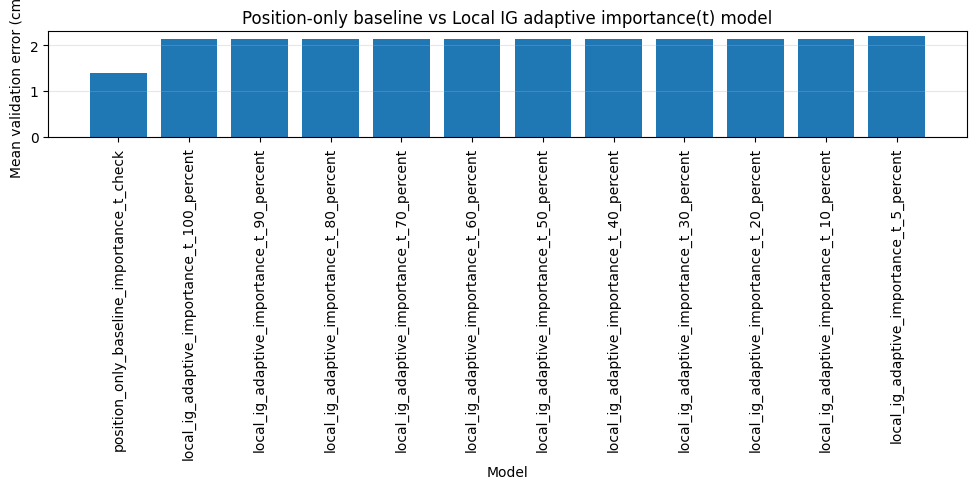

Comparison plot saved:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline_for_local_ig_check_importance_t/position_only_vs_local_ig_importance_t_mean_error_barplot.png
POSITION-ONLY BASELINE FOR IMPORTANCE(t) MODEL COMPLETED
Best position-only model:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline_for_local_ig_check_importance_t/best_position_only_baseline_model_importance_t.keras

Position-only validation summary:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline_for_local_ig_check_importance_t/position_only_validation_summary_importance_t.csv

Position-only per-location predictions:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline_for_local_ig_check_importance_t/position_only_val_predictions_per_location_importance_t.csv

Comparison summary:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline_for_local_ig_check_importance_t/position_only_vs_local_ig_adapti

In [81]:
# ============================================================
# POSITION-ONLY BASELINE MODEL
# Corrected for Local IG Adaptive model with importance(t)
#
# Goal:
#   Check whether position(t) alone can predict position(t+1)
#   with similar error to the corrected Local IG Adaptive CSI model.
#
# Input:
#   position(t)      shape = (2,)
#
# Output:
#   position(t+1)    shape = (2,)
#
# No CSI.
# No antenna mask.
# No IG importance.
#
# This version compares against:
#   local_ig_adaptive_tracking_model_importance_t
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

POSITION_ONLY_SAVE_DIR = (
    "/content/drive/MyDrive/DICHASUS_tracking_experiments/"
    "position_only_baseline_for_local_ig_check_importance_t"
)

os.makedirs(POSITION_ONLY_SAVE_DIR, exist_ok=True)

RANDOM_SEED = 42

BATCH_SIZE = 64
EPOCHS = 40
PATIENCE = 8

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


# ============================================================
# PATHS TO CORRECTED LOCAL IG MODEL RESULTS
# ============================================================

LOCAL_IG_IMPORTANCE_T_DIR = (
    "/content/drive/MyDrive/DICHASUS_tracking_experiments/"
    "local_ig_adaptive_tracking_model_importance_t"
)

local_ig_summary_path = os.path.join(
    LOCAL_IG_IMPORTANCE_T_DIR,
    "local_ig_adaptive_model_evaluation_summary_importance_t.csv"
)

local_ig_all_path = os.path.join(
    LOCAL_IG_IMPORTANCE_T_DIR,
    "val_all_local_percentages_per_location_importance_t.csv"
)


# ============================================================
# REQUIRED OBJECTS CHECK
# ============================================================

required_objects = [
    "train_data",
    "val_data",
    "pos_mean",
    "pos_std",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            "Run the corrected Local IG adaptive data preparation cells first."
        )

print("Required objects found.")


# ============================================================
# NORMALIZATION HELPERS
# ============================================================

def normalize_pos(x, mean, std):
    return ((x - mean) / std).astype(np.float32)


def denormalize_pos(x, mean, std):
    return (x * std + mean).astype(np.float32)


# ============================================================
# PREPARE POSITION-ONLY DATA
# ============================================================

X_train_pos = normalize_pos(
    train_data["X_pos_t"],
    pos_mean,
    pos_std
)

y_train_pos = normalize_pos(
    train_data["y_pos_tplus1"],
    pos_mean,
    pos_std
)

X_val_pos = normalize_pos(
    val_data["X_pos_t"],
    pos_mean,
    pos_std
)

y_val_pos = normalize_pos(
    val_data["y_pos_tplus1"],
    pos_mean,
    pos_std
)

print("X_train_pos:", X_train_pos.shape)
print("y_train_pos:", y_train_pos.shape)
print("X_val_pos:", X_val_pos.shape)
print("y_val_pos:", y_val_pos.shape)


# ============================================================
# BUILD POSITION-ONLY MODEL
# ============================================================

def build_position_only_baseline_model():
    position_t_input = tf.keras.Input(
        shape=(2,),
        name="position_t_input"
    )

    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        name="dense_1"
    )(position_t_input)

    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        name="dense_2"
    )(x)

    x = tf.keras.layers.Dense(
        32,
        activation="relu",
        name="dense_3"
    )(x)

    output = tf.keras.layers.Dense(
        2,
        activation=None,
        name="position_tplus1_output"
    )(x)

    model = tf.keras.Model(
        inputs=position_t_input,
        outputs=output,
        name="position_only_baseline_model_importance_t_check"
    )

    return model


position_only_model = build_position_only_baseline_model()

position_only_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=[
        "mae"
    ]
)

position_only_model.summary()


# ============================================================
# TRAIN POSITION-ONLY MODEL
# ============================================================

best_position_only_model_path = os.path.join(
    POSITION_ONLY_SAVE_DIR,
    "best_position_only_baseline_model_importance_t.keras"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_position_only_model_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        mode="min",
        verbose=1
    )
]

history = position_only_model.fit(
    X_train_pos,
    y_train_pos,
    validation_data=(
        X_val_pos,
        y_val_pos
    ),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

history_csv_path = os.path.join(
    POSITION_ONLY_SAVE_DIR,
    "position_only_training_history_importance_t.csv"
)

pd.DataFrame(history.history).to_csv(
    history_csv_path,
    index=False
)

print("Training history saved:")
print(history_csv_path)

print("Best position-only model saved:")
print(best_position_only_model_path)


# ============================================================
# LOAD BEST POSITION-ONLY MODEL
# ============================================================

best_position_only_model = tf.keras.models.load_model(
    best_position_only_model_path,
    compile=False
)

best_position_only_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=[
        "mae"
    ]
)

print("Best position-only model loaded.")


# ============================================================
# EVALUATE POSITION-ONLY MODEL ON VALIDATION
# ============================================================

val_pred_norm = best_position_only_model.predict(
    X_val_pos,
    batch_size=BATCH_SIZE,
    verbose=1
)

val_pred = denormalize_pos(
    val_pred_norm,
    pos_mean,
    pos_std
)

val_true = val_data["y_pos_tplus1"]

val_errors_m = np.sqrt(
    np.sum(
        (val_pred - val_true) ** 2,
        axis=1
    )
)

val_errors_cm = val_errors_m * 100.0

position_only_summary = {
    "model": "position_only_baseline_importance_t_check",
    "source": "val",
    "mean_error_cm": float(np.mean(val_errors_cm)),
    "median_error_cm": float(np.median(val_errors_cm)),
    "p90_error_cm": float(np.percentile(val_errors_cm, 90)),
    "p95_error_cm": float(np.percentile(val_errors_cm, 95)),
    "max_error_cm": float(np.max(val_errors_cm)),
    "num_samples": int(len(val_errors_cm)),
}

position_only_summary_df = pd.DataFrame(
    [
        position_only_summary
    ]
)

position_only_summary_csv_path = os.path.join(
    POSITION_ONLY_SAVE_DIR,
    "position_only_validation_summary_importance_t.csv"
)

position_only_summary_df.to_csv(
    position_only_summary_csv_path,
    index=False
)

print("Position-only validation summary:")
display(position_only_summary_df)

print("Saved:")
print(position_only_summary_csv_path)


# ============================================================
# SAVE PER-LOCATION POSITION-ONLY PREDICTIONS
# ============================================================

position_only_predictions_df = val_data["metadata"].copy()

position_only_predictions_df["position_only_pred_x"] = val_pred[:, 0]
position_only_predictions_df["position_only_pred_y"] = val_pred[:, 1]
position_only_predictions_df["position_only_error_cm"] = val_errors_cm

position_only_predictions_csv_path = os.path.join(
    POSITION_ONLY_SAVE_DIR,
    "position_only_val_predictions_per_location_importance_t.csv"
)

position_only_predictions_df.to_csv(
    position_only_predictions_csv_path,
    index=False
)

print("Position-only per-location predictions saved:")
print(position_only_predictions_csv_path)

display(position_only_predictions_df.head())


# ============================================================
# COMPARE WITH CORRECTED LOCAL IG ADAPTIVE MODEL SUMMARY
# ============================================================

if os.path.exists(local_ig_summary_path):
    local_ig_summary_df = pd.read_csv(
        local_ig_summary_path
    )

    local_ig_val_df = local_ig_summary_df[
        local_ig_summary_df["source"] == "val"
    ].copy()

    local_ig_val_df["model"] = (
        "local_ig_adaptive_importance_t_" +
        local_ig_val_df["local_percentage"].astype(str) +
        "_percent"
    )

    compare_columns = [
        "model",
        "source",
        "mean_error_cm",
        "median_error_cm",
        "p90_error_cm",
        "p95_error_cm",
        "max_error_cm",
        "num_samples"
    ]

    local_ig_compare_df = local_ig_val_df[
        compare_columns
    ].copy()

    comparison_df = pd.concat(
        [
            position_only_summary_df[compare_columns],
            local_ig_compare_df
        ],
        axis=0
    ).reset_index(drop=True)

    comparison_csv_path = os.path.join(
        POSITION_ONLY_SAVE_DIR,
        "position_only_vs_local_ig_adaptive_importance_t_comparison.csv"
    )

    comparison_df.to_csv(
        comparison_csv_path,
        index=False
    )

    print("=" * 100)
    print("Comparison: Position-only vs Local IG adaptive importance(t)")
    print("=" * 100)
    display(comparison_df)

    print("Comparison saved:")
    print(comparison_csv_path)

else:
    print("Corrected Local IG adaptive summary file not found:")
    print(local_ig_summary_path)


# ============================================================
# MERGE PER-LOCATION POSITION-ONLY ERROR WITH LOCAL IG ERRORS
# ============================================================

if os.path.exists(local_ig_all_path):
    local_ig_all_df = pd.read_csv(
        local_ig_all_path
    )

    position_only_small_df = position_only_predictions_df[
        [
            "source",
            "run_index",
            "sample_index_tplus1",
            "position_only_pred_x",
            "position_only_pred_y",
            "position_only_error_cm"
        ]
    ].copy()

    merged_per_location_df = local_ig_all_df.merge(
        position_only_small_df,
        on=[
            "source",
            "run_index",
            "sample_index_tplus1"
        ],
        how="left"
    )

    merged_per_location_df["local_ig_minus_position_only_error_cm"] = (
        merged_per_location_df["error_cm"] -
        merged_per_location_df["position_only_error_cm"]
    )

    merged_per_location_csv_path = os.path.join(
        POSITION_ONLY_SAVE_DIR,
        "local_ig_importance_t_percentages_vs_position_only_per_location.csv"
    )

    merged_per_location_df.to_csv(
        merged_per_location_csv_path,
        index=False
    )

    print("=" * 100)
    print("Per-location comparison saved:")
    print(merged_per_location_csv_path)

    display(
        merged_per_location_df[
            [
                "actual_x_tplus1",
                "actual_y_tplus1",
                "local_percentage",
                "num_active_antennas",
                "error_cm",
                "position_only_error_cm",
                "local_ig_minus_position_only_error_cm"
            ]
        ].head(20).reset_index(drop=True)
    )

else:
    print("Corrected Local IG all-percentages file not found:")
    print(local_ig_all_path)


# ============================================================
# PLOT COMPARISON
# ============================================================

if "comparison_df" in globals():
    plt.figure(figsize=(10, 5))

    plt.bar(
        comparison_df["model"],
        comparison_df["mean_error_cm"]
    )

    plt.xlabel("Model")
    plt.ylabel("Mean validation error (cm)")
    plt.title("Position-only baseline vs Local IG adaptive importance(t) model")
    plt.xticks(rotation=90)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    comparison_plot_path = os.path.join(
        POSITION_ONLY_SAVE_DIR,
        "position_only_vs_local_ig_importance_t_mean_error_barplot.png"
    )

    plt.savefig(
        comparison_plot_path,
        dpi=200
    )

    plt.show()

    print("Comparison plot saved:")
    print(comparison_plot_path)


# ============================================================
# FINAL PRINT
# ============================================================

print("=" * 100)
print("POSITION-ONLY BASELINE FOR IMPORTANCE(t) MODEL COMPLETED")
print("=" * 100)

print("Best position-only model:")
print(best_position_only_model_path)

print("\nPosition-only validation summary:")
print(position_only_summary_csv_path)

print("\nPosition-only per-location predictions:")
print(position_only_predictions_csv_path)

if "comparison_csv_path" in globals():
    print("\nComparison summary:")
    print(comparison_csv_path)

if "merged_per_location_csv_path" in globals():
    print("\nPer-location comparison:")
    print(merged_per_location_csv_path)